# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [430]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#0adfc6ff"
    genotype_color['eYFP_ArchT'] = "#8F9FFF"
    genotype_color['CA1_control'] = "#62d70fff"
    genotype_color['Control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = "#00C2B5"
    genotype_color['WT'] = 'grey'
    genotype_color['short_1'] = "#ff6600ff"
    genotype_color['short_2'] = "#ffdd00ff"
    genotype_color['F231A'] = '#F44636ff'
    genotype_color['F231A_wt'] =  '#5ba0d8ff'


    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
'#1F2A63'
'#C276A5'
"#f468f1ff"

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [418]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260511.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20260511.csv


## Main

### Visualize the cheeseboard maze task variables

In [419]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [396]:
dl.id, dl.ses_dir

('A', 'ses-07_date-20241211')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

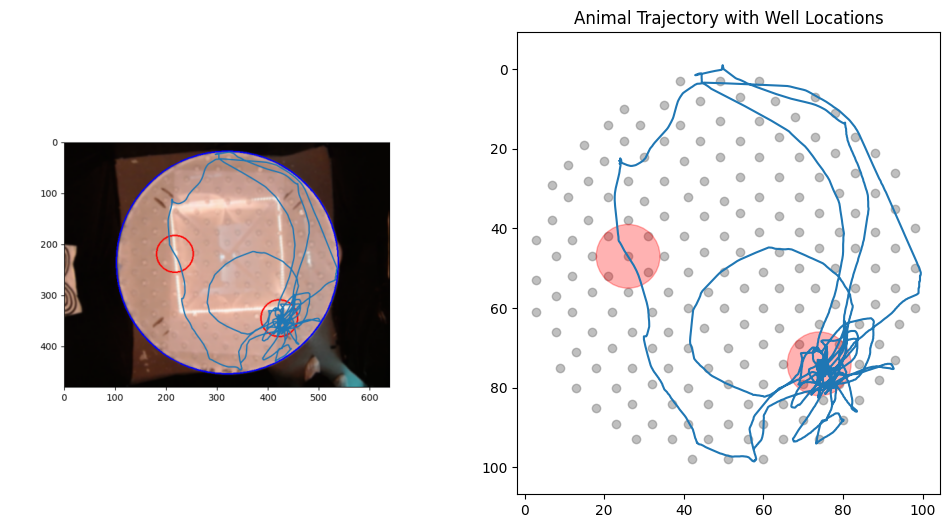

In [420]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')



/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_20470/2628838136.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


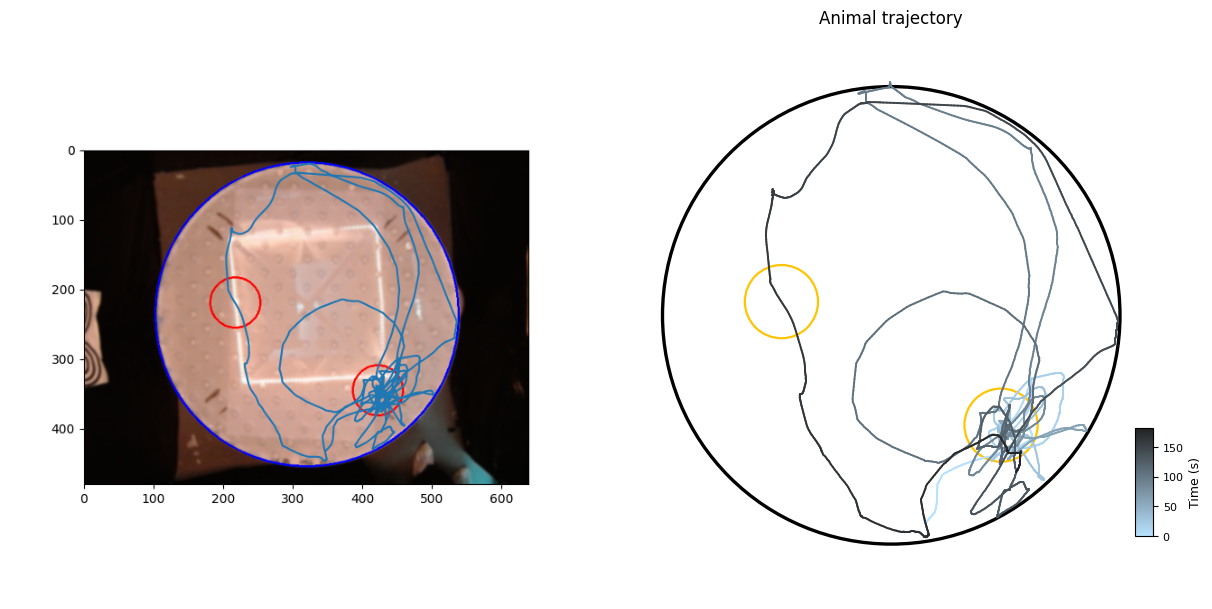

In [421]:
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
import matplotlib as mpl
import numpy as np

# ------------------------------------------------------------
# Cheeseboard geometry
# ------------------------------------------------------------
BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS   = 50

TRIGGER_RADIUS = 8

# padding to make board appear smaller inside panel
PLOT_PADDING = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=(1, 1))

# ------------------------------------------------------------
# Left panel: image
# ------------------------------------------------------------
axes[0].imshow(img)
axes[0].axis('off')

# ------------------------------------------------------------
# Right panel: trajectory
# ------------------------------------------------------------
ax = axes[1]
ax.set_facecolor("white")

# ---- time vector ----
if 't' in position.columns:
    t = position['t'].values.astype(float)
    t = (t - t[0]) / 1000
else:
    t = np.arange(len(position))

x = position['x'].values.astype(float)
y = position['y'].values.astype(float)

ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)

x = x[ok]
y = y[ok]
t = t[ok]

# ------------------------------------------------------------
# Time-coloured trajectory
# ------------------------------------------------------------
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "traj_time",
    ['#b8e2ff', '#222222']
)

norm = mpl.colors.Normalize(t.min(), t.max())

lc = LineCollection(
    segments,
    cmap=cmap,
    norm=norm,
    linewidth=1.4,
    capstyle='round'
)

lc.set_array(t[:-1])
ax.add_collection(lc)

# ------------------------------------------------------------
# Cheeseboard circle
# ------------------------------------------------------------
board_circle = Circle(
    (BOARD_CENTER_X, BOARD_CENTER_Y),
    BOARD_RADIUS,
    color='black',
    fill=False,
    linewidth=2.4
)

ax.add_artist(board_circle)

# ------------------------------------------------------------
# Reward zones (blue)
# ------------------------------------------------------------
for i in range(len(triggerLoc)):

    cx = triggerLoc['x'][i]
    cy = triggerLoc['y'][i]

    reward_circle = Circle(
        (cx, cy),
        TRIGGER_RADIUS,
        color="#ffc404",
        fill=False,
        linewidth=1.6
    )

    ax.add_artist(reward_circle)

# ------------------------------------------------------------
# Make board smaller inside panel
# ------------------------------------------------------------
ax.set_xlim(
    BOARD_CENTER_X - BOARD_RADIUS - PLOT_PADDING,
    BOARD_CENTER_X + BOARD_RADIUS + PLOT_PADDING
)

ax.set_ylim(
    BOARD_CENTER_Y + BOARD_RADIUS + PLOT_PADDING,
    BOARD_CENTER_Y - BOARD_RADIUS - PLOT_PADDING
)

ax.set_aspect('equal')

# remove axes
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Animal trajectory", fontsize=12)

# ------------------------------------------------------------
# Small colorbar bottom right
# ------------------------------------------------------------
cax = fig.add_axes([0.95, 0.13, 0.015, 0.18])

cbar = fig.colorbar(lc, cax=cax)

cbar.set_label("Time (s)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

### Occupancy map

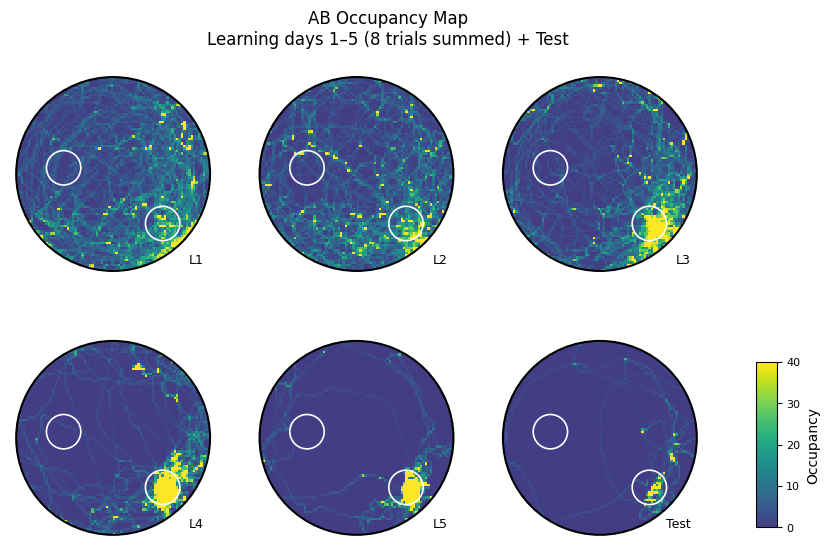

In [303]:
import matplotlib.colors as colors
# ============================================================
# OPTIONS
# ============================================================
ANIMAL_ID = 'AB'
INCLUDE_TEST_DAY = True

NBINS = 80

BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS   = 47          # smaller than 50

REWARD_RADIUS = 10 / 1.2

VMIN = 0
VMAX = 40

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

mt = metadata[
    (metadata['usable'] == 1) &
    (metadata['id'] == ANIMAL_ID) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
mt['plot_day'] = np.nan

mask_L = mt['trial_type'] == 'L'
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

if INCLUDE_TEST_DAY:
    L_ses = mt.loc[mt['trial_type'] == 'L', 'ses']

    if len(L_ses) > 0:
        last_L_ses = L_ses.max()
        T_after = mt[(mt['trial_type'] == 'T') & (mt['ses'] > last_L_ses)]

        if len(T_after) > 0:
            first_T_ses = T_after['ses'].min()

            idx = mt.index[
                (mt['trial_type'] == 'T') &
                (mt['ses'] == first_T_ses)
            ]

            mt.loc[idx, 'plot_day'] = 6

plot_days = [1, 2, 3, 4, 5] + ([6] if INCLUDE_TEST_DAY else [])
mt = mt[mt['plot_day'].isin(plot_days)]

# ============================================================
# Helper to load trial
# ============================================================
def load_trial(meta_row):
    dl = DataLoader(meta_row)
    position   = dl.get_data('position')
    triggerLoc = dl.get_data('triggerLoc')
    return position, triggerLoc

# ============================================================
# Build occupancy maps
# ============================================================
x_edges = np.linspace(
    BOARD_CENTER_X - BOARD_RADIUS,
    BOARD_CENTER_X + BOARD_RADIUS,
    NBINS + 1
)

y_edges = np.linspace(
    BOARD_CENTER_Y - BOARD_RADIUS,
    BOARD_CENTER_Y + BOARD_RADIUS,
    NBINS + 1
)

day_maps = {}
trigger_ref = None

for day in plot_days:
    md = mt[mt['plot_day'] == day]

    if len(md) == 0:
        day_maps[day] = None
        continue

    md = md.sort_values('trial_id')

    if day != 6:
        md_use = md
    else:
        md_use = md[md['trial_id'] == 1]
        if len(md_use) == 0:
            md_use = md.iloc[[0]]

    xs = []
    ys = []

    for _, row in md_use.iterrows():
        position, triggerLoc = load_trial(row)

        if position is None:
            continue

        x = position['x'].values.astype(float)
        y = position['y'].values.astype(float)

        ok = np.isfinite(x) & np.isfinite(y)
        if ok.sum() == 0:
            continue

        xs.append(x[ok])
        ys.append(y[ok])

        if trigger_ref is None and triggerLoc is not None:
            trigger_ref = triggerLoc.copy()

    if len(xs) == 0:
        day_maps[day] = None
        continue

    xs = np.concatenate(xs)
    ys = np.concatenate(ys)

    H, _, _ = np.histogram2d(xs, ys, bins=[x_edges, y_edges])
    H = H.T

    day_maps[day] = H

# ============================================================
# Plot
# ============================================================
day_labels = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4', 5: 'L5', 6: 'Test'}

# make panels a bit smaller and give them more space
fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.5))
axes = axes.flatten()

valid_maps = [m for m in day_maps.values() if m is not None]
vmax = VMAX if VMAX is not None else max(np.nanmax(m) for m in valid_maps)

# lighter blue -> green -> yellow
base = plt.cm.viridis
cmap = colors.LinearSegmentedColormap.from_list(
    "viridis_lighter_blue",
    base(np.linspace(0.18, 1.00, 256))   # trims off the darkest blue/purple end
)
cmap.set_bad("white")

for ax, day in zip(axes, plot_days):
    occ = day_maps[day]

    if occ is None:
        ax.axis('off')
        continue

    im = ax.imshow(
        occ,
        extent=[x_edges[0], x_edges[-1], y_edges[-1], y_edges[0]],
        cmap=cmap,
        vmin=VMIN,
        vmax=vmax,
        interpolation='nearest'
    )

    # clip heatmap strictly to cheeseboard circle
    clip_circle = Circle(
        (BOARD_CENTER_X, BOARD_CENTER_Y),
        BOARD_RADIUS,
        transform=ax.transData
    )
    im.set_clip_path(clip_circle)

    # thicker cheeseboard border
    board_circle = Circle(
        (BOARD_CENTER_X, BOARD_CENTER_Y),
        BOARD_RADIUS,
        color='black',
        fill=False,
        linewidth=1.5
    )
    ax.add_artist(board_circle)

    # reward zones
    if trigger_ref is not None:
        for i in range(len(trigger_ref)):
            cx = trigger_ref['x'].iloc[i]
            cy = trigger_ref['y'].iloc[i]

            reward_circle = Circle(
                (cx, cy),
                REWARD_RADIUS,
                color='white',
                fill=False,
                linewidth=1.2
            )
            ax.add_artist(reward_circle)

    # smaller label, bottom-right
    ax.text(
        0.94, 0.05,
        day_labels[day],
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=1.2)
    )

    # make each board occupy a little less of each panel to avoid touching
    panel_pad = 3.0
    ax.set_xlim(BOARD_CENTER_X - BOARD_RADIUS - panel_pad,
                BOARD_CENTER_X + BOARD_RADIUS + panel_pad)
    ax.set_ylim(BOARD_CENTER_Y + BOARD_RADIUS + panel_pad,
                BOARD_CENTER_Y - BOARD_RADIUS - panel_pad)

    ax.set_aspect('equal')
    ax.axis('off')

for j in range(len(plot_days), len(axes)):
    axes[j].axis('off')

fig.suptitle(
    f'{ANIMAL_ID} Occupancy Map\nLearning days 1–5 (8 trials summed) + Test',
    fontsize=12,
    x=0.4, y=0.77)

# ------------------------------------------------------------
# Small colorbar at bottom-right
# ------------------------------------------------------------
cax = fig.add_axes([0.75, 0.08, 0.02, 0.22])
# [left, bottom, width, height] in figure coordinates

cbar = fig.colorbar(im, cax=cax)

cbar.set_label('Occupancy', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# more space between panels
fig.subplots_adjust(
    left=0.04,
    right=0.7,
    bottom=0.05,
    top=0.7,
    wspace=0.18,
    hspace=0.18
)

plt.show()

In [279]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [368]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


### Compute the time animal took to reach the trigger zone

In [369]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,gender,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7251,97,F8,20260503,8,6,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7252,97,F8,20260503,8,7,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7253,97,F8,20260503,8,8,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7254,97,F8,20260504,9,1,T,1,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN


Occupancy metrics

In [349]:
# ============================================================
# Compute exploratory metrics per trial
#
# Adds:
#   1) total_dist
#      = total distance travelled across the whole trial, in cm
#
#   2) occupancy_coverage_pct
#      = % of valid arena bins visited
#      = visited bins / all bins whose centre is inside circular arena
#
#   3) occupancy_entropy
#      = normalized Shannon entropy of occupancy distribution
#      = 0 means very concentrated occupancy
#      = 1 means perfectly evenly distributed across all valid arena bins
#
# Bin size:
#   5 cm bins in real-world units.
#
# Circular arena:
#   Real cheeseboard diameter = 120 cm
#   Tracking coordinate system = 0-100 arbitrary units
#   Therefore:
#       1 tracking unit = 1.2 cm
#       board radius = 60 cm = 50 tracking units
#
# Bin centre rule:
#   A bin is included as valid if its centre is inside the circular arena.
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
BIN_SIZE_CM = 5.0

# Coordinate conversion based on your existing code:
# R_TRIGGER = 10 / 1.2
# so:
#   1 tracking coordinate unit = 1.2 cm
#   5 cm = 5 / 1.2 tracking coordinate units
COORD_TO_CM = 1.2
BIN_SIZE_COORD = BIN_SIZE_CM / COORD_TO_CM

# Real cheeseboard:
#   diameter = 120 cm
#   radius   = 60 cm
# In your tracking coordinates:
#   60 cm / 1.2 = 50 coordinate units
BOARD_DIAMETER_CM = 120.0
BOARD_RADIUS_CM = BOARD_DIAMETER_CM / 2.0

BOARD_CENTER_X = 50.0
BOARD_CENTER_Y = 50.0
BOARD_RADIUS_COORD = BOARD_RADIUS_CM / COORD_TO_CM   # = 50

USE_TIME_WEIGHTED_OCCUPANCY = False
# False = entropy based on sample counts per bin, matching your occupancy map logic.
# True  = entropy based on time spent per bin, using position['t'] if available.

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# Output columns
# ------------------------------------------------------------
metadata['total_dist'] = np.nan
metadata['occupancy_coverage_pct'] = np.nan
metadata['occupancy_entropy'] = np.nan

# Optional useful diagnostic columns
metadata['occupancy_entropy_raw'] = np.nan
metadata['n_valid_occupancy_bins'] = np.nan
metadata['n_visited_occupancy_bins'] = np.nan
metadata['occupancy_bin_size_cm'] = BIN_SIZE_CM
metadata['occupancy_bin_size_coord'] = BIN_SIZE_COORD
metadata['board_radius_cm'] = BOARD_RADIUS_CM
metadata['board_radius_coord'] = BOARD_RADIUS_COORD

# ------------------------------------------------------------
# Build circular arena bin grid
# ------------------------------------------------------------
# Use arange so each bin is exactly 5 cm wide in real space,
# i.e. 5 / 1.2 coordinate units.
#
# The final + small epsilon prevents floating point rounding from
# accidentally dropping the last edge.
# ------------------------------------------------------------
eps = 1e-9

x_edges = np.arange(
    BOARD_CENTER_X - BOARD_RADIUS_COORD,
    BOARD_CENTER_X + BOARD_RADIUS_COORD + BIN_SIZE_COORD + eps,
    BIN_SIZE_COORD
)

y_edges = np.arange(
    BOARD_CENTER_Y - BOARD_RADIUS_COORD,
    BOARD_CENTER_Y + BOARD_RADIUS_COORD + BIN_SIZE_COORD + eps,
    BIN_SIZE_COORD
)

# If arange goes slightly beyond the board boundary because of the added bin,
# keep it. That is okay because valid bins are decided by centre-in-circle.
# This allows edge bins whose centres are inside the board.
x_centres = (x_edges[:-1] + x_edges[1:]) / 2
y_centres = (y_edges[:-1] + y_edges[1:]) / 2

xx, yy = np.meshgrid(x_centres, y_centres)

dist_from_centre_coord = np.sqrt(
    (xx - BOARD_CENTER_X) ** 2 +
    (yy - BOARD_CENTER_Y) ** 2
)

# Include a bin if its centre is inside the real circular arena
valid_bin_mask = dist_from_centre_coord <= BOARD_RADIUS_COORD
n_valid_bins = int(np.sum(valid_bin_mask))

print(f"Real board diameter: {BOARD_DIAMETER_CM:g} cm")
print(f"Real board radius:   {BOARD_RADIUS_CM:g} cm")
print(f"Coordinate radius:   {BOARD_RADIUS_COORD:g} tracking units")
print(f"Coordinate scale:    1 tracking unit = {COORD_TO_CM:g} cm")
print(f"Bin size:            {BIN_SIZE_CM:g} cm = {BIN_SIZE_COORD:.4f} tracking units")
print(f"Grid shape:          {valid_bin_mask.shape}")
print(f"Valid arena bins:    {n_valid_bins}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def compute_total_distance_cm(position):
    """
    Total path length across the whole trial, in cm.

    Uses x/y step distances directly.
    """
    x = position['x'].values.astype(float)
    y = position['y'].values.astype(float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if len(x) < 2:
        return np.nan

    dx = np.diff(x)
    dy = np.diff(y)

    step_dist_coord = np.sqrt(dx * dx + dy * dy)
    total_dist_cm = np.nansum(step_dist_coord) * COORD_TO_CM

    return float(total_dist_cm)


def compute_occupancy_metrics(position):
    """
    Computes:
      occupancy_coverage_pct
      occupancy_entropy_raw
      occupancy_entropy normalized to 0-1

    Uses only bins whose centre is inside the circular cheeseboard.
    Bin size is 5 cm in real space.
    """
    x = position['x'].values.astype(float)
    y = position['y'].values.astype(float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0

    # --------------------------------------------------------
    # Assign each sample to x/y bin
    # --------------------------------------------------------
    x_bin = np.digitize(x, x_edges) - 1
    y_bin = np.digitize(y, y_edges) - 1

    in_grid = (
        (x_bin >= 0) &
        (x_bin < len(x_edges) - 1) &
        (y_bin >= 0) &
        (y_bin < len(y_edges) - 1)
    )

    x_bin = x_bin[in_grid]
    y_bin = y_bin[in_grid]

    if len(x_bin) == 0:
        return np.nan, np.nan, np.nan, 0

    # Keep only samples falling into bins whose centre is inside circle
    inside_circle_bin = valid_bin_mask[y_bin, x_bin]

    x_bin = x_bin[inside_circle_bin]
    y_bin = y_bin[inside_circle_bin]

    if len(x_bin) == 0:
        return np.nan, np.nan, np.nan, 0

    # --------------------------------------------------------
    # Occupancy map
    # --------------------------------------------------------
    occ = np.zeros(valid_bin_mask.shape, dtype=float)

    if USE_TIME_WEIGHTED_OCCUPANCY and 't' in position.columns:
        t = position['t'].values.astype(float)
        t = t[ok]
        t = t[in_grid]
        t = t[inside_circle_bin]

        if len(t) == len(x_bin) and len(t) >= 2:
            dt = np.diff(t, append=t[-1])

            # If time is in ms, convert to seconds.
            # This does not affect normalized entropy or coverage,
            # but keeps occupancy weights interpretable.
            if np.nanmedian(dt) > 1:
                dt = dt / 1000.0

            dt[~np.isfinite(dt)] = 0
            dt[dt < 0] = 0

            weights = dt
        else:
            weights = np.ones(len(x_bin), dtype=float)
    else:
        weights = np.ones(len(x_bin), dtype=float)

    np.add.at(occ, (y_bin, x_bin), weights)

    # Only analyse valid circular arena bins
    occ_valid = occ[valid_bin_mask]

    visited = occ_valid > 0
    n_visited_bins = int(np.sum(visited))

    if n_valid_bins == 0:
        coverage_pct = np.nan
    else:
        coverage_pct = (n_visited_bins / n_valid_bins) * 100.0

    # --------------------------------------------------------
    # Occupancy entropy
    # --------------------------------------------------------
    total_occ = np.nansum(occ_valid)

    if total_occ <= 0 or not np.isfinite(total_occ):
        entropy_raw = np.nan
        entropy_norm = np.nan
    else:
        p = occ_valid / total_occ
        p = p[p > 0]

        entropy_raw = -np.sum(p * np.log(p))

        # Normalize by maximum possible entropy across all valid arena bins.
        # This means:
        #   0 = all occupancy in one bin
        #   1 = perfectly even occupancy across the whole arena
        if n_valid_bins > 1:
            entropy_norm = entropy_raw / np.log(n_valid_bins)
        else:
            entropy_norm = np.nan

    return (
        float(coverage_pct) if np.isfinite(coverage_pct) else np.nan,
        float(entropy_raw) if np.isfinite(entropy_raw) else np.nan,
        float(entropy_norm) if np.isfinite(entropy_norm) else np.nan,
        n_visited_bins
    )


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')

    if position is None or len(position) == 0:
        continue

    if ('x' not in position.columns) or ('y' not in position.columns):
        continue

    # 1) total distance
    total_dist = compute_total_distance_cm(position)

    # 2) coverage and 3) entropy
    coverage_pct, entropy_raw, entropy_norm, n_visited_bins = compute_occupancy_metrics(position)

    metadata.at[trial_id, 'total_dist'] = total_dist
    metadata.at[trial_id, 'occupancy_coverage_pct'] = coverage_pct
    metadata.at[trial_id, 'occupancy_entropy_raw'] = entropy_raw
    metadata.at[trial_id, 'occupancy_entropy'] = entropy_norm
    metadata.at[trial_id, 'n_valid_occupancy_bins'] = n_valid_bins
    metadata.at[trial_id, 'n_visited_occupancy_bins'] = n_visited_bins

# ------------------------------------------------------------
# Quick check
# ------------------------------------------------------------
metadata[[
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'total_dist',
    'occupancy_coverage_pct',
    'occupancy_entropy',
    'occupancy_entropy_raw',
    'n_visited_occupancy_bins',
    'n_valid_occupancy_bins',
    'occupancy_bin_size_cm',
    'occupancy_bin_size_coord',
    'board_radius_cm',
    'board_radius_coord'
]].head()

Real board diameter: 120 cm
Real board radius:   60 cm
Coordinate radius:   50 tracking units
Coordinate scale:    1 tracking unit = 1.2 cm
Bin size:            5 cm = 4.1667 tracking units
Grid shape:          (25, 25)
Valid arena bins:    448


 11%|█         | 712/6620 [00:05<00:39, 148.55it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1187/6620 [00:08<00:38, 141.12it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6506/6620 [00:42<00:00, 188.25it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6620/6620 [00:42<00:00, 155.13it/s]


,sub,id,ses,trial_type,trial_type_day,total_dist,occupancy_coverage_pct,occupancy_entropy,occupancy_entropy_raw,n_visited_occupancy_bins,n_valid_occupancy_bins,occupancy_bin_size_cm,occupancy_bin_size_coord,board_radius_cm,board_radius_coord
0,1,A,1,H,1,2882.336023,75.892857,0.875228,5.343084,340.0,448.0,5.0,4.166667,60.0,50.0
1,1,A,1,H,1,2027.951185,65.848214,0.835817,5.102489,295.0,448.0,5.0,4.166667,60.0,50.0
2,1,A,1,H,1,1816.159847,61.160714,0.802596,4.899685,274.0,448.0,5.0,4.166667,60.0,50.0
3,1,A,1,H,1,2111.708247,65.178571,0.822880,5.023513,292.0,448.0,5.0,4.166667,60.0,50.0
4,1,A,1,H,1,2044.428060,64.062500,0.833427,5.087898,287.0,448.0,5.0,4.166667,60.0,50.0



Groups used for plotting/stats: ['ChR2_short', 'CA1', 'CA3', 'Control']
Original genotypes loaded: ['CA1', 'CA1_control', 'CA3', 'ChR2_short', 'NAc_control']
Active custom groups: []
Custom IDs loaded: []
Day value mode: daily_mean
Trial column used: inferred from sub/ses order
Gender filter: all
Control pooled from: ['NAc_control', 'CA1_control']

Custom groups:

Animals after all filters:
    sub   id gender genotype_original    genotype
0    13   AI    NaN        ChR2_short  ChR2_short
1    14   AJ    NaN        ChR2_short  ChR2_short
2    15   AL    NaN        ChR2_short  ChR2_short
3    40   AP    NaN               CA1         CA1
4    41   AQ    NaN               CA1         CA1
5    42   AR    NaN               CA1         CA1
6    44   AT    NaN               CA1         CA1
7    45   AU    NaN               CA1         CA1
8    46   AV    NaN               CA1         CA1
9    71   C1    NaN               CA3         CA3
10   72   C2    NaN               CA3         CA3
11   

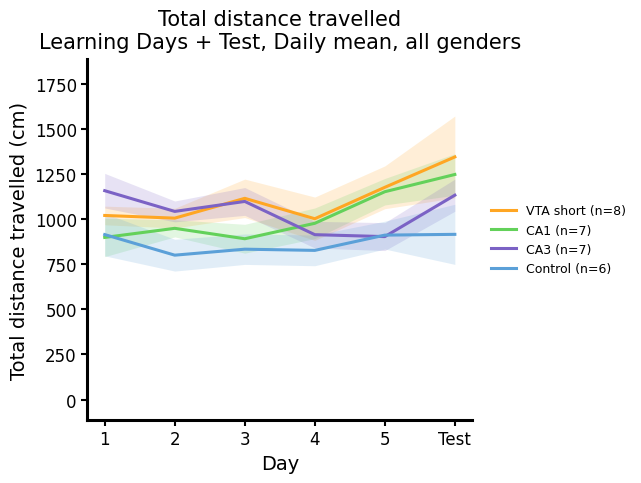


=== Line plot: occupancy_coverage_pct ===
VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']


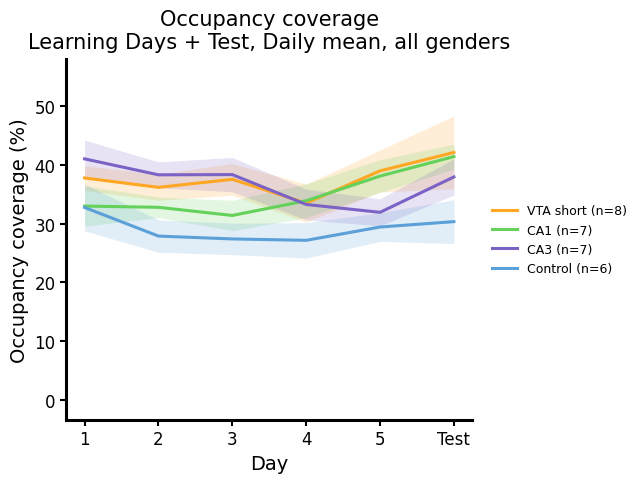


=== Line plot: occupancy_coverage_cm2 ===
VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']


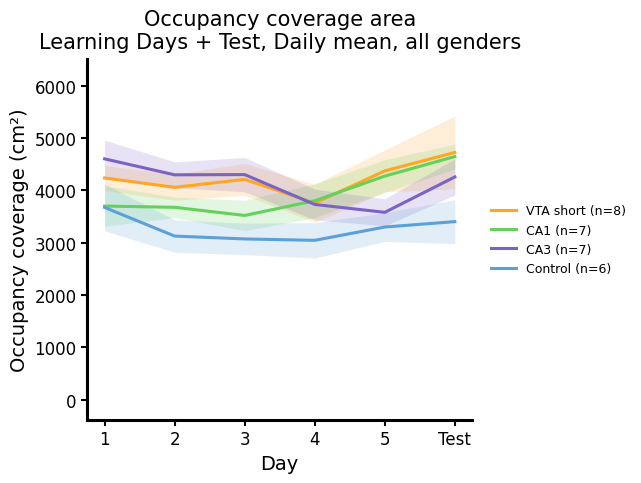


=== Line plot: occupancy_entropy ===
VTA short (ChR2_short): n = 8, ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
Control (Control): n = 6, ids = ['C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']


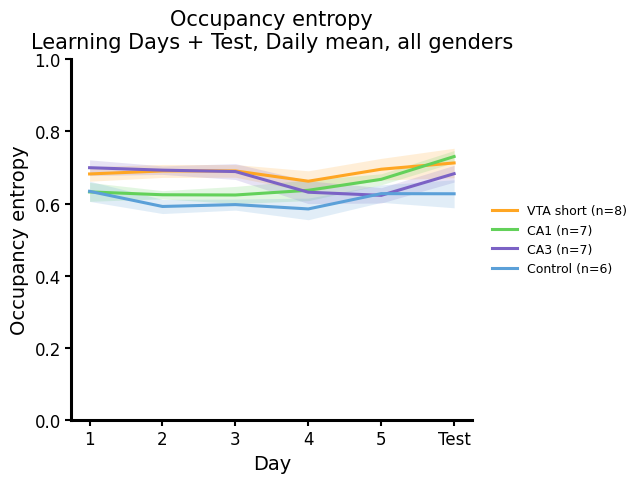


=== Test-day boxplot: total_dist ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=1343.757 vs 1246.613, median=1225.424 vs 1235.658, U=30.0, rank-biserial=0.071, p=0.86651
  VTA short vs CA3: n=8 vs 7, mean=1343.757 vs 1131.977, median=1225.424 vs 1134.900, U=31.0, rank-biserial=0.107, p=0.77887
  VTA short vs Control: n=8 vs 6, mea

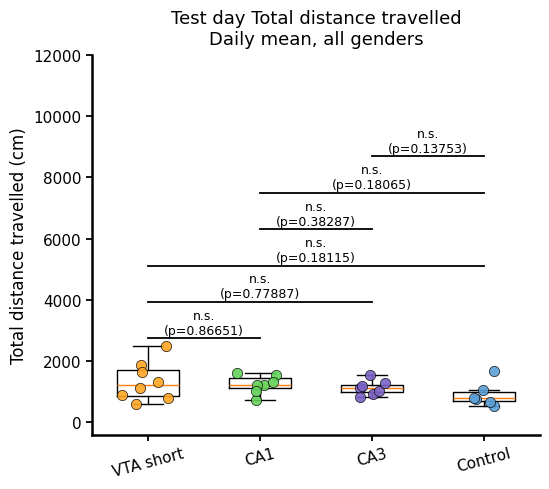


=== Test-day boxplot: occupancy_coverage_pct ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=42.160 vs 41.454, median=35.045 vs 41.071, U=23.0, rank-biserial=-0.179, p=0.61259
  VTA short vs CA3: n=8 vs 7, mean=42.160 vs 37.978, median=35.045 vs 33.482, U=29.0, rank-biserial=0.036, p=0.95509
  VTA short vs Control: n=8 vs 6, mean=4

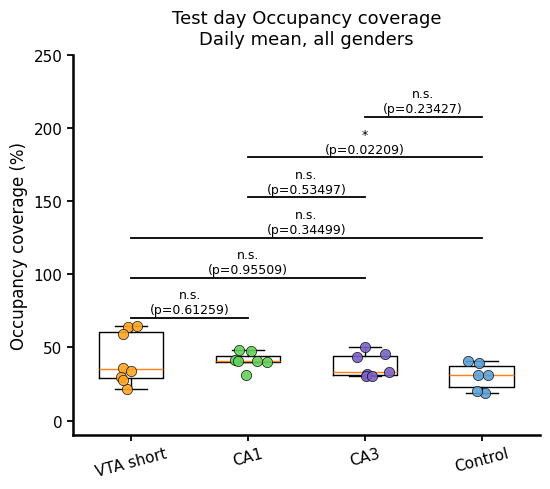


=== Test-day boxplot: occupancy_coverage_cm2 ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=4721.875 vs 4642.857, median=3925.000 vs 4600.000, U=23.0, rank-biserial=-0.179, p=0.61259
  VTA short vs CA3: n=8 vs 7, mean=4721.875 vs 4253.571, median=3925.000 vs 3750.000, U=29.0, rank-biserial=0.036, p=0.95509
  VTA short vs Control: 

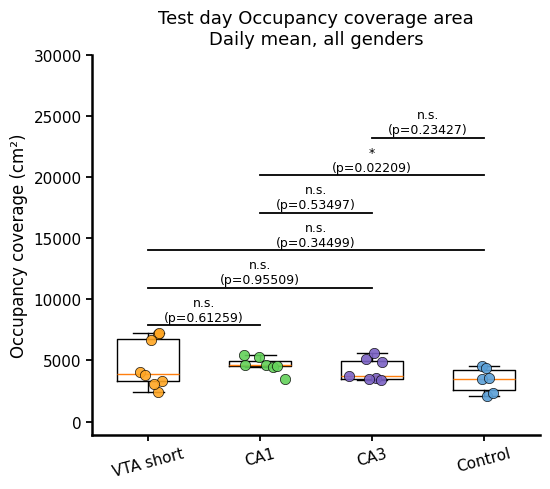


=== Test-day boxplot: occupancy_entropy ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=0.713 vs 0.730, median=0.672 vs 0.723, U=22.0, rank-biserial=-0.214, p=0.53582
  VTA short vs CA3: n=8 vs 7, mean=0.713 vs 0.683, median=0.672 vs 0.703, U=29.0, rank-biserial=0.036, p=0.95509
  VTA short vs Control: n=8 vs 6, mean=0.713 vs 0.627

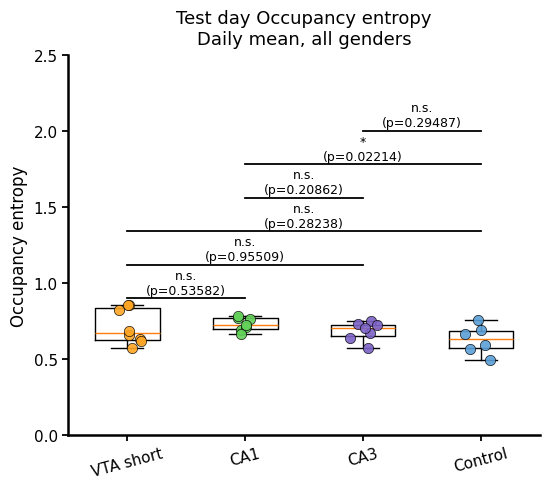


=== Learning-days 1-5 average boxplot: total_dist ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=1063.252 vs 972.939, median=1048.136 vs 899.582, U=42.0, rank-biserial=0.500, p=0.12059
  VTA short vs CA3: n=8 vs 7, mean=1063.252 vs 1022.465, median=1048.136 vs 1063.211, U=35.0, rank-biserial=0.250, p=0.46340
  VTA short vs Control

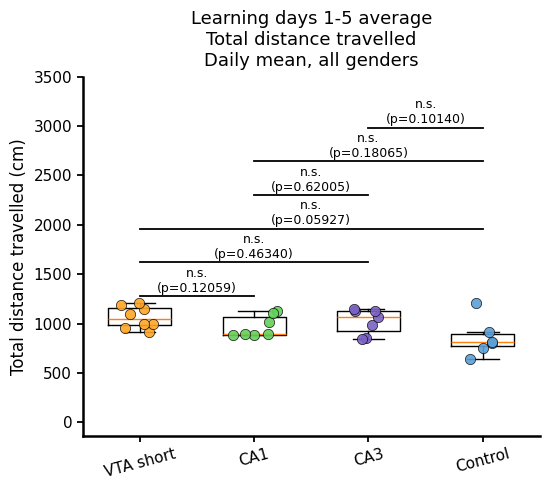


=== Learning-days 1-5 average boxplot: occupancy_coverage_pct ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=36.820 vs 33.853, median=36.239 vs 33.449, U=40.0, rank-biserial=0.429, p=0.18928
  VTA short vs CA3: n=8 vs 7, mean=36.820 vs 36.603, median=36.239 vs 37.634, U=29.0, rank-biserial=0.036, p=0.95509
  VTA short vs Control: 

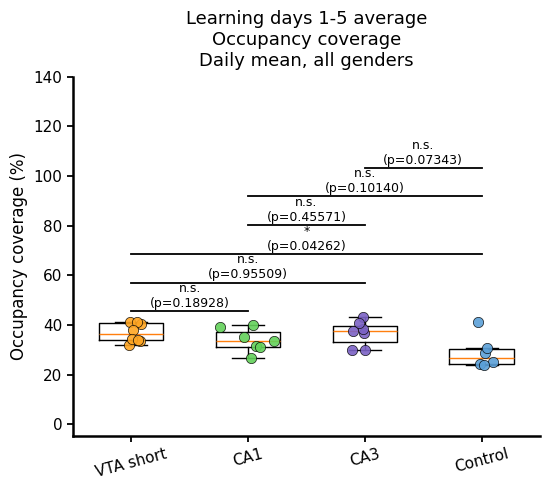


=== Learning-days 1-5 average boxplot: occupancy_coverage_cm2 ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=4123.873 vs 3791.531, median=4058.795 vs 3746.250, U=40.0, rank-biserial=0.429, p=0.18928
  VTA short vs CA3: n=8 vs 7, mean=4123.873 vs 4099.490, median=4058.795 vs 4215.000, U=29.0, rank-biserial=0.036, p=0.95509
  VTA sh

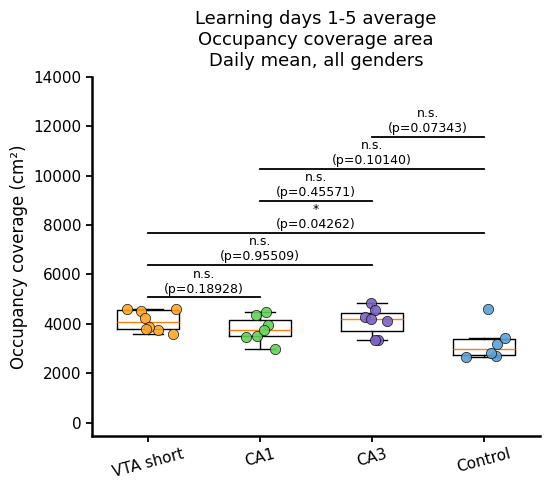


=== Learning-days 1-5 average boxplot: occupancy_entropy ===
  VTA short (ChR2_short): n = 8, animals = [np.str_('AI'), np.str_('AJ'), np.str_('AL'), np.str_('V1'), np.str_('V2'), np.str_('V3'), np.str_('V4'), np.str_('V5')]
  CA1 (CA1): n = 7, animals = [np.str_('AP'), np.str_('AQ'), np.str_('AR'), np.str_('AT'), np.str_('AU'), np.str_('AV'), np.str_('C8')]
  CA3 (CA3): n = 7, animals = [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5'), np.str_('C6'), np.str_('C7')]
  Control (Control): n = 6, animals = [np.str_('C9 (CA1_control)'), np.str_('C10 (CA1_control)'), np.str_('C11 (CA1_control)'), np.str_('N8 (NAc_control)'), np.str_('N9 (NAc_control)'), np.str_('N10 (NAc_control)')]

Mann–Whitney U tests:
  VTA short vs CA1: n=8 vs 7, mean=0.684 vs 0.637, median=0.685 vs 0.631, U=46.0, rank-biserial=0.643, p=0.04009
  VTA short vs CA3: n=8 vs 7, mean=0.684 vs 0.667, median=0.685 vs 0.687, U=34.0, rank-biserial=0.214, p=0.53582
  VTA short vs Control: n=8 vs 6, mea

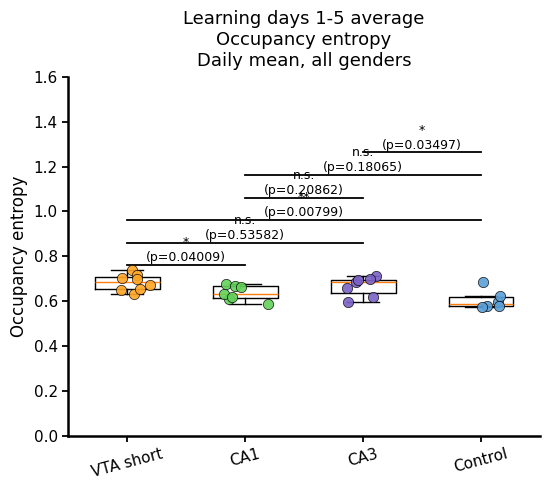

In [353]:
# ============================================================
# Exploratory metrics across L1-L5 + Test
#
# Metrics:
#   total_dist
#       = total distance travelled across the whole trial
#
#   occupancy_coverage_pct
#       = % of valid arena bins visited
#
#   occupancy_coverage_cm2
#       = visited arena area in cm²
#       = n visited bins × 5 cm × 5 cm
#
#   occupancy_entropy
#       = normalized Shannon entropy of occupancy distribution
#
# Adds custom ID-based groups:
#   short_1 = AI, AJ, AL
#   short_2 = V1, V2, V3, V4, V5
#
# IMPORTANT:
#   ChR2_short still works as a normal group.
#
#   If GROUPS = ['ChR2_short']:
#       all ChR2_short animals stay in ChR2_short.
#
#   If GROUPS = ['short_1', 'short_2']:
#       only the selected IDs are split into short_1 / short_2.
#
#   If GROUPS = ['ChR2_short', 'short_1', 'short_2']:
#       custom IDs go to short_1 / short_2,
#       remaining ChR2_short animals stay in ChR2_short.
#
# DAY_VALUE_MODE:
#   'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   'first_trial'
#       learning days = first trial only from each day
#       test day      = first test trial only
#
# Gender option:
#   GENDER_FILTER = None      -> include all animals
#   GENDER_FILTER = 'F'       -> females only
#   GENDER_FILTER = 'M'       -> males only
#   GENDER_FILTER = ['F','M'] -> explicit both
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------

# Example options:
# GROUPS = ['ChR2', 'eYFP_ChR2']
# GROUPS = ['ChR2_short']
# GROUPS = ['ChR2', 'ChR2_short', 'eYFP_ChR2']
# GROUPS = ['ChR2', 'NAc', 'Control']
GROUPS = ['ChR2_short', 'CA1', 'CA3', 'Control']
# GROUPS = ['short_1', 'short_2']
# GROUPS = ['short_1', 'short_2', 'ChR2']
# GROUPS = ['short_1', 'short_2', 'ChR2_short']
# GROUPS = ['ChR2_short', 'short_1', 'short_2']
# GROUPS = ['short_1', 'short_2', 'eYFP_ChR2']

# ------------------------------------------------------------
# Custom ID-based groups
# ------------------------------------------------------------
CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

# Gender filter
GENDER_FILTER = None
# GENDER_FILTER = 'M'
# GENDER_FILTER = 'F'
# GENDER_FILTER = ['F', 'M']

# How to compute each animal × day value
DAY_VALUE_MODE = 'daily_mean'
# DAY_VALUE_MODE = 'first_trial'

# Pooled control group
POOLED_CONTROL_ORIGINAL_GROUPS = ['NAc_control', 'CA1_control']
# POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A wt',
    'WT': 'WT',
}

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False
SHOW_ANIMAL_IDS = False

JITTER = 0.10
DOT_SIZE = 55
P_DECIMALS = 5

RUN_LINE_PLOTS = True
RUN_TEST_BOXPLOTS = True
RUN_LEARNING_AVG_BOXPLOTS = True

METRICS_TO_PLOT = [
    'total_dist',
    'occupancy_coverage_pct',
    'occupancy_coverage_cm2',
    'occupancy_entropy',
]

LEARNING_AVG_BOXPLOT_METRICS = [
    'total_dist',
    'occupancy_coverage_pct',
    'occupancy_coverage_cm2',
    'occupancy_entropy',
]

METRIC_LABEL = {
    'total_dist': 'Total distance travelled (cm)',
    'occupancy_coverage_pct': 'Occupancy coverage (%)',
    'occupancy_coverage_cm2': 'Occupancy coverage (cm²)',
    'occupancy_entropy': 'Occupancy entropy',
}

METRIC_TITLE = {
    'total_dist': 'Total distance travelled',
    'occupancy_coverage_pct': 'Occupancy coverage',
    'occupancy_coverage_cm2': 'Occupancy coverage area',
    'occupancy_entropy': 'Occupancy entropy',
}

YMAX_BY_METRIC = {
    'total_dist': None,
    'occupancy_coverage_pct': None,
    'occupancy_coverage_cm2': None,
    'occupancy_entropy': 1.0,
}

YMIN_BY_METRIC = {
    'total_dist': None,
    'occupancy_coverage_pct': None,
    'occupancy_coverage_cm2': None,
    'occupancy_entropy': 0.0,
}

Y_BOTTOM_PAD_FRAC = 0.06
BOX_Y_ZERO_PAD_FRAC = 0.04

# ------------------------------------------------------------
# Boxplot p-value / stats bar spacing
# These are now used consistently for all boxplots.
# Increase BOX_P_TEXT_OFFSET_FRAC if p text is too close to the line.
# Increase BOX_P_LINE_STEP_FRAC if multiple comparison lines overlap.
# ------------------------------------------------------------
BOX_P_LINE_START_FRAC = 0.12
BOX_P_LINE_STEP_FRAC = 0.6
BOX_P_TEXT_OFFSET_FRAC = 0.025
BOX_P_TOP_PAD_FRAC = 0.28

# If True, manual metric ymax is ignored for boxplots when stats lines need space.
# This prevents p-value bars from being clipped for ratio-like/bounded metrics.
ALLOW_BOXPLOT_STATS_TO_EXPAND_YLIM = True

BIN_SIZE_CM = 5.0
BIN_AREA_CM2 = BIN_SIZE_CM ** 2

COMPARISONS = 'all'
# COMPARISONS = [('short_1', 'short_2')]
# COMPARISONS = [('short_1', 'ChR2'), ('short_2', 'ChR2')]
# COMPARISONS = [('ChR2_short', 'short_1'), ('ChR2_short', 'short_2')]

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


# ---------------------------------------------------------------------
# 0. Add occupancy_coverage_cm2 if possible
# ---------------------------------------------------------------------
if 'occupancy_coverage_cm2' not in metadata.columns:
    if 'n_visited_occupancy_bins' in metadata.columns:
        metadata['occupancy_coverage_cm2'] = (
            metadata['n_visited_occupancy_bins'].astype(float) * BIN_AREA_CM2
        )
        print("Created occupancy_coverage_cm2 from n_visited_occupancy_bins.")
    else:
        print(
            "Warning: occupancy_coverage_cm2 is not in metadata, "
            "and n_visited_occupancy_bins is also missing, so cm² coverage cannot be computed."
        )


# ---------------------------------------------------------------------
# Custom-group helpers
# ---------------------------------------------------------------------
def is_custom_group(g):
    return g in CUSTOM_GROUP_ID_MAP


def get_active_custom_group_map():
    return {
        g: ids
        for g, ids in CUSTOM_GROUP_ID_MAP.items()
        if g in GROUPS
    }


ACTIVE_CUSTOM_GROUP_ID_MAP = get_active_custom_group_map()


def get_plot_color(g):
    return get_genotype_color(g)


def add_analysis_group(meta_df):
    """
    Adds analysis_group.

    Default:
      analysis_group = genotype

    Custom ID groups:
      only animals belonging to active custom groups are reassigned.
    """
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in ACTIVE_CUSTOM_GROUP_ID_MAP.items():
        ids_str = [str(x) for x in ids]
        meta_df.loc[id_as_str.isin(ids_str), 'analysis_group'] = group_name

    return meta_df


# ---------------------------------------------------------------------
# 1. Base filter and assign plot_day
# ---------------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
] + METRICS_TO_PLOT

if GENDER_FILTER is not None:
    needed_cols.append('gender')

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")


groups_to_load = []
custom_ids_to_load = []

for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

    elif g in ACTIVE_CUSTOM_GROUP_ID_MAP:
        custom_ids_to_load.extend(ACTIVE_CUSTOM_GROUP_ID_MAP[g])

        genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(g, None)
        if genotype_source is not None:
            groups_to_load.append(genotype_source)

    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))
custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

base_mask = (
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T']))
)

if len(groups_to_load) > 0:
    genotype_mask = metadata['genotype'].isin(groups_to_load)
else:
    genotype_mask = False

if len(custom_ids_to_load) > 0 and 'id' in metadata.columns:
    custom_id_mask = metadata['id'].astype(str).isin(custom_ids_to_load)
else:
    custom_id_mask = False

meta_LT = metadata[
    base_mask &
    (genotype_mask | custom_id_mask)
].copy()


# ------------------------------------------------------------
# Apply gender filter
# ------------------------------------------------------------
if GENDER_FILTER is not None:
    if isinstance(GENDER_FILTER, str):
        gender_values = [GENDER_FILTER]
    else:
        gender_values = list(GENDER_FILTER)

    gender_values = [str(g).upper() for g in gender_values]

    meta_LT = meta_LT[
        meta_LT['gender'].astype(str).str.upper().isin(gender_values)
    ].copy()


meta_LT['genotype_original'] = meta_LT['genotype']

if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

meta_LT = add_analysis_group(meta_LT)

meta_LT['genotype'] = meta_LT['analysis_group']

meta_LT = meta_LT[meta_LT['genotype'].isin(GROUPS)].copy()

exclude_ids_effective = [
    x for x in EXCLUDE_ID
    if str(x) not in custom_ids_to_load
]

if len(exclude_ids_effective) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()


# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()


# ---------------------------------------------------------------------
# 1b. Add trial_in_day
# ---------------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session',
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()


# ---------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    gender_txt = ""
    if 'gender' in ms.columns and ms['gender'].notna().any():
        gender_txt = f", {str(ms['gender'].dropna().iloc[0])}"

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])
        if analysis_group in ACTIVE_CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)}{gender_txt})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original}{gender_txt})'

    if gender_txt != "":
        return f'{animal_id} ({gender_txt.replace(", ", "")})'

    return animal_id


def get_day_value(ms, day, value_col):
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna())
    ].copy()

    if len(md) == 0:
        return np.nan

    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan
        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def get_test_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()
        value = get_day_value(ms, 6, value_col)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'value': value,
            'animal_id': get_animal_label(ms, sub)
        })

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def get_learning_avg_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['plot_day'].isin([1, 2, 3, 4, 5])) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()

        vals_day = np.array(
            [get_day_value(ms, d, value_col) for d in [1, 2, 3, 4, 5]],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals_day)):
            continue

        if np.all(np.isnan(vals_day)):
            continue

        value = np.nanmean(vals_day)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'animal_id': get_animal_label(ms, sub),
            'value': value
        })

    if len(rows) == 0:
        return np.array([]), np.array([]), np.array([])

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def style_nature(ax):
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)


def apply_y_axis(ax, ymax_candidates, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        ymax = manual_ymax
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if manual_ymin is not None:
        ymin = manual_ymin
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return stat, p


def get_comparisons():
    if COMPARISONS == 'all':
        comparisons = []
        for i in range(len(GROUPS)):
            for j in range(i + 1, len(GROUPS)):
                comparisons.append((GROUPS[i], GROUPS[j]))
        return comparisons
    return COMPARISONS


def gender_label_for_title():
    if GENDER_FILTER is None:
        return "all genders"

    if isinstance(GENDER_FILTER, str):
        return f"gender = {GENDER_FILTER}"

    return "gender = " + "/".join([str(g) for g in GENDER_FILTER])


def day_value_label_for_title():
    if DAY_VALUE_MODE == 'first_trial':
        return "First trial only"
    return "Daily mean"


# ---------------------------------------------------------------------
# 3. Line plot helper
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col):
    ylabel = METRIC_LABEL.get(value_col, value_col)
    title_base = METRIC_TITLE.get(value_col, value_col)

    group_data = {}

    print(f"\n=== Line plot: {value_col} ===")

    for g in GROUPS:
        meta_g = meta_LT[meta_LT['genotype'] == g].copy()
        mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, value_col)

        group_data[g] = {
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"{DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

    fig, ax = plt.subplots(figsize=(8, 5.2))

    ymax_candidates = []

    for g in GROUPS:
        mat = group_data[g]['mat']
        subs = group_data[g]['subs']

        if mat is None or len(subs) == 0:
            continue

        col = get_plot_color(g)
        label = DISPLAY_NAME.get(g, g)

        if PLOT_INDIVIDUAL:
            for row in mat:
                ax.plot(
                    x_vals,
                    row,
                    '-',
                    color=col,
                    alpha=0.12,
                    linewidth=1.0,
                    label='_nolegend_',
                    zorder=1
                )

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=col,
                alpha=0.18,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if SHOW_SEM_ERRORBARS:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        ymax_candidates.append(np.nanmax(mean_ + sem_))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{title_base}\nLearning Days + Test, {day_value_label_for_title()}, {gender_label_for_title()}',
        fontsize=15,
        pad=8
    )

    style_nature(ax)
    apply_y_axis(ax, ymax_candidates, value_col)

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(
            frameon=False,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            fontsize=9
        )

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()


# ---------------------------------------------------------------------
# 4. Boxplot helper
# ---------------------------------------------------------------------
def plot_boxplot(metric_col, boxplot_mode):
    ylabel = METRIC_LABEL.get(metric_col, metric_col)
    title_base = METRIC_TITLE.get(metric_col, metric_col)

    group_vals = {}
    group_subs = {}
    group_ids = {}

    if boxplot_mode == 'test':
        print(f"\n=== Test-day boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_test_group_vals(meta_test, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    elif boxplot_mode == 'learning_mean':
        print(f"\n=== Learning-days 1-5 average boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_learning_avg_group_vals(meta_LT, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    else:
        raise ValueError("boxplot_mode must be 'test' or 'learning_mean'")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_vals[g])}, animals = {list(group_ids[g])}"
        )

    data = [group_vals[g] for g in GROUPS]
    positions = np.arange(len(GROUPS))

    fig, ax = plt.subplots(figsize=(max(5, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = group_vals[g]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(g),
            edgecolor='k',
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_ids[g]):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Stats: Mann–Whitney U tests
    # --------------------------------------------------------
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in get_comparisons():
        if g1 not in GROUPS or g2 not in GROUPS:
            print(f"Skipping {g1} vs {g2}: group not in GROUPS")
            continue

        vals1 = group_vals[g1]
        vals2 = group_vals[g2]

        stat, p = mwu(vals1, vals2)

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.3f} vs {np.nanmean(vals2):.3f}, "
                f"median={np.nanmedian(vals1):.3f} vs {np.nanmedian(vals2):.3f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )

            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

        else:
            print(f"  {g1} vs {g2}: p = NaN")

    # --------------------------------------------------------
    # Significance lines
    # Same placement logic for all metrics.
    # This avoids ratio/bounded plots having odd p-value bars.
    # --------------------------------------------------------
    nonempty_data = [v for v in data if len(v) > 0]

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax_data = np.nanmax(all_vals)
        ymin_data = np.nanmin(all_vals)

        yrng = ymax_data - ymin_data
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax_data), 1.0)

        current_y = ymax_data + BOX_P_LINE_START_FRAC * yrng
        y_step = BOX_P_LINE_STEP_FRAC * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2.0

            ax.plot(
                [positions[x1], positions[x2]],
                [current_y, current_y],
                color='k',
                lw=1.3
            )

            ax.text(
                x_mid,
                current_y + BOX_P_TEXT_OFFSET_FRAC * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        ymax_stats = current_y + BOX_P_TOP_PAD_FRAC * yrng

        manual_ymax = YMAX_BY_METRIC.get(metric_col, None)
        manual_ymin = YMIN_BY_METRIC.get(metric_col, None)

        if manual_ymax is not None and not ALLOW_BOXPLOT_STATS_TO_EXPAND_YLIM:
            ymax_box = manual_ymax
        else:
            ymax_box = ymax_stats

            if manual_ymax is not None:
                ymax_box = max(ymax_box, manual_ymax)

        if manual_ymin is not None:
            ymin = manual_ymin
        else:
            ymin = ymin_data - BOX_Y_ZERO_PAD_FRAC * (ymax_box - ymin_data)
            if ymin_data >= 0:
                ymin = min(ymin, -BOX_Y_ZERO_PAD_FRAC * ymax_box)

        ax.set_ylim(ymin, ymax_box)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)

    if boxplot_mode == 'test':
        ax.set_title(
            f"Test day {title_base}\n{day_value_label_for_title()}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )
    else:
        ax.set_title(
            f"Learning days 1-5 average\n{title_base}\n{day_value_label_for_title()}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.tick_params(axis='y', labelsize=11)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 5. Run plots
# ---------------------------------------------------------------------
print("\nGroups used for plotting/stats:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
print("Active custom groups:", list(ACTIVE_CUSTOM_GROUP_ID_MAP.keys()))
print("Custom IDs loaded:", custom_ids_to_load)
print("Day value mode:", DAY_VALUE_MODE)
print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Gender filter:", GENDER_FILTER if GENDER_FILTER is not None else "all")

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nCustom groups:")
for g, ids in ACTIVE_CUSTOM_GROUP_ID_MAP.items():
    print(f"  {g}: {ids}, colour = get_genotype_color('{g}')")

print("\nAnimals after all filters:")
if len(meta_LT) > 0:
    cols_to_print = ['sub']
    if 'id' in meta_LT.columns:
        cols_to_print.append('id')
    if 'gender' in meta_LT.columns:
        cols_to_print.append('gender')
    if 'genotype_original' in meta_LT.columns:
        cols_to_print.append('genotype_original')
    cols_to_print.append('genotype')

    print(
        meta_LT[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")

if RUN_LINE_PLOTS:
    for metric in METRICS_TO_PLOT:
        plot_metric_for_groups(meta_LT, metric)

if RUN_TEST_BOXPLOTS:
    for metric in METRICS_TO_PLOT:
        plot_boxplot(metric, boxplot_mode='test')

if RUN_LEARNING_AVG_BOXPLOTS:
    for metric in LEARNING_AVG_BOXPLOT_METRICS:
        plot_boxplot(metric, boxplot_mode='learning_mean')

Using genotype: VTA (ChR2)
Using column: occupancy_coverage_pct
Using label: Occupancy coverage (%)
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 12
    sub  id  Day 1 trials  Day 5 trials
0     1   A             8             8
1     3   C             8             8
2     4   D             8             8
3     6  AB             8             8
4     7  AC             8             8
5     8  AD             8             8
6     9  AE             8             8
7    10  AF             8             8
8    11  AG             8             8
9    12  AH             8             8
10   16  AM             8             8
11   18  AO             8             8

Paired values used for Wilcoxon:
    sub  id         y1         y2  diff_y2_minus_y1  n1  n2
0     1   A  62.946429  29.157366        -33.789062   8   8
1     3   C  62.081473  28.543527        -33.537946   8   8
2     4   D  59.179688  30.078125        -29.101563   8

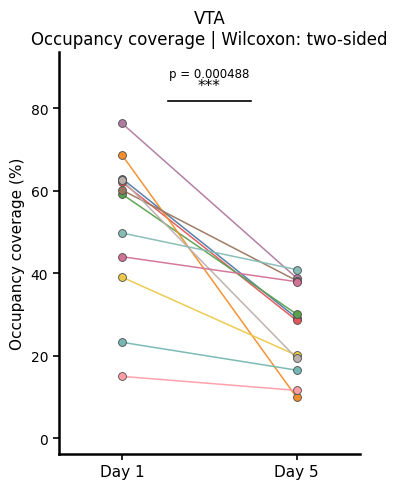

In [ ]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flexible genotype:
# Paired comparison for exploration metrics
#
# Metrics:
#   total_dist
#       = total distance travelled across the whole trial
#
#   occupancy_coverage_cm2
#       = area of arena covered, in cm²
#
#   occupancy_coverage_pct
#       = percentage of valid arena bins visited
#
# COMPARE_MODE:
#   'day1_vs_test':
#       Day 1 = trial 1 only
#       Test  = first post-learning test trial only
#
#   'day1_vs_day5':
#       Day 1 = mean across available Day 1 trials
#       Day 5 = mean across available Day 5 trials
#
#   'day1_trial1_vs_day5_trial1':
#       Day 1 = trial 1 only
#       Day 5 = trial 1 only
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_vs_day5'
# COMPARE_MODE = 'day1_vs_day5'
# COMPARE_MODE = 'day1_trial1_vs_day5_trial1'

GENOTYPE_TO_USE = 'ChR2'

PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False
SHOW_ANIMAL_IDS = False

EXCLUDE_ID = ['BQ', 'BP']
EXCLUDE_SUBS = []

# ------------------------------------------------------------
# Choose exploration metric
# ------------------------------------------------------------
VALUE_COL = 'occupancy_coverage_pct'
# VALUE_COL = 'occupancy_coverage_cm2'
# VALUE_COL = 'occupancy_coverage_pct'

METRIC_INFO = {
    'total_dist': {
        'label': 'Total distance travelled (cm)',
        'title': 'Total distance travelled'
    },
    'occupancy_coverage_cm2': {
        'label': 'Occupancy coverage (cm²)',
        'title': 'Occupancy coverage'
    },
    'occupancy_coverage_pct': {
        'label': 'Occupancy coverage (%)',
        'title': 'Occupancy coverage'
    },
}

if VALUE_COL not in METRIC_INFO:
    raise ValueError(
        "VALUE_COL must be one of: "
        "'total_dist', 'occupancy_coverage_cm2', 'occupancy_coverage_pct'"
    )

VALUE_LABEL = METRIC_INFO[VALUE_COL]['label']
VALUE_TITLE = METRIC_INFO[VALUE_COL]['title']

# Optional short-duration filter
FILTER_SHORT_DURATION = False

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether y1 > y2
# 'less'      = tests whether y1 < y2
WILCOXON_ALTERNATIVE = 'two-sided'

INDIVIDUAL_COLOR_MODE = 'pastel'
DOT_EDGE = True

YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Check required columns
# ------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    VALUE_COL,
]

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(
        f"Missing columns in metadata: {missing_cols}\n"
        f"Make sure you ran the exploration metric computation code first."
    )

# ------------------------------------------------------------
# 2) Filter
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 3) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 4) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using column:", VALUE_COL)
print("Using label:", VALUE_LABEL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 5) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    """
    One value per animal = mean across available trials in that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(np.nanmean(by_trial.values)),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day, value_col):
    """
    One value per animal = trial 1 only from that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 6) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 6, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    comparison_description = 'Day 1 trial 1 vs Test trial 1'

elif COMPARE_MODE == 'day1_vs_day5':
    day1_df = per_subject_day_mean(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_mean(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1'
    right_label = 'Day 5'
    comparison_description = 'Day 1 daily mean vs Day 5 daily mean'

elif COMPARE_MODE == 'day1_trial1_vs_day5_trial1':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Day 5 trial 1'
    comparison_description = 'Day 1 trial 1 vs Day 5 trial 1'

else:
    raise ValueError(
        "COMPARE_MODE must be 'day1_vs_test', "
        "'day1_vs_day5', or 'day1_trial1_vs_day5_trial1'"
    )

title_txt = f'{GENOTYPE_LABEL}'

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
if len(paired) > 0:
    paired_print = paired.copy()
    paired_print['diff_y2_minus_y1'] = paired_print['y2'] - paired_print['y1']
    print(paired_print[['sub', 'id', 'y1', 'y2', 'diff_y2_minus_y1', 'n1', 'n2']])
else:
    print("No paired data.")

# ------------------------------------------------------------
# 7) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.3g}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)

print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")
print(comparison_description)

# ------------------------------------------------------------
# 8) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 9) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

x1, x2 = 0.00, 0.55

n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'], row['y2']],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'], row['y2']],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'],
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

if PLOT_GROUP_MEAN and len(y1) > 0:
    m1 = np.nanmean(y1)
    m2 = np.nanmean(y2)

    s1 = 0.0 if len(y1) <= 1 else np.nanstd(y1, ddof=1) / np.sqrt(len(y1))
    s2 = 0.0 if len(y2) <= 1 else np.nanstd(y2, ddof=1) / np.sqrt(len(y2))

    ax.plot([x1, x2], [m1, m2], '-', color=base_col, linewidth=2.4, zorder=3)

    ax.errorbar(
        x1, m1, yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2, m2, yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Significance line + stars + p value
# ------------------------------------------------------------
all_y = np.r_[y1, y2]

if len(all_y) > 0 and np.isfinite(all_y).any():
    ymax_data = np.nanmax(all_y)
    ymin_data = np.nanmin(all_y)
    yrng = ymax_data - ymin_data

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = ymax_data if ymax_data > 0 else 1.0

    y_line = ymax_data + 0.08 * yrng
    y_star = ymax_data + 0.11 * yrng
    y_pval = ymax_data + 0.16 * yrng
else:
    ymax_data = 1.0
    yrng = 1.0
    y_line = 1.08
    y_star = 1.11
    y_pval = 1.16

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel(VALUE_LABEL, fontsize=11)

ax.set_title(
    f'{title_txt}\n{VALUE_TITLE} | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is not None:
    ymax = YMAX
else:
    ymax = y_pval + 0.10 * yrng

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()

# CIPL, path efficiency

In [ ]:
# old version for CIPL
import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ============================================================
# Existing / original per-trial metrics
# These keep the same names as before.
# ============================================================

metadata['dist_to_trigger'] = np.nan

# These are based on the first qualifying trigger zone entered,
# or, if no trigger is entered, the nearest trigger to the start.
metadata['first_choice_trigger'] = np.nan
metadata['L_actual']             = np.nan
metadata['L_shortest']           = np.nan
metadata['CIPL']                 = np.nan
metadata['path_eff']             = np.nan

R_TRIGGER = (10 / 1.2)

# --- SETTINGS you can comment/uncomment ---
REQUIRE_STAY_2S = False           # False → any entry; True → require ≥2 s stay
MIN_DUR_MS      = 2000           # min duration threshold in ms
# -----------------------------------------

STAY_TAG = '≥2 s stay' if REQUIRE_STAY_2S else 'all visits'

# ============================================================
# New long-format per-trigger output
# One row per trial × trigger.
# ============================================================

cipl_rows = []


# ============================================================
# Helper functions
# ============================================================

def get_start_xy(pos_):
    """Return starting x/y coordinates."""
    x0 = float(pos_['x'].iloc[0])
    y0 = float(pos_['y'].iloc[0])
    return x0, y0


def get_full_distance(pos_):
    """Return full trial path length from cumulative distance."""
    if 'cum_dist' not in pos_.columns or len(pos_) == 0:
        return np.nan

    full_dist = float(pos_['cum_dist'].iloc[-1])

    if not np.isfinite(full_dist):
        return np.nan

    return full_dist


def get_trigger_centres(triggerLoc):
    """Return trigger centre coordinates as array: n_triggers × 2."""
    return np.array([
        [float(triggerLoc.iloc[i]['x']), float(triggerLoc.iloc[i]['y'])]
        for i in range(len(triggerLoc))
    ], dtype=float)


def shortest_distance_to_trigger_edge(x0, y0, triggerLoc, trig_id):
    """
    Straight-line distance from start to edge of trigger trig_id.
    trig_id is 1-based.
    """
    cx = float(triggerLoc.iloc[trig_id - 1]['x'])
    cy = float(triggerLoc.iloc[trig_id - 1]['y'])

    dx = cx - x0
    dy = cy - y0

    d_center = np.sqrt(dx * dx + dy * dy)

    L_shortest = max(d_center - R_TRIGGER, 0.0)

    return float(L_shortest)


def actual_distance_until_time(pos_, t_enter):
    """
    Distance travelled up to t_enter.

    Uses the last sample where pos_['t'] <= t_enter.
    """
    if 't' not in pos_.columns or 'cum_dist' not in pos_.columns:
        return np.nan

    idxs = np.where(pos_['t'].values <= t_enter)[0]

    if len(idxs) == 0:
        return 0.0

    L_actual = float(pos_['cum_dist'].iloc[idxs[-1]])

    if not np.isfinite(L_actual):
        return np.nan

    return L_actual


def compute_cipl_and_eff(L_actual, L_shortest):
    """Compute CIPL and path efficiency."""
    if np.isfinite(L_actual) and np.isfinite(L_shortest):
        CIPL = L_actual - L_shortest
    else:
        CIPL = np.nan

    if np.isfinite(L_actual) and L_actual > 0 and np.isfinite(L_shortest):
        path_eff = (L_shortest / L_actual) * 100.0
    else:
        path_eff = np.nan

    return CIPL, path_eff


def compute_trigger_metric_from_entry(pos_, triggerLoc, trig_id, df_use, full_dist, x0, y0):
    """
    Compute one separate CIPL/path_eff value for one trigger in one trial.

    Logic:
      - If this specific trigger has a qualifying entry:
            L_actual = distance travelled up to first qualifying entry into this trigger
            L_shortest = straight-line start → edge of this trigger
      - If this specific trigger has no qualifying entry:
            L_actual = full trial distance
            L_shortest = straight-line start → edge of this trigger

    This means every trigger gets a value for every trial.
    """
    df_t = df_use[df_use['trigger_id'] == trig_id].copy()

    L_shortest_trig = shortest_distance_to_trigger_edge(
        x0=x0,
        y0=y0,
        triggerLoc=triggerLoc,
        trig_id=trig_id
    )

    if len(df_t) == 0:
        reached_trigger_trig = False
        t_enter_trigger_trig = np.nan
        L_actual_trig = full_dist

    else:
        first_entry_t = df_t.sort_values('t_enter').iloc[0]
        t_enter_trigger_trig = float(first_entry_t['t_enter'])
        reached_trigger_trig = True

        L_actual_trig = actual_distance_until_time(
            pos_=pos_,
            t_enter=t_enter_trigger_trig
        )

    CIPL_trig, path_eff_trig = compute_cipl_and_eff(
        L_actual=L_actual_trig,
        L_shortest=L_shortest_trig
    )

    return {
        'L_actual_trig': L_actual_trig,
        'L_shortest_trig': L_shortest_trig,
        'CIPL_trig': CIPL_trig,
        'path_eff_trig': path_eff_trig,
        'reached_trigger_trig': reached_trigger_trig,
        't_enter_trigger_trig': t_enter_trigger_trig,
    }


# ============================================================
# Main loop
# ============================================================

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # --------------------------------------------------------
    # Load position
    # --------------------------------------------------------
    position = dl.get_data('position')

    if position is None or len(position) == 0:
        continue

    if ('x' not in position.columns) or ('y' not in position.columns):
        continue

    # --------------------------------------------------------
    # Load trigger locations
    # --------------------------------------------------------
    triggerLoc = dl.get_data('triggerLoc')

    if triggerLoc is None or len(triggerLoc) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    trigger_num = len(triggerLoc)

    # --------------------------------------------------------
    # Add cumulative distance
    # --------------------------------------------------------
    pos = add_distance_travelled(position)

    if pos is None or len(pos) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    if 'cum_dist' not in pos.columns:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    # --------------------------------------------------------
    # Add distance-to-trigger columns
    # --------------------------------------------------------
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    if pos_ is None or len(pos_) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    # --------------------------------------------------------
    # Common quantities for this trial
    # --------------------------------------------------------
    full_dist = get_full_distance(pos_)

    if not np.isfinite(full_dist):
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    x0, y0 = get_start_xy(pos_)

    trigger_centres = get_trigger_centres(triggerLoc)

    dx_start = trigger_centres[:, 0] - x0
    dy_start = trigger_centres[:, 1] - y0
    d_center_start = np.sqrt(dx_start * dx_start + dy_start * dy_start)

    nearest_idx = int(np.argmin(d_center_start))
    nearest_trigger = nearest_idx + 1

    # --------------------------------------------------------
    # Build trigger-interaction dataframe
    # --------------------------------------------------------
    dfs = []

    for i in range(trigger_num):
        df_trig = get_interaction_with_trigger_df(
            pos_,
            R_TRIGGER,
            ti=i + 1
        )

        if df_trig is None or len(df_trig) == 0:
            continue

        df_trig = df_trig.copy()
        df_trig['trigger_id'] = i + 1
        dfs.append(df_trig)

    # --------------------------------------------------------
    # Determine qualifying entries.
    #
    # df_use contains all qualifying entries across all triggers.
    # This is used for:
    #   1) original first-choice metric
    #   2) per-trigger metrics
    # --------------------------------------------------------
    if len(dfs) == 0:
        df_all = pd.DataFrame(columns=['t_enter', 'duration', 'trigger_id'])
        df_use = df_all.copy()

    else:
        df_all = (
            pd.concat(dfs, ignore_index=True)
            .sort_values('t_enter')
            .reset_index(drop=True)
        )

        if REQUIRE_STAY_2S:
            df_use = df_all[df_all['duration'] >= MIN_DUR_MS].copy()
        else:
            df_use = df_all.copy()

        df_use = df_use.sort_values('t_enter').reset_index(drop=True)

    # ========================================================
    # A) ORIGINAL METRIC:
    #    First qualifying trigger zone entered.
    #
    # Keep this logic/output names the same as your existing code.
    # ========================================================

    if len(df_use) == 0:
        # No qualifying trigger entry anywhere.
        # Original logic:
        #   L_actual = full trial distance
        #   choose nearest trigger for L_shortest
        trig_first = nearest_trigger

        L_actual = full_dist
        L_shortest = shortest_distance_to_trigger_edge(
            x0=x0,
            y0=y0,
            triggerLoc=triggerLoc,
            trig_id=trig_first
        )

    else:
        # First qualifying entry into any trigger.
        first_entry = df_use.iloc[0]
        t_enter_first = float(first_entry['t_enter'])
        trig_first = int(first_entry['trigger_id'])

        L_actual = actual_distance_until_time(
            pos_=pos_,
            t_enter=t_enter_first
        )

        L_shortest = shortest_distance_to_trigger_edge(
            x0=x0,
            y0=y0,
            triggerLoc=triggerLoc,
            trig_id=trig_first
        )

    CIPL, path_eff = compute_cipl_and_eff(
        L_actual=L_actual,
        L_shortest=L_shortest
    )

    # Store original variables
    metadata.at[trial_id, 'dist_to_trigger']      = L_actual
    metadata.at[trial_id, 'first_choice_trigger'] = trig_first
    metadata.at[trial_id, 'L_actual']             = L_actual
    metadata.at[trial_id, 'L_shortest']           = L_shortest
    metadata.at[trial_id, 'CIPL']                 = CIPL
    metadata.at[trial_id, 'path_eff']             = path_eff

    # ========================================================
    # B) NEW PER-TRIGGER METRICS:
    #    One CIPL / path_eff value per trigger per trial.
    #
    # Important:
    #   This does NOT replace the original variables above.
    #
    # For each trigger:
    #   - if this trigger was reached with the selected criterion:
    #       use distance to first qualifying entry into this trigger
    #   - if this trigger was not reached:
    #       use full-trial distance
    #   - L_shortest is always start → edge of THIS trigger
    # ========================================================

    for trig_id in range(1, trigger_num + 1):
        trig_metrics = compute_trigger_metric_from_entry(
            pos_=pos_,
            triggerLoc=triggerLoc,
            trig_id=trig_id,
            df_use=df_use,
            full_dist=full_dist,
            x0=x0,
            y0=y0
        )

        # Wide columns in metadata
        metadata.at[trial_id, f'L_actual_trigger_{trig_id}'] = trig_metrics['L_actual_trig']
        metadata.at[trial_id, f'L_shortest_trigger_{trig_id}'] = trig_metrics['L_shortest_trig']
        metadata.at[trial_id, f'CIPL_trigger_{trig_id}'] = trig_metrics['CIPL_trig']
        metadata.at[trial_id, f'path_eff_trigger_{trig_id}'] = trig_metrics['path_eff_trig']
        metadata.at[trial_id, f'reached_trigger_{trig_id}'] = trig_metrics['reached_trigger_trig']
        metadata.at[trial_id, f't_enter_trigger_{trig_id}'] = trig_metrics['t_enter_trigger_trig']

        # Long-format table
        cipl_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,

            'L_actual_trig': trig_metrics['L_actual_trig'],
            'L_shortest_trig': trig_metrics['L_shortest_trig'],
            'CIPL_trig': trig_metrics['CIPL_trig'],
            'path_eff_trig': trig_metrics['path_eff_trig'],

            'reached_trigger_trig': trig_metrics['reached_trigger_trig'],
            't_enter_trigger_trig': trig_metrics['t_enter_trigger_trig'],

            # useful diagnostics
            'first_choice_trigger_original': trig_first,
            'CIPL_original_first_choice': CIPL,
            'path_eff_original_first_choice': path_eff,
        })


# ============================================================
# Build long-format dataframe:
# one row per trial × trigger, with metadata attached.
# ============================================================

df_cipl = pd.DataFrame(cipl_rows)

if len(df_cipl) > 0:
    meta_cipl = df_cipl.merge(
        metadata,
        left_on='trial_id',
        right_index=True,
        how='left'
    )
else:
    meta_cipl = pd.DataFrame()


# ============================================================
# Quick checks
# ============================================================

print("\n============================================================")
print("CIPL / path-eff computation complete")
print("Computed using:", STAY_TAG)
print("REQUIRE_STAY_2S:", REQUIRE_STAY_2S)
print("MIN_DUR_MS:", MIN_DUR_MS)
print("============================================================")

print("\nOriginal first-choice columns:")
display_cols_original = [
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'dist_to_trigger',
    'first_choice_trigger',
    'L_actual',
    'L_shortest',
    'CIPL',
    'path_eff',
]

display(metadata[display_cols_original].head())

print("\nNew per-trigger long-format table:")
if len(meta_cipl) > 0:
    display_cols_trig = [
        'trial_id',
        'sub',
        'id',
        'ses',
        'trial_type',
        'trial_type_day',
        'trigger_id',
        'L_actual_trig',
        'L_shortest_trig',
        'CIPL_trig',
        'path_eff_trig',
        'reached_trigger_trig',
        't_enter_trigger_trig',
        'first_choice_trigger_original',
    ]

    display(meta_cipl[display_cols_trig].head(30))
else:
    print("meta_cipl is empty.")

 11%|█         | 712/6611 [00:08<00:59, 98.49it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1175/6611 [00:14<01:08, 79.16it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 39%|███▉      | 2591/6611 [00:29<00:41, 97.86it/s] 

...

100%|██████████| 6611/6611 [01:11<00:00, 93.02it/s] 


CIPL / path-eff computation complete
Computed using: all visits
REQUIRE_STAY_2S: False
MIN_DUR_MS: 2000

Original first-choice columns:


,sub,id,ses,trial_type,trial_type_day,dist_to_trigger,first_choice_trigger,L_actual,L_shortest,CIPL,path_eff
0,1,A,1,H,1,21.004940,5.0,21.004940,2.704986,18.299953,12.877858
1,1,A,1,H,1,121.123247,3.0,121.123247,63.736658,57.386590,52.621325
2,1,A,1,H,1,4.226850,5.0,4.226850,3.492875,0.733975,82.635420
3,1,A,1,H,1,7.878806,5.0,7.878806,5.881602,1.997203,74.650938
4,1,A,1,H,1,132.454986,4.0,132.454986,45.804395,86.650591,34.581103



New per-trigger long-format table:


,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,L_actual_trig,L_shortest_trig,CIPL_trig,path_eff_trig,reached_trigger_trig,t_enter_trigger_trig,first_choice_trigger_original
0,0,1,A,1,H,1,1,730.403192,66.839431,663.563761,9.151032,True,62604.0,5
1,0,1,A,1,H,1,2,369.963512,33.772777,336.190735,9.128678,True,28127.0,5
2,0,1,A,1,H,1,3,159.440153,76.875026,82.565127,48.215600,True,13197.0,5
3,0,1,A,1,H,1,4,1915.503055,34.892174,1880.610881,1.821567,True,240327.0,5
4,0,1,A,1,H,1,5,21.004940,2.704986,18.299953,12.877858,True,3809.0,5
5,0,1,A,1,H,1,6,1016.155567,46.121460,970.034107,4.538819,True,96754.0,5
6,0,1,A,1,H,1,7,809.634933,69.610650,740.024283,8.597782,True,70142.0,5
7,0,1,A,1,H,1,8,281.639176,34.708327,246.930849,12.323686,True,22064.0,5
8,1,1,A,1,H,1,1,144.296983,75.814178,68.482806,52.540376,True,22613.0,3
9,1,1,A,1,H,1,2,215.035375,75.196563,139.838812,34.969392,True,33656.0,3


In [451]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# Load metadata
# ============================================================

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)


# ============================================================
# Distance units
# ============================================================
# Your coordinate system uses:
#     1 coordinate unit = 1.2 cm
#
# All stored path/distance metrics in this code are converted to cm:
#     dist_to_trigger
#     L_actual
#     L_shortest
#     CIPL
#     L_actual_trigger_*
#     L_shortest_trigger_*
#     CIPL_trigger_*
#     L_actual_trig
#     L_shortest_trig
#     CIPL_trig
#
# path_eff / path_eff_trig remain percentages.
#
# entry_x / entry_y values remain original position coordinates.

DISTANCE_UNIT_TO_CM = 1.2

# Reward-zone radius:
#   10 cm radius expressed in original coordinate units for
#   interaction detection and geometric boundary interpolation.
R_TRIGGER_CM = 10.0
R_TRIGGER = R_TRIGGER_CM / DISTANCE_UNIT_TO_CM

metadata['distance_unit'] = 'cm'


# ============================================================
# Original per-trial metrics
#
# These are based on:
#   - first qualifying trigger entered, OR
#   - if no qualifying trigger is reached anywhere, nearest trigger
#     from the starting position.
#
# DISTANCE COLUMNS BELOW ARE STORED IN CM.
# ============================================================

metadata['dist_to_trigger'] = np.nan

metadata['first_choice_trigger'] = np.nan
metadata['L_actual']             = np.nan      # cm
metadata['L_shortest']           = np.nan      # cm
metadata['CIPL']                 = np.nan      # cm
metadata['path_eff']             = np.nan      # %

# Useful diagnostic columns for the original first-choice metric
metadata['reached_first_choice_trigger'] = np.nan
metadata['t_enter_first_choice_trigger'] = np.nan

# Optional geometric entry-coordinate diagnostics for original metric.
# These remain in original coordinate-space units, not cm distances.
metadata['entry_x_first_choice'] = np.nan
metadata['entry_y_first_choice'] = np.nan


# ============================================================
# SETTINGS
# ============================================================

# Entry criterion:
#   False -> any entry into the reward zone qualifies
#   True  -> only an entry followed by a stay of at least MIN_DUR_MS qualifies
REQUIRE_STAY_2S = True
MIN_DUR_MS = 2000

STAY_TAG = '≥2 s stay' if REQUIRE_STAY_2S else 'all visits'


# ------------------------------------------------------------
# What to do for an unreached trigger in the separate
# per-trigger analysis.
#
# 'full_path':
#     Preserve your previous behaviour.
#     If a trigger is not reached:
#         L_actual_trig = total path travelled during full trial, in cm
#         CIPL_trig = full path - shortest path to that trigger, in cm
#         path_eff_trig = shortest path / full path * 100
#
#     Important:
#         For an unreached trigger, this is a fallback value rather
#         than a pure reached-zone path-efficiency measurement.
#
# 'nan':
#     If a trigger is not reached:
#         L_actual_trig = NaN
#         CIPL_trig = NaN
#         path_eff_trig = NaN
#
#     L_shortest_trig is retained in cm because it is geometrically
#     defined even when the zone is not reached.
# ------------------------------------------------------------

UNREACHED_ZONE_MODE = 'full_path'
# UNREACHED_ZONE_MODE = 'nan'

VALID_UNREACHED_ZONE_MODES = ['full_path', 'nan']

if UNREACHED_ZONE_MODE not in VALID_UNREACHED_ZONE_MODES:
    raise ValueError(
        f"UNREACHED_ZONE_MODE must be one of {VALID_UNREACHED_ZONE_MODES}"
    )


# ------------------------------------------------------------
# Optional rule for the ORIGINAL first-choice metric.
#
# False:
#     Keep previous behaviour:
#     when no qualifying trigger is reached anywhere, use full
#     travelled path and nearest trigger from the start.
#
# True:
#     If no qualifying trigger is reached anywhere and
#     UNREACHED_ZONE_MODE == 'nan', set original
#     L_actual / CIPL / path_eff to NaN as well.
#
# Default False preserves the previous original-metric logic.
# ------------------------------------------------------------

APPLY_UNREACHED_MODE_TO_ORIGINAL_FIRST_CHOICE = False


# ============================================================
# Long-format per-trigger output
#
# One row per trial × trigger.
# ============================================================

cipl_rows = []


# ============================================================
# Helper functions
# ============================================================

def prepare_position_for_geometric_distance(position):
    """
    Prepare position dataframe for geometric path-length calculations.

    Cumulative travelled distance is calculated from the first valid
    detected position using Euclidean distances between consecutive
    detected positions.

    Both original-coordinate and cm cumulative distances are stored:

        cum_dist_geom_coord
            cumulative path length in original coordinate units

        cum_dist_geom_cm
            cumulative path length in centimetres

    Returns
    -------
    pos : pandas.DataFrame or None
    """
    if position is None or len(position) == 0:
        return None

    required_cols = ['x', 'y', 't']
    missing = [c for c in required_cols if c not in position.columns]

    if len(missing) > 0:
        return None

    pos = position.copy()

    valid = (
        np.isfinite(pos['x'].values.astype(float)) &
        np.isfinite(pos['y'].values.astype(float)) &
        np.isfinite(pos['t'].values.astype(float))
    )

    pos = pos[valid].copy()

    if len(pos) == 0:
        return None

    pos = pos.sort_values('t').reset_index(drop=True)

    x = pos['x'].values.astype(float)
    y = pos['y'].values.astype(float)

    if len(pos) == 1:
        pos['cum_dist_geom_coord'] = np.array([0.0], dtype=float)
        pos['cum_dist_geom_cm'] = np.array([0.0], dtype=float)
        return pos

    dx = np.diff(x)
    dy = np.diff(y)

    step_dist_coord = np.sqrt(dx * dx + dy * dy)
    step_dist_cm = step_dist_coord * DISTANCE_UNIT_TO_CM

    cum_dist_geom_coord = np.concatenate([
        np.array([0.0], dtype=float),
        np.cumsum(step_dist_coord)
    ])

    cum_dist_geom_cm = np.concatenate([
        np.array([0.0], dtype=float),
        np.cumsum(step_dist_cm)
    ])

    pos['cum_dist_geom_coord'] = cum_dist_geom_coord
    pos['cum_dist_geom_cm'] = cum_dist_geom_cm

    return pos


def get_start_xy(pos_):
    """
    Return coordinates of the first valid detected animal position.

    Coordinates remain in original coordinate-space units.
    """
    x0 = float(pos_['x'].iloc[0])
    y0 = float(pos_['y'].iloc[0])

    return x0, y0


def get_full_distance_cm(pos_):
    """
    Return full-trial geometric path length in cm from the first valid
    detected position to the final valid detected position.
    """
    if pos_ is None or len(pos_) == 0:
        return np.nan

    if 'cum_dist_geom_cm' not in pos_.columns:
        return np.nan

    full_dist_cm = float(pos_['cum_dist_geom_cm'].iloc[-1])

    if not np.isfinite(full_dist_cm):
        return np.nan

    return full_dist_cm


def get_trigger_centres(triggerLoc):
    """
    Return trigger-centre coordinates in original coordinate-space units.

    Shape:
        n_triggers × 2
    """
    return np.array([
        [
            float(triggerLoc.iloc[i]['x']),
            float(triggerLoc.iloc[i]['y'])
        ]
        for i in range(len(triggerLoc))
    ], dtype=float)


def shortest_distance_to_trigger_edge_cm(x0, y0, triggerLoc, trig_id):
    """
    Straight-line distance from the starting detected position to the
    nearest edge of trigger zone trig_id.

    trig_id is 1-based.

    Geometric calculation is first performed in original coordinate
    units because trigger coordinates and R_TRIGGER are defined there.
    The returned distance is converted to cm.

    If the animal begins inside the zone, shortest distance is 0 cm.
    """
    cx = float(triggerLoc.iloc[trig_id - 1]['x'])
    cy = float(triggerLoc.iloc[trig_id - 1]['y'])

    dx = cx - x0
    dy = cy - y0

    distance_to_centre_coord = np.sqrt(dx * dx + dy * dy)

    L_shortest_coord = max(
        distance_to_centre_coord - R_TRIGGER,
        0.0
    )

    L_shortest_cm = L_shortest_coord * DISTANCE_UNIT_TO_CM

    return float(L_shortest_cm)


def find_first_inside_index_for_entry(pos_, triggerLoc, trig_id, t_enter):
    """
    Find the first position sample belonging to the visit beginning
    at t_enter.

    Returns
    -------
    inside_idx : int or None
        Index of first detected position sample inside the selected
        reward zone for this entry event.
    """
    if pos_ is None or len(pos_) == 0:
        return None

    t = pos_['t'].values.astype(float)
    x = pos_['x'].values.astype(float)
    y = pos_['y'].values.astype(float)

    cx = float(triggerLoc.iloc[trig_id - 1]['x'])
    cy = float(triggerLoc.iloc[trig_id - 1]['y'])

    dist_to_centre = np.sqrt(
        (x - cx) ** 2 +
        (y - cy) ** 2
    )

    inside = dist_to_centre <= R_TRIGGER

    if not np.any(inside):
        return None

    # Normal case:
    # t_enter corresponds to, or occurs immediately before,
    # the first detected sample inside the zone.
    candidate_idxs = np.where(
        inside &
        np.isfinite(t) &
        (t >= float(t_enter))
    )[0]

    if len(candidate_idxs) > 0:
        inside_idx = int(candidate_idxs[0])

    else:
        # Fallback for small timestamp mismatch.
        inside_idxs = np.where(inside)[0]

        if len(inside_idxs) == 0:
            return None

        closest = np.argmin(
            np.abs(t[inside_idxs] - float(t_enter))
        )

        inside_idx = int(inside_idxs[closest])

    # Walk backwards through a continuous in-zone period.
    while inside_idx > 0 and inside[inside_idx - 1]:
        inside_idx -= 1

    return inside_idx


def boundary_crossing_fraction(p_out, p_in, centre, radius):
    """
    Calculate the fraction along an outside-to-inside movement segment
    at which the trajectory crosses the circular reward-zone boundary.

    Inputs are in original coordinate-space units.

    Segment:
        p(alpha) = p_out + alpha * (p_in - p_out)

    Returns
    -------
    alpha : float
        Fraction of the segment travelled before reaching the zone edge.
    """
    p_out = np.asarray(p_out, dtype=float)
    p_in = np.asarray(p_in, dtype=float)
    centre = np.asarray(centre, dtype=float)

    direction = p_in - p_out

    a = np.dot(direction, direction)

    if not np.isfinite(a) or a <= 0:
        return 0.0

    relative_start = p_out - centre

    b = 2.0 * np.dot(relative_start, direction)
    c = np.dot(relative_start, relative_start) - radius ** 2

    discriminant = b ** 2 - 4.0 * a * c

    if not np.isfinite(discriminant):
        return np.nan

    # Tiny negative values can occur due to floating-point rounding.
    if discriminant < 0 and discriminant > -1e-10:
        discriminant = 0.0

    if discriminant < 0:
        return np.nan

    sqrt_disc = np.sqrt(discriminant)

    alpha_1 = (-b - sqrt_disc) / (2.0 * a)
    alpha_2 = (-b + sqrt_disc) / (2.0 * a)

    valid_alphas = [
        alpha
        for alpha in [alpha_1, alpha_2]
        if np.isfinite(alpha) and -1e-9 <= alpha <= 1 + 1e-9
    ]

    if len(valid_alphas) == 0:
        return np.nan

    # For an outside-to-inside movement, the first valid
    # intersection is the entry boundary crossing.
    alpha = min(valid_alphas)

    alpha = min(max(alpha, 0.0), 1.0)

    return float(alpha)


def geometric_actual_distance_to_zone_edge_cm(
    pos_,
    triggerLoc,
    trig_id,
    t_enter
):
    """
    Calculate actual path length in cm from the first valid detected
    animal position to the interpolated point where its trajectory
    enters the edge of reward zone trig_id.

    Geometry/intersection is calculated in original coordinate units.
    Travelled path length is returned in cm.

    Returns
    -------
    L_actual_cm : float
        Cumulative geometric travelled distance to zone boundary, in cm.

    entry_x : float
        Interpolated boundary-crossing x coordinate in original
        coordinate-space units.

    entry_y : float
        Interpolated boundary-crossing y coordinate in original
        coordinate-space units.
    """
    if pos_ is None or len(pos_) == 0:
        return np.nan, np.nan, np.nan

    if 'cum_dist_geom_cm' not in pos_.columns:
        return np.nan, np.nan, np.nan

    inside_idx = find_first_inside_index_for_entry(
        pos_=pos_,
        triggerLoc=triggerLoc,
        trig_id=trig_id,
        t_enter=t_enter
    )

    if inside_idx is None:
        return np.nan, np.nan, np.nan

    x = pos_['x'].values.astype(float)
    y = pos_['y'].values.astype(float)
    cum_dist_cm = pos_['cum_dist_geom_cm'].values.astype(float)

    cx = float(triggerLoc.iloc[trig_id - 1]['x'])
    cy = float(triggerLoc.iloc[trig_id - 1]['y'])

    centre = np.array([cx, cy], dtype=float)

    # If the animal is first detected already inside the reward zone,
    # travelled distance to that detected entry is defined as 0 cm.
    if inside_idx == 0:
        return 0.0, float(x[0]), float(y[0])

    outside_idx = inside_idx - 1

    p_out = np.array(
        [x[outside_idx], y[outside_idx]],
        dtype=float
    )

    p_in = np.array(
        [x[inside_idx], y[inside_idx]],
        dtype=float
    )

    alpha = boundary_crossing_fraction(
        p_out=p_out,
        p_in=p_in,
        centre=centre,
        radius=R_TRIGGER
    )

    if not np.isfinite(alpha):
        # Conservative fallback:
        # use distance at the first detected in-zone point.
        L_actual_cm = float(cum_dist_cm[inside_idx])

        return (
            L_actual_cm,
            float(x[inside_idx]),
            float(y[inside_idx])
        )

    segment_length_coord = float(
        np.sqrt(np.sum((p_in - p_out) ** 2))
    )

    segment_length_cm = segment_length_coord * DISTANCE_UNIT_TO_CM

    L_before_segment_cm = float(cum_dist_cm[outside_idx])

    L_actual_cm = (
        L_before_segment_cm +
        alpha * segment_length_cm
    )

    entry_point = p_out + alpha * (p_in - p_out)

    return (
        float(L_actual_cm),
        float(entry_point[0]),
        float(entry_point[1])
    )


def compute_cipl_and_eff(L_actual_cm, L_shortest_cm, reached=True):
    """
    Compute extra distance travelled and path efficiency.

    Parameters
    ----------
    L_actual_cm : float
        Actual travelled distance in cm.

    L_shortest_cm : float
        Shortest possible distance to reward-zone edge in cm.

    reached : bool
        Whether the trigger was genuinely reached.

    Returns
    -------
    CIPL_cm : float
        Extra distance travelled in cm.

    path_eff : float
        Path efficiency in percent.
    """
    if not (
        np.isfinite(L_actual_cm) and
        np.isfinite(L_shortest_cm)
    ):
        return np.nan, np.nan

    CIPL_cm = float(L_actual_cm - L_shortest_cm)

    # Remove negligible negative error caused only by numerical precision.
    if reached and CIPL_cm < 0 and abs(CIPL_cm) < 1e-8:
        CIPL_cm = 0.0
        L_actual_cm = float(L_shortest_cm)

    if L_actual_cm > 0:
        path_eff = float(
            (L_shortest_cm / L_actual_cm) * 100.0
        )
    else:
        path_eff = np.nan

    return CIPL_cm, path_eff


def get_unreached_trigger_values(full_dist_cm, L_shortest_trig_cm):
    """
    Apply selected fallback rule for a trigger that was not reached.

    Returns
    -------
    L_actual_trig_cm : float
    CIPL_trig_cm : float
    path_eff_trig : float
    """
    if UNREACHED_ZONE_MODE == 'full_path':

        L_actual_trig_cm = full_dist_cm

        CIPL_trig_cm, path_eff_trig = compute_cipl_and_eff(
            L_actual_cm=L_actual_trig_cm,
            L_shortest_cm=L_shortest_trig_cm,
            reached=False
        )

    elif UNREACHED_ZONE_MODE == 'nan':

        L_actual_trig_cm = np.nan
        CIPL_trig_cm = np.nan
        path_eff_trig = np.nan

    else:
        raise ValueError(
            f"Unknown UNREACHED_ZONE_MODE: {UNREACHED_ZONE_MODE}"
        )

    return L_actual_trig_cm, CIPL_trig_cm, path_eff_trig


def compute_trigger_metric_from_entry(
    pos_,
    triggerLoc,
    trig_id,
    df_use,
    full_dist_cm,
    x0,
    y0
):
    """
    Compute one separate CIPL/path-efficiency value for one trigger
    in one trial.

    Reached trigger:
      - L_actual_trig is geometric travelled distance from the
        first detected position to the interpolated boundary crossing,
        in cm.

      - L_shortest_trig is straight-line distance from the same start
        position to the nearest edge of this trigger zone, in cm.

      - CIPL_trig is in cm.

      - path_eff_trig is in percent.

    Unreached trigger:
      - Behaviour is controlled by UNREACHED_ZONE_MODE.
    """
    df_t = df_use[
        df_use['trigger_id'] == trig_id
    ].copy()

    L_shortest_trig_cm = shortest_distance_to_trigger_edge_cm(
        x0=x0,
        y0=y0,
        triggerLoc=triggerLoc,
        trig_id=trig_id
    )

    if len(df_t) == 0:

        reached_trigger_trig = False
        t_enter_trigger_trig = np.nan

        (
            L_actual_trig_cm,
            CIPL_trig_cm,
            path_eff_trig
        ) = get_unreached_trigger_values(
            full_dist_cm=full_dist_cm,
            L_shortest_trig_cm=L_shortest_trig_cm
        )

        entry_x_trig = np.nan
        entry_y_trig = np.nan

    else:

        first_entry = (
            df_t
            .sort_values('t_enter')
            .iloc[0]
        )

        t_enter_trigger_trig = float(first_entry['t_enter'])
        reached_trigger_trig = True

        (
            L_actual_trig_cm,
            entry_x_trig,
            entry_y_trig
        ) = geometric_actual_distance_to_zone_edge_cm(
            pos_=pos_,
            triggerLoc=triggerLoc,
            trig_id=trig_id,
            t_enter=t_enter_trigger_trig
        )

        CIPL_trig_cm, path_eff_trig = compute_cipl_and_eff(
            L_actual_cm=L_actual_trig_cm,
            L_shortest_cm=L_shortest_trig_cm,
            reached=True
        )

    return {
        'L_actual_trig': L_actual_trig_cm,               # cm
        'L_shortest_trig': L_shortest_trig_cm,           # cm
        'CIPL_trig': CIPL_trig_cm,                       # cm
        'path_eff_trig': path_eff_trig,                  # %

        'reached_trigger_trig': reached_trigger_trig,
        't_enter_trigger_trig': t_enter_trigger_trig,

        # Position coordinates, not distance values.
        'entry_x_trig': entry_x_trig,
        'entry_y_trig': entry_y_trig,

        'distance_unit': 'cm',
        'unreached_zone_mode': UNREACHED_ZONE_MODE,
    }


# ============================================================
# Main loop
# ============================================================

for trial_id in tqdm(range(len(metadata))):

    dl = DataLoader(metadata.iloc[trial_id])

    # --------------------------------------------------------
    # Load position data
    # --------------------------------------------------------

    position = dl.get_data('position')

    if position is None or len(position) == 0:
        continue

    # --------------------------------------------------------
    # Prepare position data with geometric cumulative distance.
    #
    # Distances are calculated from the first valid detected
    # position and stored in centimetres.
    # --------------------------------------------------------

    pos = prepare_position_for_geometric_distance(position)

    if pos is None or len(pos) == 0:
        continue

    # --------------------------------------------------------
    # Load trigger locations
    # --------------------------------------------------------

    triggerLoc = dl.get_data('triggerLoc')

    if triggerLoc is None or len(triggerLoc) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    trigger_num = len(triggerLoc)

    # --------------------------------------------------------
    # Add distance-to-trigger columns required by your existing
    # interaction-detection function.
    #
    # Interaction detection remains in original coordinate units
    # because R_TRIGGER is also in original coordinate units.
    # --------------------------------------------------------

    pos_ = add_dist_to_trigger(
        pos.copy(),
        triggerLoc
    )

    if pos_ is None or len(pos_) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    if 'cum_dist_geom_cm' not in pos_.columns:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    # --------------------------------------------------------
    # Common quantities for this trial
    # --------------------------------------------------------

    full_dist_cm = get_full_distance_cm(pos_)

    if not np.isfinite(full_dist_cm):
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    x0, y0 = get_start_xy(pos_)

    trigger_centres = get_trigger_centres(triggerLoc)

    dx_start = trigger_centres[:, 0] - x0
    dy_start = trigger_centres[:, 1] - y0

    distance_to_centres_from_start = np.sqrt(
        dx_start * dx_start +
        dy_start * dy_start
    )

    nearest_idx = int(
        np.argmin(distance_to_centres_from_start)
    )

    nearest_trigger = nearest_idx + 1

    # --------------------------------------------------------
    # Detect entries into every trigger zone
    # --------------------------------------------------------

    dfs = []

    for i in range(trigger_num):

        df_trig = get_interaction_with_trigger_df(
            pos_,
            R_TRIGGER,
            ti=i + 1
        )

        if df_trig is None or len(df_trig) == 0:
            continue

        df_trig = df_trig.copy()
        df_trig['trigger_id'] = i + 1

        dfs.append(df_trig)

    # --------------------------------------------------------
    # Select qualifying entries:
    #   - all visits, or
    #   - visits lasting at least 2 seconds.
    # --------------------------------------------------------

    if len(dfs) == 0:

        df_all = pd.DataFrame(
            columns=['t_enter', 'duration', 'trigger_id']
        )

        df_use = df_all.copy()

    else:

        df_all = (
            pd.concat(dfs, ignore_index=True)
            .sort_values('t_enter')
            .reset_index(drop=True)
        )

        if REQUIRE_STAY_2S:

            df_use = df_all[
                df_all['duration'] >= MIN_DUR_MS
            ].copy()

        else:

            df_use = df_all.copy()

        df_use = (
            df_use
            .sort_values('t_enter')
            .reset_index(drop=True)
        )

    # ========================================================
    # A) ORIGINAL FIRST-CHOICE METRIC
    #
    # Stored distance columns are now in cm:
    #   dist_to_trigger
    #   L_actual
    #   L_shortest
    #   CIPL
    #
    # path_eff remains percent.
    # ========================================================

    if len(df_use) == 0:

        trig_first = nearest_trigger
        reached_first_choice = False
        t_enter_first_choice = np.nan

        entry_x_original = np.nan
        entry_y_original = np.nan

        L_shortest_cm = shortest_distance_to_trigger_edge_cm(
            x0=x0,
            y0=y0,
            triggerLoc=triggerLoc,
            trig_id=trig_first
        )

        if (
            APPLY_UNREACHED_MODE_TO_ORIGINAL_FIRST_CHOICE and
            UNREACHED_ZONE_MODE == 'nan'
        ):

            L_actual_cm = np.nan
            CIPL_cm = np.nan
            path_eff = np.nan

        else:

            # Preserve original first-choice fallback behaviour.
            L_actual_cm = full_dist_cm

            CIPL_cm, path_eff = compute_cipl_and_eff(
                L_actual_cm=L_actual_cm,
                L_shortest_cm=L_shortest_cm,
                reached=False
            )

    else:

        first_entry = df_use.iloc[0]

        t_enter_first_choice = float(first_entry['t_enter'])
        trig_first = int(first_entry['trigger_id'])
        reached_first_choice = True

        L_shortest_cm = shortest_distance_to_trigger_edge_cm(
            x0=x0,
            y0=y0,
            triggerLoc=triggerLoc,
            trig_id=trig_first
        )

        (
            L_actual_cm,
            entry_x_original,
            entry_y_original
        ) = geometric_actual_distance_to_zone_edge_cm(
            pos_=pos_,
            triggerLoc=triggerLoc,
            trig_id=trig_first,
            t_enter=t_enter_first_choice
        )

        CIPL_cm, path_eff = compute_cipl_and_eff(
            L_actual_cm=L_actual_cm,
            L_shortest_cm=L_shortest_cm,
            reached=True
        )

    # --------------------------------------------------------
    # Store original first-choice variables
    # --------------------------------------------------------

    metadata.at[trial_id, 'dist_to_trigger'] = L_actual_cm

    metadata.at[trial_id, 'first_choice_trigger'] = trig_first
    metadata.at[trial_id, 'L_actual'] = L_actual_cm
    metadata.at[trial_id, 'L_shortest'] = L_shortest_cm
    metadata.at[trial_id, 'CIPL'] = CIPL_cm
    metadata.at[trial_id, 'path_eff'] = path_eff

    metadata.at[
        trial_id,
        'reached_first_choice_trigger'
    ] = reached_first_choice

    metadata.at[
        trial_id,
        't_enter_first_choice_trigger'
    ] = t_enter_first_choice

    metadata.at[
        trial_id,
        'entry_x_first_choice'
    ] = entry_x_original

    metadata.at[
        trial_id,
        'entry_y_first_choice'
    ] = entry_y_original

    # ========================================================
    # B) PER-TRIGGER METRICS
    #
    # One CIPL / path-efficiency value per trigger per trial.
    #
    # Distance outputs are now stored in cm.
    # ========================================================

    for trig_id in range(1, trigger_num + 1):

        trig_metrics = compute_trigger_metric_from_entry(
            pos_=pos_,
            triggerLoc=triggerLoc,
            trig_id=trig_id,
            df_use=df_use,
            full_dist_cm=full_dist_cm,
            x0=x0,
            y0=y0
        )

        # ----------------------------------------------------
        # Wide-format columns in metadata
        # ----------------------------------------------------

        metadata.at[
            trial_id,
            f'L_actual_trigger_{trig_id}'
        ] = trig_metrics['L_actual_trig']

        metadata.at[
            trial_id,
            f'L_shortest_trigger_{trig_id}'
        ] = trig_metrics['L_shortest_trig']

        metadata.at[
            trial_id,
            f'CIPL_trigger_{trig_id}'
        ] = trig_metrics['CIPL_trig']

        metadata.at[
            trial_id,
            f'path_eff_trigger_{trig_id}'
        ] = trig_metrics['path_eff_trig']

        metadata.at[
            trial_id,
            f'reached_trigger_{trig_id}'
        ] = trig_metrics['reached_trigger_trig']

        metadata.at[
            trial_id,
            f't_enter_trigger_{trig_id}'
        ] = trig_metrics['t_enter_trigger_trig']

        metadata.at[
            trial_id,
            f'entry_x_trigger_{trig_id}'
        ] = trig_metrics['entry_x_trig']

        metadata.at[
            trial_id,
            f'entry_y_trigger_{trig_id}'
        ] = trig_metrics['entry_y_trig']

        # ----------------------------------------------------
        # Long-format per-trigger table
        # ----------------------------------------------------

        cipl_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,

            # Distances below are stored in cm.
            'L_actual_trig': trig_metrics['L_actual_trig'],
            'L_shortest_trig': trig_metrics['L_shortest_trig'],
            'CIPL_trig': trig_metrics['CIPL_trig'],

            # Percentage.
            'path_eff_trig': trig_metrics['path_eff_trig'],

            'reached_trigger_trig': trig_metrics['reached_trigger_trig'],
            't_enter_trigger_trig': trig_metrics['t_enter_trigger_trig'],

            # Original coordinate-space positions.
            'entry_x_trig': trig_metrics['entry_x_trig'],
            'entry_y_trig': trig_metrics['entry_y_trig'],

            'distance_unit': 'cm',
            'unreached_zone_mode': UNREACHED_ZONE_MODE,

            # Original first-choice diagnostic variables.
            # CIPL_original_first_choice is in cm.
            'first_choice_trigger_original': trig_first,
            'reached_first_choice_trigger_original': reached_first_choice,
            'CIPL_original_first_choice': CIPL_cm,
            'path_eff_original_first_choice': path_eff,
        })


# ============================================================
# Build long-format dataframe:
# one row per trial × trigger, with metadata attached.
# ============================================================

df_cipl = pd.DataFrame(cipl_rows)

if len(df_cipl) > 0:

    meta_cipl = df_cipl.merge(
        metadata,
        left_on='trial_id',
        right_index=True,
        how='left',
        suffixes=('', '_metadata')
    )

else:

    meta_cipl = pd.DataFrame()


# ============================================================
# Quick checks
# ============================================================

print("\n============================================================")
print("CIPL / path-efficiency computation complete")
print("Computed using:", STAY_TAG)
print("REQUIRE_STAY_2S:", REQUIRE_STAY_2S)
print("MIN_DUR_MS:", MIN_DUR_MS)
print("Per-trigger unreached-zone mode:", UNREACHED_ZONE_MODE)
print("Stored distance unit: cm")
print("Coordinate-to-cm conversion:", DISTANCE_UNIT_TO_CM)
print("Reward-zone radius:", R_TRIGGER_CM, "cm")
print(
    "Apply unreached-zone mode to original first-choice metric:",
    APPLY_UNREACHED_MODE_TO_ORIGINAL_FIRST_CHOICE
)
print("============================================================")


# ------------------------------------------------------------
# Original first-choice output
# ------------------------------------------------------------

print("\nOriginal first-choice columns: distance variables are in cm")

display_cols_original = [
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'distance_unit',
    'dist_to_trigger',
    'first_choice_trigger',
    'reached_first_choice_trigger',
    't_enter_first_choice_trigger',
    'L_actual',
    'L_shortest',
    'CIPL',
    'path_eff',
]

available_original_cols = [
    c for c in display_cols_original
    if c in metadata.columns
]

display(metadata[available_original_cols].head())


# ------------------------------------------------------------
# New per-trigger output
# ------------------------------------------------------------

print("\nNew per-trigger long-format table: distance variables are in cm")

if len(meta_cipl) > 0:

    display_cols_trig = [
        'trial_id',
        'sub',
        'id',
        'ses',
        'trial_type',
        'trial_type_day',
        'trigger_id',
        'distance_unit',
        'L_actual_trig',
        'L_shortest_trig',
        'CIPL_trig',
        'path_eff_trig',
        'reached_trigger_trig',
        't_enter_trigger_trig',
        'entry_x_trig',
        'entry_y_trig',
        'unreached_zone_mode',
        'first_choice_trigger_original',
    ]

    available_trig_cols = [
        c for c in display_cols_trig
        if c in meta_cipl.columns
    ]

    display(meta_cipl[available_trig_cols].head(30))

else:

    print("meta_cipl is empty.")


# ============================================================
# Diagnostics: NaN and >100% path-efficiency checks
# ============================================================

if len(meta_cipl) > 0:

    print("\n============================================================")
    print("Per-trigger diagnostic summary")
    print("All L_actual / L_shortest / CIPL variables shown below are in cm")
    print("============================================================")

    print(
        "Total per-trigger rows:",
        len(meta_cipl)
    )

    print(
        "Reached trigger rows:",
        int(meta_cipl['reached_trigger_trig'].fillna(False).sum())
    )

    print(
        "Unreached trigger rows:",
        int((~meta_cipl['reached_trigger_trig'].fillna(False)).sum())
    )

    print("\nNaN counts:")

    print(
        meta_cipl[
            [
                'L_actual_trig',
                'L_shortest_trig',
                'CIPL_trig',
                'path_eff_trig',
            ]
        ].isna().sum()
    )

    reached_over_100 = meta_cipl[
        (meta_cipl['reached_trigger_trig'] == True) &
        (meta_cipl['path_eff_trig'].notna()) &
        (meta_cipl['path_eff_trig'] > 100 + 1e-8)
    ].copy()

    unreached_over_100 = meta_cipl[
        (meta_cipl['reached_trigger_trig'] == False) &
        (meta_cipl['path_eff_trig'].notna()) &
        (meta_cipl['path_eff_trig'] > 100 + 1e-8)
    ].copy()

    print(
        "\nReached-zone rows with path efficiency > 100%:",
        len(reached_over_100)
    )

    if len(reached_over_100) > 0:

        print(
            reached_over_100[
                [
                    'trial_id',
                    'sub',
                    'id',
                    'trigger_id',
                    'L_actual_trig',
                    'L_shortest_trig',
                    'CIPL_trig',
                    'path_eff_trig',
                ]
            ].head(20)
        )

        print(
            "\nThese reached-zone rows should be checked, because after "
            "geometric boundary interpolation, reached-zone path efficiency "
            "should normally not exceed 100%."
        )

    print(
        "\nUnreached-zone rows with path efficiency > 100%:",
        len(unreached_over_100)
    )

    if len(unreached_over_100) > 0:

        print(
            "These can occur when UNREACHED_ZONE_MODE='full_path', "
            "because an unreached trigger uses the full-trial path as a "
            "fallback and is not a true reached-zone path-efficiency value."
        )

        print(
            unreached_over_100[
                [
                    'trial_id',
                    'sub',
                    'id',
                    'trigger_id',
                    'L_actual_trig',
                    'L_shortest_trig',
                    'CIPL_trig',
                    'path_eff_trig',
                    'reached_trigger_trig',
                ]
            ].head(20)
        )


# ============================================================
# IMPORTANT FOR YOUR PLOTTING CODE
# ============================================================

print("\n============================================================")
print("Plotting reminder")
print("============================================================")
print(
    "CIPL and CIPL_trig are now already stored in cm. "
    "Do NOT multiply them by 1.2 again in plotting code."
)
print(
    "Use METRIC_SCALE = {'CIPL': 1.0, 'path_eff': 1.0} "
    "and label CIPL as 'Extra distance travelled (cm)'."
)

  0%|          | 0/6611 [00:00<?, ?it/s]/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_20470/2298256391.py:970: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metadata.at[
 11%|█         | 708/6611 [00:10<01:12, 81.32it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1180/6611 [00:16<01:09, 77.97it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 39%|███▉      | 2597/6611 [00:33<00:34, 115.34it/s]

...


CIPL / path-efficiency computation complete
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
MIN_DUR_MS: 2000
Per-trigger unreached-zone mode: full_path
Stored distance unit: cm
Coordinate-to-cm conversion: 1.2
Reward-zone radius: 10.0 cm
Apply unreached-zone mode to original first-choice metric: False

Original first-choice columns: distance variables are in cm


,sub,id,ses,trial_type,trial_type_day,distance_unit,dist_to_trigger,first_choice_trigger,reached_first_choice_trigger,t_enter_first_choice_trigger,L_actual,L_shortest,CIPL,path_eff
0,1,A,1,H,1,cm,1104.080387,8.0,True,83516.0,1104.080387,41.649992,1062.430395,3.772370
1,1,A,1,H,1,cm,258.187649,2.0,True,33656.0,258.187649,90.235876,167.951773,34.949726
2,1,A,1,H,1,cm,157.767858,3.0,True,9418.0,157.767858,85.218463,72.549395,54.015098
3,1,A,1,H,1,cm,9.769545,5.0,True,1930.0,9.769545,7.057923,2.711622,72.244135
4,1,A,1,H,1,cm,572.253553,5.0,True,93616.0,572.253553,47.773907,524.479646,8.348381



New per-trigger long-format table: distance variables are in cm


,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,distance_unit,L_actual_trig,L_shortest_trig,CIPL_trig,path_eff_trig,reached_trigger_trig,t_enter_trigger_trig,entry_x_trig,entry_y_trig,unreached_zone_mode,first_choice_trigger_original
0,0,1,A,1,H,1,1,cm,2882.336023,80.207317,2802.128705,2.782719,False,NaN,NaN,NaN,full_path,8
1,0,1,A,1,H,1,2,cm,2882.336023,40.527332,2841.808691,1.406059,False,NaN,NaN,NaN,full_path,8
2,0,1,A,1,H,1,3,cm,2882.336023,92.250031,2790.085992,3.200530,False,NaN,NaN,NaN,full_path,8
3,0,1,A,1,H,1,4,cm,2298.899663,41.870609,2257.029054,1.821333,True,240327.0,53.116321,35.098579,full_path,8
4,0,1,A,1,H,1,5,cm,2036.363579,3.245984,2033.117595,0.159401,True,209520.0,96.203459,57.534497,full_path,8
5,0,1,A,1,H,1,6,cm,1439.827632,55.345752,1384.481880,3.843915,True,130198.0,38.692257,70.445807,full_path,8
6,0,1,A,1,H,1,7,cm,1411.169510,83.532780,1327.636730,5.919401,True,126861.0,18.690325,77.647908,full_path,8
7,0,1,A,1,H,1,8,cm,1104.080387,41.649992,1062.430395,3.772370,True,83516.0,63.403372,75.821050,full_path,8
8,1,1,A,1,H,1,1,cm,1355.444093,90.977013,1264.467080,6.711971,True,191921.0,38.405471,10.394265,full_path,2
9,1,1,A,1,H,1,2,cm,258.187649,90.235876,167.951773,34.949726,True,33656.0,72.188760,15.027234,full_path,2



Per-trigger diagnostic summary
All L_actual / L_shortest / CIPL variables shown below are in cm
Total per-trigger rows: 18641
Reached trigger rows: 11685
Unreached trigger rows: 6956

NaN counts:
L_actual_trig       0
L_shortest_trig     0
CIPL_trig           0
path_eff_trig      35
dtype: int64

Reached-zone rows with path efficiency > 100%: 0

Unreached-zone rows with path efficiency > 100%: 0

Plotting reminder
CIPL and CIPL_trig are now already stored in cm. Do NOT multiply them by 1.2 again in plotting code.
Use METRIC_SCALE = {'CIPL': 1.0, 'path_eff': 1.0} and label CIPL as 'Extra distance travelled (cm)'.


In [416]:
check_nan = meta_cipl[
    meta_cipl['CIPL_trig'].isna() |
    meta_cipl['path_eff_trig'].isna()
][[
    'trial_id',
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'trigger_id',
    'L_actual_trig',
    'L_shortest_trig',
    'CIPL_trig',
    'path_eff_trig',
    'reached_trigger_trig',
    't_enter_trigger_trig',
]]

display(check_nan.sort_values(['sub', 'ses', 'trial_id', 'trigger_id']))

print("NaN L_actual_trig:", meta_cipl['L_actual_trig'].isna().sum())
print("NaN L_shortest_trig:", meta_cipl['L_shortest_trig'].isna().sum())
print("NaN CIPL_trig:", meta_cipl['CIPL_trig'].isna().sum())
print("NaN path_eff_trig:", meta_cipl['path_eff_trig'].isna().sum())
print("Zero L_actual_trig:", (meta_cipl['L_actual_trig'] == 0).sum())

bad_shortest = meta_cipl[
    meta_cipl['L_shortest_trig'].isna()
][[
    'trial_id', 'sub', 'id', 'ses', 'trial_type',
    'trial_type_day', 'trigger_id',
    'L_actual_trig', 'L_shortest_trig',
    'CIPL_trig', 'path_eff_trig',
    'reached_trigger_trig',
    't_enter_trigger_trig'
]]

display(bad_shortest)

zero_actual = meta_cipl[
    meta_cipl['L_actual_trig'] == 0
][[
    'trial_id', 'sub', 'id', 'ses', 'trial_type',
    'trial_type_day', 'trigger_id',
    'L_actual_trig',
    'L_shortest_trig',
    'CIPL_trig',
    'path_eff_trig',
    'reached_trigger_trig',
    't_enter_trigger_trig'
]]

display(zero_actual.head(50))

print("Zero L_actual rows:", len(zero_actual))
print("Reached trigger among zero L_actual rows:")
print(zero_actual['reached_trigger_trig'].value_counts(dropna=False))

print("\nBy trigger:")
print(zero_actual.groupby('trigger_id').size())

print("\nBy trial type:")
print(zero_actual.groupby('trial_type').size())

,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,L_actual_trig,L_shortest_trig,CIPL_trig,path_eff_trig,reached_trigger_trig,t_enter_trigger_trig
727,255,6,AB,14,EL,1,2,0.000000,1.709077,-1.709077,NaN,True,0.0
1135,405,8,AD,14,EL,1,2,0.000000,0.000000,0.000000,NaN,True,0.0
1169,421,8,AD,21,RL,1,4,482.192201,NaN,NaN,NaN,False,NaN
1170,421,8,AD,21,RL,1,5,482.192201,NaN,NaN,NaN,False,NaN
1171,421,8,AD,21,RL,1,6,482.192201,NaN,NaN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18308,6490,96,F7,1,H,1,8,0.000000,0.000000,0.000000,NaN,True,0.0
18350,6496,96,F7,2,H,2,5,0.000000,0.000000,0.000000,NaN,True,0.0
18497,6553,97,F8,1,H,1,5,0.000000,0.000000,0.000000,NaN,True,0.0
18519,6556,97,F8,2,H,2,3,0.000000,0.000000,0.000000,NaN,True,0.0


NaN L_actual_trig: 0
NaN L_shortest_trig: 4
NaN CIPL_trig: 4
NaN path_eff_trig: 219
Zero L_actual_trig: 215


,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,L_actual_trig,L_shortest_trig,CIPL_trig,path_eff_trig,reached_trigger_trig,t_enter_trigger_trig
1169,421,8,AD,21,RL,1,4,482.192201,NaN,NaN,NaN,False,NaN
1170,421,8,AD,21,RL,1,5,482.192201,NaN,NaN,NaN,False,NaN
1171,421,8,AD,21,RL,1,6,482.192201,NaN,NaN,NaN,False,NaN
1172,421,8,AD,21,RL,1,7,482.192201,NaN,NaN,NaN,False,NaN


,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,L_actual_trig,L_shortest_trig,CIPL_trig,path_eff_trig,reached_trigger_trig,t_enter_trigger_trig
727,255,6,AB,14,EL,1,2,0.0,1.709077,-1.709077,NaN,True,0.0
1135,405,8,AD,14,EL,1,2,0.0,0.000000,0.000000,NaN,True,0.0
1295,462,8,AD,26,RL,6,3,0.0,0.000000,0.000000,NaN,True,0.0
1304,465,8,AD,26,RL,6,3,0.0,0.000000,0.000000,NaN,True,0.0
1307,466,8,AD,26,RL,6,3,0.0,0.000000,0.000000,NaN,True,0.0
1316,469,8,AD,26,T,1,3,0.0,0.000000,0.000000,NaN,True,0.0
1409,488,9,AE,2,H,2,3,0.0,0.000000,0.000000,NaN,True,0.0
1527,543,9,AE,11,EL,1,2,0.0,0.000000,0.000000,NaN,True,0.0
1529,544,9,AE,11,EL,1,2,0.0,0.000000,0.000000,NaN,True,0.0
1535,547,9,AE,11,EL,1,2,0.0,0.000000,0.000000,NaN,True,0.0


Zero L_actual rows: 215
Reached trigger among zero L_actual rows:
reached_trigger_trig
True    215
Name: count, dtype: int64

By trigger:
trigger_id
1     2
2    62
3    31
4    21
5    54
6     4
7    14
8    27
dtype: int64

By trial type:
trial_type
EL      6
H     153
L      38
RL     12
T       6
dtype: int64



Groups used for plotting/stats: ['eYFP_ChR2', 'eYFP_ArchT']
Original genotypes loaded: ['eYFP_ArchT', 'eYFP_ChR2']
Custom IDs loaded: []
Day value mode: daily_mean
Trial column used: inferred from sub/ses order
Gender filter: all
Stay tag:  (≥2 s stay)

Custom groups:

Animals after all filters:
    sub  id gender genotype_original    genotype
0    19   E    NaN         eYFP_ChR2   eYFP_ChR2
1    20  EE    NaN         eYFP_ChR2   eYFP_ChR2
2    21  EF    NaN         eYFP_ChR2   eYFP_ChR2
3    22   F    NaN         eYFP_ChR2   eYFP_ChR2
4    23   G    NaN         eYFP_ChR2   eYFP_ChR2
5    34   M    NaN        eYFP_ArchT  eYFP_ArchT
6    35  MA    NaN        eYFP_ArchT  eYFP_ArchT
7    36  MB    NaN        eYFP_ArchT  eYFP_ArchT
8    37   N    NaN        eYFP_ArchT  eYFP_ArchT
9    38   O    NaN        eYFP_ArchT  eYFP_ArchT
10   39   P    NaN        eYFP_ArchT  eYFP_ArchT

=== Line plot: dist_to_trigger ===
VTA control ChR2 (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
VTA con

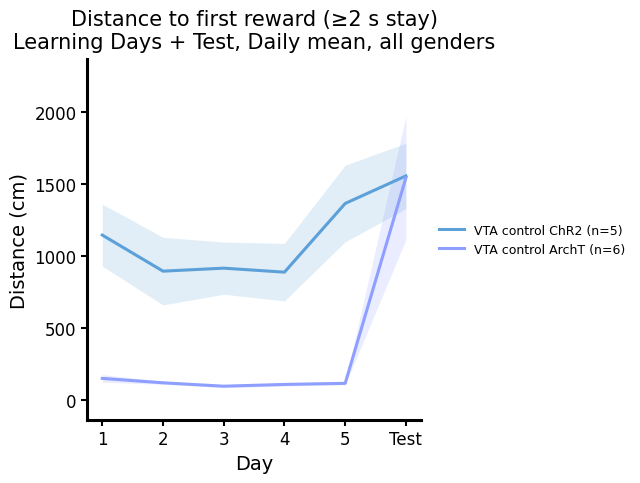


=== Line plot: CIPL ===
VTA control ChR2 (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
VTA control ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']


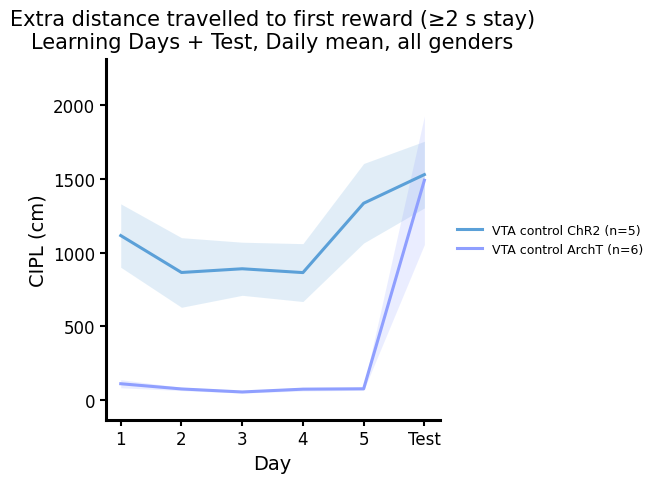


=== Line plot: path_eff ===
VTA control ChR2 (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
VTA control ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']


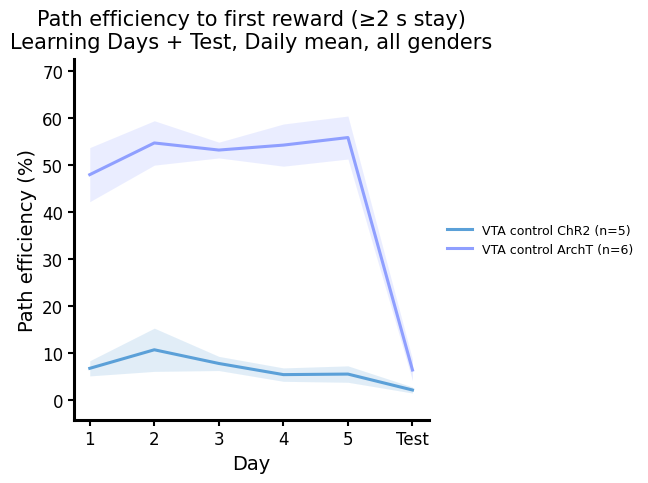


=== Test-day boxplot: dist_to_trigger ===
  VTA control ChR2 (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]
  VTA control ArchT (eYFP_ArchT): n = 6, animals = [np.str_('M'), np.str_('MA'), np.str_('MB'), np.str_('N'), np.str_('O'), np.str_('P')]

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, mean=1558.17 vs 1544.90, median=1732.85 vs 1349.33, U=15.0, rank-biserial=0.000, p=1.00000


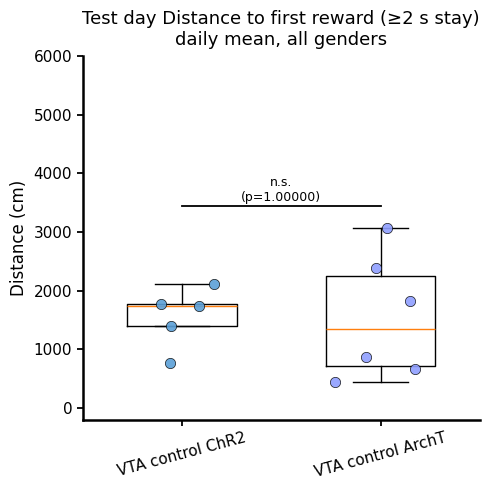


=== Test-day boxplot: CIPL ===
  VTA control ChR2 (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]
  VTA control ArchT (eYFP_ArchT): n = 6, animals = [np.str_('M'), np.str_('MA'), np.str_('MB'), np.str_('N'), np.str_('O'), np.str_('P')]

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, mean=1529.87 vs 1491.35, median=1714.89 vs 1285.97, U=15.0, rank-biserial=0.000, p=1.00000


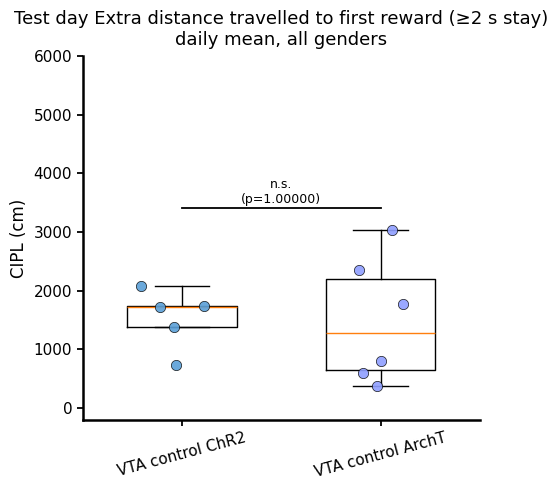


=== Test-day boxplot: path_eff ===
  VTA control ChR2 (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]
  VTA control ArchT (eYFP_ArchT): n = 6, animals = [np.str_('M'), np.str_('MA'), np.str_('MB'), np.str_('N'), np.str_('O'), np.str_('P')]

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, mean=2.04 vs 6.30, median=1.83 vs 5.39, U=8.0, rank-biserial=-0.467, p=0.24675


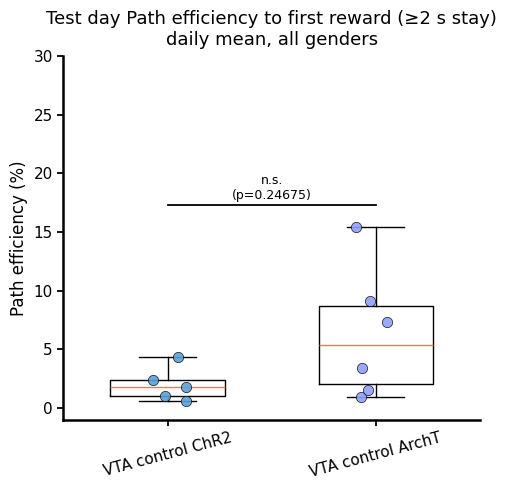


=== Learning-days 1-5 average boxplot: CIPL ===
  VTA control ChR2 (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]
  VTA control ArchT (eYFP_ArchT): n = 6, animals = [np.str_('M'), np.str_('MA'), np.str_('MB'), np.str_('N'), np.str_('O'), np.str_('P')]

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, mean=1013.55 vs 75.39, median=1113.67 vs 77.19, U=30.0, rank-biserial=1.000, p=0.00433


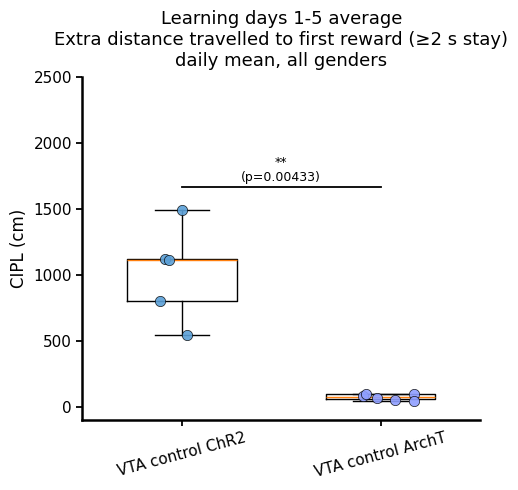


=== Learning-days 1-5 average boxplot: path_eff ===
  VTA control ChR2 (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]
  VTA control ArchT (eYFP_ArchT): n = 6, animals = [np.str_('M'), np.str_('MA'), np.str_('MB'), np.str_('N'), np.str_('O'), np.str_('P')]

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, mean=7.14 vs 53.13, median=5.55 vs 53.28, U=0.0, rank-biserial=-1.000, p=0.00433


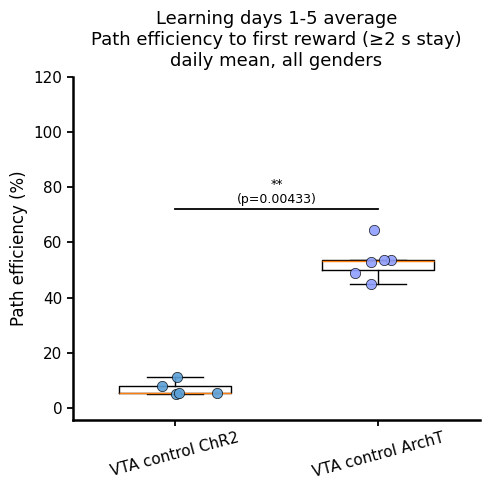

In [434]:
# ============================================================
# Distance / CIPL / Path efficiency
#
# Adds pooled group:
#   'Control' = eYFP_ChR2 + NAc_control + CA1_control
#
# Adds custom ID-based groups:
#   short_1 = AI, AJ, AL
#   short_2 = V1, V2, V3, V4, V5
#
# Important behaviour:
#   - If GROUPS = ['ChR2_short'], all ChR2_short animals stay as ChR2_short.
#   - If GROUPS = ['short_1', 'short_2'], only then AI/AJ/AL and V1-V5
#     are reassigned into the custom groups.
#   - If GROUPS = ['ChR2_short', 'short_1', 'short_2'], then short_1/short_2
#     animals are removed from the broader ChR2_short group to avoid double-counting.
#
# New option:
#   DAY_VALUE_MODE = 'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   DAY_VALUE_MODE = 'first_trial'
#       learning days = first trial only from each day
#       test day      = first test trial only
#
# Gender option:
#   GENDER_FILTER = None      -> include all animals
#   GENDER_FILTER = 'F'       -> females only
#   GENDER_FILTER = 'M'       -> males only
#   GENDER_FILTER = ['F','M'] -> explicit both
#
# Stay tag:
#   automatically follows REQUIRE_STAY_2S if it exists.
#   If REQUIRE_STAY_2S = True  -> title shows ≥2 s stay
#   If REQUIRE_STAY_2S = False -> title shows all entries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------

# GROUPS = ['ChR2', 'ChR2_short', 'eYFP_ChR2', 'WT']
# GROUPS = ['ChR2_short', 'CA1', 'CA3', 'Control']
# GROUPS = ['short_1', 'short_2']
GROUPS = ['eYFP_ChR2', 'eYFP_ArchT']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['CA1', 'CA3', 'Control']
# GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']
# GROUPS = ['F231A', 'F231A_wt']
# GROUPS = ['ArchT', 'eYFP_ArchT', 'WT']


# ------------------------------------------------------------
# Custom ID-based groups
# ------------------------------------------------------------
CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

# Usually these animals are ChR2_short.
# If you want to load only by ID regardless of genotype, set values to None.
CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

# Gender filter
GENDER_FILTER = None
# GENDER_FILTER = 'F'
# GENDER_FILTER = 'M'
# GENDER_FILTER = ['F', 'M']

# How to compute each animal × day value
DAY_VALUE_MODE = 'daily_mean'
# DAY_VALUE_MODE = 'first_trial' or 'daily_mean' 

# These original genotypes will be pooled into genotype == 'Control'
# eYFP_ChR2 = VTA control
POOLED_CONTROL_ORIGINAL_GROUPS = [ 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control ChR2',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A wt',
    'WT': 'WT',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'VTA control ArchT',
}

# ------------------------------------------------------------
# Stay-tag logic
# ------------------------------------------------------------
REQUIRE_STAY_2S_FOR_LABEL = globals().get('REQUIRE_STAY_2S', False)
MIN_DUR_MS_FOR_LABEL = globals().get('MIN_DUR_MS', 2000)

STAY_TAG = (
    f" (≥{MIN_DUR_MS_FOR_LABEL / 1000:g} s stay)"
    if REQUIRE_STAY_2S_FOR_LABEL
    else " (all entries)"
)

EXCLUDE_ID = ['BQ', 'BP']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_ANIMAL_IDS = False

SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False

JITTER = 0.10
DOT_SIZE = 55
P_DECIMALS = 5

RUN_LINE_PLOTS = True
RUN_TEST_BOXPLOTS = True
RUN_LEARNING_AVG_BOXPLOTS = True

METRICS_TO_PLOT = ['dist_to_trigger', 'CIPL', 'path_eff']
LEARNING_AVG_BOXPLOT_METRICS = ['CIPL', 'path_eff']

METRIC_LABEL = {
    'dist_to_trigger': 'Distance (cm)',
    'CIPL': 'CIPL (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'dist_to_trigger': 'Distance to first reward',
    'CIPL': 'Extra distance travelled to first reward',
    'path_eff': 'Path efficiency to first reward',
}

YMAX_BY_METRIC = {
    'dist_to_trigger': None,
    'CIPL': None,
    'path_eff': None,
}

YMIN = None
Y_BOTTOM_PAD_FRAC = 0.06
BOX_Y_ZERO_PAD_FRAC = 0.04

# Boxplot options
COMPARISONS = 'all'
# COMPARISONS = [('short_1', 'short_2')]
# COMPARISONS = [('short_1', 'ChR2'), ('short_2', 'ChR2')]
# COMPARISONS = [('ChR2_short', 'eYFP_ChR2')]

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


# ---------------------------------------------------------------------
# Helper: custom groups
# ---------------------------------------------------------------------
def is_custom_group(g):
    return g in CUSTOM_GROUP_ID_MAP


def get_plot_color(g):
    """
    Uses the same colour function as other genotypes.
    Make sure get_genotype_color() has entries for:
      'short_1'
      'short_2'
    If it does not, this falls back to ChR2_short colour for both.
    """
    try:
        return get_genotype_color(g)
    except Exception:
        if g in ['short_1', 'short_2']:
            return get_genotype_color('ChR2_short')
        return get_genotype_color(g)


def add_analysis_group(meta_df):
    """
    Adds analysis_group.

    Default:
      analysis_group = genotype

    Custom ID groups:
      animals with id in CUSTOM_GROUP_ID_MAP are assigned to short_1,
      short_2, etc. ONLY if that custom group is requested in GROUPS.

    This avoids the issue where GROUPS = ['ChR2_short'] gives n = 0,
    because AI/AJ/AL/V1-V5 were being reassigned away from ChR2_short.
    """
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in CUSTOM_GROUP_ID_MAP.items():

        # Critical fix:
        # Only create this custom group if it is requested.
        if group_name not in GROUPS:
            continue

        ids_str = [str(x) for x in ids]
        meta_df.loc[id_as_str.isin(ids_str), 'analysis_group'] = group_name

    return meta_df


# ---------------------------------------------------------------------
# 1. Base filter and assign plot_day
# ---------------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
] + METRICS_TO_PLOT

if GENDER_FILTER is not None:
    needed_cols.append('gender')

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")


# ------------------------------------------------------------
# Work out which genotype rows and custom ID rows to load
# ------------------------------------------------------------
groups_to_load = []
custom_ids_to_load = []

for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

    elif g in CUSTOM_GROUP_ID_MAP:
        custom_ids_to_load.extend(CUSTOM_GROUP_ID_MAP[g])

        genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(g, None)
        if genotype_source is not None:
            groups_to_load.append(genotype_source)

    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))
custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

base_mask = (
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T']))
)

if len(groups_to_load) > 0:
    genotype_mask = metadata['genotype'].isin(groups_to_load)
else:
    genotype_mask = False

if len(custom_ids_to_load) > 0 and 'id' in metadata.columns:
    custom_id_mask = metadata['id'].astype(str).isin(custom_ids_to_load)
else:
    custom_id_mask = False

meta_LT = metadata[
    base_mask &
    (genotype_mask | custom_id_mask)
].copy()


# ------------------------------------------------------------
# Apply gender filter
# ------------------------------------------------------------
if GENDER_FILTER is not None:
    if isinstance(GENDER_FILTER, str):
        gender_values = [GENDER_FILTER]
    else:
        gender_values = list(GENDER_FILTER)

    gender_values = [str(g).upper() for g in gender_values]

    meta_LT = meta_LT[
        meta_LT['gender'].astype(str).str.upper().isin(gender_values)
    ].copy()


# Store original genotype before pooling/custom reassignment
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool VTA control + NAc_control + CA1_control into one displayed/statistical group: Control
if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

# Add custom analysis group
meta_LT = add_analysis_group(meta_LT)

# Use analysis_group as active grouping column
meta_LT['genotype'] = meta_LT['analysis_group']

# Keep only requested groups
meta_LT = meta_LT[meta_LT['genotype'].isin(GROUPS)].copy()

# Do not accidentally exclude custom animals if they appear in EXCLUDE_ID
exclude_ids_effective = [
    x for x in EXCLUDE_ID
    if str(x) not in custom_ids_to_load
]

if len(exclude_ids_effective) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()


# ------------------------------------------------------------
# Assign plot_day
# L days 1-5 -> plot_day 1-5
# first T session after last L -> plot_day 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()


# ---------------------------------------------------------------------
# 1b. Add trial_in_day, needed for DAY_VALUE_MODE = 'first_trial'
# ---------------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session',
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()


# ---------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals,
    and keeps custom groups visible.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    gender_txt = ""
    if 'gender' in ms.columns and ms['gender'].notna().any():
        gender_txt = f", {str(ms['gender'].dropna().iloc[0])}"

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])
        if analysis_group in CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)}{gender_txt})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original}{gender_txt})'

    if gender_txt != "":
        return f'{animal_id} ({gender_txt.replace(", ", "")})'

    return animal_id


def get_day_value(ms, day, value_col):
    """
    Returns one value for one animal on one plot_day.

    DAY_VALUE_MODE:
      'daily_mean'  -> mean across all available trials in that day
      'first_trial' -> trial_in_day == 1 only
    """
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna())
    ].copy()

    if len(md) == 0:
        return np.nan

    # mean per trial first, in case duplicate rows exist for same trial
    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan
        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def get_test_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()
        value = get_day_value(ms, 6, value_col)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'value': value,
            'animal_id': get_animal_label(ms, sub)
        })

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def get_learning_avg_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['plot_day'].isin([1, 2, 3, 4, 5])) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()

        vals_day = np.array(
            [get_day_value(ms, d, value_col) for d in [1, 2, 3, 4, 5]],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals_day)):
            continue

        if np.all(np.isnan(vals_day)):
            continue

        value = np.nanmean(vals_day)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'animal_id': get_animal_label(ms, sub),
            'value': value
        })

    if len(rows) == 0:
        return np.array([]), np.array([]), np.array([])

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def style_nature(ax):
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)


def apply_y_axis(ax, ymax_candidates, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        ymax = manual_ymax
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return stat, p


def get_comparisons():
    if COMPARISONS == 'all':
        comparisons = []
        for i in range(len(GROUPS)):
            for j in range(i + 1, len(GROUPS)):
                comparisons.append((GROUPS[i], GROUPS[j]))
        return comparisons
    return COMPARISONS


def gender_label_for_title():
    if GENDER_FILTER is None:
        return "all genders"

    if isinstance(GENDER_FILTER, str):
        return f"gender = {GENDER_FILTER}"

    return "gender = " + "/".join([str(g) for g in GENDER_FILTER])


# ---------------------------------------------------------------------
# 3. Line plot helper
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col):
    ylabel = METRIC_LABEL.get(value_col, value_col)
    title_base = METRIC_TITLE.get(value_col, value_col)

    group_data = {}

    print(f"\n=== Line plot: {value_col} ===")

    for g in GROUPS:
        meta_g = meta_LT[meta_LT['genotype'] == g].copy()
        mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, value_col)

        group_data[g] = {
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"{DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

    fig, ax = plt.subplots(figsize=(8, 5.2))

    ymax_candidates = []

    for g in GROUPS:
        mat = group_data[g]['mat']
        subs = group_data[g]['subs']

        if mat is None or len(subs) == 0:
            continue

        col = get_plot_color(g)
        label = DISPLAY_NAME.get(g, g)

        if PLOT_INDIVIDUAL:
            for row in mat:
                ax.plot(
                    x_vals,
                    row,
                    '-',
                    color=col,
                    alpha=0.12,
                    linewidth=1.0,
                    label='_nolegend_',
                    zorder=1
                )

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=col,
                alpha=0.18,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if SHOW_SEM_ERRORBARS:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        ymax_candidates.append(np.nanmax(mean_ + sem_))

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "First trial only"
    else:
        day_value_tag = "Daily mean"

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{title_base}{STAY_TAG}\nLearning Days + Test, {day_value_tag}, {gender_label_for_title()}',
        fontsize=15,
        pad=8
    )

    style_nature(ax)
    apply_y_axis(ax, ymax_candidates, value_col)

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(
            frameon=False,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            fontsize=9
        )

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()


# ---------------------------------------------------------------------
# 4. Boxplot helper
# ---------------------------------------------------------------------
def plot_boxplot(metric_col, boxplot_mode):
    ylabel = METRIC_LABEL.get(metric_col, metric_col)
    title_base = METRIC_TITLE.get(metric_col, metric_col)

    group_vals = {}
    group_subs = {}
    group_ids = {}

    if boxplot_mode == 'test':
        print(f"\n=== Test-day boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_test_group_vals(meta_test, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    elif boxplot_mode == 'learning_mean':
        print(f"\n=== Learning-days 1-5 average boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_learning_avg_group_vals(meta_LT, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    else:
        raise ValueError("boxplot_mode must be 'test' or 'learning_mean'")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_vals[g])}, animals = {list(group_ids[g])}"
        )

    data = [group_vals[g] for g in GROUPS]
    positions = np.arange(len(GROUPS))

    fig, ax = plt.subplots(figsize=(max(5, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = group_vals[g]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(g),
            edgecolor='k',
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_ids[g]):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # comparisons
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in get_comparisons():
        if g1 not in GROUPS or g2 not in GROUPS:
            print(f"Skipping {g1} vs {g2}: group not in GROUPS")
            continue

        vals1 = group_vals[g1]
        vals2 = group_vals[g2]

        stat, p = mwu(vals1, vals2)

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.2f} vs {np.nanmean(vals2):.2f}, "
                f"median={np.nanmedian(vals1):.2f} vs {np.nanmedian(vals2):.2f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )
        else:
            print(f"  {g1} vs {g2}: p = NaN")

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    # significance lines
    nonempty_data = [v for v in data if len(v) > 0]

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        current_y = ymax + 0.12 * yrng
        y_step = 0.28 * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2

            ax.plot(
                [positions[x1], positions[x2]],
                [current_y, current_y],
                color='k',
                lw=1.3
            )

            ax.text(
                x_mid,
                current_y + 0.015 * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        ymax_box = current_y + 0.25 * yrng

        if YMIN is not None:
            ymin = YMIN
        else:
            ymin = -BOX_Y_ZERO_PAD_FRAC * ymax_box

        ax.set_ylim(ymin, ymax_box)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "first trial only"
    else:
        day_value_tag = "daily mean"

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)

    if boxplot_mode == 'test':
        ax.set_title(
            f"Test day {title_base}{STAY_TAG}\n{day_value_tag}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )
    else:
        ax.set_title(
            f"Learning days 1-5 average\n{title_base}{STAY_TAG}\n{day_value_tag}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.tick_params(axis='y', labelsize=11)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 5. Run plots
# ---------------------------------------------------------------------
print("\nGroups used for plotting/stats:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
print("Custom IDs loaded:", custom_ids_to_load)
print("Day value mode:", DAY_VALUE_MODE)
print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Gender filter:", GENDER_FILTER if GENDER_FILTER is not None else "all")
print("Stay tag:", STAY_TAG)

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nCustom groups:")
for g, ids in CUSTOM_GROUP_ID_MAP.items():
    if g in GROUPS:
        print(f"  {g}: {ids}, colour = get_genotype_color('{g}')")

print("\nAnimals after all filters:")
if len(meta_LT) > 0:
    cols_to_print = ['sub']
    if 'id' in meta_LT.columns:
        cols_to_print.append('id')
    if 'gender' in meta_LT.columns:
        cols_to_print.append('gender')
    if 'genotype_original' in meta_LT.columns:
        cols_to_print.append('genotype_original')
    cols_to_print.append('genotype')

    print(
        meta_LT[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")

if RUN_LINE_PLOTS:
    for metric in METRICS_TO_PLOT:
        plot_metric_for_groups(meta_LT, metric)

if RUN_TEST_BOXPLOTS:
    for metric in METRICS_TO_PLOT:
        plot_boxplot(metric, boxplot_mode='test')

if RUN_LEARNING_AVG_BOXPLOTS:
    for metric in LEARNING_AVG_BOXPLOT_METRICS:
        plot_boxplot(metric, boxplot_mode='learning_mean')

Stay tag used: all entries
This plotting code uses the metric columns already present in metadata.
To switch between all entries vs ≥2 s stay, rerun your metric-computation code with REQUIRE_STAY_2S True/False, then rerun this plotting code.


############################################################
RUNNING METRIC: CIPL
############################################################
Using metric: CIPL
Stay tag: all entries
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10, CIPL
Trial-level rows included: n rows = 24
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13 

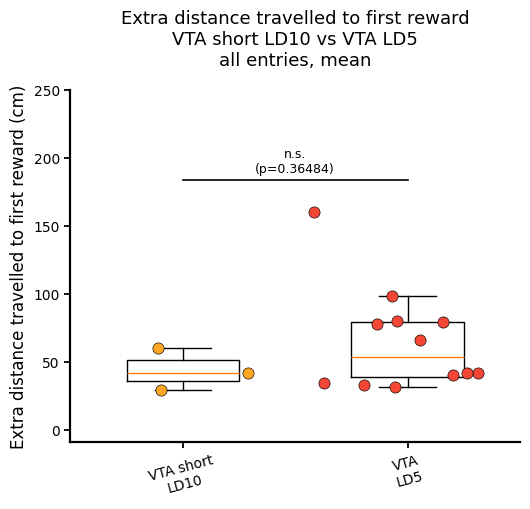


Extra distance travelled to first reward
VTA short next test vs VTA test
Metric: CIPL
Per-animal values used for statistics:

Left group:
   sub  id       value  n_trials ses_list trial_type_day_list trial_type_list  \
0   13  AI  246.527005         1     [14]                 [1]             [T]   
1   14  AJ  263.937336         1     [14]                 [1]             [T]   
2   15  AL    1.887497         1     [14]                 [1]             [T]   

  trial_in_day_list  
0               [1]  
1               [1]  
2               [1]  

Right group:
    sub  id       value  n_trials ses_list trial_type_day_list  \
0     1   A   94.368752         1      [9]                 [1]   
1     3   C  118.847043         1      [9]                 [1]   
2     4   D    1.158615         1      [9]                 [1]   
3     6  AB   99.889708         1      [9]                 [1]   
4     7  AC   86.235965         1      [9]                 [1]   
5     8  AD   16.194685         1     

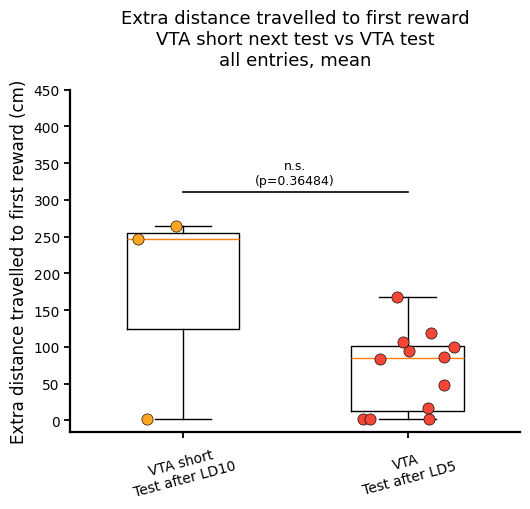



############################################################
RUNNING METRIC: path_eff
############################################################
Using metric: path_eff
Stay tag: all entries
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10, path_eff
Trial-level rows included: n rows = 22
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13          L              10             4   
4    13  AI  ChR2_short   13          L              10             5   
5    13  AI  ChR2_short   13          L              10             6   
6    13  AI  ChR2_short   13          L 

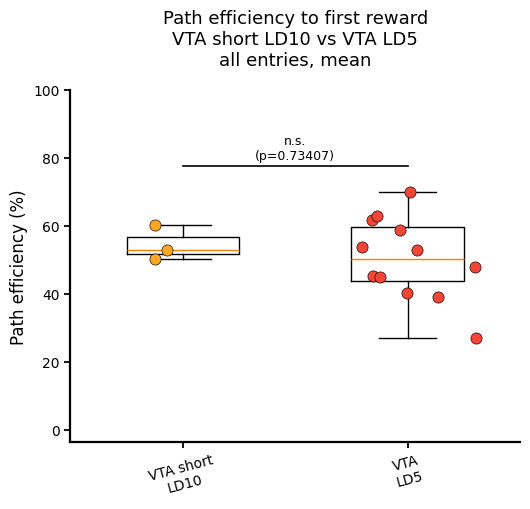


Path efficiency to first reward
VTA short next test vs VTA test
Metric: path_eff
Per-animal values used for statistics:

Left group:
   sub  id      value  n_trials ses_list trial_type_day_list trial_type_list  \
0   13  AI   5.920031         1     [14]                 [1]             [T]   
1   14  AJ   7.323923         1     [14]                 [1]             [T]   
2   15  AL  94.498535         1     [14]                 [1]             [T]   

  trial_in_day_list  
0               [1]  
1               [1]  
2               [1]  

Right group:
    sub  id      value  n_trials ses_list trial_type_day_list trial_type_list  \
0     1   A  16.402615         1      [9]                 [1]             [T]   
1     3   C  33.220664         1      [9]                 [1]             [T]   
2     4   D  96.162462         1      [9]                 [1]             [T]   
3     6  AB  29.019842         1      [9]                 [1]             [T]   
4     7  AC  12.404585         1      

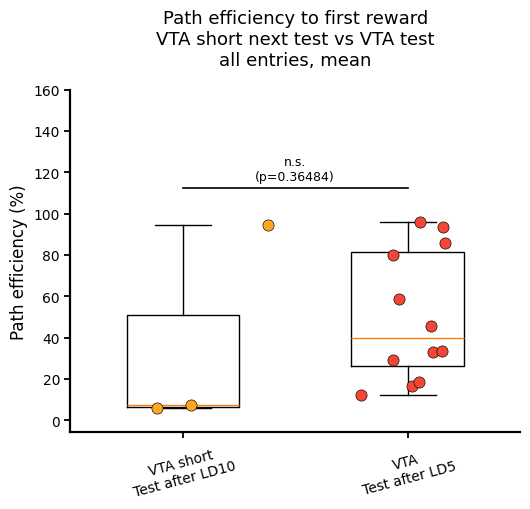

In [322]:
# ============================================================
# Compare CIPL / path efficiency:
#
# ChR2_short animals AI/AJ/AL:
#   final learning day = learning day 10
#   trial_type_day == 10, trial_type == 'L'
#
# vs
#
# ChR2 animals:
#   final learning day = learning day 5
#   trial_type_day == 5, trial_type == 'L'
#
# Also compare:
#   ChR2_short next test day after learning day 10
#   vs
#   ChR2 first test day after learning day 5
#
# Produces boxplots for:
#   1) CIPL:          ChR2_short LD10 vs ChR2 LD5
#   2) CIPL:          ChR2_short next test vs ChR2 test
#   3) path_eff:      ChR2_short LD10 vs ChR2 LD5
#   4) path_eff:      ChR2_short next test vs ChR2 test
#
# Stay tag:
#   follows REQUIRE_STAY_2S and MIN_DUR_MS from the metric-computation code.
#
# Prints:
#   - exact trial rows included
#   - animal-level values used for stats
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

CHR2_SHORT_IDS = ['AI', 'AJ', 'AL']

CH_R2_GENOTYPE = 'ChR2'
CH_R2_SHORT_GENOTYPE = 'ChR2_short'

METRICS_TO_COMPARE = ['CIPL', 'path_eff']

METRIC_LABEL = {
    'CIPL': 'Extra distance travelled to first reward (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'CIPL': 'Extra distance travelled to first reward',
    'path_eff': 'Path efficiency to first reward',
}

EXCLUDE_ID = ['AN']       # optional
EXCLUDE_SUBS = []         # optional

REQUIRE_USABLE = True

# How to summarize multiple trials from the same animal/session/day
# 'mean' = average all included trials per animal
# 'first_trial' = use trial_in_day == 1 only
TRIAL_SUMMARY_MODE = 'mean'
# TRIAL_SUMMARY_MODE = 'first_trial'

# Plot options
SHOW_ANIMAL_IDS = False
JITTER = 0.18
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.18
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.35

# y-axis
YMIN_BY_METRIC = {
    'CIPL': None,
    'path_eff': None,
}

YMAX_BY_METRIC = {
    'CIPL': None,
    'path_eff': None,
}

Y_BOTTOM_PAD_FRAC = 0.04
Y_TICK_STEP_BY_METRIC = {
    'CIPL': None,
    'path_eff': None,
}

np.random.seed(1)

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

# ------------------------------------------------------------
# Stay-tag logic
# ------------------------------------------------------------
REQUIRE_STAY_2S_FOR_LABEL = globals().get('REQUIRE_STAY_2S', False)
MIN_DUR_MS_FOR_LABEL = globals().get('MIN_DUR_MS', 2000)

STAY_TAG = (
    f"≥{MIN_DUR_MS_FOR_LABEL / 1000:g} s stay"
    if REQUIRE_STAY_2S_FOR_LABEL
    else "all entries"
)

# ============================================================
# Helper functions
# ============================================================

def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.6):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def add_trial_in_day(meta_df):
    """
    Create trial_in_day = 1..8.
    Prefer an existing trial column if present.
    Otherwise infer from sorted sub/ses/trial_id order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        sort_cols = ['sub', 'ses']
        if 'trial_id' in meta_df.columns:
            sort_cols.append('trial_id')

        meta_df = meta_df.sort_values(sort_cols).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    return meta_df, trial_col


def print_trial_rows(label, meta_df, value_col):
    """
    Print exact trial-level rows used before per-animal averaging.
    """
    print("\n============================================================")
    print(label)
    print(f"Trial-level rows included: n rows = {len(meta_df)}")
    print(f"Animals included: n = {meta_df['sub'].nunique() if len(meta_df) > 0 else 0}")

    if len(meta_df) == 0:
        print("No rows.")
        return

    cols = [
        'sub',
        'id',
        'genotype',
        'ses',
        'trial_type',
        'trial_type_day',
        'trial_in_day',
    ]

    optional_cols = [
        'trial_id',
        'date',
        'usable',
        'short_duration',
        'first_choice_trigger',
        'L_actual',
        'L_shortest',
        'CIPL',
        'path_eff',
        value_col,
    ]

    cols_to_print = []
    for c in cols + optional_cols:
        if c in meta_df.columns and c not in cols_to_print:
            cols_to_print.append(c)

    out = meta_df[cols_to_print].copy()

    sort_cols = [c for c in ['id', 'sub', 'ses', 'trial_in_day'] if c in out.columns]

    print(
        out
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )


def per_animal_value_from_trials(meta_df, value_col):
    """
    Converts trial-level rows into one value per animal.

    TRIAL_SUMMARY_MODE:
      'mean'        -> average across all included trials per animal
      'first_trial' -> only trial_in_day == 1
    """
    rows = []

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub].copy()

        if TRIAL_SUMMARY_MODE == 'first_trial':
            ms_use = ms[ms['trial_in_day'] == 1].copy()
        elif TRIAL_SUMMARY_MODE == 'mean':
            ms_use = ms.copy()
        else:
            raise ValueError("TRIAL_SUMMARY_MODE must be 'mean' or 'first_trial'")

        vals = ms_use[value_col].values.astype(float)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_label(ms, sub),
            'value': float(np.nanmean(vals)),
            'n_trials': len(vals),
            'ses_list': sorted(ms_use['ses'].dropna().unique().tolist()) if 'ses' in ms_use.columns else [],
            'trial_type_day_list': sorted(ms_use['trial_type_day'].dropna().unique().tolist()) if 'trial_type_day' in ms_use.columns else [],
            'trial_type_list': sorted(ms_use['trial_type'].dropna().unique().tolist()) if 'trial_type' in ms_use.columns else [],
            'trial_in_day_list': sorted(ms_use['trial_in_day'].dropna().unique().tolist()) if 'trial_in_day' in ms_use.columns else [],
        })

    return pd.DataFrame(rows)


def apply_box_y_axis(ax, y_top, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)
    y_tick_step = Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = manual_ymax
    else:
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if manual_ymin is not None:
        y_bottom = manual_ymin
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if y_tick_step is not None:
        yticks = np.arange(0, y_top + y_tick_step, y_tick_step)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def plot_two_group_boxplot(
    df_left,
    df_right,
    left_label,
    right_label,
    title,
    value_col,
):
    """
    Boxplot + individual dots + Mann–Whitney U test.
    df_left / df_right should contain columns:
      sub, id, value, n_trials
    """
    vals_left = df_left['value'].values.astype(float) if len(df_left) > 0 else np.array([])
    vals_right = df_right['value'].values.astype(float) if len(df_right) > 0 else np.array([])

    vals_groups = [vals_left, vals_right]
    positions = np.array([0, 1])

    print("\n============================================================")
    print(title)
    print(f"Metric: {value_col}")
    print("Per-animal values used for statistics:")

    print("\nLeft group:")
    print(df_left)

    print("\nRight group:")
    print(df_right)

    if len(vals_left) > 0 and len(vals_right) > 0:
        stat, p = mannwhitneyu(vals_left, vals_right, alternative='two-sided')
        rank_biserial = (2 * stat) / (len(vals_left) * len(vals_right)) - 1

        print("\nMann–Whitney U test:")
        print(
            f"  {left_label} vs {right_label}: "
            f"n={len(vals_left)} vs {len(vals_right)}, "
            f"mean={np.nanmean(vals_left):.3f} vs {np.nanmean(vals_right):.3f}, "
            f"median={np.nanmedian(vals_left):.3f} vs {np.nanmedian(vals_right):.3f}, "
            f"U={stat:.1f}, "
            f"rank-biserial={rank_biserial:.3f}, "
            f"p={format_p(p, P_DECIMALS)}"
        )
    else:
        stat, p = np.nan, np.nan
        print("\nMann–Whitney U test: skipped because one group has no data.")

    fig, ax = plt.subplots(figsize=(5.4, 5.2))

    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------
    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.5,
        patch_artist=False,
        showfliers=False
    )

    # --------------------------------------------------------
    # Individual dots
    # --------------------------------------------------------
    group_keys = [CH_R2_SHORT_GENOTYPE, CH_R2_GENOTYPE]

    for i, (df_g, vals, gkey) in enumerate(zip([df_left, df_right], vals_groups, group_keys)):
        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(gkey),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(gkey),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Significance line
    # --------------------------------------------------------
    nonempty = [v for v in vals_groups if len(v) > 0]

    if len(nonempty) > 0:
        all_vals = np.concatenate(nonempty)
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)

        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y_line = ymax + P_LINE_START_FRAC * yrng
        y_text = y_line + P_TEXT_OFFSET_FRAC * yrng

        if np.isfinite(p):
            ax.plot(
                [positions[0], positions[1]],
                [y_line, y_line],
                color='black',
                linewidth=1.2,
                zorder=5,
                clip_on=False
            )

            ax.text(
                np.mean(positions),
                y_text,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9,
                zorder=6,
                clip_on=False
            )

        y_top_for_axis = y_line + P_TOP_PAD_FRAC * yrng
    else:
        y_top_for_axis = 1.0

    # --------------------------------------------------------
    # Axes / labels / style
    # --------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [left_label, right_label],
        fontsize=10,
        rotation=15
    )

    ax.set_ylabel(METRIC_LABEL.get(value_col, value_col), fontsize=12)

    ax.set_title(
        f'{title}\n{STAY_TAG}, {TRIAL_SUMMARY_MODE}',
        fontsize=13,
        pad=18
    )

    apply_box_y_axis(ax, y_top_for_axis, value_col)
    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


# ============================================================
# Main function for one metric
# ============================================================

def run_metric_comparison(value_col):
    print("\n\n############################################################")
    print(f"RUNNING METRIC: {value_col}")
    print("############################################################")

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        value_col,
    ]

    missing_cols = [c for c in needed_cols if c not in metadata.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"Missing columns in metadata: {missing_cols}")

    meta = metadata.copy()

    if REQUIRE_USABLE:
        meta = meta[meta['usable'] == 1].copy()

    meta = meta[
        meta['genotype'].isin([CH_R2_GENOTYPE, CH_R2_SHORT_GENOTYPE]) &
        meta['trial_type'].isin(['L', 'T']) &
        meta[value_col].notna() &
        np.isfinite(meta[value_col])
    ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
        meta = meta[
            ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta = meta[
            ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    meta, trial_col = add_trial_in_day(meta)

    print("Using metric:", value_col)
    print("Stay tag:", STAY_TAG)
    print("Trial summary mode:", TRIAL_SUMMARY_MODE)
    print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses/trial_id order")
    print("ChR2_short IDs requested:", CHR2_SHORT_IDS)

    # ========================================================
    # Comparison 1:
    # ChR2_short LD10 vs ChR2 LD5
    # ========================================================

    short_ld10_trials = meta[
        (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
        (meta['id'].astype(str).isin(CHR2_SHORT_IDS)) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 10)
    ].copy()

    chr2_ld5_trials = meta[
        (meta['genotype'] == CH_R2_GENOTYPE) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 5)
    ].copy()

    print_trial_rows(
        label=f"Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10, {value_col}",
        meta_df=short_ld10_trials,
        value_col=value_col
    )

    print_trial_rows(
        label=f"Comparison 1 RIGHT: ChR2 learning day 5, {value_col}",
        meta_df=chr2_ld5_trials,
        value_col=value_col
    )

    short_ld10_animal = per_animal_value_from_trials(short_ld10_trials, value_col)
    chr2_ld5_animal = per_animal_value_from_trials(chr2_ld5_trials, value_col)

    # ========================================================
    # Comparison 2:
    # ChR2_short next test after LD10 vs ChR2 first test after LD5
    # ========================================================

    # --------------------------------------------------------
    # ChR2_short next test:
    # for each animal, find last ses among LD10 rows;
    # next test session = last_ld10_ses + 1
    # --------------------------------------------------------
    short_next_test_list = []

    for animal_id in CHR2_SHORT_IDS:
        m_animal_ld10 = short_ld10_trials[
            short_ld10_trials['id'].astype(str) == str(animal_id)
        ].copy()

        if len(m_animal_ld10) == 0:
            print(f"WARNING: no LD10 rows found for {animal_id}; cannot find next test.")
            continue

        last_ld10_ses = m_animal_ld10['ses'].max()
        next_test_ses = last_ld10_ses + 1

        m_next_test = meta[
            (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
            (meta['id'].astype(str) == str(animal_id)) &
            (meta['trial_type'] == 'T') &
            (meta['ses'] == next_test_ses)
        ].copy()

        if len(m_next_test) == 0:
            print(
                f"WARNING: no next test rows found for {animal_id}: "
                f"expected ses = {next_test_ses}"
            )
            continue

        short_next_test_list.append(m_next_test)

    if len(short_next_test_list) > 0:
        short_next_test_trials = pd.concat(short_next_test_list, ignore_index=False)
    else:
        short_next_test_trials = meta.iloc[0:0].copy()

    # --------------------------------------------------------
    # ChR2 first test after learning day 5:
    # computed separately for each ChR2 animal.
    # --------------------------------------------------------
    chr2_test_list = []

    meta_chr2 = meta[meta['genotype'] == CH_R2_GENOTYPE].copy()

    for sub in meta_chr2['sub'].unique():
        ms = meta_chr2[meta_chr2['sub'] == sub].copy()

        m_ld5 = ms[
            (ms['trial_type'] == 'L') &
            (ms['trial_type_day'] == 5)
        ].copy()

        if len(m_ld5) == 0:
            continue

        last_ld5_ses = m_ld5['ses'].max()

        m_test_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_ld5_ses)
        ].copy()

        if len(m_test_after) == 0:
            continue

        first_test_ses = m_test_after['ses'].min()

        m_first_test = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] == first_test_ses)
        ].copy()

        if len(m_first_test) > 0:
            chr2_test_list.append(m_first_test)

    if len(chr2_test_list) > 0:
        chr2_test_trials = pd.concat(chr2_test_list, ignore_index=False)
    else:
        chr2_test_trials = meta.iloc[0:0].copy()

    print_trial_rows(
        label=f"Comparison 2 LEFT: ChR2_short AI/AJ/AL next test after learning day 10, {value_col}",
        meta_df=short_next_test_trials,
        value_col=value_col
    )

    print_trial_rows(
        label=f"Comparison 2 RIGHT: ChR2 first test after learning day 5, {value_col}",
        meta_df=chr2_test_trials,
        value_col=value_col
    )

    short_next_test_animal = per_animal_value_from_trials(short_next_test_trials, value_col)
    chr2_test_animal = per_animal_value_from_trials(chr2_test_trials, value_col)

    # ========================================================
    # Plot 1: final learning day comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_ld10_animal,
        df_right=chr2_ld5_animal,
        left_label='VTA short\nLD10',
        right_label='VTA\nLD5',
        title=f'{METRIC_TITLE.get(value_col, value_col)}\nVTA short LD10 vs VTA LD5',
        value_col=value_col,
    )

    # ========================================================
    # Plot 2: test comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_next_test_animal,
        df_right=chr2_test_animal,
        left_label='VTA short\nTest after LD10',
        right_label='VTA\nTest after LD5',
        title=f'{METRIC_TITLE.get(value_col, value_col)}\nVTA short next test vs VTA test',
        value_col=value_col,
    )


# ============================================================
# Run CIPL and path efficiency
# ============================================================

print("Stay tag used:", STAY_TAG)
print("This plotting code uses the metric columns already present in metadata.")
print("To switch between all entries vs ≥2 s stay, rerun your metric-computation code with REQUIRE_STAY_2S True/False, then rerun this plotting code.")

for metric in METRICS_TO_COMPARE:
    run_metric_comparison(metric)


Groups used for plotting/stats: ['F', 'M']
Group by gender: True
Genotype compared by gender: F231A
Day value mode: daily_mean
Trial column used: inferred from sub/ses order
Stay tag:  (≥2 s stay)

=== Line plot: dist_to_trigger ===
F231A female (F): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A male (M): n = 6, ids = ['BB (M)', 'BL (M)', 'BM (M)', 'BN (M)', 'F7 (M)', 'F8 (M)']


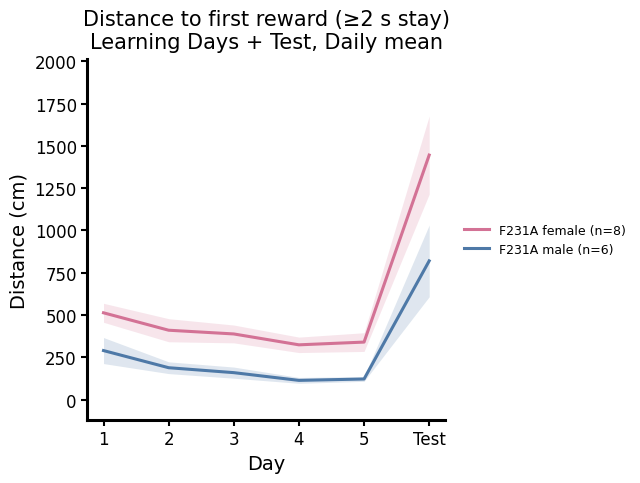


=== Line plot: CIPL ===
F231A female (F): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A male (M): n = 6, ids = ['BB (M)', 'BL (M)', 'BM (M)', 'BN (M)', 'F7 (M)', 'F8 (M)']


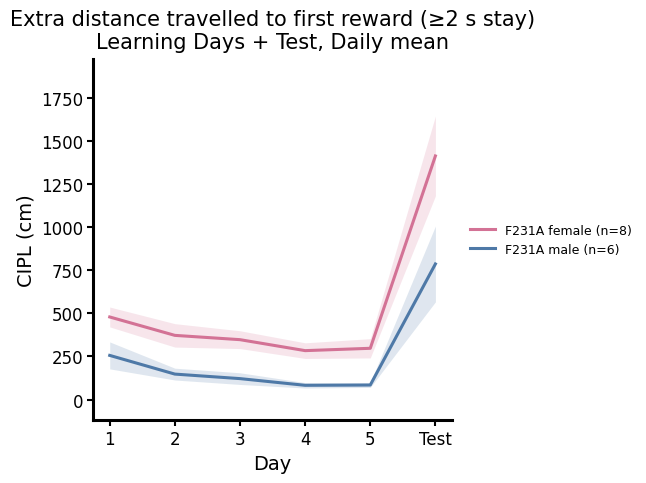


=== Line plot: path_eff ===
F231A female (F): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A male (M): n = 6, ids = ['BB (M)', 'BL (M)', 'BM (M)', 'BN (M)', 'F7 (M)', 'F8 (M)']


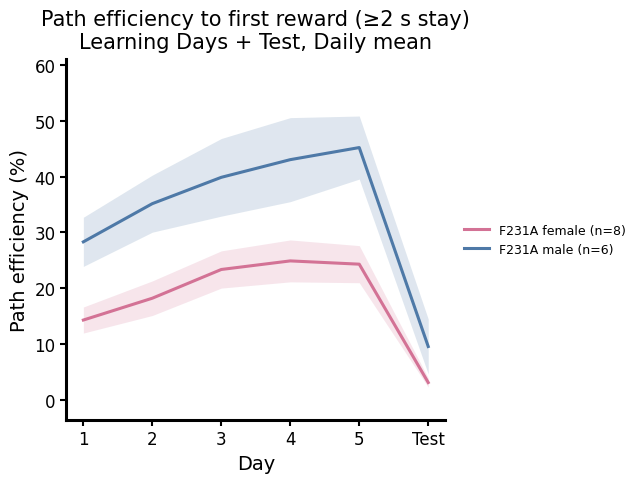


=== Test-day boxplot: dist_to_trigger ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=1445.82 vs 820.22, median=1431.05 vs 747.96, U=38.0, rank-biserial=0.583, p=0.08125


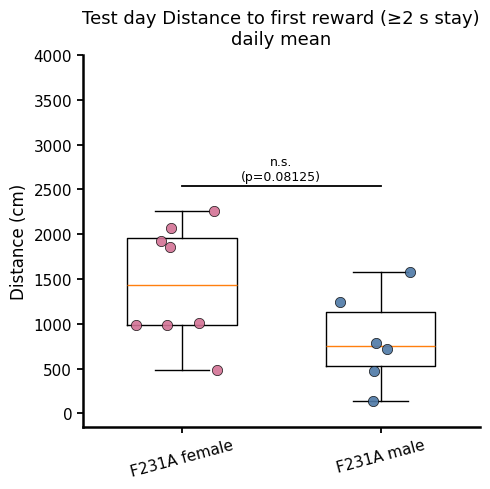


=== Test-day boxplot: CIPL ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=1412.27 vs 786.29, median=1417.52 vs 699.90, U=38.0, rank-biserial=0.583, p=0.08125


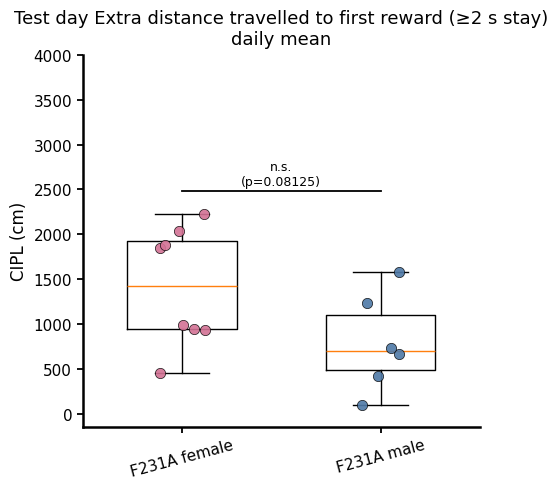


=== Test-day boxplot: path_eff ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=3.06 vs 9.52, median=1.92 vs 6.43, U=17.0, rank-biserial=-0.292, p=0.41359


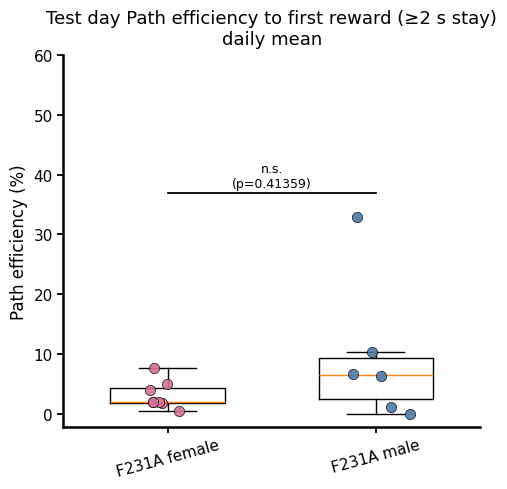


=== Learning-days 1-5 average boxplot: CIPL ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=356.03 vs 138.65, median=323.96 vs 125.48, U=45.0, rank-biserial=0.875, p=0.00466


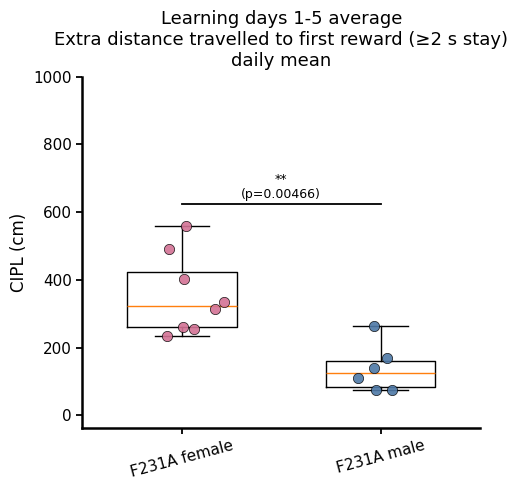


=== Learning-days 1-5 average boxplot: path_eff ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=20.99 vs 38.31, median=20.84 vs 34.94, U=2.0, rank-biserial=-0.917, p=0.00266


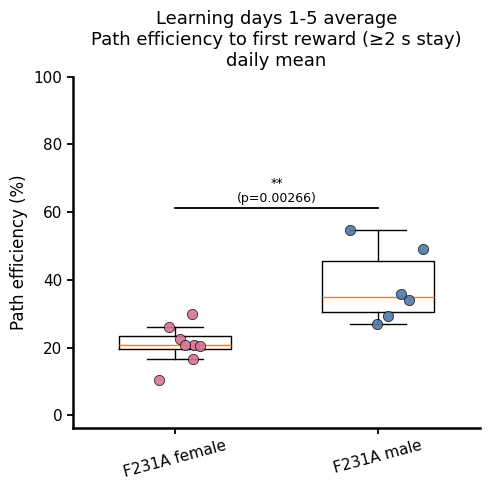

In [301]:
# ============================================================
# Distance / CIPL / Path efficiency
#
# Adds pooled group:
#   'Control' = eYFP_ChR2 + NAc_control + CA1_control
#
# Also allows gender comparison within one genotype:
#   GROUP_BY_GENDER = True
#   GENOTYPE_TO_COMPARE_BY_GENDER = 'F231A'
#   -> compares F231A female vs F231A male
#
# DAY_VALUE_MODE:
#   'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   'first_trial'
#       learning days = first trial only from each day
#       test day      = first test trial only
#
# Stay tag:
#   automatically follows REQUIRE_STAY_2S if it exists.
#   If REQUIRE_STAY_2S = True  -> title shows ≥2 s stay
#   If REQUIRE_STAY_2S = False -> title shows all entries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------

# ------------------------------------------------------------
# Main grouping option
# ------------------------------------------------------------
GROUP_BY_GENDER = True
GENOTYPE_TO_COMPARE_BY_GENDER = 'F231A'

# If GROUP_BY_GENDER = True:
#   groups become ['F', 'M'] within GENOTYPE_TO_COMPARE_BY_GENDER.
#
# If GROUP_BY_GENDER = False:
#   use GROUPS below as normal genotype/group comparison.

# GROUPS = ['ChR2', 'ChR2_short','eYFP_ChR2']
# GROUPS = ['eYFP_ChR2', 'CA1_control','NAc_control']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['CA1', 'CA3', 'Control']
# GROUPS = ['ChR2','CA1','CA3','Control']
GROUPS = ['F231A']

# How to compute each animal × day value
DAY_VALUE_MODE = 'daily_mean'
# DAY_VALUE_MODE = 'first_trial'

# These original genotypes will be pooled into genotype == 'Control'
# eYFP_ChR2 = VTA control
POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A wt',
}

# ------------------------------------------------------------
# Stay-tag logic
# ------------------------------------------------------------
# This assumes your metric computation code defined:
#   REQUIRE_STAY_2S = True/False
#   MIN_DUR_MS = 2000
#
# If those variables do not exist in the current notebook/session,
# these fallbacks prevent the plotting code from crashing.
REQUIRE_STAY_2S_FOR_LABEL = globals().get('REQUIRE_STAY_2S', False)
MIN_DUR_MS_FOR_LABEL = globals().get('MIN_DUR_MS', 2000)

STAY_TAG = (
    f" (≥{MIN_DUR_MS_FOR_LABEL / 1000:g} s stay)"
    if REQUIRE_STAY_2S_FOR_LABEL
    else " (all entries)"
)

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False
SHOW_ANIMAL_IDS = False

JITTER = 0.10
DOT_SIZE = 55
P_DECIMALS = 5

RUN_LINE_PLOTS = True
RUN_TEST_BOXPLOTS = True
RUN_LEARNING_AVG_BOXPLOTS = True

METRICS_TO_PLOT = ['dist_to_trigger', 'CIPL', 'path_eff']
LEARNING_AVG_BOXPLOT_METRICS = ['CIPL', 'path_eff']

METRIC_LABEL = {
    'dist_to_trigger': 'Distance (cm)',
    'CIPL': 'CIPL (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'dist_to_trigger': 'Distance to first reward',
    'CIPL': 'Extra distance travelled to first reward',
    'path_eff': 'Path efficiency to first reward',
}

YMAX_BY_METRIC = {
    'dist_to_trigger': None,
    'CIPL': None,
    'path_eff': None,
}

YMIN = None
Y_BOTTOM_PAD_FRAC = 0.06
BOX_Y_ZERO_PAD_FRAC = 0.04

# Boxplot options
COMPARISONS = 'all'
# COMPARISONS = [('F', 'M')]
# COMPARISONS = [('ChR2', 'Control'), ('NAc', 'Control')]

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")

# ---------------------------------------------------------------------
# Colour helper
# ---------------------------------------------------------------------
def get_plot_color(group):
    """
    Allows F/M plotting even if get_genotype_color() does not know gender groups.
    """
    if group == 'F':
        return '#D37295'   # rose
    if group == 'M':
        return '#4E79A7'   # blue

    return get_genotype_color(group)


# ---------------------------------------------------------------------
# 1. Base filter and assign plot_day
# ---------------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
] + METRICS_TO_PLOT

if GROUP_BY_GENDER:
    needed_cols = needed_cols + ['gender']

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

# ------------------------------------------------------------
# Load metadata according to grouping mode
# ------------------------------------------------------------
if GROUP_BY_GENDER:
    groups_to_load = [GENOTYPE_TO_COMPARE_BY_GENDER]

    meta_LT = metadata[
        (metadata['usable'] == 1) &
        (metadata['genotype'] == GENOTYPE_TO_COMPARE_BY_GENDER) &
        (metadata['gender'].astype(str).str.upper().isin(['F', 'M'])) &
        (metadata['trial_type'].isin(['L', 'T']))
    ].copy()

    # Store original genotype before replacing genotype with gender group
    meta_LT['genotype_original'] = meta_LT['genotype']

    # Use gender as the plotting/statistical group
    meta_LT['gender_original'] = meta_LT['gender']
    meta_LT['genotype'] = meta_LT['gender'].astype(str).str.upper()

    GROUPS = ['F', 'M']

    DISPLAY_NAME.update({
        'F': f'{GENOTYPE_TO_COMPARE_BY_GENDER} female',
        'M': f'{GENOTYPE_TO_COMPARE_BY_GENDER} male',
    })

else:
    # If GROUPS contains 'Control', include its original component groups.
    groups_to_load = []

    for g in GROUPS:
        if g == 'Control':
            groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
        else:
            groups_to_load.append(g)

    groups_to_load = sorted(set(groups_to_load))

    meta_LT = metadata[
        (metadata['usable'] == 1) &
        (metadata['genotype'].isin(groups_to_load)) &
        (metadata['trial_type'].isin(['L', 'T']))
    ].copy()

    # Store original genotype before pooling
    meta_LT['genotype_original'] = meta_LT['genotype']

    # Pool VTA control + NAc_control + CA1_control into one displayed/statistical group: Control
    if 'Control' in GROUPS:
        meta_LT.loc[
            meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
            'genotype'
        ] = 'Control'

# ------------------------------------------------------------
# Exclusions
# ------------------------------------------------------------
if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ---------------------------------------------------------------------
# 1b. Add trial_in_day, needed for DAY_VALUE_MODE = 'first_trial'
# ---------------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session',
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()

# ---------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals.
    Also shows gender if using GROUP_BY_GENDER.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if GROUP_BY_GENDER:
        gender = str(ms['genotype'].dropna().iloc[0])
        return f'{animal_id} ({gender})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def get_day_value(ms, day, value_col):
    """
    Returns one value for one animal on one plot_day.

    DAY_VALUE_MODE:
      'daily_mean'  -> mean across all available trials in that day
      'first_trial' -> trial_in_day == 1 only
    """
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna())
    ].copy()

    if len(md) == 0:
        return np.nan

    # mean per trial first, in case duplicate rows exist for same trial
    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan
        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def get_test_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()
        value = get_day_value(ms, 6, value_col)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'value': value,
            'animal_id': get_animal_label(ms, sub)
        })

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def get_learning_avg_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['plot_day'].isin([1, 2, 3, 4, 5])) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()

        vals_day = np.array(
            [get_day_value(ms, d, value_col) for d in [1, 2, 3, 4, 5]],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals_day)):
            continue

        if np.all(np.isnan(vals_day)):
            continue

        value = np.nanmean(vals_day)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'animal_id': get_animal_label(ms, sub),
            'value': value
        })

    if len(rows) == 0:
        return np.array([]), np.array([]), np.array([])

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def style_nature(ax):
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)


def apply_y_axis(ax, ymax_candidates, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        ymax = manual_ymax
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return stat, p


def get_comparisons():
    if COMPARISONS == 'all':
        comparisons = []
        for i in range(len(GROUPS)):
            for j in range(i + 1, len(GROUPS)):
                comparisons.append((GROUPS[i], GROUPS[j]))
        return comparisons

    return COMPARISONS


# ---------------------------------------------------------------------
# 3. Line plot helper
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col):
    ylabel = METRIC_LABEL.get(value_col, value_col)
    title_base = METRIC_TITLE.get(value_col, value_col)

    group_data = {}

    print(f"\n=== Line plot: {value_col} ===")

    for g in GROUPS:
        meta_g = meta_LT[meta_LT['genotype'] == g].copy()
        mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, value_col)

        group_data[g] = {
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"{DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

    fig, ax = plt.subplots(figsize=(8, 5.2))

    ymax_candidates = []

    for g in GROUPS:
        mat = group_data[g]['mat']
        subs = group_data[g]['subs']

        if mat is None or len(subs) == 0:
            continue

        col = get_plot_color(g)
        label = DISPLAY_NAME.get(g, g)

        if PLOT_INDIVIDUAL:
            for row in mat:
                ax.plot(
                    x_vals,
                    row,
                    '-',
                    color=col,
                    alpha=0.12,
                    linewidth=1.0,
                    label='_nolegend_',
                    zorder=1
                )

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=col,
                alpha=0.18,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if SHOW_SEM_ERRORBARS:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        ymax_candidates.append(np.nanmax(mean_ + sem_))

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "First trial only"
    else:
        day_value_tag = "Daily mean"

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{title_base}{STAY_TAG}\nLearning Days + Test, {day_value_tag}',
        fontsize=15,
        pad=8
    )

    style_nature(ax)
    apply_y_axis(ax, ymax_candidates, value_col)

    ax.legend(
        frameon=False,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()


# ---------------------------------------------------------------------
# 4. Boxplot helper
# ---------------------------------------------------------------------
def plot_boxplot(metric_col, boxplot_mode):
    ylabel = METRIC_LABEL.get(metric_col, metric_col)
    title_base = METRIC_TITLE.get(metric_col, metric_col)

    group_vals = {}
    group_subs = {}
    group_ids = {}

    if boxplot_mode == 'test':
        print(f"\n=== Test-day boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_test_group_vals(meta_test, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    elif boxplot_mode == 'learning_mean':
        print(f"\n=== Learning-days 1-5 average boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_learning_avg_group_vals(meta_LT, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    else:
        raise ValueError("boxplot_mode must be 'test' or 'learning_mean'")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_vals[g])}, animals = {list(group_ids[g])}"
        )

    data = [group_vals[g] for g in GROUPS]
    positions = np.arange(len(GROUPS))

    fig, ax = plt.subplots(figsize=(max(5, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = group_vals[g]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(g),
            edgecolor='k',
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_ids[g]):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # comparisons
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in get_comparisons():
        if g1 not in GROUPS or g2 not in GROUPS:
            print(f"Skipping {g1} vs {g2}: group not in GROUPS")
            continue

        vals1 = group_vals[g1]
        vals2 = group_vals[g2]

        stat, p = mwu(vals1, vals2)

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.2f} vs {np.nanmean(vals2):.2f}, "
                f"median={np.nanmedian(vals1):.2f} vs {np.nanmedian(vals2):.2f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )
        else:
            print(f"  {g1} vs {g2}: p = NaN")

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    # significance lines
    nonempty_data = [v for v in data if len(v) > 0]

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        current_y = ymax + 0.12 * yrng
        y_step = 0.28 * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2

            ax.plot(
                [positions[x1], positions[x2]],
                [current_y, current_y],
                color='k',
                lw=1.3
            )

            ax.text(
                x_mid,
                current_y + 0.015 * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        ymax_box = current_y + 0.25 * yrng

        if YMIN is not None:
            ymin = YMIN
        else:
            ymin = -BOX_Y_ZERO_PAD_FRAC * ymax_box

        ax.set_ylim(ymin, ymax_box)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "first trial only"
    else:
        day_value_tag = "daily mean"

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)

    if boxplot_mode == 'test':
        ax.set_title(
            f"Test day {title_base}{STAY_TAG}\n{day_value_tag}",
            fontsize=13,
            pad=8
        )
    else:
        ax.set_title(
            f"Learning days 1-5 average\n{title_base}{STAY_TAG}\n{day_value_tag}",
            fontsize=13,
            pad=8
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.tick_params(axis='y', labelsize=11)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 5. Run plots
# ---------------------------------------------------------------------
print("\nGroups used for plotting/stats:", GROUPS)
print("Group by gender:", GROUP_BY_GENDER)

if GROUP_BY_GENDER:
    print("Genotype compared by gender:", GENOTYPE_TO_COMPARE_BY_GENDER)
else:
    print("Original genotypes loaded:", groups_to_load)

print("Day value mode:", DAY_VALUE_MODE)
print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Stay tag:", STAY_TAG)

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

if RUN_LINE_PLOTS:
    for metric in METRICS_TO_PLOT:
        plot_metric_for_groups(meta_LT, metric)

if RUN_TEST_BOXPLOTS:
    for metric in METRICS_TO_PLOT:
        plot_boxplot(metric, boxplot_mode='test')

if RUN_LEARNING_AVG_BOXPLOTS:
    for metric in LEARNING_AVG_BOXPLOT_METRICS:
        plot_boxplot(metric, boxplot_mode='learning_mean')

Using genotype: F231A (F231A)
Using column: path_eff
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included per within-day comparison:
  Day 1: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 2: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 3: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 4: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 5: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Test: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']

Wilcoxon signed-rank tests: first trial vs best trial of same day
Alternative used: two-sided
Test day is plotted as one dot only and is not test

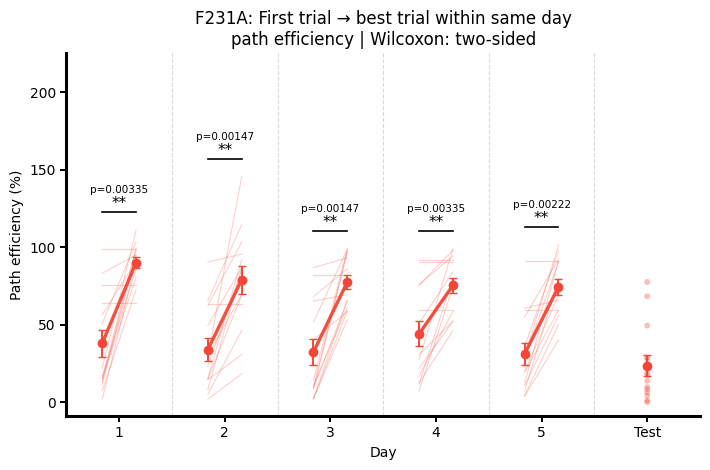

In [263]:
# ============================================================
# Flexible genotype:
# Plot "first trial of each day" -> "best trial of same day"
# Metric: path efficiency (%)
#
# Within-day progress:
#   Day 1 trial 1 -> Day 1 best trial
#   Day 2 trial 1 -> Day 2 best trial
#   Day 3 trial 1 -> Day 3 best trial
#   Day 4 trial 1 -> Day 4 best trial
#   Day 5 trial 1 -> Day 5 best trial
#
# Test day:
#   only one trial, so it is plotted as one dot only
#   no paired line / Wilcoxon test for Test
#
# IMPORTANT:
# For path efficiency, "best trial" = HIGHEST path_eff
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
#   alternative='greater' tests whether best trial > first trial
#   alternative='two-sided' tests whether first and best are different
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'F231A'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control', 'F231A'
PLOT_INDIVIDUAL = True          # False -> only mean ± SEM

EXCLUDE_ID = ['AN', 'BQ', 'BP'] # e.g. ['AS']
EXCLUDE_SUBS = []               # e.g. [43]

# Optional short-duration filtering
FILTER_SHORT_DURATION = False

VALUE_COL = 'path_eff'
VALUE_LABEL = 'Path efficiency (%)'
TITLE_SUFFIX = 'path efficiency'

# Wilcoxon:
# 'greater' = tests whether best trial path_eff > first trial path_eff
# 'less' = tests whether best trial path_eff < first trial path_eff
# 'two-sided' = tests whether first and best are different
WILCOXON_ALTERNATIVE = 'two-sided'

SHOW_P_VALUES = True
SHOW_STARS = True
P_DECIMALS = 5

# x-axis positioning
X_FIRST_OFFSET = -0.16
X_BEST_OFFSET  =  0.16

# p-value annotation spacing
P_LINE_FRAC_ABOVE = 0.08
P_STAR_FRAC_ABOVE = 0.004   # smaller = star closer to horizontal line
P_TEXT_FRAC_ABOVE = 0.075

# y-axis
YMIN = None          # None -> slightly below 0
YMAX = None          # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
needed_cols = ['usable', 'genotype', 'trial_type', 'trial_type_day', 'ses', 'sub', VALUE_COL]
missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GROUP_LABEL, f"({GENOTYPE_TO_PLOT})")
print("Using column:", VALUE_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) For each animal and day:
#    - first trial = trial_in_day == 1
#    - best trial = MAX path_eff within that day
# ------------------------------------------------------------
def per_subject_day_first_best(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, id, first_val, best_val

    For path efficiency:
      best_val = maximum path_eff within that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'first_val', 'best_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        first_val = by_trial.get(1, np.nan)
        best_val = np.nanmax(by_trial.values.astype(float))  # higher path_eff = better

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'first_val': float(first_val),
            'best_val': float(best_val)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build within-day comparison values
# ------------------------------------------------------------
within_day = []

for d in plot_days:
    df_d = per_subject_day_first_best(meta_LT, d, VALUE_COL)

    within_day.append({
        'day': d,
        'df': df_d
    })

print("\nAnimals included per within-day comparison:")
for wd in within_day:
    d = wd['day']
    df_d = wd['df']
    day_label = 'Test' if d == 6 else f'Day {d}'
    print(
        f"  {day_label}: n = {len(df_d)}, "
        f"animals = {list(df_d['id']) if len(df_d) > 0 else []}"
    )

# ------------------------------------------------------------
# 6) Stats + plotting helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def run_wilcoxon_paired(first_vals, best_vals, alternative='greater'):
    """
    Paired Wilcoxon signed-rank test.

    This calls:
        wilcoxon(best_vals, first_vals, alternative=alternative)

    For path efficiency:
      alternative='greater' tests whether best_vals > first_vals.
      alternative='less' tests whether best_vals < first_vals.
      alternative='two-sided' tests whether best_vals != first_vals.

    If all differences are zero, scipy raises an error;
    in that case return p=1.
    """
    first_vals = np.asarray(first_vals, float)
    best_vals = np.asarray(best_vals, float)

    ok = np.isfinite(first_vals) & np.isfinite(best_vals)
    first_vals = first_vals[ok]
    best_vals = best_vals[ok]

    if len(first_vals) == 0:
        return np.nan, np.nan

    diffs = best_vals - first_vals

    if np.allclose(diffs, 0):
        return 0.0, 1.0

    try:
        stat, p = wilcoxon(
            best_vals,
            first_vals,
            alternative=alternative,
            zero_method='wilcox'
        )
    except ValueError:
        stat, p = np.nan, np.nan

    return stat, p


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Run stats first
#    Test day is skipped because it usually has only one trial.
# ------------------------------------------------------------
print("\nWilcoxon signed-rank tests: first trial vs best trial of same day")
print(f"Alternative used: {WILCOXON_ALTERNATIVE}")
print("Test day is plotted as one dot only and is not tested.")

stats_results = {}

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    day_label = 'Test' if d == 6 else f'Day {d}'

    if d == 6:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': len(df_d)
        }
        print(f"  {day_label}: n = {len(df_d)}, no test")
        continue

    if len(df_d) == 0:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': 0
        }
        print(f"  {day_label}: n = 0, p = NaN")
        continue

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    stat, p = run_wilcoxon_paired(
        first_vals,
        best_vals,
        alternative=WILCOXON_ALTERNATIVE
    )

    stats_results[d] = {
        'stat': stat,
        'p': p,
        'n': len(df_d)
    }

    print(
        f"  {day_label}: "
        f"n = {len(df_d)}, "
        f"first mean = {np.nanmean(first_vals):.3f}%, "
        f"best mean = {np.nanmean(best_vals):.3f}%, "
        f"median diff best-first = {np.nanmedian(best_vals - first_vals):.3f}%, "
        f"W = {stat:.3f}, "
        f"p = {format_p(p, P_DECIMALS)}"
        if np.isfinite(p)
        else
        f"  {day_label}: n = {len(df_d)}, p = NaN"
    )

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))

col = get_genotype_color(GENOTYPE_TO_PLOT)

all_y_for_ylim = []

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    if len(df_d) == 0:
        continue

    # --------------------------------------------------------
    # Test day:
    # only plot single trial/best point, no paired line/stat
    # dots remain
    # --------------------------------------------------------
    if d == 6:
        x_test = d

        test_vals = df_d['first_val'].values.astype(float)
        test_vals = test_vals[np.isfinite(test_vals)]

        all_y_for_ylim.extend(test_vals)

        if len(test_vals) == 0:
            continue

        if PLOT_INDIVIDUAL:
            ax.scatter(
                np.full(len(test_vals), x_test),
                test_vals,
                color=col,
                s=18,
                alpha=0.35,
                edgecolor='none',
                zorder=2
            )

        m_test, s_test = mean_sem(test_vals)

        ax.errorbar(
            x_test,
            m_test,
            yerr=s_test,
            fmt='o',
            color=col,
            markersize=6,
            capsize=3,
            linewidth=1.4,
            zorder=5
        )

        continue

    x_first = d + X_FIRST_OFFSET
    x_best  = d + X_BEST_OFFSET

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    all_y_for_ylim.extend(first_vals[np.isfinite(first_vals)])
    all_y_for_ylim.extend(best_vals[np.isfinite(best_vals)])

    # --------------------------------------------------------
    # 1) Individual animal paired lines only
    #    No individual dots for learning days 1-5
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_d.iterrows():
            y_first = row['first_val']
            y_best = row['best_val']

            ax.plot(
                [x_first, x_best],
                [y_first, y_best],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    m_first, s_first = mean_sem(first_vals)
    m_best, s_best = mean_sem(best_vals)

    ax.plot(
        [x_first, x_best],
        [m_first, m_best],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=4
    )

    ax.errorbar(
        x_first,
        m_first,
        yerr=s_first,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

    ax.errorbar(
        x_best,
        m_best,
        yerr=s_best,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

# ------------------------------------------------------------
# 9) Add p-value bars after determining y scale
# ------------------------------------------------------------
if len(all_y_for_ylim) > 0:
    y_data_max = np.nanmax(all_y_for_ylim)
    y_data_min = np.nanmin(all_y_for_ylim)

    yrng = y_data_max - y_data_min
    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(y_data_max), 1.0)

    for wd in within_day:
        d = wd['day']
        df_d = wd['df']

        # Skip test day
        if d == 6:
            continue

        if len(df_d) == 0:
            continue

        x_first = d + X_FIRST_OFFSET
        x_best  = d + X_BEST_OFFSET
        x_mid = (x_first + x_best) / 2

        local_vals = np.r_[
            df_d['first_val'].values.astype(float),
            df_d['best_val'].values.astype(float)
        ]

        local_max = np.nanmax(local_vals)

        y_line = local_max + P_LINE_FRAC_ABOVE * yrng
        y_star = y_line + P_STAR_FRAC_ABOVE * yrng
        y_pval = y_line + P_TEXT_FRAC_ABOVE * yrng

        p = stats_results[d]['p']

        ax.plot(
            [x_first, x_best],
            [y_line, y_line],
            color='black',
            linewidth=1.2,
            zorder=6
        )

        if SHOW_STARS:
            ax.text(
                x_mid,
                y_star,
                p_to_stars(p),
                ha='center',
                va='bottom',
                fontsize=11,
                zorder=7
            )

        if SHOW_P_VALUES:
            ax.text(
                x_mid,
                y_pval,
                f"p={format_p(p, P_DECIMALS)}",
                ha='center',
                va='bottom',
                fontsize=7.5,
                zorder=7
            )

# ------------------------------------------------------------
# 10) Styling
# ------------------------------------------------------------
for d in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(
        d,
        color='0.85',
        linestyle='--',
        linewidth=0.8,
        zorder=0
    )

ax.set_xticks(plot_days)
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(0.5, 6.5)

ax.set_xlabel('Day')
ax.set_ylabel(VALUE_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: First trial → best trial within same day\n'
    f'{TITLE_SUFFIX} | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y_for_ylim) > 0:
        ymax = np.nanmax(all_y_for_ylim)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.55
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)

plt.tight_layout()
plt.show()

Using genotype: F231A (F231A)
Using column: path_eff
Using trial column: inferred from sub/ses order

Group plotted: F231A (F231A)
Using column: path_eff
Animals included per transition:
  Day 1 best -> Day 2 trial 1: n = 14
  Day 2 best -> Day 3 trial 1: n = 14
  Day 3 best -> Day 4 trial 1: n = 14
  Day 4 best -> Day 5 trial 1: n = 14
  Day 5 best -> Test trial 1: n = 14


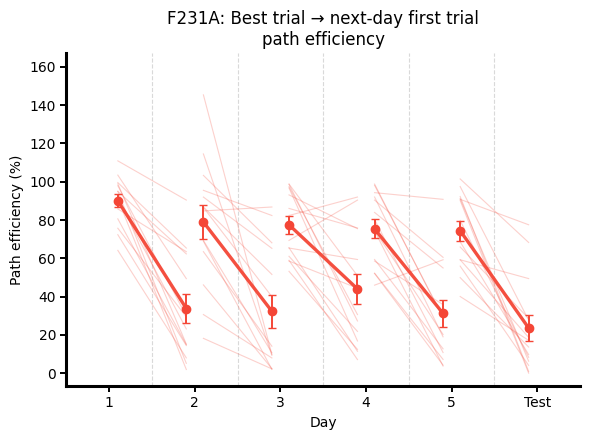

In [264]:
# ============================================================
# Flexible genotype:
# Plot "best trial from previous day" -> "first trial next day"
# Metric: path efficiency
#
# Transitions plotted:
#   Day 1 best  -> Day 2 trial 1
#   Day 2 best  -> Day 3 trial 1
#   Day 3 best  -> Day 4 trial 1
#   Day 4 best  -> Day 5 trial 1
#   Day 5 best  -> Test day trial 1
#
# IMPORTANT:
# For path efficiency, "best trial" = HIGHEST path_eff
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'F231A'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control', 'F231A'
PLOT_INDIVIDUAL = True          # False -> only mean ± SEM

EXCLUDE_ID = ['AN', 'BQ', 'BP'] # e.g. ['AS']
EXCLUDE_SUBS = []               # e.g. [43]

FILTER_SHORT_DURATION = False   # True -> apply short_duration != 1
                                # False -> no short_duration filter

VALUE_COL = 'path_eff'
VALUE_LABEL = 'Path efficiency (%)'
TITLE_SUFFIX = 'path efficiency'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

# y-axis
YMIN = None          # None -> auto with slight padding below 0
YMAX = None          # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
needed_cols = ['usable', 'genotype', 'trial_type', 'trial_type_day', 'ses', 'sub', VALUE_COL]
missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GROUP_LABEL, f"({GENOTYPE_TO_PLOT})")
print("Using column:", VALUE_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")

# ------------------------------------------------------------
# 4) For each animal and day:
#    - best trial = MAX path_eff within that day
#    - first trial = trial_in_day == 1
# ------------------------------------------------------------
def per_subject_day_values(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, best_val, first_val

    For path efficiency:
      best_val = maximum path_eff within that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'best_val', 'first_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        best_val = np.nanmax(by_trial.values.astype(float))   # higher path_eff = better
        first_val = by_trial.get(1, np.nan)

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'best_val': best_val,
            'first_val': first_val
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build transition values:
#    day d best -> day d+1 first
# ------------------------------------------------------------
transitions = []

for d_prev, d_next in [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]:
    prev_df = (
        per_subject_day_values(meta_LT, d_prev, VALUE_COL)[['sub', 'best_val']]
        .rename(columns={'best_val': 'y_prev'})
    )

    next_df = (
        per_subject_day_values(meta_LT, d_next, VALUE_COL)[['sub', 'first_val']]
        .rename(columns={'first_val': 'y_next'})
    )

    merged = prev_df.merge(next_df, on='sub', how='inner').dropna()

    transitions.append({
        'd_prev': d_prev,
        'd_next': d_next,
        'df': merged
    })

print(f"\nGroup plotted: {GROUP_LABEL} ({GENOTYPE_TO_PLOT})")
print(f"Using column: {VALUE_COL}")
print("Animals included per transition:")

for tr in transitions:
    n = len(tr['df'])
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    nxt_label = 'Test' if d_next == 6 else f'Day {d_next}'
    print(f"  Day {d_prev} best -> {nxt_label} trial 1: n = {n}")

# ------------------------------------------------------------
# 6) Plot helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

col = get_genotype_color(GENOTYPE_TO_PLOT)

# x positions
x_best_offset  = 0.6
x_first_offset = 0.4

all_y = []

for tr in transitions:
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    df_tr = tr['df']

    if len(df_tr) == 0:
        continue

    x_prev = d_prev + x_best_offset
    x_next = d_next + x_first_offset

    # --------------------------------------------------------
    # 1) Individual animal lines
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_tr.iterrows():
            y_prev = row['y_prev']
            y_next = row['y_next']

            ax.plot(
                [x_prev, x_next],
                [y_prev, y_next],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

            all_y.extend([y_prev, y_next])

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    y_prev = df_tr['y_prev'].values.astype(float)
    y_next = df_tr['y_next'].values.astype(float)

    all_y.extend(list(y_prev) + list(y_next))

    m_prev, s_prev = mean_sem(y_prev)
    m_next, s_next = mean_sem(y_next)

    ax.plot(
        [x_prev, x_next],
        [m_prev, m_next],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=3
    )

    ax.errorbar(
        x_prev,
        m_prev,
        yerr=s_prev,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x_next,
        m_next,
        yerr=s_next,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for d in [2, 3, 4, 5, 6]:
    ax.axvline(d, color='0.85', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(1.0, 7.0)

ax.set_xlabel('Day')
ax.set_ylabel(VALUE_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: Best trial → next-day first trial\n'
    f'{TITLE_SUFFIX}',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y) > 0:
        ymax = np.nanmax(all_y)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.15
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()

Using genotype: F231A WT (F231A_wt)
Using column: path_eff
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 9
   sub  id  Day 1 trial 1 trials  Test trials
0   47  BA                     1            1
1   49  BC                     1            1
2   50  BD                     1            1
3   56  BJ                     1            1
4   60  BO                     1            1
5   90  F1                     1            1
6   91  F2                     1            1
7   94  F5                     1            1
8   95  F6                     1            1

Paired values used for Wilcoxon:
   sub  id         y1         y2  diff_y2_minus_y1  n1  n2
0   47  BA   4.381893   5.626034          1.244141   1   1
1   49  BC   1.963299   0.877618         -1.085681   1   1
2   50  BD   8.296410   1.661833         -6.634577   1   1
3   56  BJ  42.023570   4.361235        -37.662335   1   1
4   60  BO  87.565652   8.194581        -7

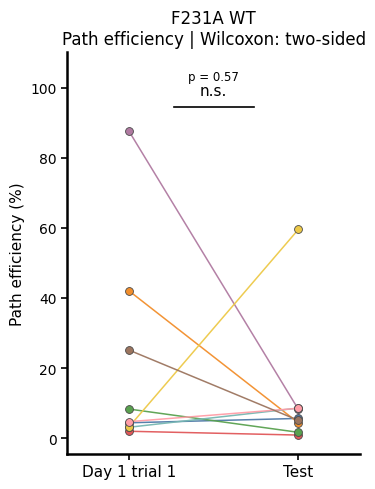

In [300]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flexible genotype:
# Paired comparison for path efficiency
#
# COMPARE_MODE:
#   'day1_vs_test':
#       Day 1 = trial 1 only
#       Test  = first post-learning test trial only
#
#   'day1_vs_day5':
#       Day 1 = mean across available Day 1 trials
#       Day 5 = mean across available Day 5 trials
#
#   'day1_trial1_vs_day5_trial1':
#       Day 1 = trial 1 only
#       Day 5 = trial 1 only
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_vs_test'
# COMPARE_MODE = 'day1_vs_test'
# COMPARE_MODE = 'day1_vs_day5'

GENOTYPE_TO_USE = 'F231A_wt'

PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False
SHOW_ANIMAL_IDS = False

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

VALUE_COL = 'path_eff'
VALUE_LABEL = 'Path efficiency (%)'

FILTER_SHORT_DURATION = False

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether y1 > y2
# 'less'      = tests whether y1 < y2
WILCOXON_ALTERNATIVE = 'two-sided'

INDIVIDUAL_COLOR_MODE = 'pastel'
DOT_EDGE = True

YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Filter
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using column:", VALUE_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    """
    One value per animal = mean across available trials in that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(np.nanmean(by_trial.values)),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day, value_col):
    """
    One value per animal = trial 1 only from that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 6, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    comparison_description = 'Day 1 trial 1 vs Test trial 1'

elif COMPARE_MODE == 'day1_vs_day5':
    day1_df = per_subject_day_mean(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_mean(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1'
    right_label = 'Day 5'
    comparison_description = 'Day 1 daily mean vs Day 5 daily mean'

elif COMPARE_MODE == 'day1_trial1_vs_day5_trial1':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Day 5 trial 1'
    comparison_description = 'Day 1 trial 1 vs Day 5 trial 1'

else:
    raise ValueError(
        "COMPARE_MODE must be 'day1_vs_test', "
        "'day1_vs_day5', or 'day1_trial1_vs_day5_trial1'"
    )

title_txt = f'{GENOTYPE_LABEL}'

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
if len(paired) > 0:
    paired_print = paired.copy()
    paired_print['diff_y2_minus_y1'] = paired_print['y2'] - paired_print['y1']
    print(paired_print[['sub', 'id', 'y1', 'y2', 'diff_y2_minus_y1', 'n1', 'n2']])
else:
    print("No paired data.")

# ------------------------------------------------------------
# 6) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.3g}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)

print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")
print(comparison_description)

# ------------------------------------------------------------
# 7) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

x1, x2 = 0.00, 0.55

n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'], row['y2']],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'], row['y2']],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'],
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

if PLOT_GROUP_MEAN and len(y1) > 0:
    m1 = np.nanmean(y1)
    m2 = np.nanmean(y2)

    s1 = 0.0 if len(y1) <= 1 else np.nanstd(y1, ddof=1) / np.sqrt(len(y1))
    s2 = 0.0 if len(y2) <= 1 else np.nanstd(y2, ddof=1) / np.sqrt(len(y2))

    ax.plot([x1, x2], [m1, m2], '-', color=base_col, linewidth=2.4, zorder=3)

    ax.errorbar(
        x1, m1, yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2, m2, yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# significance line + stars + p value
all_y = np.r_[y1, y2]

if len(all_y) > 0 and np.isfinite(all_y).any():
    ymax_data = np.nanmax(all_y)
    ymin_data = np.nanmin(all_y)
    yrng = ymax_data - ymin_data

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = ymax_data if ymax_data > 0 else 1.0

    y_line = ymax_data + 0.08 * yrng
    y_star = ymax_data + 0.11 * yrng
    y_pval = ymax_data + 0.16 * yrng
else:
    ymax_data = 1.0
    yrng = 1.0
    y_line = 1.08
    y_star = 1.11
    y_pval = 1.16

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel(VALUE_LABEL, fontsize=11)

ax.set_title(
    f'{title_txt}\nPath efficiency | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is not None:
    ymax = YMAX
else:
    ymax = y_pval + 0.10 * yrng

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()

# forgetting vs extinction



############################################################
RUNNING METRIC: CIPL
Metric label: Extra distance travelled (cm)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Line plot genotypes: ['ChR2']
Endpoint ordinary boxplot controls: eYFP_ChR2
SEM style: bar
CIPL values are plotted directly in cm; no extra conversion applied.
############################################################

All valid TEST rows before aggregate-cohort restriction:
    sub  id   genotype   test_type  trial_type_day         CIPL
0     1   A       ChR2  extinction               1   114.022035
1     1   A       ChR2  extinction               2   548.507077
2     1   A       ChR2  extinction               3   398.718595
3     6  AB       ChR2  extinction               1   119.904836
4     6  AB       ChR2  extinction               2   814.656024
..  ...  ..        ...         ...             ...          ...
93   22

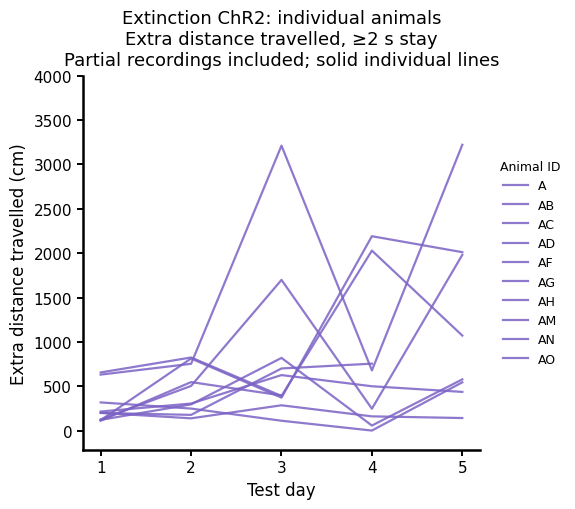


Individual ChR2 lines: Forgetting
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort restriction applied: NO
Animals with any available test day are included.
   sub  id available_days  n_days
0    6  AB         [1, 5]       2
1    7  AC         [1, 5]       2
2    9  AE         [1, 5]       2
3   10  AF         [1, 5]       2
4   11  AG         [1, 5]       2
5   12  AH         [1, 5]       2
6   16  AM         [1, 5]       2
7   17  AN         [1, 5]       2
8   18  AO         [1, 5]       2


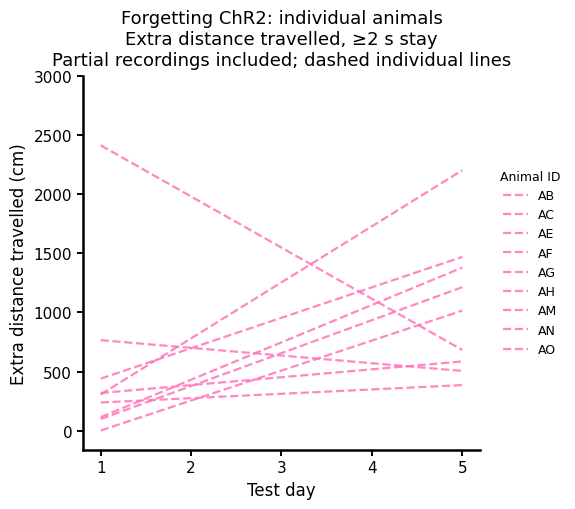


Animals included in ChR2-only aggregate line plot:
  Forgetting – ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
  Extinction – ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(16), np.int64(17), np.int64(18)]


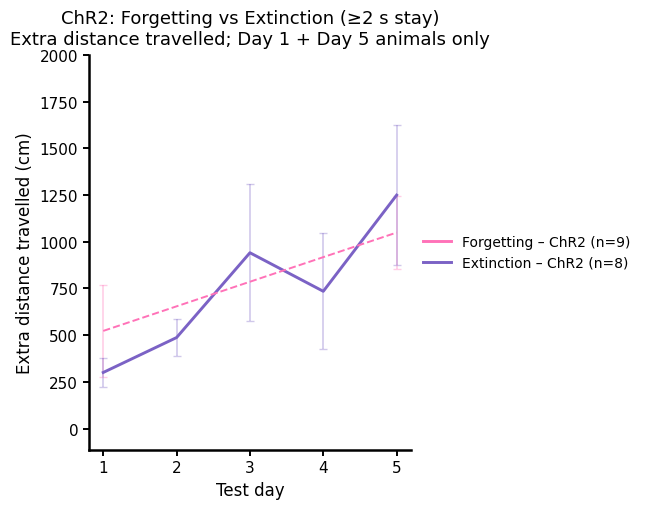


Ordinary boxplot: Test day 1
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [119.9048 633.0173 202.5025 217.0256 128.1181 657.6098 123.0602 319.9406]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values = [ 884.8126 2636.2206]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values = [2411.9011  766.0222  319.8257   99.5919  239.4466  440.7393  307.5459
  115.5983    2.7693]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values = [ 701.2679 1660.941 ]

Mann–Whitney U tests, test day 1:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=300.147 vs 1760.517, median=209.764 vs 1760.517, U=0.0, rank-biserial=-1.000, p=0.04444
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean

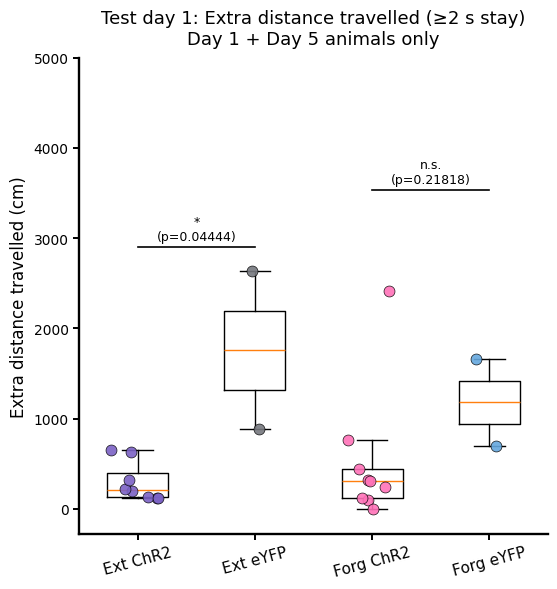


Ordinary boxplot: Test day 2
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [814.656  754.9897 140.62   307.1504 505.3812 825.9062 297.6532 250.3585]

Mann–Whitney U tests, test day 2:
  No between-group comparison specified for this plot.


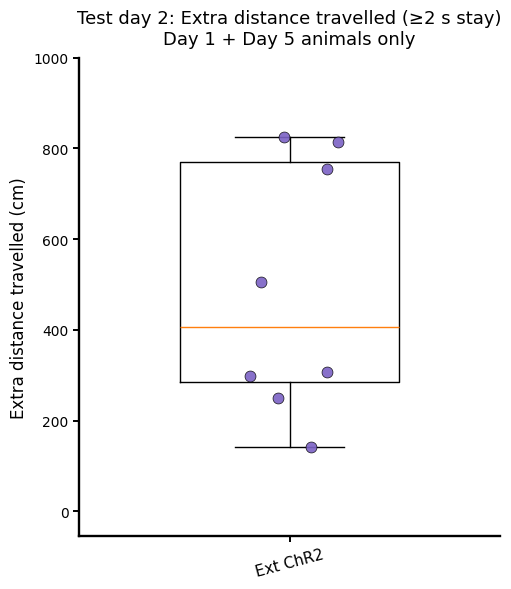


Ordinary boxplot: Test day 3
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [ 373.4972 3212.3612  287.5324  627.659  1699.961   392.5242  821.2246
  113.3266]

Mann–Whitney U tests, test day 3:
  No between-group comparison specified for this plot.


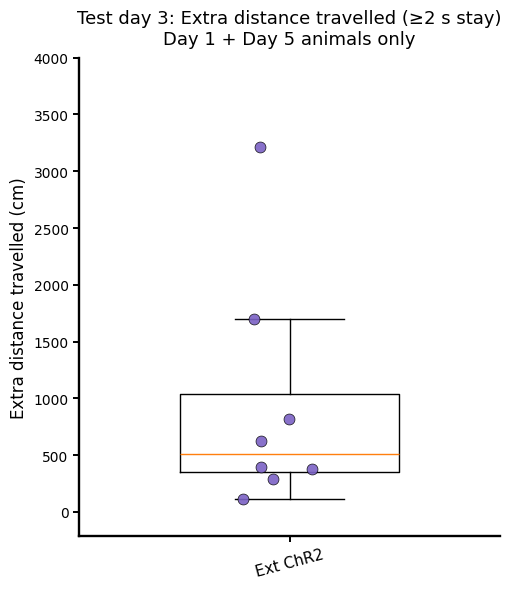


Ordinary boxplot: Test day 4
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [2192.1009  680.2622  162.7476  501.8201  248.451  2030.0052   59.3745
    2.7952]

Mann–Whitney U tests, test day 4:
  No between-group comparison specified for this plot.


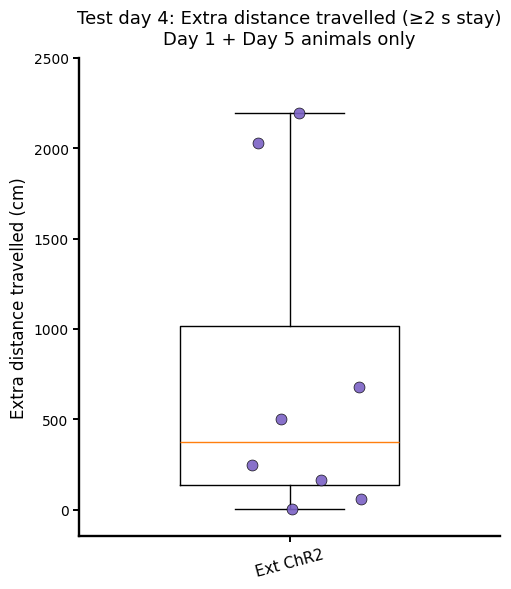


Ordinary boxplot: Test day 5
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [2012.0654 3222.138   143.9657  438.2278 1982.0328 1072.6358  579.2187
  546.1281]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values = [2432.913  1944.7543]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values = [ 683.2499  506.1946  586.1536 1213.5895  386.4675 1469.4518 2201.6898
 1379.4247 1015.7567]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values = [884.9776 712.9489]

Mann–Whitney U tests, test day 5:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=1249.552 vs 2188.834, median=825.927 vs 2188.834, U=4.0, rank-biserial=-0.500, p=0.40000
  Forg ChR2 vs Forg eYFP: n=9 vs

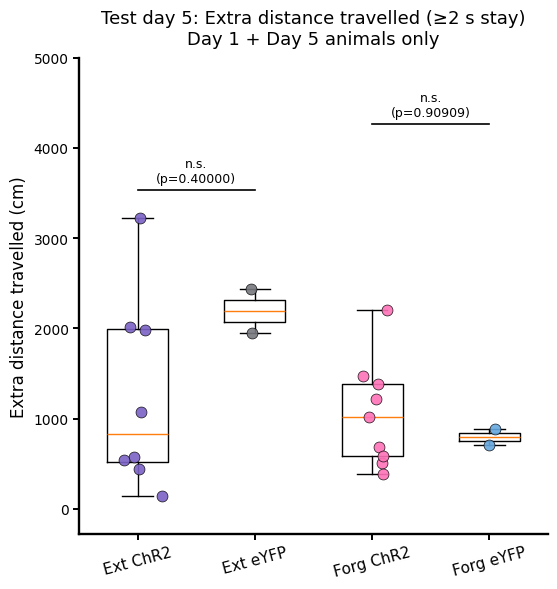


Paired ChR2 Extinction vs Forgetting, test day 1
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id   ext_value   forg_value
0    6  AB  119.904836  2411.901062
1    7  AC  633.017337   766.022233
2   10  AF  217.025622    99.591853
3   11  AG  128.118111   239.446642
4   16  AM  657.609774   307.545919
5   17  AN  123.060222   115.598299
6   18  AO  319.940633     2.769320
Wilcoxon paired test: n=7, Ext mean=314.097, Forg mean=563.268, Ext median=217.026, Forg median=239.447, stat=13.000, p=0.93750


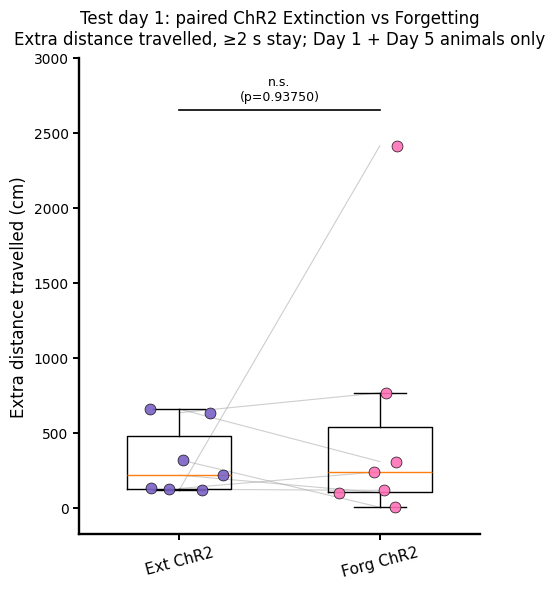


Paired ChR2 Extinction vs Forgetting, test day 5
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id    ext_value   forg_value
0    6  AB  2012.065351   683.249907
1    7  AC  3222.137970   506.194623
2   10  AF   438.227755  1213.589494
3   11  AG  1982.032838   386.467453
4   16  AM  1072.635828  2201.689792
5   17  AN   579.218651  1379.424719
6   18  AO   546.128097  1015.756724
Wilcoxon paired test: n=7, Ext mean=1407.492, Forg mean=1055.196, Ext median=1072.636, Forg median=1015.757, stat=10.000, p=0.57812


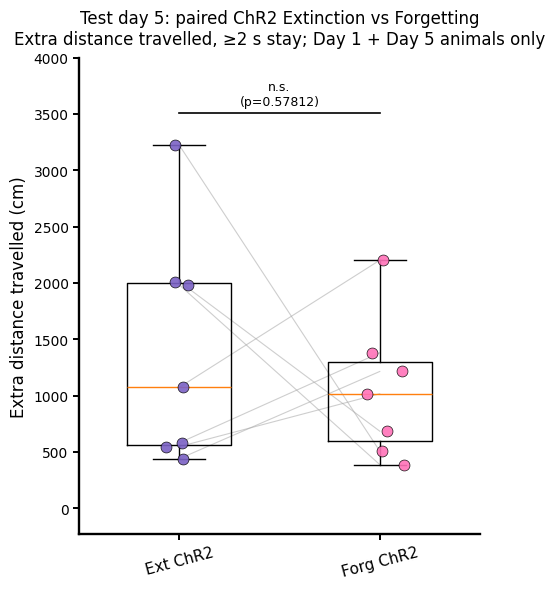


Paired ChR2 extinction: Day 1 vs Day 5
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value   day5_value
0    6  AB  119.904836  2012.065351
1    7  AC  633.017337  3222.137970
2    8  AD  202.502457   143.965676
3   10  AF  217.025622   438.227755
4   11  AG  128.118111  1982.032838
5   16  AM  657.609774  1072.635828
6   17  AN  123.060222   579.218651
7   18  AO  319.940633   546.128097
Wilcoxon paired test: n=8, Day1 mean=300.147, Day5 mean=1249.552, Day1 median=209.764, Day5 median=825.927, stat=1.000, p=0.01562


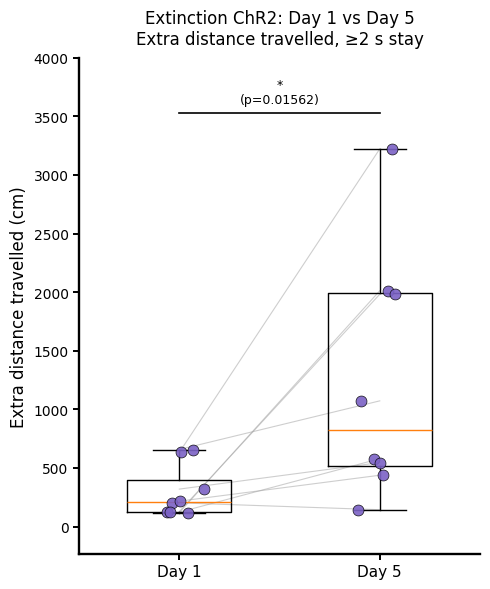


Paired ChR2 forgetting: Day 1 vs Day 5
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id   day1_value   day5_value
0    6  AB  2411.901062   683.249907
1    7  AC   766.022233   506.194623
2    9  AE   319.825697   586.153568
3   10  AF    99.591853  1213.589494
4   11  AG   239.446642   386.467453
5   12  AH   440.739325  1469.451777
6   16  AM   307.545919  2201.689792
7   17  AN   115.598299  1379.424719
8   18  AO     2.769320  1015.756724
Wilcoxon paired test: n=9, Day1 mean=522.604, Day5 mean=1049.109, Day1 median=307.546, Day5 median=1015.757, stat=10.000, p=0.16406


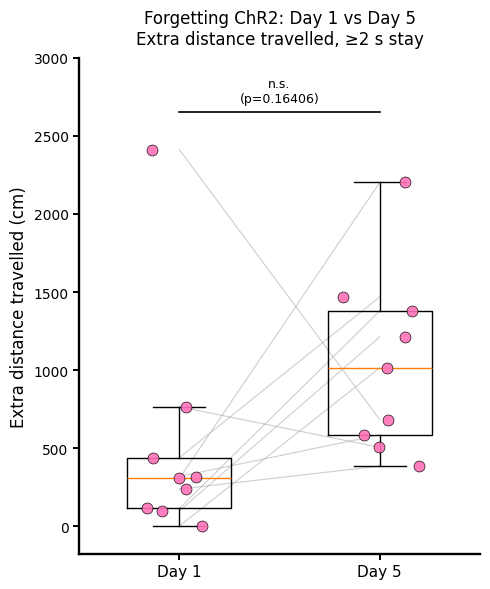



############################################################
RUNNING METRIC: path_eff
Metric label: Path efficiency (%)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Line plot genotypes: ['ChR2']
Endpoint ordinary boxplot controls: eYFP_ChR2
SEM style: bar
############################################################

All valid TEST rows before aggregate-cohort restriction:
    sub  id   genotype   test_type  trial_type_day   path_eff
0     1   A       ChR2  extinction               1  16.308764
1     1   A       ChR2  extinction               2  10.275099
2     1   A       ChR2  extinction               3   9.393939
3     6  AB       ChR2  extinction               1  29.013453
4     6  AB       ChR2  extinction               2   8.572336
..  ...  ..        ...         ...             ...        ...
93   22   F  eYFP_ChR2  extinction               4   0.000000
94   23   G  eYFP_ChR2  extinction

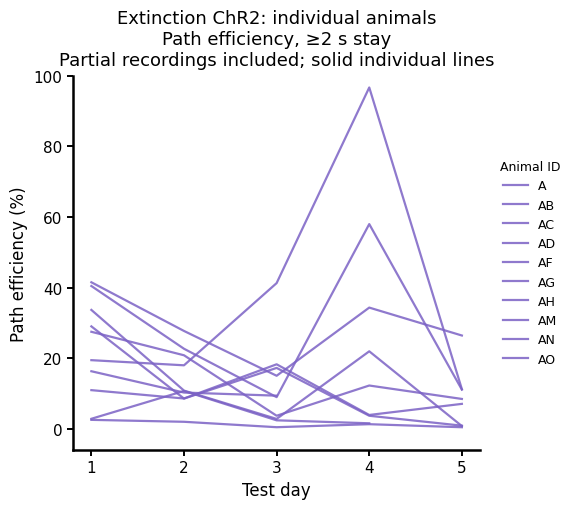


Individual ChR2 lines: Forgetting
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort restriction applied: NO
Animals with any available test day are included.
   sub  id available_days  n_days
0    6  AB         [1, 5]       2
1    7  AC         [1, 5]       2
2    9  AE         [1, 5]       2
3   10  AF         [1, 5]       2
4   11  AG         [1, 5]       2
5   12  AH         [1, 5]       2
6   16  AM         [1, 5]       2
7   17  AN         [1, 5]       2
8   18  AO         [1, 5]       2


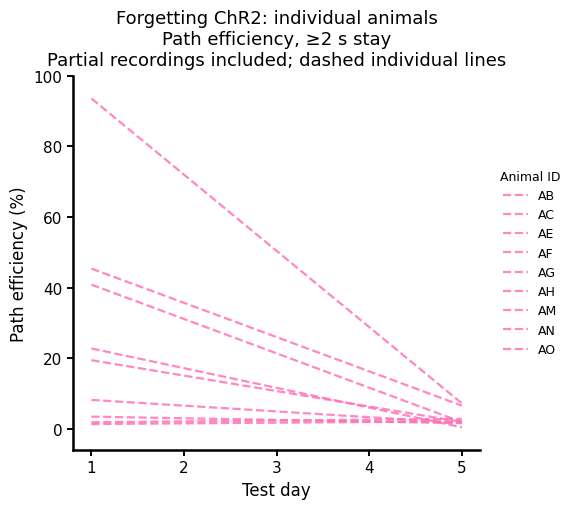


Animals included in ChR2-only aggregate line plot:
  Forgetting – ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
  Extinction – ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(16), np.int64(17), np.int64(18)]


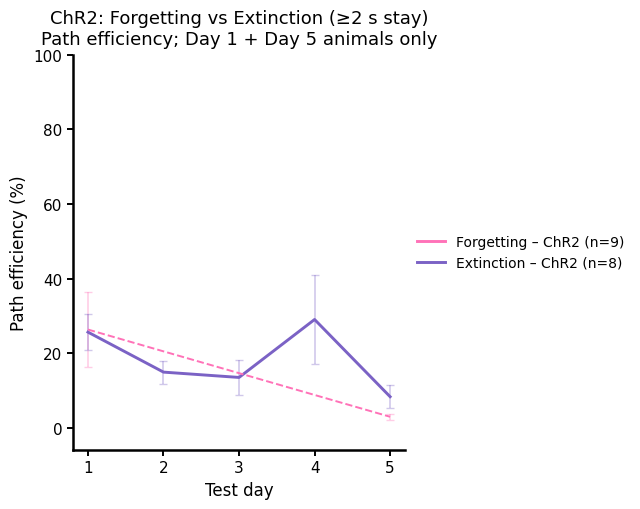


Ordinary boxplot: Test day 1
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [29.0135  2.5435 41.5039 27.4855 33.6784 10.9571 40.446  19.4467]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values = [4.3264 0.8454]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values = [ 1.3565  1.8772 19.4438 45.3881 22.7669  3.4532  8.2003 40.8501 93.572 ]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values = [4.8836 0.6232]

Mann–Whitney U tests, test day 1:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=25.634 vs 2.586, median=28.249 vs 2.586, U=15.0, rank-biserial=0.875, p=0.08889
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=26.323 vs 2.753, median=19.444 vs 2.753, U=15.0, ran

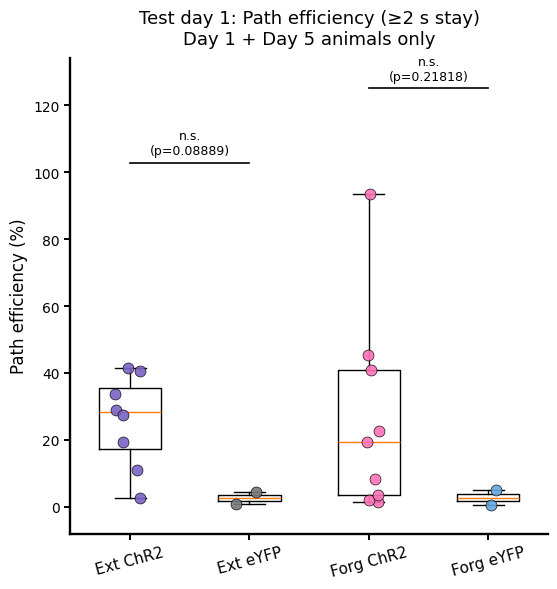


Ordinary boxplot: Test day 2
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [ 8.5723  1.9972 27.7177 20.8325 10.8279  8.5911 22.6787 17.9934]

Mann–Whitney U tests, test day 2:
  No between-group comparison specified for this plot.


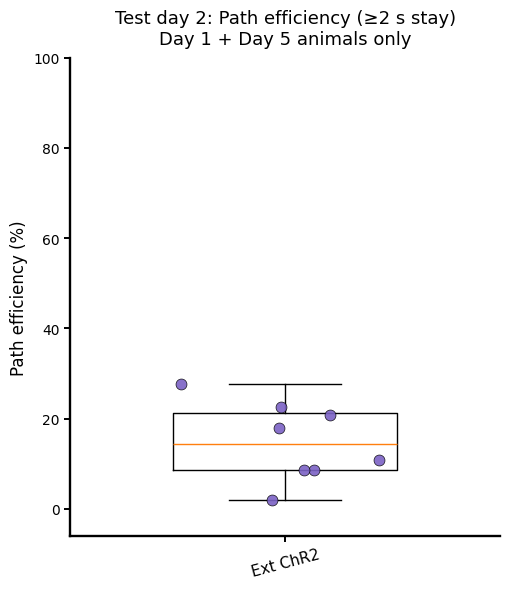


Ordinary boxplot: Test day 3
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [17.2508  0.4638 15.0301  3.7084  2.8125 18.2786  8.9777 41.268 ]

Mann–Whitney U tests, test day 3:
  No between-group comparison specified for this plot.


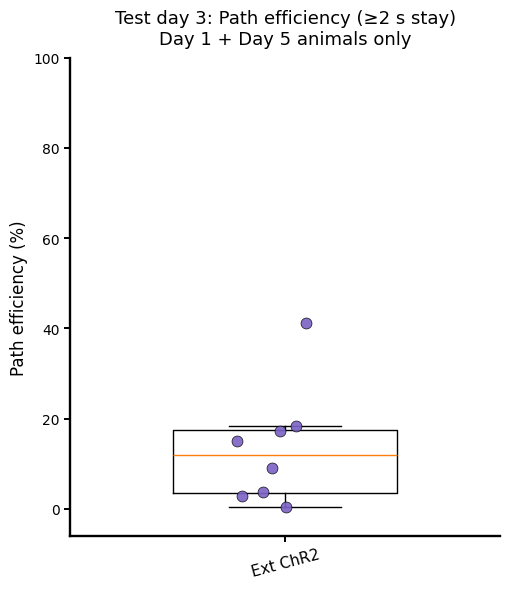


Ordinary boxplot: Test day 4
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [ 3.7039  1.3152 34.3347 12.2687 21.9562  3.9295 57.9815 96.6647]

Mann–Whitney U tests, test day 4:
  No between-group comparison specified for this plot.


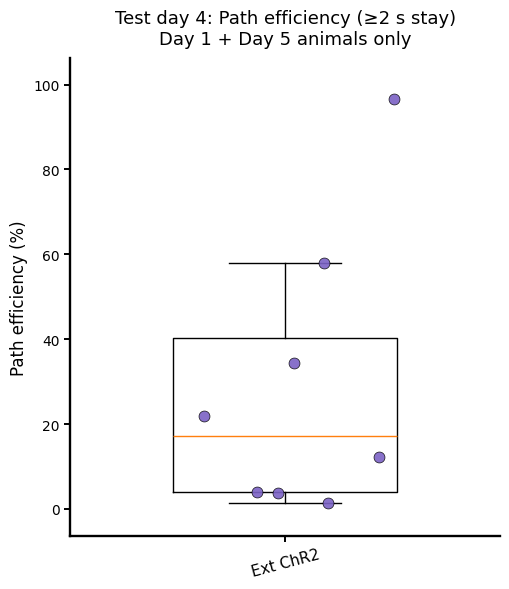


Ordinary boxplot: Test day 5
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values = [ 0.8979  0.4547 26.43    8.4656  0.7902  7.0699 11.0967 11.2411]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values = [0.0688 1.0412]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values = [2.1255 2.8214 1.9568 6.5736 0.4333 1.6004 1.6639 1.9031 7.2174]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values = [1.3879 0.    ]

Mann–Whitney U tests, test day 5:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=8.306 vs 0.555, median=7.768 vs 0.555, U=13.0, rank-biserial=0.625, p=0.26667
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=2.922 vs 0.694, median=1.957 vs 0.694, U=17.0, rank-biserial=0.

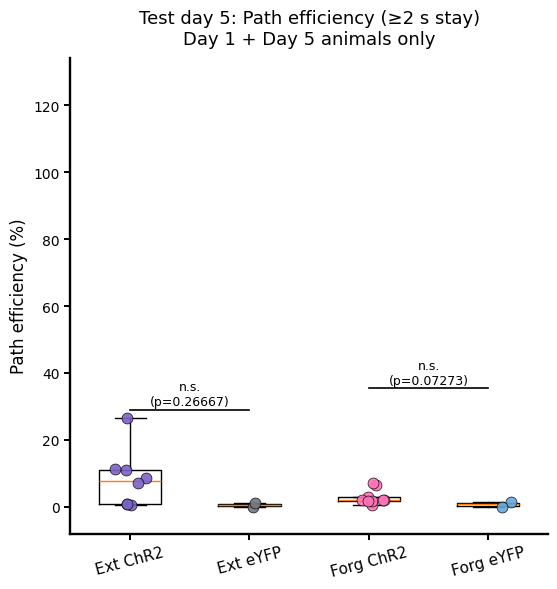


Paired ChR2 Extinction vs Forgetting, test day 1
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB  29.013453    1.356523
1    7  AC   2.543522    1.877151
2   10  AF  27.485456   45.388071
3   11  AG  33.678356   22.766897
4   16  AM  10.957060    8.200349
5   17  AN  40.446031   40.850125
6   18  AO  19.446727   93.571953
Wilcoxon paired test: n=7, Ext mean=23.367, Forg mean=30.573, Ext median=27.485, Forg median=22.767, stat=13.000, p=0.93750


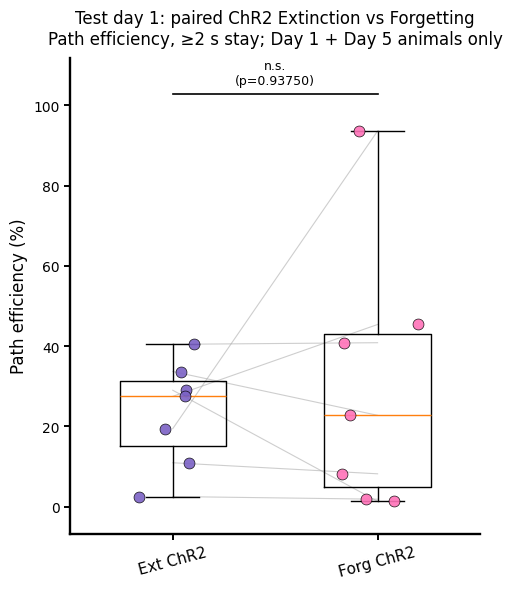


Paired ChR2 Extinction vs Forgetting, test day 5
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB   0.897864    2.125476
1    7  AC   0.454738    2.821415
2   10  AF   8.465583    6.573557
3   11  AG   0.790233    0.433335
4   16  AM   7.069854    1.663896
5   17  AN  11.096667    1.903113
6   18  AO  11.241094    7.217388
Wilcoxon paired test: n=7, Ext mean=5.717, Forg mean=3.248, Ext median=7.070, Forg median=2.125, stat=6.000, p=0.21875


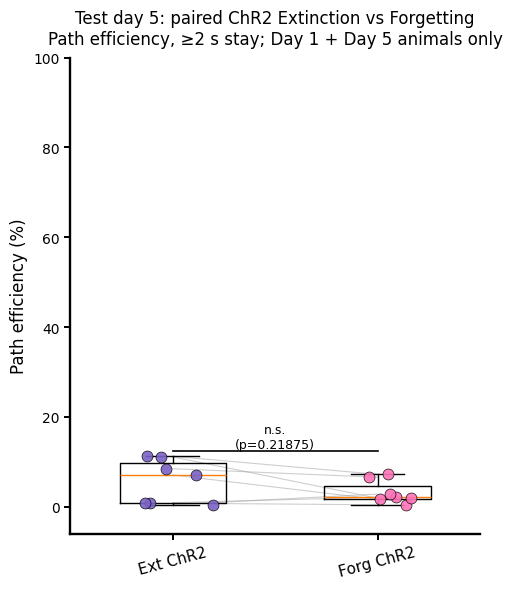


Paired ChR2 extinction: Day 1 vs Day 5
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB   29.013453    0.897864
1    7  AC    2.543522    0.454738
2    8  AD   41.503928   26.429995
3   10  AF   27.485456    8.465583
4   11  AG   33.678356    0.790233
5   16  AM   10.957060    7.069854
6   17  AN   40.446031   11.096667
7   18  AO   19.446727   11.241094
Wilcoxon paired test: n=8, Day1 mean=25.634, Day5 mean=8.306, Day1 median=28.249, Day5 median=7.768, stat=0.000, p=0.00781


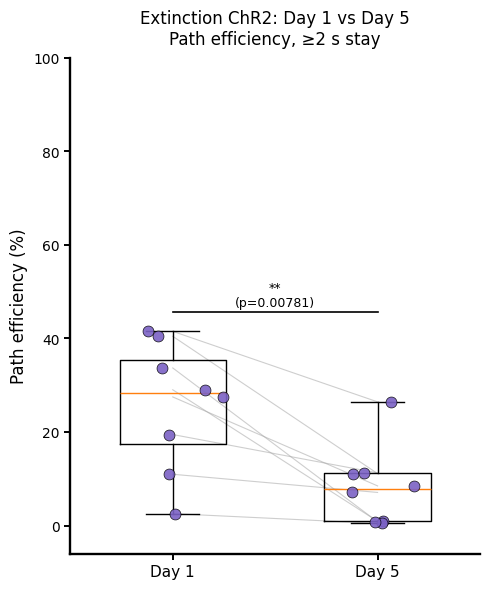


Paired ChR2 forgetting: Day 1 vs Day 5
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB    1.356523    2.125476
1    7  AC    1.877151    2.821415
2    9  AE   19.443836    1.956812
3   10  AF   45.388071    6.573557
4   11  AG   22.766897    0.433335
5   12  AH    3.453202    1.600367
6   16  AM    8.200349    1.663896
7   17  AN   40.850125    1.903113
8   18  AO   93.571953    7.217388
Wilcoxon paired test: n=9, Day1 mean=26.323, Day5 mean=2.922, Day1 median=19.444, Day5 median=1.957, stat=3.000, p=0.01953


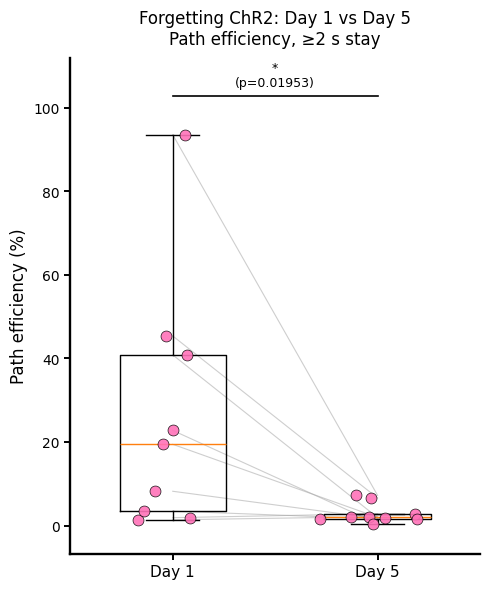

In [454]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon

# ============================================================
# Forgetting / Extinction TEST trials across test days 1-5
#
# Metrics:
#   1) CIPL
#        = extra distance travelled
#        = L_actual - L_shortest
#        = already stored in cm by the computing code
#
#   2) path_eff
#        = path efficiency
#        = L_shortest / L_actual * 100
#
# Produces:
#   1) Aggregate mean ± SEM line plot:
#        - ChR2 ONLY
#        - Forgetting ChR2 vs Extinction ChR2
#
#   2) Individual ChR2 extinction lines:
#        - ChR2 ONLY
#        - solid individual lines
#        - partial recordings included
#
#   3) Individual ChR2 forgetting lines:
#        - ChR2 ONLY
#        - dashed individual lines
#        - partial recordings included
#
#   4) Ordinary day boxplots:
#        - Test Day 1 and Test Day 5:
#             Ext ChR2, Ext eYFP, Forg ChR2, Forg eYFP
#             Comparisons:
#                 Ext ChR2 vs Ext eYFP
#                 Forg ChR2 vs Forg eYFP
#
#        - Test Day 2, 3 and 4:
#             Ext ChR2 ONLY
#             No eYFP plotted
#             No between-group comparison
#
#   5) Paired ChR2 Extinction vs Forgetting boxplots:
#        - Day 1 and Day 5
#        - ChR2 ONLY
#
#   6) Paired Day 1 vs Day 5 boxplots:
#        - ChR2 Extinction
#        - ChR2 Forgetting
#
# IMPORTANT:
#   - CIPL/path_eff must already be computed in metadata.
#   - CIPL is already in cm in the current computing code.
#   - Do NOT multiply CIPL by 1.2 again here.
#   - short_duration is NOT filtered anywhere in this code.
#   - REQUIRE_STAY_2S must already exist from computing code.
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

# ------------------------------------------------------------
# Genotypes used for each plot type
# ------------------------------------------------------------

# Aggregate line plots and individual-animal plots use ChR2 only.
LINE_GENOTYPES = ['ChR2']

# Endpoint ordinary boxplots additionally use eYFP control.
ENDPOINT_CONTROL_GENOTYPE = 'eYFP_ChR2'
INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS = True

# All genotypes required to be loaded from metadata.
GENOTYPES_TO_LOAD = ['ChR2']

if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
    GENOTYPES_TO_LOAD.append(ENDPOINT_CONTROL_GENOTYPE)

GENOTYPES_TO_LOAD = sorted(set(GENOTYPES_TO_LOAD))

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# ------------------------------------------------------------
# Stay criterion label from computing code
# ------------------------------------------------------------

if 'REQUIRE_STAY_2S' not in globals():
    raise NameError(
        "REQUIRE_STAY_2S is not defined. "
        "Run your CIPL/path_eff computing code first, or define "
        "REQUIRE_STAY_2S before plotting."
    )

STAY_TAG = '≥2 s stay' if REQUIRE_STAY_2S else 'all visits'

max_day = 5
day_values = np.arange(1, max_day + 1)

# ------------------------------------------------------------
# Aggregate/statistical cohort rule
# ------------------------------------------------------------
# Options:
#
#   'all'
#       Use all animals with at least one finite value.
#
#   'day1_day5'
#       Use only animals with finite values on both Day 1 and Day 5
#       within each genotype × test_type group.
#
#   'all_five'
#       Use only animals with finite values on Days 1-5.
#
# This rule applies independently to:
#   ChR2 extinction
#   ChR2 forgetting
#   eYFP extinction
#   eYFP forgetting
#
# Individual ChR2 trajectory plots ignore this restriction and show
# all animals with any available data.
# ------------------------------------------------------------

GROUP_PLOT_COHORT_MODE = 'day1_day5'
# GROUP_PLOT_COHORT_MODE = 'all'
# GROUP_PLOT_COHORT_MODE = 'all_five'

VALID_COHORT_MODES = ['all', 'day1_day5', 'all_five']

if GROUP_PLOT_COHORT_MODE not in VALID_COHORT_MODES:
    raise ValueError(
        f"GROUP_PLOT_COHORT_MODE must be one of {VALID_COHORT_MODES}."
    )

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

METRICS_TO_PLOT = [
    'CIPL',
    'path_eff',
]

# CIPL is already stored in cm by the computing code.
# These labels are used on the y-axis.
METRIC_LABEL = {
    'CIPL': 'Extra distance travelled (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'CIPL': 'Extra distance travelled',
    'path_eff': 'Path efficiency',
}

# IMPORTANT:
# The computing code has already converted CIPL into cm.
# Keep scale = 1.0 here to avoid converting it a second time.
METRIC_SCALE = {
    'CIPL': 1.0,
    'path_eff': 1.0,
}

# Final y-axis labels after any optional scaling.
# CIPL remains in cm because its plotting scale is 1.0.
METRIC_LABEL_SCALED = {
    'CIPL': 'Extra distance travelled (cm)',
    'path_eff': 'Path efficiency (%)',
}

# ------------------------------------------------------------
# Colours
# ------------------------------------------------------------

COL_FORG_CHR2 = "#FF72B8"      # pink
COL_EXT_CHR2 = "#7b62c5ff"     # purple
COL_FORG_YFP = "#65a8deff"     # blue
COL_EXT_YFP = "#76787EC1"      # grey

GROUP_STYLE = {
    ('ChR2', 'forgetting'): {
        'key': 'f_ChR2',
        'label': 'Forg ChR2',
        'long_label': 'Forgetting – ChR2',
        'color': COL_FORG_CHR2,
    },
    ('ChR2', 'extinction'): {
        'key': 'e_ChR2',
        'label': 'Ext ChR2',
        'long_label': 'Extinction – ChR2',
        'color': COL_EXT_CHR2,
    },
    ('eYFP_ChR2', 'forgetting'): {
        'key': 'f_YFP',
        'label': 'Forg eYFP',
        'long_label': 'Forgetting – eYFP',
        'color': COL_FORG_YFP,
    },
    ('eYFP_ChR2', 'extinction'): {
        'key': 'e_YFP',
        'label': 'Ext eYFP',
        'long_label': 'Extinction – eYFP',
        'color': COL_EXT_YFP,
    },
}

DISPLAY_NAME = {
    'ChR2': 'ChR2',
    'eYFP_ChR2': 'eYFP',
}

# ------------------------------------------------------------
# Aggregate ChR2-only line plot options
# ------------------------------------------------------------

# 'bar' or 'shaded'
SEM_STYLE = 'bar'
# SEM_STYLE = 'shaded'

LINE_FIGSIZE = (8.0, 5.2)

LINE_ZERO_PAD_FRAC = 0.06
LINE_TOP_PAD_FRAC = 0.18

YMIN_BY_METRIC = {
    'CIPL': None,
    'path_eff': 0,
}

YMAX_BY_METRIC = {
    'CIPL': None,
    'path_eff': 100,
}

LINE_Y_TICK_STEP_BY_METRIC = {
    'CIPL': None,
    'path_eff': 20,
}

# ------------------------------------------------------------
# Individual ChR2 line plot options
# ------------------------------------------------------------

RUN_INDIVIDUAL_CHR2_LINE_PLOTS = True
INDIVIDUAL_CHR2_TEST_TYPES = ['extinction', 'forgetting']

INDIVIDUAL_FIGSIZE = (7.0, 5.2)
INDIVIDUAL_LINEWIDTH = 1.6
INDIVIDUAL_ALPHA = 0.85
INDIVIDUAL_SHOW_LEGEND = True

INDIVIDUAL_YMIN_BY_METRIC = {
    'CIPL': None,
    'path_eff': 0,
}

INDIVIDUAL_YMAX_BY_METRIC = {
    'CIPL': None,
    'path_eff': 100,
}

INDIVIDUAL_Y_TICK_STEP_BY_METRIC = {
    'CIPL': None,
    'path_eff': 20,
}

INDIVIDUAL_ZERO_PAD_FRAC = 0.06
INDIVIDUAL_TOP_PAD_FRAC = 0.12

# ------------------------------------------------------------
# Ordinary boxplot options
# ------------------------------------------------------------

RUN_DAY_BOXPLOTS = True
BOXPLOT_DAYS = [1, 2, 3, 4, 5]

# Match ordinary Day 1 and Day 5 y-axis limits.
MATCH_DAY1_DAY5_BOXPLOT_YAXIS = True

# ------------------------------------------------------------
# Paired ChR2-only boxplot options
# ------------------------------------------------------------

# Paired ChR2 Extinction vs Forgetting on the same day
RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS = True
PAIRED_CHR2_DAYS = [1, 5]

# Paired Day 1 vs Day 5 within ChR2 extinction/forgetting
RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS = True
DAY1_VS_DAY5_GENOTYPE = 'ChR2'
DAY1_VS_DAY5_TEST_TYPES = ['extinction', 'forgetting']

SHOW_PAIRED_LINES = True
SHOW_ANIMAL_IDS = False

# ------------------------------------------------------------
# Dot / annotation / axis options
# ------------------------------------------------------------

JITTER = 0.10
DOT_SIZE = 62
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

BOX_FIG_HEIGHT = 6.0

P_DECIMALS = 5

# Compact p-value spacing
P_LINE_START_FRAC = 0.10
P_LINE_STEP_FRAC = 0.24
P_TEXT_OFFSET_FRAC = 0.018
BOX_ANNOTATION_TOP_FRAC = 0.08

BOX_Y_ZERO_PAD_FRAC = 0.06
BOX_Y_TOP_PAD_FRAC = 0.10

# path_eff endpoint boxplots always use at least a 0-100 range,
# unless p-value annotations require a slightly larger top limit.
BOX_MINIMUM_TOP_BY_METRIC = {
    'CIPL': None,
    'path_eff': 100,
}

BOX_YMIN_BY_METRIC = {
    'CIPL': None,
    'path_eff': 0,
}

BOX_Y_TICK_STEP_BY_METRIC = {
    'CIPL': None,
    'path_eff': 20,
}

np.random.seed(1)


# ============================================================
# General helper functions
# ============================================================

def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def test_type_display_name(test_type):
    if test_type == 'extinction':
        return 'Extinction'
    if test_type == 'forgetting':
        return 'Forgetting'
    return str(test_type)


def cohort_description():
    if GROUP_PLOT_COHORT_MODE == 'all':
        return 'All available animals'
    if GROUP_PLOT_COHORT_MODE == 'day1_day5':
        return 'Day 1 + Day 5 animals only'
    if GROUP_PLOT_COHORT_MODE == 'all_five':
        return 'Animals with all Days 1–5 only'
    return GROUP_PLOT_COHORT_MODE


def empty_day_value_dataframe():
    """
    Empty dataframe with expected downstream columns.
    """
    return pd.DataFrame(
        columns=[
            'sub',
            'id',
            'genotype',
            'test_type',
            'day',
            'value',
        ]
    )


def mean_and_sem(mat):
    """
    Robust mean and SEM across animals for each test day.
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]

    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = np.isfinite(col)
        n = valid.sum()

        if n == 0:
            continue

        mean[j] = col[valid].mean()

        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
        else:
            sem[j] = 0.0

    return mean, sem


def run_wilcoxon(a, b):
    """
    Safe paired Wilcoxon signed-rank test.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    """
    Draw compact horizontal significance bar and p-value annotation.
    """
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# Cohort selection helpers
# ============================================================

def get_group_subject_summary(meta_df, genotype, test_type, value_col):
    """
    Build one inclusion-summary row per animal within one
    genotype × test_type group.
    """
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type'] == test_type) &
        (meta_df['trial_type_day'].isin(day_values)) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    summary_rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()

        per_day = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        finite_by_day = {
            d: bool(d in per_day.index and np.isfinite(per_day.loc[d]))
            for d in day_values
        }

        has_any_day = any(finite_by_day.values())
        has_day1_day5 = finite_by_day[1] and finite_by_day[5]
        has_all_five = all(finite_by_day[d] for d in day_values)

        if GROUP_PLOT_COHORT_MODE == 'all':
            included = has_any_day

        elif GROUP_PLOT_COHORT_MODE == 'day1_day5':
            included = has_day1_day5

        elif GROUP_PLOT_COHORT_MODE == 'all_five':
            included = has_all_five

        else:
            raise ValueError(
                f"Unknown GROUP_PLOT_COHORT_MODE: {GROUP_PLOT_COHORT_MODE}"
            )

        summary_rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'has_day1': finite_by_day[1],
            'has_day2': finite_by_day[2],
            'has_day3': finite_by_day[3],
            'has_day4': finite_by_day[4],
            'has_day5': finite_by_day[5],
            'has_day1_day5': has_day1_day5,
            'has_all_five': has_all_five,
            'included_group_plots': included,
        })

    return pd.DataFrame(summary_rows)


def select_group_plot_data(meta_df, value_col):
    """
    Apply GROUP_PLOT_COHORT_MODE independently within all loaded
    genotype × test_type groups.

    Although eYFP data are selected here, they are subsequently used
    only for ordinary endpoint boxplots on Day 1 and Day 5.
    """
    kept_parts = []
    summary_parts = []

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:

            summary = get_group_subject_summary(
                meta_df=meta_df,
                genotype=genotype,
                test_type=test_type,
                value_col=value_col
            )

            if len(summary) == 0:
                continue

            summary_parts.append(summary)

            included_subs = summary.loc[
                summary['included_group_plots'],
                'sub'
            ].tolist()

            part = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type'] == test_type) &
                (meta_df['sub'].isin(included_subs))
            ].copy()

            if len(part) > 0:
                kept_parts.append(part)

    if len(kept_parts) > 0:
        selected_df = pd.concat(kept_parts, ignore_index=False).copy()
    else:
        selected_df = meta_df.iloc[0:0].copy()

    if len(summary_parts) > 0:
        inclusion_summary = pd.concat(summary_parts, ignore_index=True)
    else:
        inclusion_summary = pd.DataFrame()

    return selected_df, inclusion_summary


def print_day_sample_sizes(meta_df, value_col, heading):
    """
    Print contributing animal n on each test day for each loaded group.
    """
    print(f"\n{heading}")

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:

            m = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type'] == test_type)
            ].copy()

            n_by_day = {}

            for d in day_values:
                md = m[
                    (m['trial_type_day'] == d) &
                    (m[value_col].notna()) &
                    (np.isfinite(m[value_col]))
                ].copy()

                n_by_day[d] = int(md['sub'].nunique())

            print(
                f"  {test_type_display_name(test_type)} "
                f"{DISPLAY_NAME.get(genotype, genotype)}: {n_by_day}"
            )


# ============================================================
# Data extraction and matrix helpers
# ============================================================

def build_subject_matrix(meta_group, value_col):
    """
    Build subject × test-day matrix.

    One value per animal per day is the mean of all available
    T trials on that day.

    Values are scaled using METRIC_SCALE.

    For CIPL, METRIC_SCALE = 1.0 because values are already in cm.
    """
    performance_mat = []
    subjects = []
    animal_ids = []

    scale = METRIC_SCALE.get(value_col, 1.0)

    for sub in sorted(meta_group['sub'].unique()):
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_d = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vec = np.full(max_day, np.nan)

        for i, d in enumerate(day_values):
            if d in mean_d.index and np.isfinite(mean_d.loc[d]):
                vec[i] = mean_d.loc[d] * scale

        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)
        animal_ids.append(get_animal_id(ms, sub))

    if len(performance_mat) == 0:
        return None, [], []

    return np.vstack(performance_mat), subjects, animal_ids


def day_values_from_metadata(meta_df, genotype, test_type, day, value_col):
    """
    Extract one value per animal on one selected test day.

    Always returns the expected columns, even when no rows are present.

    For CIPL, values remain in cm because METRIC_SCALE['CIPL'] = 1.0.
    """
    output_cols = [
        'sub',
        'id',
        'genotype',
        'test_type',
        'day',
        'value',
    ]

    scale = METRIC_SCALE.get(value_col, 1.0)

    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type'] == test_type) &
        (meta_df['trial_type_day'] == day) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()

        value = ms[value_col].mean() * scale

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'day': day,
            'value': float(value),
        })

    return pd.DataFrame(rows, columns=output_cols)


def paired_ext_vs_forg_chr2_df(meta_df, test_day, value_col):
    """
    Build paired dataframe for ChR2 animals that have both:
      - extinction value
      - forgetting value
    on the same selected test day.
    """
    df_ext = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='extinction',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value': 'ext_value',
        'id': 'ext_id',
    })

    df_forg = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='forgetting',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value': 'forg_value',
        'id': 'forg_id',
    })

    if len(df_ext) == 0 or len(df_forg) == 0:
        return pd.DataFrame(
            columns=['sub', 'id', 'ext_value', 'forg_value']
        )

    paired = df_ext[['sub', 'ext_id', 'ext_value']].merge(
        df_forg[['sub', 'forg_id', 'forg_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['ext_id'].fillna(paired['forg_id'])

    paired = paired[
        paired['ext_value'].notna() &
        paired['forg_value'].notna() &
        np.isfinite(paired['ext_value']) &
        np.isfinite(paired['forg_value'])
    ].copy()

    return paired[['sub', 'id', 'ext_value', 'forg_value']]


def paired_day1_vs_day5_df(meta_df, genotype, test_type, value_col):
    """
    Build paired dataframe for Day 1 vs Day 5 within one
    genotype × test_type group.
    """
    df_day1 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=1,
        value_col=value_col
    ).rename(columns={
        'value': 'day1_value',
        'id': 'day1_id',
    })

    df_day5 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=5,
        value_col=value_col
    ).rename(columns={
        'value': 'day5_value',
        'id': 'day5_id',
    })

    if len(df_day1) == 0 or len(df_day5) == 0:
        return pd.DataFrame(
            columns=['sub', 'id', 'day1_value', 'day5_value']
        )

    paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
        df_day5[['sub', 'day5_id', 'day5_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['day1_id'].fillna(paired['day5_id'])

    paired = paired[
        paired['day1_value'].notna() &
        paired['day5_value'].notna() &
        np.isfinite(paired['day1_value']) &
        np.isfinite(paired['day5_value'])
    ].copy()

    return paired[['sub', 'id', 'day1_value', 'day5_value']]


# ============================================================
# Y-axis helpers
# ============================================================

def apply_line_y_axis(ax, all_vals, value_col):
    """
    Apply y-axis limits to aggregate ChR2-only mean ± SEM line plots.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top_data = 1.0
    else:
        y_top_data = np.nanmax(all_vals)

        if not np.isfinite(y_top_data) or y_top_data <= 0:
            y_top_data = 1.0

    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = y_top_data * (1 + LINE_TOP_PAD_FRAC)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -LINE_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -LINE_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    tick_step = LINE_Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if tick_step is not None:
        ticks = np.arange(0, y_top + 1e-9, tick_step)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def apply_individual_y_axis(ax, all_vals, value_col):
    """
    Apply y-axis limits to individual ChR2 plots.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top_data = 1.0
    else:
        y_top_data = np.nanmax(all_vals)

        if not np.isfinite(y_top_data) or y_top_data <= 0:
            y_top_data = 1.0

    manual_ymax = INDIVIDUAL_YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = INDIVIDUAL_YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = y_top_data * (1 + INDIVIDUAL_TOP_PAD_FRAC)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -INDIVIDUAL_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -INDIVIDUAL_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    tick_step = INDIVIDUAL_Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if tick_step is not None:
        ticks = np.arange(0, y_top + 1e-9, tick_step)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def calculate_box_y_top(
    all_vals,
    value_col,
    highest_annotation_y=None,
    yrng=None
):
    """
    Calculate compact boxplot y-axis top.

    For path_eff:
      - uses at least 0-100 as its normal range
      - extends above 100 only when significance annotations require it
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)

        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    y_top = data_top * (1 + BOX_Y_TOP_PAD_FRAC)

    metric_minimum_top = BOX_MINIMUM_TOP_BY_METRIC.get(value_col, None)

    if metric_minimum_top is not None:
        y_top = max(y_top, float(metric_minimum_top))

    if highest_annotation_y is not None and np.isfinite(highest_annotation_y):

        if yrng is None or not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(data_top), 1.0)

        annotation_required_top = (
            highest_annotation_y +
            BOX_ANNOTATION_TOP_FRAC * yrng
        )

        y_top = max(y_top, annotation_required_top)

    return float(y_top)


def apply_box_y_axis(ax, value_col, y_top):
    """
    Apply an already-calculated y-axis top to a boxplot.
    """
    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    manual_ymin = BOX_YMIN_BY_METRIC.get(value_col, None)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    tick_step = BOX_Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if tick_step is not None:
        ticks = np.arange(0, y_top + 1e-9, tick_step)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


# ============================================================
# Aggregate ChR2-only line plot helpers
# ============================================================

def plot_group(ax, mat, color, label):
    """
    Plot aggregate mean ± SEM for one ChR2 group.

    Returns mean ± SEM values for automatic y-axis selection.
    """
    if mat is None or mat.size == 0:
        return []

    mean_, sem_ = mean_and_sem(mat)

    if mean_ is None:
        return []

    ax.plot(
        day_values,
        mean_,
        '-',
        color=color,
        linewidth=2.1,
        label=label,
        zorder=3
    )

    if SEM_STYLE == 'bar':
        ax.errorbar(
            day_values,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=0.35,
            elinewidth=1.2,
            capsize=3,
            zorder=2
        )

    elif SEM_STYLE == 'shaded':
        ax.fill_between(
            day_values,
            mean_ - sem_,
            mean_ + sem_,
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

    else:
        raise ValueError("SEM_STYLE must be 'bar' or 'shaded'.")

    valid = np.isfinite(mean_) & np.isfinite(sem_)

    plotted_vals = []

    if np.any(valid):
        plotted_vals.extend((mean_ - sem_)[valid])
        plotted_vals.extend((mean_ + sem_)[valid])

    return plotted_vals


def plot_forgetting_trend(ax, mat, color):
    """
    Draw dashed endpoint trend from Day 1 to Day 5 for ChR2 forgetting.
    """
    if mat is None or mat.size == 0:
        return

    mean_, _ = mean_and_sem(mat)

    if mean_ is None:
        return

    if not np.isfinite(mean_[0]) or not np.isfinite(mean_[-1]):
        return

    ax.plot(
        [1, 5],
        [mean_[0], mean_[-1]],
        '--',
        color=color,
        alpha=1,
        linewidth=1.4,
        zorder=4
    )


# ============================================================
# Individual ChR2 plots
# ============================================================

def plot_individual_chr2_lines(
    meta_T_raw,
    test_type,
    value_col,
    value_label,
    value_title,
    color
):
    """
    Plot individual ChR2 trajectories only.

    Uses raw valid TEST data before aggregate cohort restriction.

    Styling:
      - extinction: solid line
      - forgetting: dashed line
      - no markers
      - no mean or SEM line
      - partial recordings included
    """
    m = meta_T_raw[
        (meta_T_raw['genotype'] == 'ChR2') &
        (meta_T_raw['test_type'] == test_type)
    ].copy()

    mat, subs, ids = build_subject_matrix(
        meta_group=m,
        value_col=value_col
    )

    print("\n============================================================")
    print(f"Individual ChR2 lines: {test_type_display_name(test_type)}")
    print("Metric:", value_col)
    print("Y-axis label:", value_label)
    print("Computed using:", STAY_TAG)
    print("Aggregate cohort restriction applied: NO")
    print("Animals with any available test day are included.")

    if mat is None or len(subs) == 0:
        print("No ChR2 animal data available.")
        return

    summary_rows = []

    for i, sub in enumerate(subs):
        finite_days = list(day_values[np.isfinite(mat[i, :])])

        summary_rows.append({
            'sub': sub,
            'id': ids[i],
            'available_days': finite_days,
            'n_days': len(finite_days),
        })

    print(pd.DataFrame(summary_rows))

    fig, ax = plt.subplots(figsize=INDIVIDUAL_FIGSIZE)

    linestyle = '--' if test_type == 'forgetting' else '-'
    all_vals = []

    for i, animal_id in enumerate(ids):

        vals = mat[i, :]
        finite = np.isfinite(vals)

        if not np.any(finite):
            continue

        x_this_animal = day_values[finite]
        y_this_animal = vals[finite]

        all_vals.extend(y_this_animal)

        ax.plot(
            x_this_animal,
            y_this_animal,
            linestyle=linestyle,
            color=color,
            linewidth=INDIVIDUAL_LINEWIDTH,
            alpha=INDIVIDUAL_ALPHA,
            label=str(animal_id),
            zorder=2
        )

    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(value_label, fontsize=12)

    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    line_description = (
        'Partial recordings included; dashed individual lines'
        if test_type == 'forgetting'
        else 'Partial recordings included; solid individual lines'
    )

    ax.set_title(
        f'{test_type_display_name(test_type)} ChR2: individual animals\n'
        f'{value_title}, {STAY_TAG}\n'
        f'{line_description}',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.8)
    apply_individual_y_axis(ax, all_vals, value_col)

    if INDIVIDUAL_SHOW_LEGEND:
        ax.legend(
            frameon=False,
            fontsize=9,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            title='Animal ID',
            title_fontsize=9
        )

        plt.tight_layout(rect=[0, 0, 0.84, 1])
    else:
        plt.tight_layout()

    plt.show()


# ============================================================
# Main plotting function for one metric
# ============================================================

def run_plots_for_metric(VALUE_COL):

    VALUE_LABEL = METRIC_LABEL_SCALED.get(
        VALUE_COL,
        METRIC_LABEL.get(VALUE_COL, VALUE_COL)
    )

    VALUE_TITLE = METRIC_TITLE.get(VALUE_COL, VALUE_COL)

    # --------------------------------------------------------
    # 1. Restrict to valid TEST rows.
    #
    # eYFP is loaded here only because endpoint ordinary boxplots
    # require it. It is not automatically plotted elsewhere.
    # --------------------------------------------------------

    needed_cols = [
        'trial_type',
        'genotype',
        'trial_type_day',
        'sub',
        VALUE_COL,
        'test_type',
    ]

    missing_cols = [
        c for c in needed_cols
        if c not in metadata.columns
    ]

    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in metadata for {VALUE_COL}: {missing_cols}"
        )

    meta_T_raw = metadata[
        (metadata['trial_type'] == 'T') &
        (metadata['genotype'].isin(GENOTYPES_TO_LOAD)) &
        (metadata['test_type'].isin(['forgetting', 'extinction'])) &
        (metadata['trial_type_day'].isin(day_values)) &
        (metadata[VALUE_COL].notna()) &
        (np.isfinite(metadata[VALUE_COL]))
    ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta_T_raw.columns:
        meta_T_raw = meta_T_raw[
            ~meta_T_raw['id'].astype(str).isin(
                [str(x) for x in EXCLUDE_ID]
            )
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta_T_raw = meta_T_raw[
            ~meta_T_raw['sub'].astype(str).isin(
                [str(x) for x in EXCLUDE_SUBS]
            )
        ].copy()

    print("\n\n############################################################")
    print(f"RUNNING METRIC: {VALUE_COL}")
    print("Metric label:", VALUE_LABEL)
    print("Computed using:", STAY_TAG)
    print("REQUIRE_STAY_2S:", REQUIRE_STAY_2S)
    print("Aggregate cohort mode:", GROUP_PLOT_COHORT_MODE)
    print("Aggregate cohort description:", cohort_description())
    print("Line plot genotypes:", LINE_GENOTYPES)
    print(
        "Endpoint ordinary boxplot controls:",
        ENDPOINT_CONTROL_GENOTYPE
        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
        else "None"
    )
    print("SEM style:", SEM_STYLE)

    if VALUE_COL == 'CIPL':
        print("CIPL values are plotted directly in cm; no extra conversion applied.")

    print("############################################################")

    if len(meta_T_raw) == 0:
        print("No rows left after filtering.")
        return

    cols_to_print = ['sub']

    if 'id' in meta_T_raw.columns:
        cols_to_print.append('id')

    cols_to_print += [
        'genotype',
        'test_type',
        'trial_type_day',
        VALUE_COL,
    ]

    print("\nAll valid TEST rows before aggregate-cohort restriction:")
    print(
        meta_T_raw[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

    print_day_sample_sizes(
        meta_df=meta_T_raw,
        value_col=VALUE_COL,
        heading=(
            "Animals with available data by day "
            "BEFORE aggregate-cohort restriction:"
        )
    )

    # --------------------------------------------------------
    # 2. Apply aggregate/statistical cohort selection.
    # --------------------------------------------------------

    meta_T_group, inclusion_summary = select_group_plot_data(
        meta_df=meta_T_raw,
        value_col=VALUE_COL
    )

    print("\n============================================================")
    print("Aggregate/statistical cohort inclusion")
    print("Cohort mode:", GROUP_PLOT_COHORT_MODE)
    print("Description:", cohort_description())

    if len(inclusion_summary) > 0:
        print("\nPer-animal inclusion summary:")
        print(
            inclusion_summary
            .sort_values(['genotype', 'test_type', 'sub'])
            .reset_index(drop=True)
        )

        excluded = inclusion_summary[
            ~inclusion_summary['included_group_plots']
        ].copy()

        print("\nExcluded from aggregate/statistical plots:")

        if len(excluded) > 0:
            print(
                excluded[
                    [
                        'sub',
                        'id',
                        'genotype',
                        'test_type',
                        'has_day1',
                        'has_day2',
                        'has_day3',
                        'has_day4',
                        'has_day5',
                        'has_day1_day5',
                        'has_all_five',
                    ]
                ].reset_index(drop=True)
            )
        else:
            print("None.")

    if len(meta_T_group) == 0:
        print("No rows remain for aggregate/statistical plots.")
    else:
        print_day_sample_sizes(
            meta_df=meta_T_group,
            value_col=VALUE_COL,
            heading=(
                "Animals contributing by day "
                "AFTER aggregate-cohort restriction:"
            )
        )

    # --------------------------------------------------------
    # 3. Individual ChR2 plots:
    #    raw ChR2 data only; no eYFP; partial recordings included.
    # --------------------------------------------------------

    if RUN_INDIVIDUAL_CHR2_LINE_PLOTS:

        for test_type in INDIVIDUAL_CHR2_TEST_TYPES:

            color = (
                COL_EXT_CHR2
                if test_type == 'extinction'
                else COL_FORG_CHR2
            )

            plot_individual_chr2_lines(
                meta_T_raw=meta_T_raw,
                test_type=test_type,
                value_col=VALUE_COL,
                value_label=VALUE_LABEL,
                value_title=VALUE_TITLE,
                color=color
            )

    if len(meta_T_group) == 0:
        return

    # --------------------------------------------------------
    # 4. Build ChR2-only matrices for aggregate line plot.
    #    eYFP is intentionally excluded here.
    # --------------------------------------------------------

    aggregate_group_data = {}

    for test_type in ['forgetting', 'extinction']:

        m = meta_T_group[
            (meta_T_group['genotype'] == 'ChR2') &
            (meta_T_group['test_type'] == test_type)
        ].copy()

        mat, subs, ids = build_subject_matrix(
            meta_group=m,
            value_col=VALUE_COL
        )

        aggregate_group_data[test_type] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

    print("\nAnimals included in ChR2-only aggregate line plot:")

    for test_type in ['forgetting', 'extinction']:

        dat = aggregate_group_data[test_type]
        style = GROUP_STYLE[('ChR2', test_type)]

        print(
            f"  {style['long_label']}: "
            f"n = {len(dat['subs'])}, "
            f"ids = {dat['ids']}, "
            f"subs = {dat['subs']}"
        )

    # --------------------------------------------------------
    # 5. Aggregate line plot: ChR2 only.
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    all_y = []

    dat_f = aggregate_group_data['forgetting']
    dat_e = aggregate_group_data['extinction']

    all_y += plot_group(
        ax=ax,
        mat=dat_f['mat'],
        color=COL_FORG_CHR2,
        label=f"Forgetting – ChR2 (n={len(dat_f['subs'])})"
    )

    all_y += plot_group(
        ax=ax,
        mat=dat_e['mat'],
        color=COL_EXT_CHR2,
        label=f"Extinction – ChR2 (n={len(dat_e['subs'])})"
    )

    # Forgetting normally has Day 1 and Day 5 endpoints only.
    plot_forgetting_trend(
        ax=ax,
        mat=dat_f['mat'],
        color=COL_FORG_CHR2
    )

    style_nature(ax, linewidth=1.8)

    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(VALUE_LABEL, fontsize=12)

    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_title(
        f'ChR2: Forgetting vs Extinction ({STAY_TAG})\n'
        f'{VALUE_TITLE}; {cohort_description()}',
        fontsize=13,
        pad=8
    )

    handles, labels = ax.get_legend_handles_labels()

    if len(handles) > 0:
        ax.legend(
            frameon=False,
            fontsize=10,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.
        )

    apply_line_y_axis(ax, all_y, VALUE_COL)

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

    # ========================================================
    # 6. Ordinary day boxplots
    # ========================================================

    def build_day_boxplot_spec(test_day):
        """
        Prepare one ordinary day boxplot.

        Day 1 and Day 5:
          Groups:
            Ext ChR2, Ext eYFP, Forg ChR2, Forg eYFP

          Comparisons:
            Ext ChR2 vs Ext eYFP
            Forg ChR2 vs Forg eYFP

        Day 2, Day 3 and Day 4:
          Groups:
            Ext ChR2 only

          eYFP is intentionally excluded.
          No between-group comparison is run.
        """

        df_e_ChR2 = day_values_from_metadata(
            meta_df=meta_T_group,
            genotype='ChR2',
            test_type='extinction',
            day=test_day,
            value_col=VALUE_COL
        )

        df_f_ChR2 = day_values_from_metadata(
            meta_df=meta_T_group,
            genotype='ChR2',
            test_type='forgetting',
            day=test_day,
            value_col=VALUE_COL
        )

        box_groups = []
        comparisons = []

        if test_day in [1, 5]:

            box_groups.extend([
                {
                    'key': 'e_ChR2',
                    'label': 'Ext ChR2',
                    'df': df_e_ChR2,
                    'color': COL_EXT_CHR2,
                },
                {
                    'key': 'e_YFP',
                    'label': 'Ext eYFP',
                    'df': (
                        day_values_from_metadata(
                            meta_df=meta_T_group,
                            genotype=ENDPOINT_CONTROL_GENOTYPE,
                            test_type='extinction',
                            day=test_day,
                            value_col=VALUE_COL
                        )
                        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                        else empty_day_value_dataframe()
                    ),
                    'color': COL_EXT_YFP,
                },
                {
                    'key': 'f_ChR2',
                    'label': 'Forg ChR2',
                    'df': df_f_ChR2,
                    'color': COL_FORG_CHR2,
                },
                {
                    'key': 'f_YFP',
                    'label': 'Forg eYFP',
                    'df': (
                        day_values_from_metadata(
                            meta_df=meta_T_group,
                            genotype=ENDPOINT_CONTROL_GENOTYPE,
                            test_type='forgetting',
                            day=test_day,
                            value_col=VALUE_COL
                        )
                        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                        else empty_day_value_dataframe()
                    ),
                    'color': COL_FORG_YFP,
                },
            ])

            if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
                comparisons.extend([
                    ('e_ChR2', 'e_YFP'),
                    ('f_ChR2', 'f_YFP'),
                ])

        else:

            # Day 2-4: ChR2 extinction only.
            # No eYFP appears in these boxplots.
            box_groups.append({
                'key': 'e_ChR2',
                'label': 'Ext ChR2',
                'df': df_e_ChR2,
                'color': COL_EXT_CHR2,
            })

        group_index = {
            g['key']: i for i, g in enumerate(box_groups)
        }

        group_lookup = {
            g['key']: g for g in box_groups
        }

        vals_groups = [
            g['df']['value'].values.astype(float)
            for g in box_groups
        ]

        stats_print_rows = []
        stats_to_draw = []

        for g1, g2 in comparisons:

            vals1 = group_lookup[g1]['df']['value'].values.astype(float)
            vals2 = group_lookup[g2]['df']['value'].values.astype(float)

            vals1 = vals1[np.isfinite(vals1)]
            vals2 = vals2[np.isfinite(vals2)]

            if len(vals1) > 0 and len(vals2) > 0:

                stat, p = mannwhitneyu(
                    vals1,
                    vals2,
                    alternative='two-sided'
                )

                rank_biserial = (
                    (2 * stat) / (len(vals1) * len(vals2)) - 1
                )

            else:
                stat = np.nan
                p = np.nan
                rank_biserial = np.nan

            stats_print_rows.append({
                'label1': group_lookup[g1]['label'],
                'label2': group_lookup[g2]['label'],
                'vals1': vals1,
                'vals2': vals2,
                'stat': stat,
                'p': p,
                'rank_biserial': rank_biserial,
            })

            if np.isfinite(p):
                stats_to_draw.append((
                    group_index[g1],
                    group_index[g2],
                    p
                ))

        nonempty_vals = [
            vals[np.isfinite(vals)]
            for vals in vals_groups
            if len(vals) > 0 and np.any(np.isfinite(vals))
        ]

        if len(nonempty_vals) > 0:

            all_vals = np.concatenate(nonempty_vals)

            ymax = np.nanmax(all_vals)
            ymin = np.nanmin(all_vals)
            yrng = ymax - ymin

            if not np.isfinite(yrng) or yrng <= 0:
                yrng = max(abs(ymax), 1.0)

            stat_bar_positions = []

            current_y = ymax + P_LINE_START_FRAC * yrng
            y_step = P_LINE_STEP_FRAC * yrng

            for x1, x2, p in stats_to_draw:
                stat_bar_positions.append((x1, x2, current_y, p))
                current_y += y_step

            if len(stat_bar_positions) > 0:
                highest_annotation_y = (
                    stat_bar_positions[-1][2] +
                    P_TEXT_OFFSET_FRAC * yrng
                )
            else:
                highest_annotation_y = None

            automatic_y_top = calculate_box_y_top(
                all_vals=all_vals,
                value_col=VALUE_COL,
                highest_annotation_y=highest_annotation_y,
                yrng=yrng
            )

        else:

            all_vals = np.array([])
            yrng = 1.0
            stat_bar_positions = []

            automatic_y_top = calculate_box_y_top(
                all_vals=all_vals,
                value_col=VALUE_COL
            )

        return {
            'test_day': test_day,
            'box_groups': box_groups,
            'vals_groups': vals_groups,
            'stats_print_rows': stats_print_rows,
            'stat_bar_positions': stat_bar_positions,
            'all_vals': all_vals,
            'yrng': yrng,
            'automatic_y_top': automatic_y_top,
            'final_y_top': automatic_y_top,
        }


    def render_day_boxplot(spec):
        """
        Render one ordinary day boxplot from a prepared specification.
        """
        test_day = spec['test_day']
        box_groups = spec['box_groups']
        vals_groups = spec['vals_groups']
        stats_print_rows = spec['stats_print_rows']
        stat_bar_positions = spec['stat_bar_positions']
        yrng = spec['yrng']
        final_y_top = spec['final_y_top']

        print("\n============================================================")
        print(f"Ordinary boxplot: Test day {test_day}")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("Computed using:", STAY_TAG)
        print("Aggregate cohort mode:", GROUP_PLOT_COHORT_MODE)
        print("Aggregate cohort description:", cohort_description())

        if test_day in [1, 5]:
            print(
                "eYFP control included for endpoint comparisons only."
            )
            print(
                "Comparisons: Ext ChR2 vs Ext eYFP; "
                "Forg ChR2 vs Forg eYFP."
            )
        else:
            print(
                "Day 2-4 plot: Extinction ChR2 only; "
                "eYFP not included."
            )

        for g in box_groups:
            print(
                f"  {g['label']}: "
                f"n = {len(g['df'])}, "
                f"ids = {list(g['df']['id'])}, "
                f"values = "
                f"{np.round(g['df']['value'].values.astype(float), 4)}"
            )

        print(f"\nMann–Whitney U tests, test day {test_day}:")

        if len(stats_print_rows) == 0:
            print("  No between-group comparison specified for this plot.")

        for result in stats_print_rows:

            vals1 = result['vals1']
            vals2 = result['vals2']
            stat = result['stat']
            p = result['p']
            rank_biserial = result['rank_biserial']

            if np.isfinite(p):
                print(
                    f"  {result['label1']} vs {result['label2']}: "
                    f"n={len(vals1)} vs {len(vals2)}, "
                    f"mean={np.nanmean(vals1):.3f} vs "
                    f"{np.nanmean(vals2):.3f}, "
                    f"median={np.nanmedian(vals1):.3f} vs "
                    f"{np.nanmedian(vals2):.3f}, "
                    f"U={stat:.1f}, "
                    f"rank-biserial={rank_biserial:.3f}, "
                    f"p={format_p(p)}"
                )
            else:
                print(
                    f"  {result['label1']} vs {result['label2']}: "
                    f"p = NaN"
                )

        fig_width = max(5.2, 1.42 * len(box_groups))
        fig, ax = plt.subplots(
            figsize=(fig_width, BOX_FIG_HEIGHT)
        )

        positions = np.arange(len(box_groups))

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        for i, g in enumerate(box_groups):

            df_g = g['df'].copy()
            finite_mask = np.isfinite(df_g['value'].values.astype(float))

            vals = df_g.loc[finite_mask, 'value'].values.astype(float)
            animal_ids = df_g.loc[finite_mask, 'id'].values

            if len(vals) == 0:
                continue

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=g['color'],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, animal_ids):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=g['color'],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        for x1, x2, y, p in stat_bar_positions:
            draw_sig_bar(
                ax=ax,
                x1=x1,
                x2=x2,
                y=y,
                p=p,
                yrng=yrng
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            [g['label'] for g in box_groups],
            fontsize=11,
            rotation=15
        )

        ax.set_ylabel(VALUE_LABEL, fontsize=12)

        ax.set_title(
            f'Test day {test_day}: {VALUE_TITLE} ({STAY_TAG})\n'
            f'{cohort_description()}',
            fontsize=13,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            value_col=VALUE_COL,
            y_top=final_y_top
        )

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # Prepare and render ordinary day boxplots
    # --------------------------------------------------------

    day_box_specs = {
        d: build_day_boxplot_spec(d)
        for d in BOXPLOT_DAYS
    }

    # Match Day 1 and Day 5 y-axis limits.
    if (
        MATCH_DAY1_DAY5_BOXPLOT_YAXIS and
        1 in day_box_specs and
        5 in day_box_specs
    ):

        matched_y_top = max(
            day_box_specs[1]['automatic_y_top'],
            day_box_specs[5]['automatic_y_top']
        )

        day_box_specs[1]['final_y_top'] = matched_y_top
        day_box_specs[5]['final_y_top'] = matched_y_top

    if RUN_DAY_BOXPLOTS:
        for d in BOXPLOT_DAYS:
            render_day_boxplot(day_box_specs[d])

    # ========================================================
    # 7. Paired ChR2 Extinction vs Forgetting on same day
    # ========================================================

    def plot_paired_chr2_ext_vs_forg_boxplot(test_day):

        paired_df = paired_ext_vs_forg_chr2_df(
            meta_df=meta_T_group,
            test_day=test_day,
            value_col=VALUE_COL
        )

        print("\n============================================================")
        print(f"Paired ChR2 Extinction vs Forgetting, test day {test_day}")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("Computed using:", STAY_TAG)
        print("Aggregate cohort description:", cohort_description())

        if len(paired_df) == 0:
            print(
                "No paired ChR2 animals with both extinction "
                "and forgetting values."
            )
            return

        ext_vals = paired_df['ext_value'].values.astype(float)
        forg_vals = paired_df['forg_value'].values.astype(float)

        stat, p = run_wilcoxon(ext_vals, forg_vals)

        print("\nPaired animals:")
        print(
            paired_df[
                ['sub', 'id', 'ext_value', 'forg_value']
            ].reset_index(drop=True)
        )

        print(
            f"Wilcoxon paired test: "
            f"n={len(paired_df)}, "
            f"Ext mean={np.nanmean(ext_vals):.3f}, "
            f"Forg mean={np.nanmean(forg_vals):.3f}, "
            f"Ext median={np.nanmedian(ext_vals):.3f}, "
            f"Forg median={np.nanmedian(forg_vals):.3f}, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        fig, ax = plt.subplots(figsize=(5.0, BOX_FIG_HEIGHT))

        vals_groups = [ext_vals, forg_vals]
        positions = np.arange(2)

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES:
            for ext_value, forg_value in zip(ext_vals, forg_vals):
                ax.plot(
                    positions,
                    [ext_value, forg_value],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, (vals, col) in enumerate([
            (ext_vals, COL_EXT_CHR2),
            (forg_vals, COL_FORG_CHR2),
        ]):

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(
                    x,
                    vals,
                    paired_df['id'].values
                ):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[ext_vals, forg_vals]
        all_vals = all_vals[np.isfinite(all_vals)]

        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            y=y,
            p=p,
            yrng=yrng
        )

        y_top = calculate_box_y_top(
            all_vals=all_vals,
            value_col=VALUE_COL,
            highest_annotation_y=y + P_TEXT_OFFSET_FRAC * yrng,
            yrng=yrng
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            ['Ext ChR2', 'Forg ChR2'],
            fontsize=11,
            rotation=15
        )

        ax.set_ylabel(VALUE_LABEL, fontsize=12)

        ax.set_title(
            f'Test day {test_day}: paired ChR2 Extinction vs Forgetting\n'
            f'{VALUE_TITLE}, {STAY_TAG}; {cohort_description()}',
            fontsize=12,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            value_col=VALUE_COL,
            y_top=y_top
        )

        plt.tight_layout()
        plt.show()


    # ========================================================
    # 8. Paired Day 1 vs Day 5 within each ChR2 test type
    # ========================================================

    def plot_day1_vs_day5_within_test_type_boxplot(test_type):

        paired_df = paired_day1_vs_day5_df(
            meta_df=meta_T_group,
            genotype=DAY1_VS_DAY5_GENOTYPE,
            test_type=test_type,
            value_col=VALUE_COL
        )

        print("\n============================================================")
        print(f"Paired {DAY1_VS_DAY5_GENOTYPE} {test_type}: Day 1 vs Day 5")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("Computed using:", STAY_TAG)
        print("Aggregate cohort description:", cohort_description())

        if len(paired_df) == 0:
            print(
                f"No paired animals with both Day 1 and Day 5 "
                f"values for {test_type}."
            )
            return

        day1_vals = paired_df['day1_value'].values.astype(float)
        day5_vals = paired_df['day5_value'].values.astype(float)

        stat, p = run_wilcoxon(day1_vals, day5_vals)

        print("\nPaired animals:")
        print(
            paired_df[
                ['sub', 'id', 'day1_value', 'day5_value']
            ].reset_index(drop=True)
        )

        print(
            f"Wilcoxon paired test: "
            f"n={len(paired_df)}, "
            f"Day1 mean={np.nanmean(day1_vals):.3f}, "
            f"Day5 mean={np.nanmean(day5_vals):.3f}, "
            f"Day1 median={np.nanmedian(day1_vals):.3f}, "
            f"Day5 median={np.nanmedian(day5_vals):.3f}, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        if test_type == 'extinction':
            col = COL_EXT_CHR2
            title_test_type = 'Extinction'
        elif test_type == 'forgetting':
            col = COL_FORG_CHR2
            title_test_type = 'Forgetting'
        else:
            col = '0.35'
            title_test_type = str(test_type)

        fig, ax = plt.subplots(figsize=(5.0, BOX_FIG_HEIGHT))

        vals_groups = [day1_vals, day5_vals]
        positions = np.arange(2)

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES:
            for day1_value, day5_value in zip(day1_vals, day5_vals):
                ax.plot(
                    positions,
                    [day1_value, day5_value],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(vals_groups):

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(
                    x,
                    vals,
                    paired_df['id'].values
                ):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[day1_vals, day5_vals]
        all_vals = all_vals[np.isfinite(all_vals)]

        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            y=y,
            p=p,
            yrng=yrng
        )

        y_top = calculate_box_y_top(
            all_vals=all_vals,
            value_col=VALUE_COL,
            highest_annotation_y=y + P_TEXT_OFFSET_FRAC * yrng,
            yrng=yrng
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            ['Day 1', 'Day 5'],
            fontsize=11,
            rotation=0
        )

        ax.set_ylabel(VALUE_LABEL, fontsize=12)

        ax.set_title(
            f'{title_test_type} {DAY1_VS_DAY5_GENOTYPE}: Day 1 vs Day 5\n'
            f'{VALUE_TITLE}, {STAY_TAG}',
            fontsize=12,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            value_col=VALUE_COL,
            y_top=y_top
        )

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # 9. Run paired ChR2-only boxplots
    # --------------------------------------------------------

    if RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS:
        for d in PAIRED_CHR2_DAYS:
            plot_paired_chr2_ext_vs_forg_boxplot(d)

    if RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS:
        for test_type in DAY1_VS_DAY5_TEST_TYPES:
            plot_day1_vs_day5_within_test_type_boxplot(test_type)


# ============================================================
# Run all selected metrics
# ============================================================

for metric in METRICS_TO_PLOT:
    run_plots_for_metric(metric)

In [446]:
# Find per-trigger rows with impossible path efficiency
bad_eff = meta_cipl[
    (meta_cipl['path_eff_trig'] > 100) &
    (np.isfinite(meta_cipl['path_eff_trig']))
].copy()

display_cols = [
    'trial_id',
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'trigger_id',
    'reached_trigger_trig',
    't_enter_trigger_trig',
    'L_actual_trig',
    'L_shortest_trig',
    'CIPL_trig',
    'path_eff_trig',
]

display(bad_eff[display_cols].sort_values('path_eff_trig', ascending=False))

,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,reached_trigger_trig,t_enter_trigger_trig,L_actual_trig,L_shortest_trig,CIPL_trig,path_eff_trig
18488,6552,97,F8,1,H,1,8,True,26.0,0.050000,0.102667,-0.052667,205.333807
18361,6499,96,F7,2,H,2,5,True,11.0,0.161555,0.318742,-0.157187,197.296074
10385,3710,50,BD,4,L,1,2,True,21.0,5.358358,10.358836,-5.000478,193.321093
12369,4416,62,BQ,1,H,1,8,True,11.0,0.386264,0.737345,-0.351081,190.891307
16545,5879,86,V5,1,H,1,5,True,14.0,0.466476,0.854354,-0.387878,183.150645
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15946,5660,82,V1,4,L,1,2,True,424.0,37.523557,37.554967,-0.031409,100.083706
13125,4670,66,N3,2,H,2,4,True,561.0,34.081860,34.107342,-0.025482,100.074768
7067,2555,31,I,2,H,2,4,True,1090.0,69.786371,69.832219,-0.045848,100.065698
5148,1888,20,EE,11,T,3,1,True,583.0,15.639866,15.648062,-0.008195,100.052399



Extra learning EL vs L5
Metric: CIPL
Metric label: Extra distance travelled (cm)
Genotype: ChR2 (VTA)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
EL day mode: pooled
Best-trial direction: min
EL1 vs EL2 metric: avg
Stat test: wilcoxon
EL progress SEM style: shaded
Trial column used: trial_id
Filter short duration: False
CIPL plotting unit: cm; no additional conversion applied.

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trial_in_day  \
0      1   A     ChR2          L               5    8             1   
1      1   A     ChR2          L               5    8             2   
2      1   A     ChR2          L               5    8             3   
3      1   A     ChR2          L               5    8             4   
4      1   A     ChR2          L               5    8             5   
..   ...  ..      ...        ...             ...  ...           ...   
242   18  AO     ChR2          L               5   33             4   
243   18  AO     ChR2   

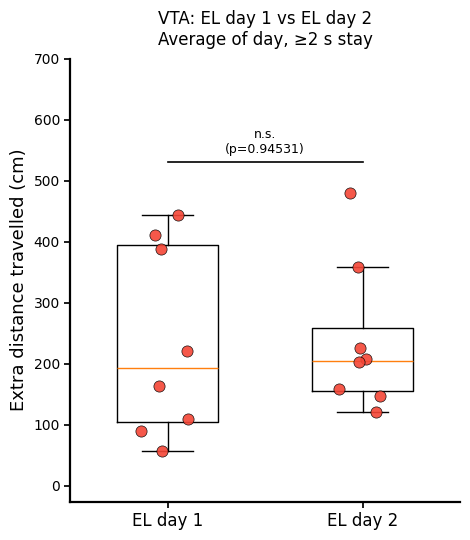


Boxplot: Average of day, EL mode = pooled
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=152.068, EL mean=263.346, L day 5 median=133.853, EL median=254.542, stat=0.000, p=0.00195


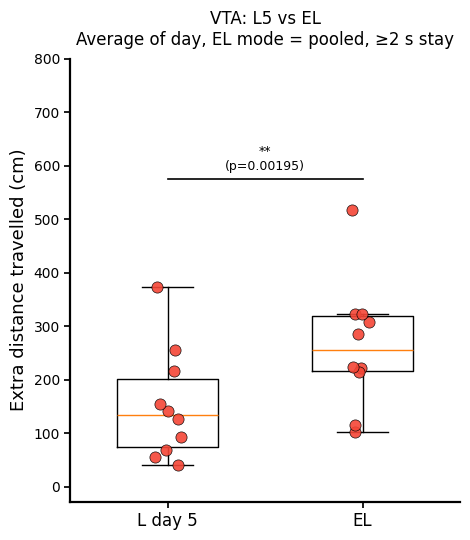


Boxplot: Best trial of day, EL mode = pooled
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=16.141, EL mean=24.653, L day 5 median=4.995, EL median=7.322, stat=19.000, p=0.43164


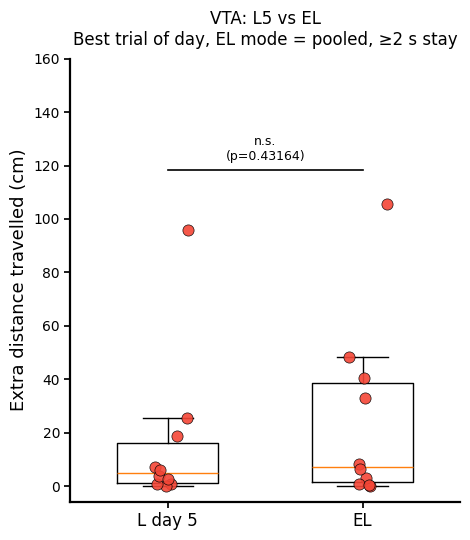


Boxplot: Final trial, trial 8, EL mode = pooled
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=54.720, EL mean=109.197, L day 5 median=29.203, EL median=96.308, stat=10.000, p=0.08398


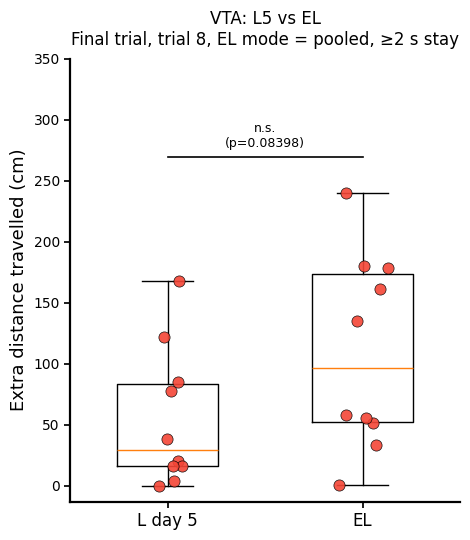


EL trial-by-trial progress plot
Metric: CIPL
Y-axis label: Extra distance travelled (cm)
EL day mode: pooled
SEM style: shaded
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
  Pooled EL day 1+2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


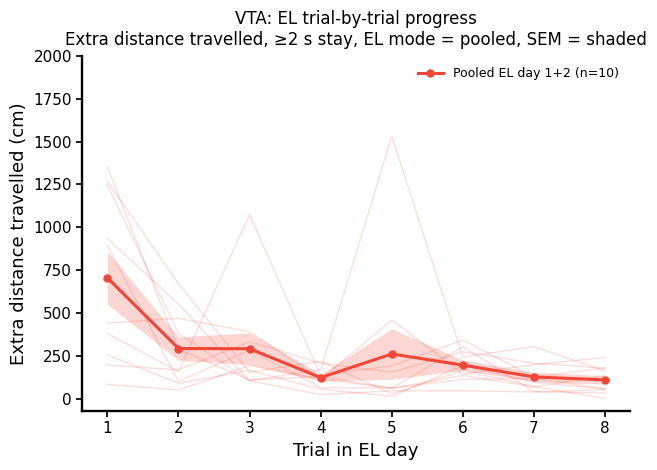


Extra learning EL vs L5
Metric: path_eff
Metric label: Path efficiency (%)
Genotype: ChR2 (VTA)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
EL day mode: pooled
Best-trial direction: max
EL1 vs EL2 metric: avg
Stat test: wilcoxon
EL progress SEM style: shaded
Trial column used: trial_id
Filter short duration: False

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trial_in_day   path_eff
0      1   A     ChR2          L               5    8             1  11.944532
1      1   A     ChR2          L               5    8             2  67.292224
2      1   A     ChR2          L               5    8             3  31.301671
3      1   A     ChR2          L               5    8             4  46.492120
4      1   A     ChR2          L               5    8             5  46.640040
..   ...  ..      ...        ...             ...  ...           ...        ...
240   18  AO     ChR2          L               5   33             4  66.508989
241   18  AO     ChR2   

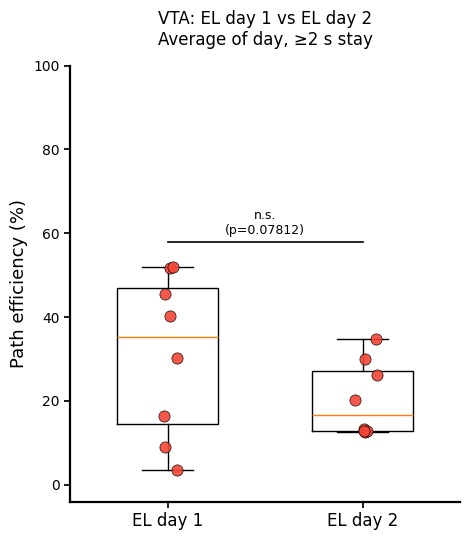


Boxplot: Average of day, EL mode = pooled
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=9, L day 5 mean=34.601, EL mean=22.793, L day 5 median=34.768, EL median=21.530, stat=10.000, p=0.16406


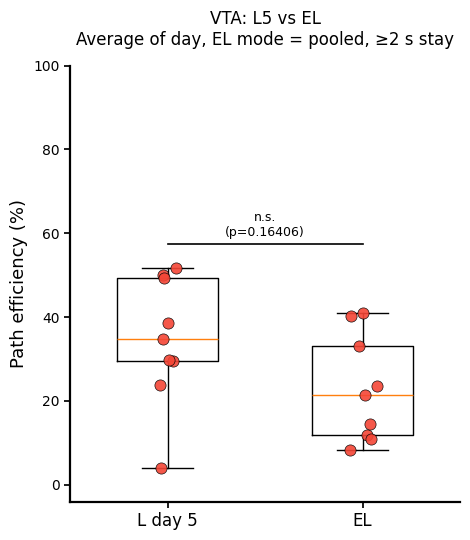


Boxplot: Best trial of day, EL mode = pooled
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=9, L day 5 mean=72.449, EL mean=65.037, L day 5 median=79.877, EL median=65.890, stat=16.000, p=0.49609


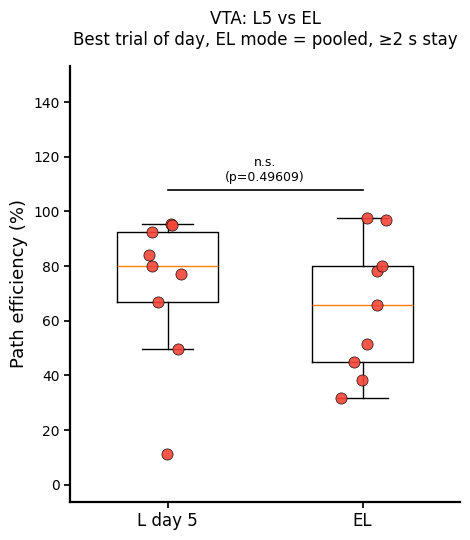


Boxplot: Final trial, trial 8, EL mode = pooled
Metric: path_eff
Y-axis label: Path efficiency (%)
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=9, L day 5 mean=42.325, EL mean=32.997, L day 5 median=34.948, EL median=23.455, stat=18.000, p=0.65234


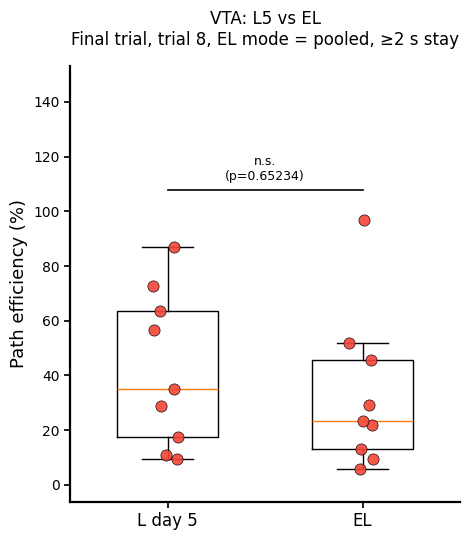


EL trial-by-trial progress plot
Metric: path_eff
Y-axis label: Path efficiency (%)
EL day mode: pooled
SEM style: shaded
Computed using: ≥2 s stay
REQUIRE_STAY_2S: True
  Pooled EL day 1+2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


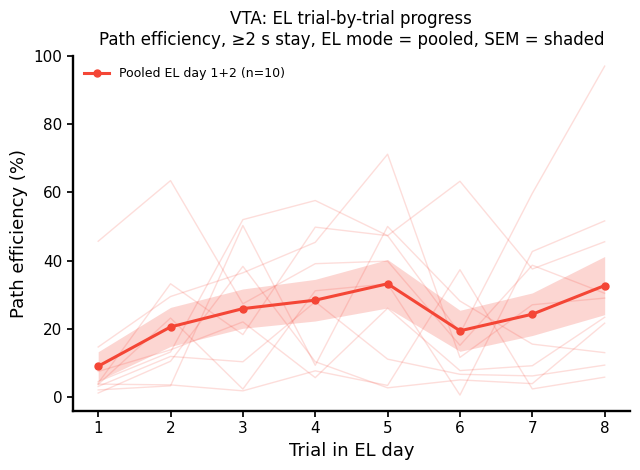

In [456]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu

# ============================================================
# Extra learning EL vs last learning day L5
# Genotype: ChR2
#
# Metrics:
#   1) CIPL
#        = extra distance travelled, already stored in cm
#        = L_actual - L_shortest
#
#   2) path_eff
#        = path efficiency
#        = L_shortest / L_actual * 100
#
# Produces, for each metric:
#   0) Boxplot: EL day 1 vs EL day 2
#   1) Boxplot: average EL day vs average L day 5
#   2) Boxplot: best EL trial vs best L day 5 trial
#        - CIPL: smaller is better, so best = minimum
#        - path_eff: larger is better, so best = maximum
#   3) Boxplot: final EL trial 8 vs final L day 5 trial 8
#   4) EL trial-by-trial progress plot across trials 1-8
#
# IMPORTANT:
#   - CIPL/path_eff are already computed in metadata.
#   - CIPL is already stored in cm by the computing code.
#   - This plotting code does NOT multiply CIPL by 1.2 again.
#   - REQUIRE_STAY_2S must already exist from the computing code.
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

# ------------------------------------------------------------
# Use REQUIRE_STAY_2S directly from computing code
# ------------------------------------------------------------

if 'REQUIRE_STAY_2S' not in globals():
    raise NameError(
        "REQUIRE_STAY_2S is not defined. "
        "Run your CIPL/path_eff computing code first, or define "
        "REQUIRE_STAY_2S before plotting."
    )

STAY_TAG = '≥2 s stay' if REQUIRE_STAY_2S else 'all visits'

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

METRICS_TO_PLOT = [
    'CIPL',
    'path_eff',
]

# CIPL is already stored in cm, so the unit is added here only
# as an axis label; no further conversion is performed.
METRIC_LABEL = {
    'CIPL': 'Extra distance travelled (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'CIPL': 'Extra distance travelled',
    'path_eff': 'Path efficiency',
}

# IMPORTANT:
# CIPL is already stored in cm by the computing code.
# Do not change CIPL to 1.2 here.
METRIC_SCALE = {
    'CIPL': 1.0,
    'path_eff': 1.0,
}

# For best trial:
#   CIPL      -> lower is better
#   path_eff  -> higher is better
BEST_DIRECTION = {
    'CIPL': 'min',
    'path_eff': 'max',
}

# ------------------------------------------------------------
# EL-day selection
# ------------------------------------------------------------
# 'day1'     -> use EL day 1 for EL vs L5 comparisons
# 'day2'     -> use EL day 2 for EL vs L5 comparisons
# 'separate' -> compare EL1 and EL2 separately against L5
# 'pooled'   -> pool EL1 and EL2 within animal for EL vs L5
# ------------------------------------------------------------

EL_DAY_MODE = 'pooled'
# EL_DAY_MODE = 'day1'
# EL_DAY_MODE = 'day2'
# EL_DAY_MODE = 'separate'

FILTER_SHORT_DURATION = False

EXCLUDE_ID = ['BQ', 'BP']
EXCLUDE_SUBS = []

SHOW_ANIMAL_IDS = False
SHOW_PAIRED_LINES = False

FINAL_TRIAL_N = 8

REQUIRE_PAIRED = True

STAT_TEST = 'wilcoxon'
# STAT_TEST = 'mannwhitney'

# EL1 vs EL2 boxplot metric:
#   'avg'   -> average of all 8 trials
#   'best'  -> best trial
#   'final' -> final trial = trial 8
EL1_VS_EL2_METRIC = 'avg'
# EL1_VS_EL2_METRIC = 'best'
# EL1_VS_EL2_METRIC = 'final'

# ------------------------------------------------------------
# EL trial-by-trial progress plot options
# ------------------------------------------------------------

RUN_EL_TRIAL_PROGRESS_PLOT = True
PLOT_EL_INDIVIDUAL_LINES = True

#   'bar'    -> SEM error bars
#   'shaded' -> shaded SEM area
#   'none'   -> mean line only
EL_PROGRESS_SEM_STYLE = 'shaded'
# EL_PROGRESS_SEM_STYLE = 'bar'
# EL_PROGRESS_SEM_STYLE = 'none'

EL_TRIAL_YMIN_BY_METRIC = {
    'CIPL': None,
    'path_eff': 0,
}

EL_TRIAL_YMAX_BY_METRIC = {
    'CIPL': None,
    'path_eff': 100,
}

EL_TRIAL_Y_ZERO_PAD_FRAC = 0.04
EL_TRIAL_Y_TOP_PAD_FRAC = 0.18

# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------

JITTER = 0.06
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5
P_DECIMALS = 5

# ------------------------------------------------------------
# Boxplot y-axis options
# ------------------------------------------------------------

BOX_YMIN_BY_METRIC = {
    'CIPL': None,
    'path_eff': 0,
}

# Leave path_eff as None so that significance annotations are not
# forced into a fixed 0-100 axis and do not collide with the title.
BOX_YMAX_BY_METRIC = {
    'CIPL': None,
    'path_eff': None,
}

BOX_Y_BOTTOM_PAD_FRAC = 0.04

BOX_Y_TICK_STEP_BY_METRIC = {
    'CIPL': None,
    'path_eff': 20,
}

# Minimum visible top for each metric.
# Path-efficiency plots preserve at least a 0-100 display range.
BOX_MINIMUM_TOP_BY_METRIC = {
    'CIPL': None,
    'path_eff': 100,
}

# P-value line position above the highest data point.
P_LINE_START_FRAC = 0.12
P_TEXT_OFFSET_FRAC = 0.025

# Amount of empty space retained above the highest point or annotation.
# Path-efficiency boxplots receive extra headroom to separate the
# p-value annotation from the title.
BOX_TOP_PAD_FRAC_BY_METRIC = {
    'CIPL': 0.22,
    'path_eff': 0.42,
}

# Additional title padding; applied especially to path-efficiency boxplots.
BOX_TITLE_PAD_BY_METRIC = {
    'CIPL': 10,
    'path_eff': 15,
}

BOX_FIGSIZE = (4.8, 5.5)

np.random.seed(1)

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'NAc': 'NAc',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
    'WT': 'WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

if EL_DAY_MODE not in ['separate', 'day1', 'day2', 'pooled']:
    raise ValueError(
        "EL_DAY_MODE must be 'separate', 'day1', 'day2', or 'pooled'"
    )

if STAT_TEST not in ['wilcoxon', 'mannwhitney']:
    raise ValueError(
        "STAT_TEST must be 'wilcoxon' or 'mannwhitney'"
    )

if EL1_VS_EL2_METRIC not in ['avg', 'best', 'final']:
    raise ValueError(
        "EL1_VS_EL2_METRIC must be 'avg', 'best', or 'final'"
    )

if EL_PROGRESS_SEM_STYLE not in ['bar', 'shaded', 'none']:
    raise ValueError(
        "EL_PROGRESS_SEM_STYLE must be 'bar', 'shaded', or 'none'"
    )


# ============================================================
# Helper functions
# ============================================================

def get_plot_color(genotype):
    try:
        return get_genotype_color(genotype)
    except Exception:
        return '0.3'


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.7):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.25)
    ax.grid(False)


def scale_value(value, value_col):
    """
    Apply plotting scale.

    CIPL is already stored in cm, so its scale remains 1.0.
    """
    scale = METRIC_SCALE.get(value_col, 1.0)
    return value * scale


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def add_trial_in_day(meta_df):
    """
    Adds trial_in_day = 1..8.

    Uses an existing trial-number column where available.
    Otherwise infers trial number from order within subject/session.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
        'trial_id',
    ]

    trial_col = next(
        (c for c in candidate_cols if c in meta_df.columns),
        None
    )

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = (
            meta_df.groupby(['sub', 'ses']).cumcount() + 1
        )

    meta_df = meta_df[
        meta_df['trial_in_day'].between(1, 8)
    ].copy()

    return meta_df, trial_col


def trial_summary(ms, value_col):
    """
    Return one animal/day summary.

    Outputs:
      avg   : average across available trials
      best  : best available trial
      final : trial FINAL_TRIAL_N

    Best-value logic:
      CIPL      -> minimum
      path_eff  -> maximum
    """
    if len(ms) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    by_trial = (
        ms.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    vals = by_trial.values.astype(float)
    vals = scale_value(vals, value_col)

    avg_val = float(np.nanmean(vals))

    if BEST_DIRECTION.get(value_col, 'min') == 'max':
        best_val = float(np.nanmax(vals))
    else:
        best_val = float(np.nanmin(vals))

    if FINAL_TRIAL_N in by_trial.index:
        final_val = float(
            scale_value(by_trial.loc[FINAL_TRIAL_N], value_col)
        )
    else:
        final_val = np.nan

    return {
        'avg': avg_val,
        'best': best_val,
        'final': final_val,
    }


def run_stat(a, b):
    """
    Run the selected test.

    Wilcoxon:
      paired comparison; only rows with finite values in both
      conditions are retained.

    Mann–Whitney:
      independent comparison; finite values are retained separately.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if STAT_TEST == 'wilcoxon':
        ok = np.isfinite(a) & np.isfinite(b)

        a_use = a[ok]
        b_use = b[ok]

        if len(a_use) == 0:
            return np.nan, np.nan

        if np.allclose(a_use, b_use, equal_nan=False):
            return np.nan, 1.0

        try:
            stat, p = wilcoxon(
                a_use,
                b_use,
                alternative='two-sided'
            )
        except ValueError:
            stat, p = np.nan, 1.0

        return stat, p

    if STAT_TEST == 'mannwhitney':
        a_use = a[np.isfinite(a)]
        b_use = b[np.isfinite(b)]

        if len(a_use) == 0 or len(b_use) == 0:
            return np.nan, np.nan

        stat, p = mannwhitneyu(
            a_use,
            b_use,
            alternative='two-sided'
        )

        return stat, p

    return np.nan, np.nan


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    mean_val = float(np.nanmean(vals))
    sem_val = float(
        np.nanstd(vals, ddof=1) / np.sqrt(len(vals))
    )

    return mean_val, sem_val


# ============================================================
# Y-axis and significance-bar helpers
# ============================================================

def calculate_box_axis_limits(all_vals, value_col, stat_y=None):
    """
    Calculate boxplot y-axis limits.

    For path_eff:
      - keep a minimum upper limit of 100%
      - add extra vertical space above the p-value annotation
        to prevent the title and p-value text appearing crowded

    For CIPL:
      - use standard compact automatic padding
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = float(np.nanmax(all_vals))

        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    highest_content = data_top

    if stat_y is not None and np.isfinite(stat_y):
        highest_content = max(highest_content, float(stat_y))

    manual_ymax = BOX_YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = BOX_YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        top_pad_frac = BOX_TOP_PAD_FRAC_BY_METRIC.get(value_col, 0.22)
        y_top = highest_content * (1 + top_pad_frac)

        minimum_top = BOX_MINIMUM_TOP_BY_METRIC.get(value_col, None)

        if minimum_top is not None:
            y_top = max(y_top, float(minimum_top))

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top

    return y_bottom, y_top


def apply_box_y_axis(ax, all_vals, value_col, stat_y=None):
    """
    Apply boxplot y-axis with metric-specific title/p-value headroom.
    """
    y_bottom, y_top = calculate_box_axis_limits(
        all_vals=all_vals,
        value_col=value_col,
        stat_y=stat_y
    )

    ax.set_ylim(y_bottom, y_top)

    tick_step = BOX_Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if tick_step is not None:
        yticks = np.arange(0, y_top + 1e-9, tick_step)

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)

    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def add_sig_bar(ax, positions, p, all_vals, value_col):
    """
    Draw significance annotation and set y-axis limits.

    Returns
    -------
    stat_y : float or None
        Y-position of the significance bar.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        apply_box_y_axis(
            ax=ax,
            all_vals=all_vals,
            value_col=value_col,
            stat_y=None
        )
        return None

    ymax = float(np.nanmax(all_vals))
    ymin = float(np.nanmin(all_vals))
    yrng = ymax - ymin

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(ymax), 1.0)

    stat_y = ymax + P_LINE_START_FRAC * yrng

    ax.plot(
        [positions[0], positions[1]],
        [stat_y, stat_y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        np.mean(positions),
        stat_y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    apply_box_y_axis(
        ax=ax,
        all_vals=all_vals,
        value_col=value_col,
        stat_y=stat_y
    )

    return stat_y


def apply_el_progress_y_axis(ax, all_vals, value_col):
    """
    Apply y-axis to EL trial-by-trial progress plots.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top = 1.0
    else:
        y_top = float(np.nanmax(all_vals))

        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    manual_ymax = EL_TRIAL_YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = EL_TRIAL_YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = y_top * (1 + EL_TRIAL_Y_TOP_PAD_FRAC)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -EL_TRIAL_Y_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -EL_TRIAL_Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    yticks = ax.get_yticks()
    yticks = yticks[yticks >= 0]

    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)


# ============================================================
# Main function for one metric
# ============================================================

def run_extra_learning_plots_for_metric(VALUE_COL):

    VALUE_LABEL = METRIC_LABEL.get(VALUE_COL, VALUE_COL)
    VALUE_TITLE = METRIC_TITLE.get(VALUE_COL, VALUE_COL)

    # --------------------------------------------------------
    # 1. Filter metadata
    # --------------------------------------------------------

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        VALUE_COL,
    ]

    if FILTER_SHORT_DURATION:
        needed_cols.append('short_duration')

    missing_cols = [
        c for c in needed_cols
        if c not in metadata.columns
    ]

    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in metadata for {VALUE_COL}: {missing_cols}"
        )

    meta = metadata[
        (metadata['usable'] == 1) &
        (metadata['genotype'] == GENOTYPE_TO_PLOT) &
        (metadata['trial_type'].isin(['L', 'EL'])) &
        (metadata[VALUE_COL].notna()) &
        (np.isfinite(metadata[VALUE_COL]))
    ].copy()

    if FILTER_SHORT_DURATION:
        meta = meta[
            meta['short_duration'] != 1
        ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
        meta = meta[
            ~meta['id'].astype(str).isin(
                [str(x) for x in EXCLUDE_ID]
            )
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta = meta[
            ~meta['sub'].astype(str).isin(
                [str(x) for x in EXCLUDE_SUBS]
            )
        ].copy()

    # Keep L5 only.
    meta_L5 = meta[
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 5)
    ].copy()

    # Keep EL1/EL2 for EL vs L5 analysis.
    meta_EL = meta[
        (meta['trial_type'] == 'EL') &
        (meta['trial_type_day'].isin([1, 2]))
    ].copy()

    if EL_DAY_MODE == 'day1':
        meta_EL = meta_EL[
            meta_EL['trial_type_day'] == 1
        ].copy()

    elif EL_DAY_MODE == 'day2':
        meta_EL = meta_EL[
            meta_EL['trial_type_day'] == 2
        ].copy()

    meta_L5, trial_col_L5 = add_trial_in_day(meta_L5)
    meta_EL, trial_col_EL = add_trial_in_day(meta_EL)

    # Keep both EL days for EL1-vs-EL2 and progress plots,
    # independently of the EL_DAY_MODE comparison selection.
    meta_EL_all = meta[
        (meta['trial_type'] == 'EL') &
        (meta['trial_type_day'].isin([1, 2]))
    ].copy()

    meta_EL_all, trial_col_EL_all = add_trial_in_day(meta_EL_all)

    trial_col_used = (
        trial_col_EL
        if trial_col_EL is not None
        else trial_col_L5
    )

    print("\n============================================================")
    print("Extra learning EL vs L5")
    print("Metric:", VALUE_COL)
    print("Metric label:", VALUE_LABEL)
    print("Genotype:", GENOTYPE_TO_PLOT, f"({GROUP_LABEL})")
    print("Computed using:", STAY_TAG)
    print("REQUIRE_STAY_2S:", REQUIRE_STAY_2S)
    print("EL day mode:", EL_DAY_MODE)
    print("Best-trial direction:", BEST_DIRECTION.get(VALUE_COL, 'min'))
    print("EL1 vs EL2 metric:", EL1_VS_EL2_METRIC)
    print("Stat test:", STAT_TEST)
    print("EL progress SEM style:", EL_PROGRESS_SEM_STYLE)
    print(
        "Trial column used:",
        trial_col_used
        if trial_col_used is not None
        else "inferred from sub/ses order"
    )
    print("Filter short duration:", FILTER_SHORT_DURATION)

    if VALUE_COL == 'CIPL':
        print("CIPL plotting unit: cm; no additional conversion applied.")

    print("\nRows after filtering:")

    cols_to_print = ['sub']

    if 'id' in meta.columns:
        cols_to_print.append('id')

    cols_to_print += [
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'trial_in_day',
        VALUE_COL,
    ]

    rows_to_print = pd.concat(
        [meta_L5, meta_EL],
        ignore_index=True
    )

    if len(rows_to_print) > 0:
        print(
            rows_to_print[cols_to_print]
            .drop_duplicates()
            .sort_values(cols_to_print)
            .reset_index(drop=True)
        )
    else:
        print("No rows left after filtering.")

    # ========================================================
    # 2. Build paired comparison dataframe: L5 vs EL
    # ========================================================

    rows = []

    common_subs = sorted(
        set(meta_L5['sub'].unique()).intersection(
            set(meta_EL['sub'].unique())
        )
    )

    for sub in common_subs:

        ms_L5 = meta_L5[
            meta_L5['sub'] == sub
        ].copy()

        if len(ms_L5) == 0:
            continue

        animal_id = get_animal_label(ms_L5, sub)
        l5_summary = trial_summary(ms_L5, VALUE_COL)

        ms_EL_sub = meta_EL[
            meta_EL['sub'] == sub
        ].copy()

        if EL_DAY_MODE in ['separate', 'day1', 'day2']:

            for el_day in sorted(
                ms_EL_sub['trial_type_day'].dropna().unique()
            ):

                ms_EL_day = ms_EL_sub[
                    ms_EL_sub['trial_type_day'] == el_day
                ].copy()

                if len(ms_EL_day) == 0:
                    continue

                el_summary = trial_summary(
                    ms_EL_day,
                    VALUE_COL
                )

                rows.append({
                    'sub': sub,
                    'id': animal_id,
                    'el_day': int(el_day),
                    'obs_label': f'{animal_id} EL{int(el_day)}',
                    'L5_avg': l5_summary['avg'],
                    'EL_avg': el_summary['avg'],
                    'L5_best': l5_summary['best'],
                    'EL_best': el_summary['best'],
                    'L5_final': l5_summary['final'],
                    'EL_final': el_summary['final'],
                })

        elif EL_DAY_MODE == 'pooled':

            el_day_summaries = []

            for el_day in sorted(
                ms_EL_sub['trial_type_day'].dropna().unique()
            ):

                ms_EL_day = ms_EL_sub[
                    ms_EL_sub['trial_type_day'] == el_day
                ].copy()

                el_summary = trial_summary(
                    ms_EL_day,
                    VALUE_COL
                )

                el_day_summaries.append(el_summary)

            if len(el_day_summaries) == 0:
                continue

            best_values = np.array(
                [d['best'] for d in el_day_summaries],
                dtype=float
            )

            if BEST_DIRECTION.get(VALUE_COL, 'min') == 'max':
                pooled_best = np.nanmax(best_values)
            else:
                pooled_best = np.nanmin(best_values)

            el_summary_pooled = {
                'avg': np.nanmean(
                    [d['avg'] for d in el_day_summaries]
                ),
                'best': pooled_best,
                'final': np.nanmean(
                    [d['final'] for d in el_day_summaries]
                ),
            }

            rows.append({
                'sub': sub,
                'id': animal_id,
                'el_day': 'pooled',
                'obs_label': f'{animal_id} pooled EL',
                'L5_avg': l5_summary['avg'],
                'EL_avg': el_summary_pooled['avg'],
                'L5_best': l5_summary['best'],
                'EL_best': el_summary_pooled['best'],
                'L5_final': l5_summary['final'],
                'EL_final': el_summary_pooled['final'],
            })

    compare_df = pd.DataFrame(rows)

    if REQUIRE_PAIRED and len(compare_df) > 0:

        metric_pairs = [
            ('L5_avg', 'EL_avg'),
            ('L5_best', 'EL_best'),
            ('L5_final', 'EL_final'),
        ]

        keep = np.ones(len(compare_df), dtype=bool)

        for l5_col, el_col in metric_pairs:
            keep = (
                keep &
                compare_df[l5_col].notna().values &
                compare_df[el_col].notna().values
            )

        compare_df = compare_df[keep].copy()

    print("\nComparison table:")

    if len(compare_df) > 0:
        print(
            compare_df[
                [
                    'sub',
                    'id',
                    'el_day',
                    'obs_label',
                    'L5_avg',
                    'EL_avg',
                    'L5_best',
                    'EL_best',
                    'L5_final',
                    'EL_final',
                ]
            ].reset_index(drop=True)
        )
    else:
        print("No paired L5/EL observations available.")

    # ========================================================
    # 2b. Build paired dataframe: EL day 1 vs EL day 2
    # ========================================================

    el12_rows = []

    for sub in sorted(meta_EL_all['sub'].unique()):

        ms_sub = meta_EL_all[
            meta_EL_all['sub'] == sub
        ].copy()

        ms_el1 = ms_sub[
            ms_sub['trial_type_day'] == 1
        ].copy()

        ms_el2 = ms_sub[
            ms_sub['trial_type_day'] == 2
        ].copy()

        if len(ms_el1) == 0 or len(ms_el2) == 0:
            continue

        animal_id = get_animal_label(ms_sub, sub)

        el1_summary = trial_summary(ms_el1, VALUE_COL)
        el2_summary = trial_summary(ms_el2, VALUE_COL)

        el12_rows.append({
            'sub': sub,
            'id': animal_id,
            'EL1_avg': el1_summary['avg'],
            'EL2_avg': el2_summary['avg'],
            'EL1_best': el1_summary['best'],
            'EL2_best': el2_summary['best'],
            'EL1_final': el1_summary['final'],
            'EL2_final': el2_summary['final'],
        })

    el12_df = pd.DataFrame(el12_rows)

    print("\nEL day 1 vs EL day 2 table:")

    if len(el12_df) > 0:
        print(
            el12_df[
                [
                    'sub',
                    'id',
                    'EL1_avg',
                    'EL2_avg',
                    'EL1_best',
                    'EL2_best',
                    'EL1_final',
                    'EL2_final',
                ]
            ].reset_index(drop=True)
        )
    else:
        print("No animals with both EL day 1 and EL day 2.")

    # ========================================================
    # 3. Boxplot helpers
    # ========================================================

    def plot_two_condition_boxplot(
        plot_df,
        left_col,
        right_col,
        left_label,
        right_label,
        title_main,
        title_suffix,
        obs_label_col='obs_label'
    ):
        """
        Plot one paired/two-condition boxplot.

        For path_eff, the y-axis includes additional upper headroom so
        the p-value annotation is clearly separated from the title.
        """
        if len(plot_df) == 0:
            print(f"\nSkipping {title_suffix}: no data.")
            return

        plot_df = plot_df[
            plot_df[left_col].notna() &
            plot_df[right_col].notna() &
            np.isfinite(plot_df[left_col]) &
            np.isfinite(plot_df[right_col])
        ].copy()

        if len(plot_df) == 0:
            print(f"\nSkipping {title_suffix}: no finite paired values.")
            return

        left_vals = plot_df[left_col].values.astype(float)
        right_vals = plot_df[right_col].values.astype(float)

        vals_groups = [left_vals, right_vals]
        positions = np.arange(2)

        stat, p = run_stat(left_vals, right_vals)

        if obs_label_col in plot_df.columns:
            obs_labels = list(plot_df[obs_label_col])
        else:
            obs_labels = list(plot_df['id'])

        print("\n============================================================")
        print(f"Boxplot: {title_suffix}")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("Computed using:", STAY_TAG)
        print("REQUIRE_STAY_2S:", REQUIRE_STAY_2S)
        print("Animals/observations included:")
        print(obs_labels)

        print(
            f"{STAT_TEST}: "
            f"n={len(left_vals)}, "
            f"{left_label} mean={np.nanmean(left_vals):.3f}, "
            f"{right_label} mean={np.nanmean(right_vals):.3f}, "
            f"{left_label} median={np.nanmedian(left_vals):.3f}, "
            f"{right_label} median={np.nanmedian(right_vals):.3f}, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        fig, ax = plt.subplots(figsize=BOX_FIGSIZE)

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        col = get_plot_color(GENOTYPE_TO_PLOT)

        if SHOW_PAIRED_LINES:
            for left_y, right_y in zip(left_vals, right_vals):
                ax.plot(
                    positions,
                    [left_y, right_y],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(vals_groups):

            x = np.random.normal(
                positions[i],
                JITTER,
                size=len(vals)
            )

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(
                    x,
                    vals,
                    obs_labels
                ):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[left_vals, right_vals]

        add_sig_bar(
            ax=ax,
            positions=positions,
            p=p,
            all_vals=all_vals,
            value_col=VALUE_COL
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            [left_label, right_label],
            fontsize=12
        )

        ax.set_ylabel(
            VALUE_LABEL,
            fontsize=13
        )

        title_pad = BOX_TITLE_PAD_BY_METRIC.get(
            VALUE_COL,
            10
        )

        ax.set_title(
            f'{title_main}\n'
            f'{title_suffix}, {STAY_TAG}',
            fontsize=12,
            pad=title_pad
        )

        style_nature(ax, linewidth=1.6)

        plt.tight_layout()
        plt.show()


    def plot_l5_vs_el_boxplot(l5_col, el_col, title_suffix):
        plot_two_condition_boxplot(
            plot_df=compare_df,
            left_col=l5_col,
            right_col=el_col,
            left_label='L day 5',
            right_label='EL',
            title_main=f'{GROUP_LABEL}: L5 vs EL',
            title_suffix=f'{title_suffix}, EL mode = {EL_DAY_MODE}',
            obs_label_col='obs_label'
        )


    def plot_el1_vs_el2_boxplot():

        metric_to_cols = {
            'avg': (
                'EL1_avg',
                'EL2_avg',
                'Average of day'
            ),
            'best': (
                'EL1_best',
                'EL2_best',
                'Best trial of day'
            ),
            'final': (
                'EL1_final',
                'EL2_final',
                f'Final trial, trial {FINAL_TRIAL_N}'
            ),
        }

        left_col, right_col, metric_title = metric_to_cols[
            EL1_VS_EL2_METRIC
        ]

        plot_two_condition_boxplot(
            plot_df=el12_df,
            left_col=left_col,
            right_col=right_col,
            left_label='EL day 1',
            right_label='EL day 2',
            title_main=f'{GROUP_LABEL}: EL day 1 vs EL day 2',
            title_suffix=metric_title,
            obs_label_col='id'
        )

    # ========================================================
    # 4. Produce boxplots
    # ========================================================

    plot_el1_vs_el2_boxplot()

    plot_l5_vs_el_boxplot(
        l5_col='L5_avg',
        el_col='EL_avg',
        title_suffix='Average of day'
    )

    plot_l5_vs_el_boxplot(
        l5_col='L5_best',
        el_col='EL_best',
        title_suffix='Best trial of day'
    )

    plot_l5_vs_el_boxplot(
        l5_col='L5_final',
        el_col='EL_final',
        title_suffix=f'Final trial, trial {FINAL_TRIAL_N}'
    )

    # ========================================================
    # 5. EL trial-by-trial progress plot
    # ========================================================

    def build_el_trial_matrix(meta_el, mode):
        """
        Return matrices for EL trial-by-trial plotting.

        Each matrix is animal × trial_in_day.

        mode:
          'day1'     -> EL day 1 only
          'day2'     -> EL day 2 only
          'separate' -> EL day 1 and EL day 2 shown separately
          'pooled'   -> EL day 1 and EL day 2 averaged per animal/trial
        """
        trials = np.arange(1, 9)
        matrices = {}

        if len(meta_el) == 0:
            return matrices

        if mode == 'day1':
            days_to_plot = [1]

        elif mode == 'day2':
            days_to_plot = [2]

        elif mode == 'separate':
            days_to_plot = [1, 2]

        elif mode == 'pooled':
            days_to_plot = ['pooled']

        else:
            raise ValueError(
                "mode must be 'day1', 'day2', 'separate', or 'pooled'"
            )

        if mode in ['day1', 'day2', 'separate']:

            for el_day in days_to_plot:

                md = meta_el[
                    meta_el['trial_type_day'] == el_day
                ].copy()

                if len(md) == 0:
                    continue

                rows = []
                ids = []

                for sub in sorted(md['sub'].unique()):

                    ms = md[
                        md['sub'] == sub
                    ].copy()

                    by_trial = (
                        ms.groupby(
                            'trial_in_day',
                            as_index=True
                        )[VALUE_COL]
                        .mean()
                        .sort_index()
                    )

                    vals = np.array(
                        [
                            scale_value(
                                by_trial.get(t, np.nan),
                                VALUE_COL
                            )
                            for t in trials
                        ],
                        dtype=float
                    )

                    if np.all(np.isnan(vals)):
                        continue

                    rows.append(vals)
                    ids.append(get_animal_label(ms, sub))

                if len(rows) > 0:
                    label = f'EL day {el_day}'

                    matrices[label] = {
                        'mat': np.vstack(rows),
                        'ids': ids,
                    }

        elif mode == 'pooled':

            rows = []
            ids = []

            for sub in sorted(meta_el['sub'].unique()):

                ms = meta_el[
                    meta_el['sub'] == sub
                ].copy()

                by_trial = (
                    ms.groupby(
                        'trial_in_day',
                        as_index=True
                    )[VALUE_COL]
                    .mean()
                    .sort_index()
                )

                vals = np.array(
                    [
                        scale_value(
                            by_trial.get(t, np.nan),
                            VALUE_COL
                        )
                        for t in trials
                    ],
                    dtype=float
                )

                if np.all(np.isnan(vals)):
                    continue

                rows.append(vals)
                ids.append(get_animal_label(ms, sub))

            if len(rows) > 0:
                matrices['Pooled EL day 1+2'] = {
                    'mat': np.vstack(rows),
                    'ids': ids,
                }

        return matrices


    def plot_el_trial_progress():

        if not RUN_EL_TRIAL_PROGRESS_PLOT:
            return

        trials = np.arange(1, 9)

        if EL_DAY_MODE in ['day1', 'day2']:
            progress_meta = meta_EL.copy()
        else:
            progress_meta = meta_EL_all.copy()

        matrices = build_el_trial_matrix(
            progress_meta,
            EL_DAY_MODE
        )

        print("\n============================================================")
        print("EL trial-by-trial progress plot")
        print("Metric:", VALUE_COL)
        print("Y-axis label:", VALUE_LABEL)
        print("EL day mode:", EL_DAY_MODE)
        print("SEM style:", EL_PROGRESS_SEM_STYLE)
        print("Computed using:", STAY_TAG)
        print("REQUIRE_STAY_2S:", REQUIRE_STAY_2S)

        if len(matrices) == 0:
            print("No EL trial-by-trial data available.")
            return

        for label, item in matrices.items():
            print(
                f"  {label}: "
                f"n = {item['mat'].shape[0]}, "
                f"ids = {item['ids']}"
            )

        fig, ax = plt.subplots(figsize=(6.5, 4.8))

        base_col = get_plot_color(GENOTYPE_TO_PLOT)

        plot_cols = {
            'EL day 1': base_col,
            'EL day 2': '0.45',
            'Pooled EL day 1+2': base_col,
        }

        all_y = []

        for label, item in matrices.items():

            mat = item['mat']
            col = plot_cols.get(label, base_col)

            if PLOT_EL_INDIVIDUAL_LINES:
                for row in mat:
                    ax.plot(
                        trials,
                        row,
                        '-',
                        color=col,
                        alpha=0.18,
                        linewidth=1.0,
                        zorder=1
                    )

            mean_ = np.full(len(trials), np.nan)
            sem_ = np.full(len(trials), np.nan)

            for i in range(len(trials)):
                mean_val, sem_val = mean_sem(mat[:, i])
                mean_[i] = mean_val
                sem_[i] = sem_val

            all_y.extend(
                list(mat[np.isfinite(mat)].ravel())
            )

            if EL_PROGRESS_SEM_STYLE == 'shaded':
                ax.fill_between(
                    trials,
                    mean_ - sem_,
                    mean_ + sem_,
                    color=col,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                trials,
                mean_,
                'o-',
                color=col,
                linewidth=2.2,
                markersize=5,
                label=f'{label} (n={mat.shape[0]})',
                zorder=3
            )

            if EL_PROGRESS_SEM_STYLE == 'bar':
                ax.errorbar(
                    trials,
                    mean_,
                    yerr=sem_,
                    fmt='none',
                    ecolor=col,
                    alpha=0.55,
                    elinewidth=1.2,
                    capsize=3,
                    zorder=4
                )

        ax.set_xlabel(
            'Trial in EL day',
            fontsize=13
        )

        ax.set_ylabel(
            VALUE_LABEL,
            fontsize=13
        )

        ax.set_xticks(trials)
        ax.set_xticklabels(
            [str(t) for t in trials],
            fontsize=11
        )

        ax.tick_params(
            axis='y',
            labelsize=11
        )

        ax.set_title(
            f'{GROUP_LABEL}: EL trial-by-trial progress\n'
            f'{VALUE_TITLE}, {STAY_TAG}, '
            f'EL mode = {EL_DAY_MODE}, '
            f'SEM = {EL_PROGRESS_SEM_STYLE}',
            fontsize=12,
            pad=8
        )

        style_nature(ax, linewidth=1.7)

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=9
            )

        apply_el_progress_y_axis(
            ax=ax,
            all_vals=all_y,
            value_col=VALUE_COL
        )

        plt.tight_layout()
        plt.show()

    plot_el_trial_progress()


# ============================================================
# Run all selected metrics
# ============================================================

for metric in METRICS_TO_PLOT:
    run_extra_learning_plots_for_metric(metric)

# new learning



############################################################
RUNNING: CIPL_trig
Computed using: ≥2 s stay
Using separate per-trigger values from meta_cipl
############################################################

Filtered RL/Test rows:
     sub  id genotype trial_type  trial_type_day  ses  plot_day  trial_in_day  \
0      8  AD     ChR2         RL               1   21       1.0             1   
1      8  AD     ChR2         RL               1   21       1.0             1   
2      8  AD     ChR2         RL               1   21       1.0             1   
3      8  AD     ChR2         RL               1   21       1.0             2   
4      8  AD     ChR2         RL               1   21       1.0             2   
..   ...  ..      ...        ...             ...  ...       ...           ...   
976   18  AO     ChR2         RL               5   47       5.0             8   
977   18  AO     ChR2         RL               5   47       5.0             8   
978   18  AO     ChR2        

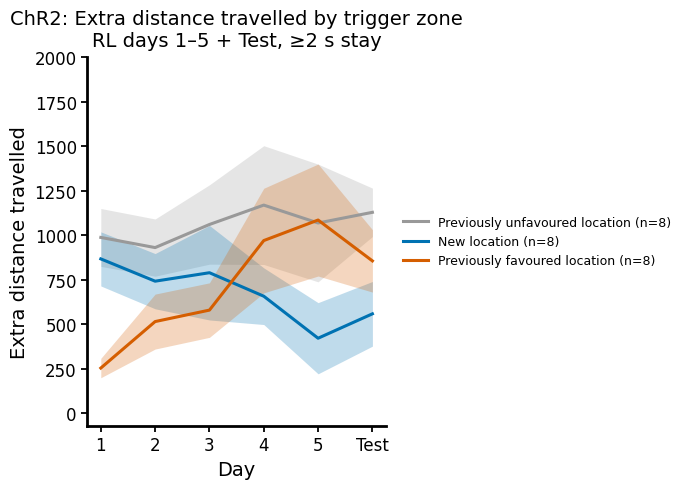


Boxplot: Extra distance travelled, plot_day 1
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 574.5255  480.6637  620.0114 1630.331  1463.6348 1459.384   774.0156
  899.5096]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 530.5982  487.0176  560.8878 1316.2371 1476.3225 1297.9484  826.0416
  443.1579]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[321.8523 132.8056 159.4882 236.956  176.9369 594.7646 132.9614 279.9987]

Paired Wilcoxon tests, plot_day 1:
  Previously unfavoured location vs New location: paired n=8, mean=987.759 vs 867.276, median=836.763 vs 693.465, W=7.000, p=0.14844
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=987.759 vs 254.470, median=836.763 vs 206.946, W=0.000, p=0.00781
  New location vs 

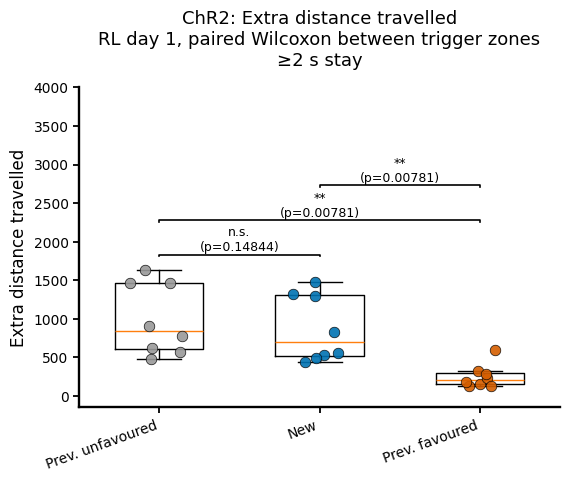


Boxplot: Extra distance travelled, plot_day 2
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 356.8816  538.3336  600.4231 1254.4255 1699.9305 1234.0672  710.8081
 1051.0031]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 421.3045  518.9687  608.1336  817.4371 1723.7775  896.3681  615.4663
  335.6572]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 260.0413  151.0474  294.5618 1282.7302  320.7185 1084.0996  151.9929
  578.3748]

Paired Wilcoxon tests, plot_day 2:
  Previously unfavoured location vs New location: paired n=8, mean=930.734 vs 742.139, median=880.906 vs 611.800, W=8.000, p=0.19531
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=930.734 vs 515.446, median=880.906 vs 307.640, W=1.000, p=0.01562
  New loc

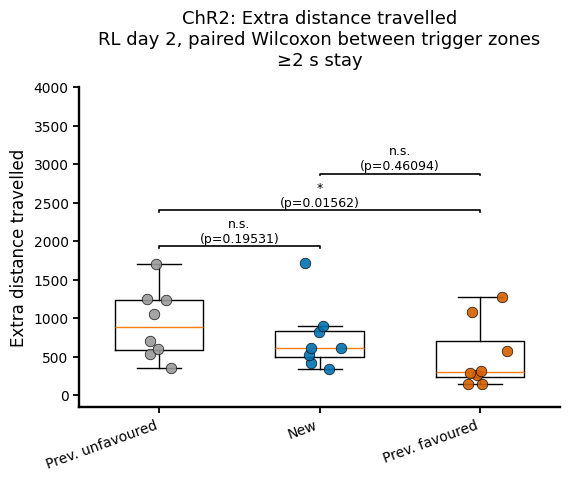


Boxplot: Extra distance travelled, plot_day 3
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 317.6966  559.853   793.6252 1863.3572 1964.0685 1530.3892  747.1015
  707.368 ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 318.9637  572.6659  281.1443  526.3169 2257.4414 1618.4452  647.173
   95.2529]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 206.0679  380.8748  277.4295  602.2686  978.7089 1407.2053  141.5624
  644.3228]

Paired Wilcoxon tests, plot_day 3:
  Previously unfavoured location vs New location: paired n=8, mean=1060.432 vs 789.675, median=770.363 vs 549.491, W=11.000, p=0.38281
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1060.432 vs 579.805, median=770.363 vs 491.572, W=0.000, p=0.00781
  New l

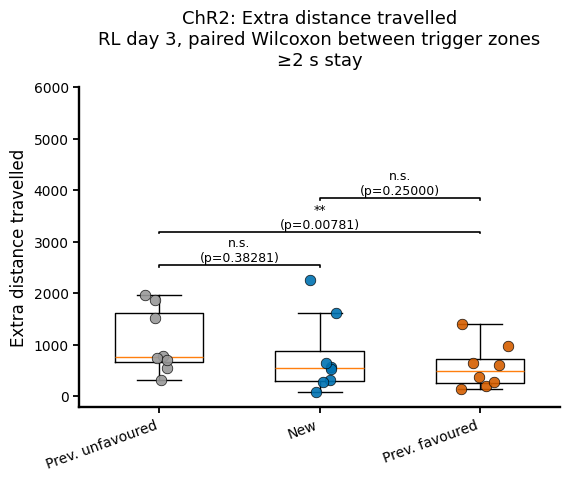


Boxplot: Extra distance travelled, plot_day 4
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 692.3572  680.0888  390.8589 1466.2506 3135.8888  279.2192  944.8544
 1764.7876]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 613.1536  880.5289  310.2278  152.8384 1392.9882 1179.0756  307.2793
  426.7807]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 256.0623  659.6075  278.1926 1159.7603 2626.0819  966.7876  216.2849
 1598.3473]

Paired Wilcoxon tests, plot_day 4:
  Previously unfavoured location vs New location: paired n=8, mean=1169.288 vs 657.859, median=818.606 vs 519.967, W=8.000, p=0.19531
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1169.288 vs 970.141, median=818.606 vs 813.198, W=7.000, p=0.14844
  New l

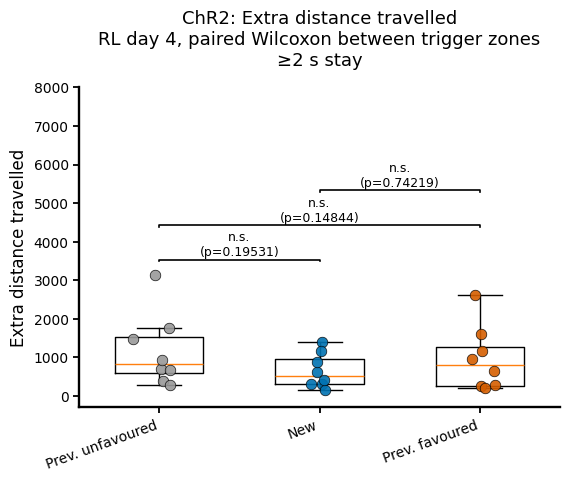


Boxplot: Extra distance travelled, plot_day 5
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 691.2584 1081.3419  281.2703 1573.43   3070.3995  183.4676  522.6874
 1146.8532]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 349.2985  175.8163  134.405    99.8434  620.7345 1749.884   140.1291
  105.4082]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 340.1275  834.5748  122.1326 1472.3471 2797.1153 1629.7501  309.1414
 1178.3085]

Paired Wilcoxon tests, plot_day 5:
  Previously unfavoured location vs New location: paired n=8, mean=1068.839 vs 421.940, median=886.300 vs 157.973, W=7.000, p=0.14844
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1068.839 vs 1085.437, median=886.300 vs 1006.442, W=9.000, p=0.25000
  New

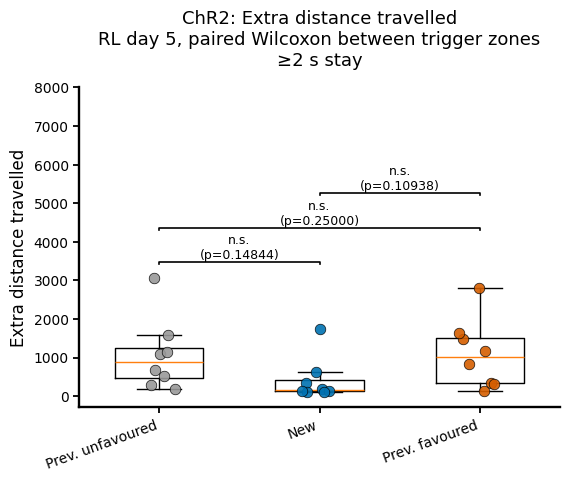


Boxplot: Extra distance travelled, plot_day 6
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 571.5575 1261.106   514.0314 1233.242  1605.739  1371.4394 1176.604
 1296.0742]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 225.9919  351.0666  393.0545  289.023   946.6838 1689.9206  371.4582
  204.1239]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[   0.      897.5254  481.5012  908.0477  787.4392 1676.0995  837.3514
 1260.4668]

Paired Wilcoxon tests, plot_day 6:
  Previously unfavoured location vs New location: paired n=8, mean=1128.724 vs 558.915, median=1247.174 vs 361.262, W=2.000, p=0.02344
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=1128.724 vs 856.054, median=1247.174 vs 867.438, W=3.000, p=0.03906
  New 

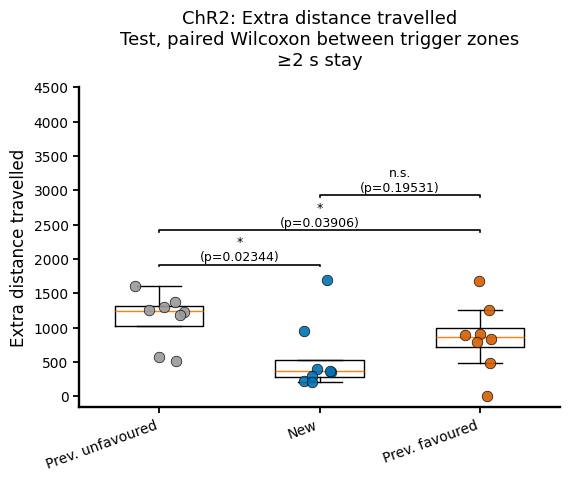


Trial-by-trial plot: Extra distance travelled
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl

Animals included per trigger zone, trial-by-trial:
  Previously unfavoured location: 8 animals
  New location: 8 animals
  Previously favoured location: 8 animals
Total unique animals included, any zone: 8
Animal subs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
Animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


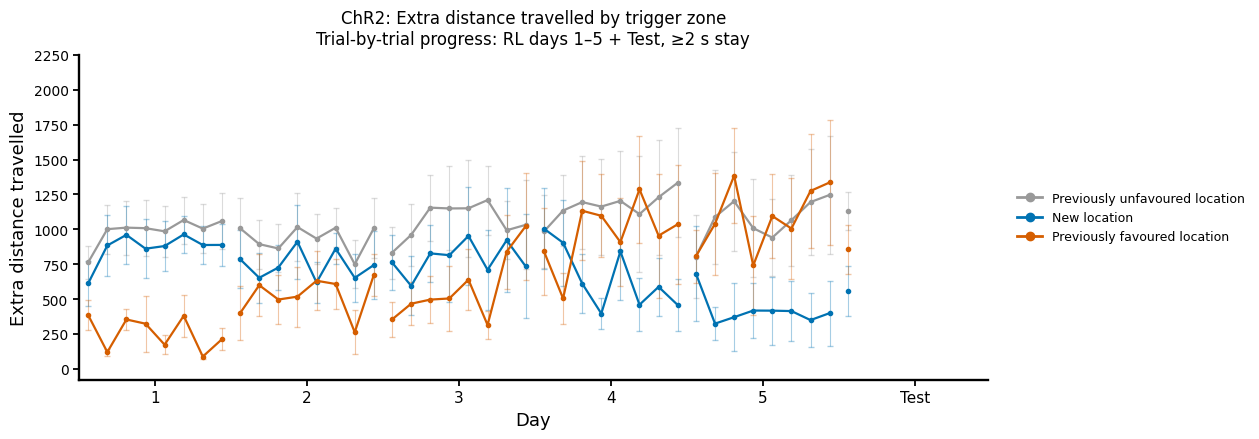


RL day 1 average vs RL day 5 average: Extra distance travelled
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=17.000, p=0.94531, Day1 mean=987.759, Day5 mean=1068.839


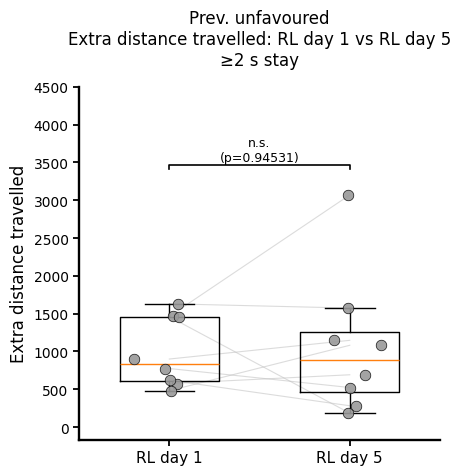


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=5.000, p=0.07812, Day1 mean=867.276, Day5 mean=421.940


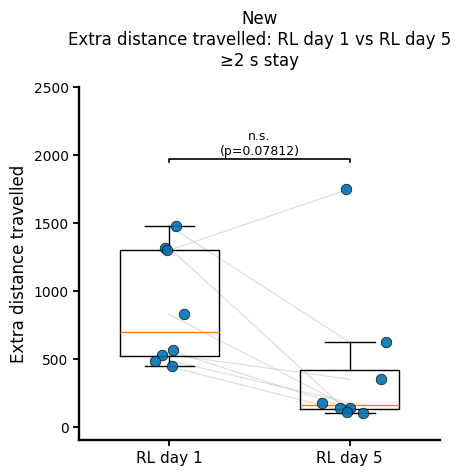


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=2.000, p=0.02344, Day1 mean=254.470, Day5 mean=1085.437


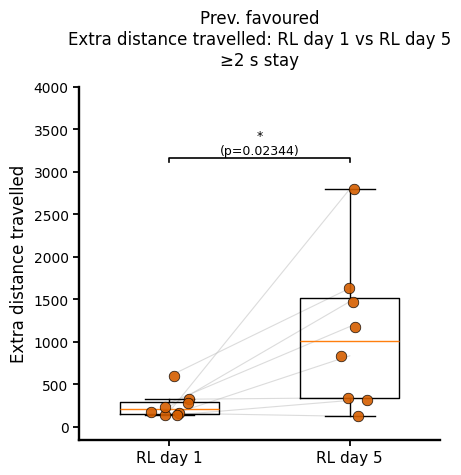


RL day 1 trial 1 vs Test-day average: Extra distance travelled
Using column: CIPL_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.00781, Day1 trial1 mean=763.510, Test mean=1128.724


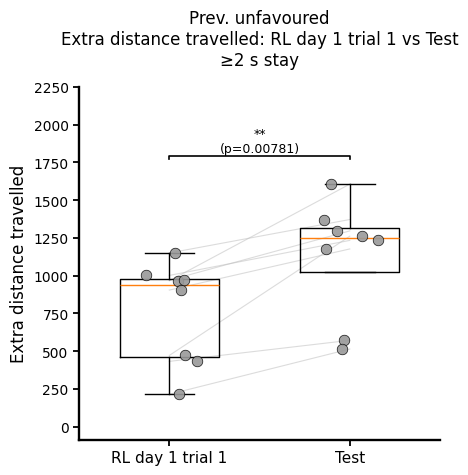


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=18.000, p=1.00000, Day1 trial1 mean=613.176, Test mean=558.915


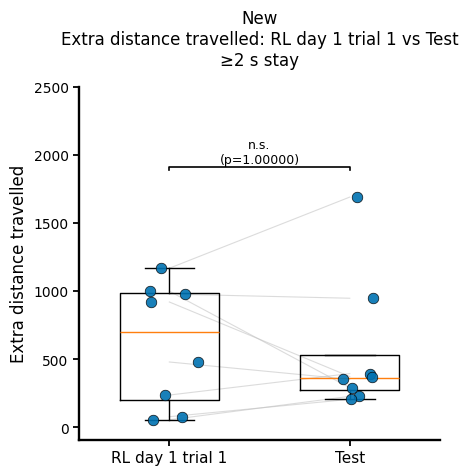


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=5.000, p=0.07812, Day1 trial1 mean=384.499, Test mean=856.054


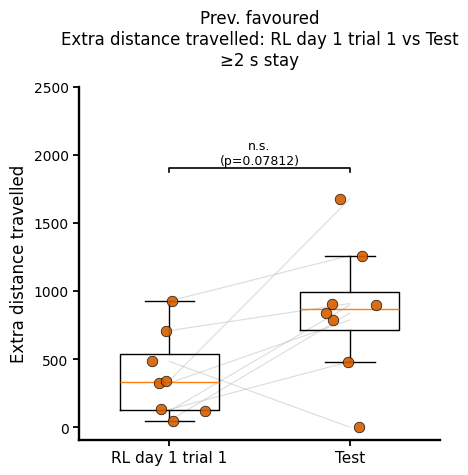



############################################################
RUNNING: path_eff_trig
Computed using: ≥2 s stay
Using separate per-trigger values from meta_cipl
############################################################

Filtered RL/Test rows:
     sub  id genotype trial_type  trial_type_day  ses  plot_day  trial_in_day  \
0      8  AD     ChR2         RL               1   21       1.0             1   
1      8  AD     ChR2         RL               1   21       1.0             1   
2      8  AD     ChR2         RL               1   21       1.0             1   
3      8  AD     ChR2         RL               1   21       1.0             2   
4      8  AD     ChR2         RL               1   21       1.0             2   
..   ...  ..      ...        ...             ...  ...       ...           ...   
971   18  AO     ChR2         RL               5   47       5.0             8   
972   18  AO     ChR2         RL               5   47       5.0             8   
973   18  AO     ChR2    

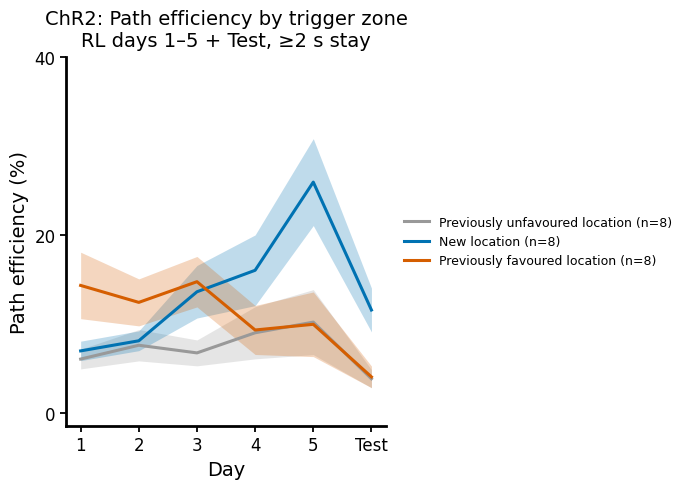


Boxplot: Path efficiency, plot_day 1
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 7.0039 12.4031  7.7278  2.9239  4.2006  3.1547  6.6357  4.5054]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[11.3446 11.2912  5.9207  4.423   3.3588  4.4443  6.7467  8.3646]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 5.3409 10.1387 33.8693  5.7552  6.9072 11.4039 14.2186 27.118 ]

Paired Wilcoxon tests, plot_day 1:
  Previously unfavoured location vs New location: paired n=8, mean=6.069 vs 6.987, median=5.571 vs 6.334, W=11.000, p=0.38281
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=6.069 vs 14.344, median=5.571 vs 10.771, W=3.000, p=0.03906
  New location vs Previously favoured location: paired n=8, mean=6.987 vs 14.3

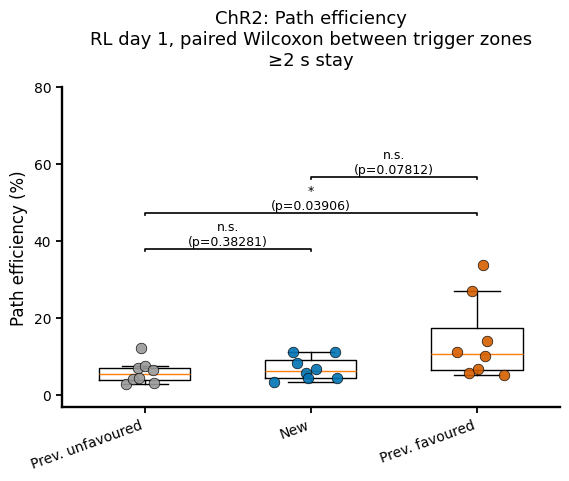


Boxplot: Path efficiency, plot_day 2
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[18.3505 10.0985  8.0141  4.5027  3.078   4.591   8.1649  4.1808]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[10.0368  9.6342  5.2578  9.0499  1.7179  9.4007  8.3932 11.4959]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 6.4756 17.4541 26.572   2.4898 14.4513  8.9307  8.9954 14.1403]

Paired Wilcoxon tests, plot_day 2:
  Previously unfavoured location vs New location: paired n=8, mean=7.623 vs 8.123, median=6.303 vs 9.225, W=17.000, p=0.94531
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=7.623 vs 12.439, median=6.303 vs 11.568, W=9.000, p=0.25000
  New location vs Previously favoured location: paired n=8, mean=8.123 vs 12.4

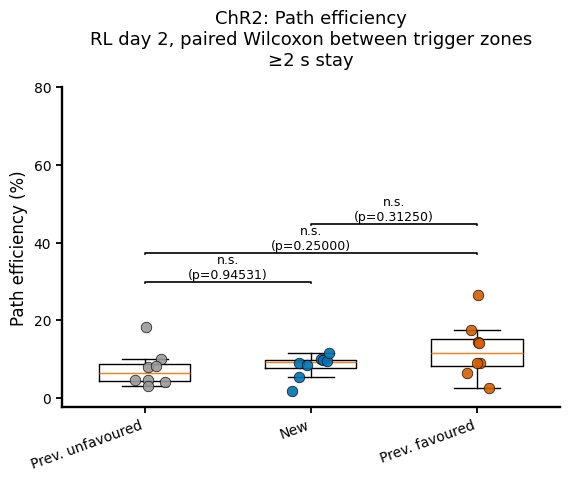


Boxplot: Path efficiency, plot_day 3
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[13.4481 12.7077  5.5223  2.4369  3.8512  3.732   6.1552  6.2492]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[22.0563 11.4089 13.8065 22.8922  2.3719  3.8702  9.6275 23.0117]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[25.2714 12.4433 20.1865 16.883   6.6419  5.4639 24.1659  7.0471]

Paired Wilcoxon tests, plot_day 3:
  Previously unfavoured location vs New location: paired n=8, mean=6.763 vs 13.631, median=5.839 vs 12.608, W=5.000, p=0.07812
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=6.763 vs 14.763, median=5.839 vs 14.663, W=1.000, p=0.01562
  New location vs Previously favoured location: paired n=8, mean=13.631 vs 14

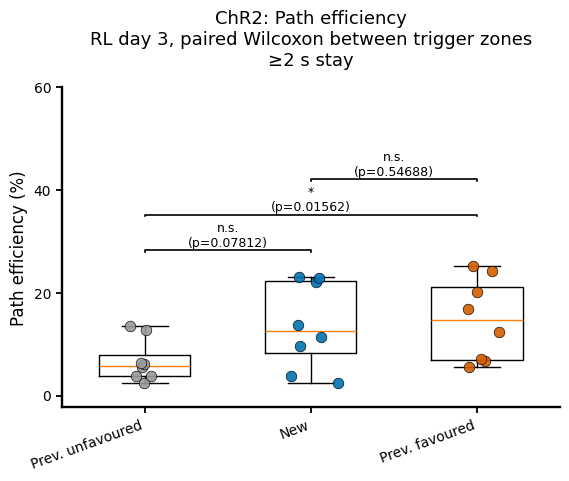


Boxplot: Path efficiency, plot_day 4
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 7.3099 16.7407  8.8756  3.7575  2.1387 25.894   4.8701  2.5957]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[11.8432  7.412  10.0402 38.1142  7.824   7.4417 26.9977 18.6822]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[21.0867  8.1464 14.9219  2.7232  1.3913  5.6889 18.4591  2.2681]

Paired Wilcoxon tests, plot_day 4:
  Previously unfavoured location vs New location: paired n=8, mean=9.023 vs 16.044, median=6.090 vs 10.942, W=10.000, p=0.31250
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=9.023 vs 9.336, median=6.090 vs 6.918, W=17.000, p=0.94531
  New location vs Previously favoured location: paired n=8, mean=16.044 vs 9.

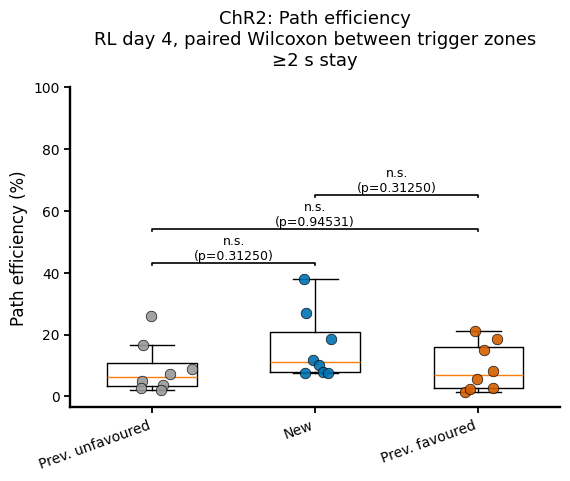


Boxplot: Path efficiency, plot_day 5
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 7.2351  5.0576 14.3819  3.0513  1.9634 33.8142 10.2575  6.0151]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[19.5849 30.6187 24.4277 42.1585 12.245   3.3233 41.8059 33.4642]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[22.2054  3.5538 25.573   3.3717  1.2949  1.8099 18.6395  3.3597]

Paired Wilcoxon tests, plot_day 5:
  Previously unfavoured location vs New location: paired n=8, mean=10.222 vs 25.954, median=6.625 vs 27.523, W=6.000, p=0.10938
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=10.222 vs 9.976, median=6.625 vs 3.463, W=17.000, p=0.94531
  New location vs Previously favoured location: paired n=8, mean=25.954 vs 9

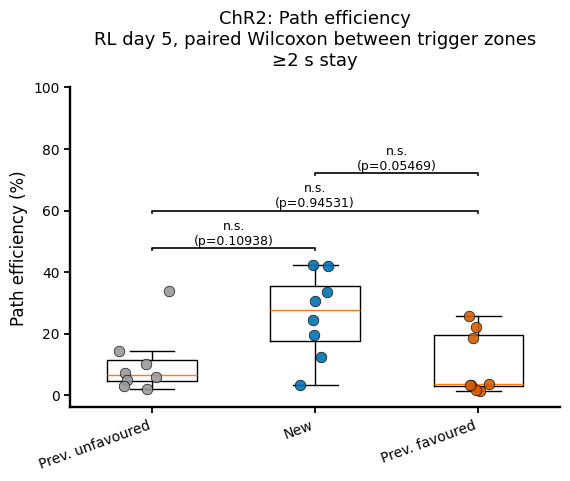


Boxplot: Path efficiency, plot_day 6
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[8.424  4.3959 8.0298 2.2525 1.2766 2.853  1.2361 2.397 ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[17.3563 13.6166  3.477  11.9508  6.1862  3.5447 13.0939 23.4311]
  Previously favoured location: n=7, ids=['AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.3355 8.2005 0.5901 6.4894 1.4379 6.3383 5.0785]

Paired Wilcoxon tests, plot_day 6:
  Previously unfavoured location vs New location: paired n=8, mean=3.858 vs 11.582, median=2.625 vs 12.522, W=2.000, p=0.02344
  Previously unfavoured location vs Previously favoured location: paired n=7, mean=3.206 vs 4.067, median=2.397 vs 5.078, W=10.000, p=0.57812
  New location vs Previously favoured location: paired n=7, mean=10.757 vs 4.067, median=11.951 vs 5.078, W

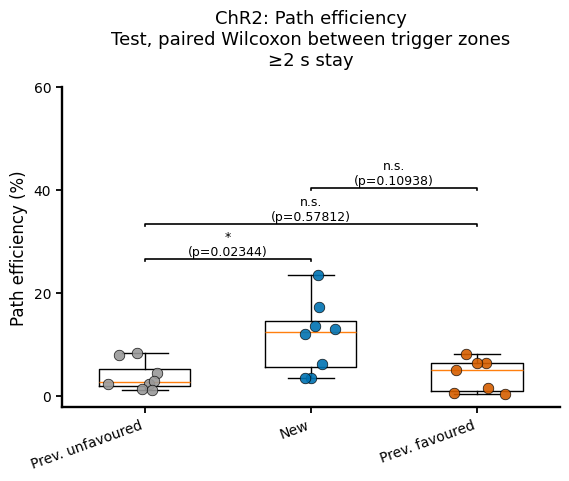


Trial-by-trial plot: Path efficiency
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl

Animals included per trigger zone, trial-by-trial:
  Previously unfavoured location: 8 animals
  New location: 8 animals
  Previously favoured location: 8 animals
Total unique animals included, any zone: 8
Animal subs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
Animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


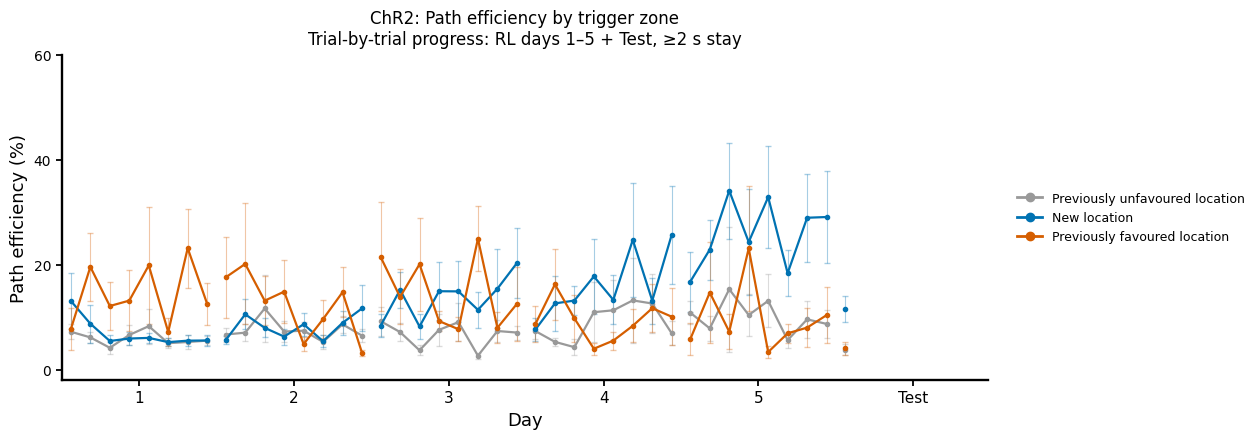


RL day 1 average vs RL day 5 average: Path efficiency
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=11.000, p=0.38281, Day1 mean=6.069, Day5 mean=10.222


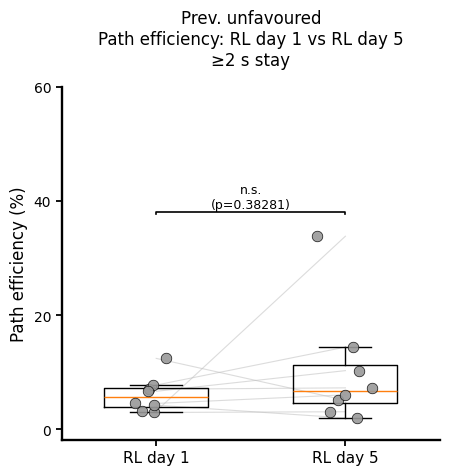


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 mean=6.987, Day5 mean=25.954


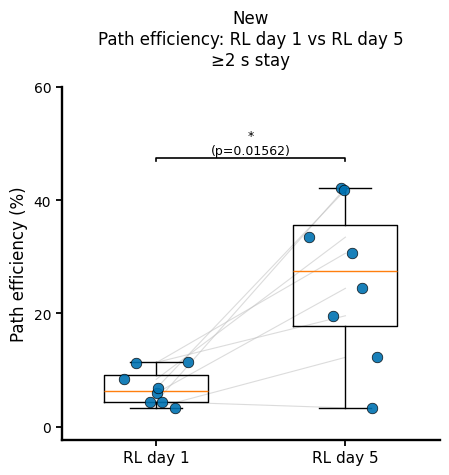


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=9.000, p=0.25000, Day1 mean=14.344, Day5 mean=9.976


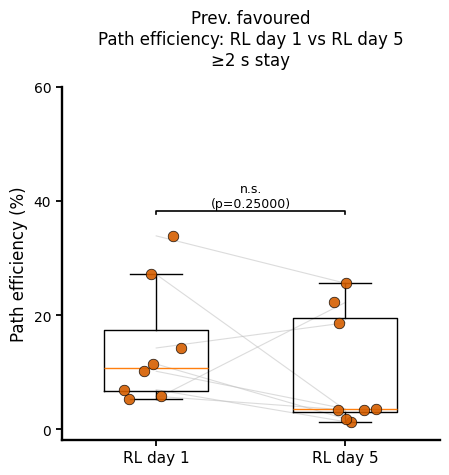


RL day 1 trial 1 vs Test-day average: Path efficiency
Using column: path_eff_trig
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_cipl

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 trial1 mean=7.257, Test mean=3.858


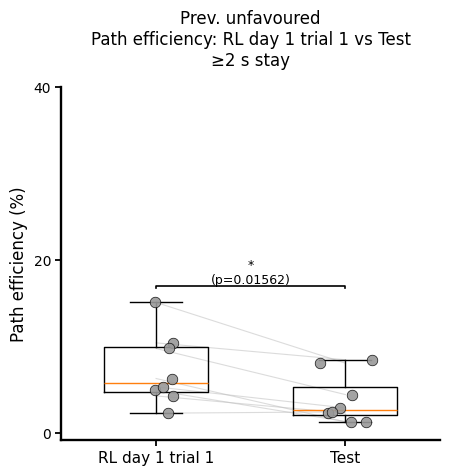


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=16.000, p=0.84375, Day1 trial1 mean=13.120, Test mean=11.582


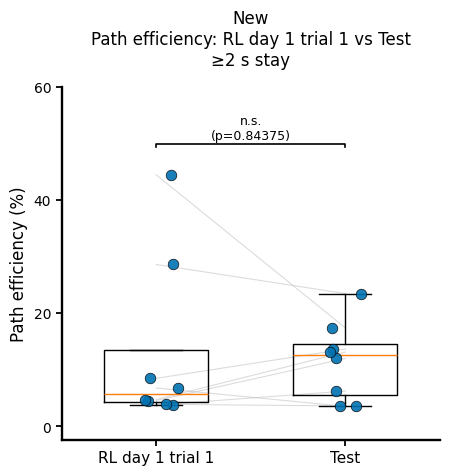


Previously favoured location
  Paired n = 7
  IDs = ['AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=8.000, p=0.37500, Day1 trial1 mean=8.884, Test mean=4.067


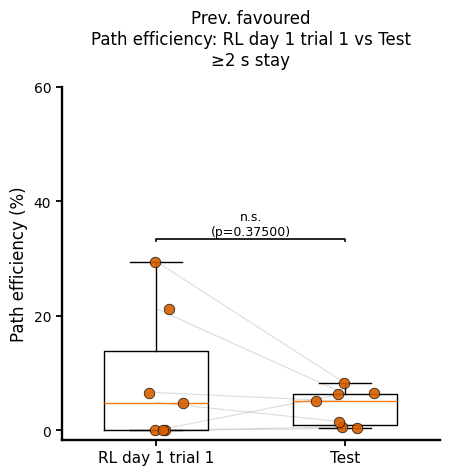

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

# ============================================================
# RL days 1–5 + first post-RL Test day 6
#
# Uses NEW per-trigger CIPL/path_eff dataframe:
#
#   meta_cipl
#
# with one row per trial × trigger:
#   trigger_id
#   CIPL_trig
#   path_eff_trig
#   reached_trigger_trig
#   t_enter_trigger_trig
#
# Produces, for BOTH CIPL_trig and path_eff_trig:
#   1) Wide line plot across RL1–RL5 + Test
#   2) Boxplots for selected days, comparing zones 1/2/3
#      - paired Wilcoxon tests only
#      - no Friedman test
#      - no multiple-comparison correction
#   3) Trial-by-trial within-day progress plot
#   4) For each zone: RL day 1 average vs RL day 5 average
#   5) For each zone: RL day 1 trial 1 vs Test-day average
#
# IMPORTANT:
#   short_duration is NOT filtered anywhere in this code.
#
# Stay criterion label is taken from your computing-code variable:
#   REQUIRE_STAY_2S = True  -> ≥2 s stay
#   REQUIRE_STAY_2S = False -> all visits
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

# These are the NEW per-trigger columns from meta_cipl.
METRICS_TO_PLOT = [
    'CIPL_trig',
    'path_eff_trig',
]

METRIC_LABELS = {
    'CIPL_trig': 'Extra distance travelled',
    'path_eff_trig': 'Path efficiency (%)',
}

METRIC_TITLES = {
    'CIPL_trig': 'Extra distance travelled',
    'path_eff_trig': 'Path efficiency',
}

# If CIPL is currently in tracking units and you want cm, set to 1.2.
# If you want original tracking units, leave as 1.0.
METRIC_SCALE = {
    'CIPL_trig': 1.0,
    'path_eff_trig': 1.0,
}

# Trigger zones
ZONE_IDS = [1, 2, 3]

ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

ZONE_SHORT_LABELS = {
    1: 'Prev. unfavoured',
    2: 'New',
    3: 'Prev. favoured',
}

ZONE_COLORS = {
    1: '#999999',  # grey
    2: '#0072B2',  # blue
    3: '#D55E00',  # orange
}

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# If True, line-plot matrices require all 6 days.
REQUIRE_COMPLETE_LINE = False

# Line plot SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
LINE_SEM_STYLE = 'shaded'
# LINE_SEM_STYLE = 'bar'
# LINE_SEM_STYLE = 'none'

# Trial-by-trial SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
TRIAL_SEM_STYLE = 'bar'
# TRIAL_SEM_STYLE = 'shaded'
# TRIAL_SEM_STYLE = 'none'

RUN_LINE_PLOTS = True
RUN_DAY_BOXPLOTS = True
RUN_TRIAL_BY_TRIAL_PLOTS = True
RUN_DAY1_VS_DAY5_BOXPLOTS = True
RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS = True

# Boxplots comparing zones on each selected day:
#   1 = RL day 1
#   2 = RL day 2
#   ...
#   6 = Test
BOXPLOT_DAYS = [1, 2, 3, 4, 5, 6]

# Pairwise paired Wilcoxon comparisons between zones
ZONE_COMPARISONS = [
    (1, 2),
    (1, 3),
    (2, 3),
]

SHOW_ANIMAL_IDS = False
SHOW_PAIRED_LINES_IN_BOXPLOT = False

# For within-zone paired plots
SHOW_PAIRED_LINES_DAY1_DAY5 = True
SHOW_PAIRED_LINES_TRIAL1_TEST = True

# Plot-day labels
plot_days = np.arange(1, 7)
plot_day_labels = ['1', '2', '3', '4', '5', 'Test']

# Trial-by-trial
trials = np.arange(1, 9)

# Figure sizes
LINE_FIGSIZE = (8.8, 5.0)
TRIAL_FIGSIZE = (15, 4.5)
BOX_FIGSIZE = (5.8, 5.4)
PAIR_BOX_FIGSIZE = (4.6, 5.4)

# ------------------------------------------------------------
# Y-axis padding
# ------------------------------------------------------------
LINE_Y_ZERO_PAD_FRAC = 0.04
LINE_Y_TOP_PAD_FRAC = 0.18

TRIAL_Y_ZERO_PAD_FRAC = 0.04
TRIAL_Y_TOP_PAD_FRAC = 0.12

BOX_Y_ZERO_PAD_FRAC = 0.04
BOX_Y_TOP_PAD_FRAC = 0.12

# Extra p-value/stat bar space for boxplots
BOX_STAT_EXTRA_TOP_FRAC = 0.10

# Optional manual y-axis limits.
# Use None for auto.
YMAX_BY_METRIC = {
    'CIPL_trig': None,
    'path_eff_trig': none,
}

YMIN_BY_METRIC = {
    'CIPL_trig': None,
    'path_eff_trig': 0,
}

Y_TICK_STEP_BY_METRIC = {
    'CIPL_trig': None,
    'path_eff_trig': 20,
}

# Boxplot p-value spacing
JITTER = 0.08
DOT_SIZE = 58
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

P_DECIMALS = 5
P_LINE_START_FRAC = 0.12
P_LINE_STEP_FRAC = 0.30
P_TEXT_OFFSET_FRAC = 0.02

np.random.seed(1)


# ============================================================
# Stay-tag from computing code
# ============================================================

if 'REQUIRE_STAY_2S' not in globals():
    raise NameError(
        "REQUIRE_STAY_2S is not defined. "
        "Run your CIPL/path_eff computing code first, or define REQUIRE_STAY_2S before plotting."
    )

STAY_TAG = '≥2 s stay' if REQUIRE_STAY_2S else 'all visits'


# ============================================================
# Check meta_cipl exists
# ============================================================

if 'meta_cipl' not in globals():
    raise NameError(
        "meta_cipl is not defined. "
        "Run the updated per-trigger CIPL/path_eff computing code first."
    )


# ============================================================
# General helpers
# ============================================================

def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.grid(False)


def scale_value(vals, value_col):
    return np.asarray(vals, dtype=float) * METRIC_SCALE.get(value_col, 1.0)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


def mean_sem_by_col(mat):
    if mat is None or mat.size == 0:
        return None, None

    mean_ = np.full(mat.shape[1], np.nan)
    sem_ = np.full(mat.shape[1], np.nan)

    for j in range(mat.shape[1]):
        m, s = mean_sem(mat[:, j])
        mean_[j] = m
        sem_[j] = s

    return mean_, sem_


def wilcoxon_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def apply_y_axis(
    ax,
    all_vals,
    value_col,
    context='line',
    extra_top_y=None
):
    """
    Sets y-axis with:
      - optional manual YMIN/YMAX by metric
      - automatic range from values actually plotted
      - separate padding for line/trial/box plots
      - 0 padded below x-axis unless manual ymin is set

    context:
      'line'  -> line plot
      'trial' -> trial-by-trial plot
      'box'   -> boxplot
    """

    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)
    tick_step = Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if context == 'line':
        zero_pad = LINE_Y_ZERO_PAD_FRAC
        top_pad = LINE_Y_TOP_PAD_FRAC
    elif context == 'trial':
        zero_pad = TRIAL_Y_ZERO_PAD_FRAC
        top_pad = TRIAL_Y_TOP_PAD_FRAC
    elif context == 'box':
        zero_pad = BOX_Y_ZERO_PAD_FRAC
        top_pad = BOX_Y_TOP_PAD_FRAC
    else:
        raise ValueError("context must be 'line', 'trial', or 'box'")

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)
        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    if extra_top_y is not None and np.isfinite(extra_top_y):
        data_top = max(data_top, extra_top_y)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = data_top * (1 + top_pad)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -zero_pad * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -zero_pad * y_top

    ax.set_ylim(y_bottom, y_top)

    if tick_step is not None:
        ax.set_yticks(np.arange(0, y_top + tick_step, tick_step))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + 0.015 * yrng, y + 0.015 * yrng, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def normalise_meta_cipl_columns(df):
    """
    Makes sure the long-format dataframe has clean column names:
      trigger_id
      trial_id

    This protects against merge-created names like trigger_id_x / trigger_id_y.
    """
    df = df.copy()

    if 'trigger_id' not in df.columns:
        if 'trigger_id_x' in df.columns:
            df = df.rename(columns={'trigger_id_x': 'trigger_id'})
        elif 'trigger_id_y' in df.columns:
            df = df.rename(columns={'trigger_id_y': 'trigger_id'})

    if 'trial_id' not in df.columns:
        if 'trial_id_x' in df.columns:
            df = df.rename(columns={'trial_id_x': 'trial_id'})
        elif 'trial_id_y' in df.columns:
            df = df.rename(columns={'trial_id_y': 'trial_id'})

    return df


# ============================================================
# Prepare RL + Test data from meta_cipl
# ============================================================

def prepare_rl_test_data(meta_cipl_df, value_col):
    """
    Uses the NEW per-trigger long-format dataframe.

    Each row is one trial × trigger.
    Therefore trigger_id is already the actual zone being plotted.

    This no longer uses first_choice_trigger as trigger_id.
    """
    meta_cipl_df = normalise_meta_cipl_columns(meta_cipl_df)

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        'trial_id',
        'trigger_id',
        value_col,
    ]

    missing_cols = [c for c in needed_cols if c not in meta_cipl_df.columns]
    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in meta_cipl: {missing_cols}\n"
            f"The selected VALUE_COL is '{value_col}'.\n"
            "Make sure you ran the updated per-trigger CIPL/path_eff computing code."
        )

    mt = meta_cipl_df[
        (meta_cipl_df['usable'] == 1) &
        (meta_cipl_df['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_cipl_df['trial_type'].isin(['RL', 'T'])) &
        (meta_cipl_df['trigger_id'].isin(ZONE_IDS)) &
        (meta_cipl_df[value_col].notna()) &
        (np.isfinite(meta_cipl_df[value_col]))
    ].copy()

    mt['trigger_id'] = mt['trigger_id'].astype(int)

    # Scale metric if needed.
    mt[value_col] = scale_value(mt[value_col].values, value_col)

    # No short_duration filtering anywhere.

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[
            ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[
            ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    # --------------------------------------------------------
    # Assign plot_day:
    # RL -> trial_type_day 1–5
    # T  -> first T session after last RL = day 6
    # --------------------------------------------------------
    mt['plot_day'] = np.nan

    mask_RL = mt['trial_type'] == 'RL'
    mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

    mt = mt[
        (~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in mt['sub'].unique():
        ms = mt[mt['sub'] == sub].copy()

        RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']

        if len(RL_ses) == 0:
            continue

        last_RL_ses = RL_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_RL_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = mt.index[
            (mt['sub'] == sub) &
            (mt['trial_type'] == 'T') &
            (mt['ses'] == first_T_ses)
        ]

        mt.loc[idx, 'plot_day'] = 6

    mt = mt[mt['plot_day'].isin(plot_days)].copy()

    # --------------------------------------------------------
    # Create trial_in_day = 1..8 based on unique trial_id.
    # Important because each trial has 3 trigger rows.
    # --------------------------------------------------------
    if 'trial_in_day' in mt.columns:
        mt = mt.drop(columns=['trial_in_day'])

    trial_table = (
        mt[['trial_id', 'sub', 'ses', 'plot_day']]
        .drop_duplicates('trial_id')
        .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
        .copy()
    )

    trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1
    trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)].copy()

    mt = mt.merge(
        trial_table[['trial_id', 'trial_in_day']],
        on='trial_id',
        how='inner'
    )

    return mt


# ============================================================
# Matrix / values builders
# ============================================================

def build_zone_day_matrix(mt_all, zone_id, value_col):
    mt_zone = mt_all[mt_all['trigger_id'] == zone_id].copy()

    perf_mat = []
    subjects = []
    ids = []

    for sub in sorted(mt_zone['sub'].unique()):
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = (
            ms.groupby('plot_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE_LINE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        ids.append(get_animal_id(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, ids


def build_zone_trial_matrix(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    if len(md) == 0:
        return None, []

    rows = []
    ids = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        mean_by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_trial.get(t, np.nan) for t in trials],
            dtype=float
        )

        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        ids.append(get_animal_id(ms, sub))

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), ids


def day_values_for_zone(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


def day_trial_value_for_zone(mt_all, plot_day, trial_in_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trial_in_day'] == trial_in_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'trial_in_day': trial_in_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plot 1: line plot across RL1–RL5 + Test
# ============================================================

def plot_line_across_days(mt, value_col, value_label, value_title):
    if not RUN_LINE_PLOTS:
        return

    zone_data = {}

    print("\n============================================================")
    print(f"Line plot: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", STAY_TAG)
    print("Plotting separate trigger zones from meta_cipl")

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_day_matrix(mt, zid, value_col)

        zone_data[zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {ZONE_LABELS[zid]}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    x_vals = plot_days - 1
    all_y = []

    for zid in ZONE_IDS:
        mat = zone_data[zid]['mat']
        subs = zone_data[zid]['subs']

        if mat is None or len(subs) == 0:
            continue

        mean_vals, sem_vals = mean_sem_by_col(mat)
        col = ZONE_COLORS[zid]

        if LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                x_vals,
                mean_vals - sem_vals,
                mean_vals + sem_vals,
                color=col,
                alpha=0.25,
                linewidth=0,
                zorder=1
            )

        ax.plot(
            x_vals,
            mean_vals,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{ZONE_LABELS[zid]} (n={len(subs)})',
            zorder=3
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                x_vals,
                mean_vals,
                yerr=sem_vals,
                fmt='none',
                ecolor=col,
                alpha=0.45,
                elinewidth=1.1,
                capsize=3,
                zorder=2
            )

        elif LINE_SEM_STYLE == 'none':
            pass

        elif LINE_SEM_STYLE != 'shaded':
            raise ValueError("LINE_SEM_STYLE must be 'shaded', 'bar', or 'none'")

        all_y.extend(list((mean_vals + sem_vals)[np.isfinite(mean_vals + sem_vals)]))
        all_y.extend(list((mean_vals - sem_vals)[np.isfinite(mean_vals - sem_vals)]))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(value_label, fontsize=14)

    ax.set_xticks(x_vals)
    ax.set_xticklabels(plot_day_labels, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title} by trigger zone\n'
        f'RL days 1–5 + Test, {STAY_TAG}',
        fontsize=14,
        pad=8
    )

    style_nature(ax, linewidth=2.0)
    apply_y_axis(ax, all_y, value_col, context='line')

    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout(rect=[0, 0, 0.80, 1])
    plt.show()


# ============================================================
# Plot 2: boxplot comparing zones for selected days
# ============================================================

def plot_day_boxplot(mt, value_col, value_label, value_title, test_day):
    if not RUN_DAY_BOXPLOTS:
        return

    zone_dfs = {
        zid: day_values_for_zone(mt, test_day, zid, value_col)
        for zid in ZONE_IDS
    }

    vals_groups = [
        zone_dfs[zid]['value'].values.astype(float)
        for zid in ZONE_IDS
    ]

    print("\n============================================================")
    print(f"Boxplot: {value_title}, plot_day {test_day}")
    print("Using column:", value_col)
    print("Computed using:", STAY_TAG)
    print("Plotting separate trigger zones from meta_cipl")

    for zid in ZONE_IDS:
        df_z = zone_dfs[zid]
        print(
            f"  {ZONE_LABELS[zid]}: "
            f"n={len(df_z)}, ids={list(df_z['id'])}, "
            f"values={np.round(df_z['value'].values.astype(float), 4)}"
        )

    fig, ax = plt.subplots(figsize=BOX_FIGSIZE)

    positions = np.arange(len(ZONE_IDS))

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, zid in enumerate(ZONE_IDS):
        vals = vals_groups[i]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=ZONE_COLORS[zid],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, zone_dfs[zid]['id'].values):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=ZONE_COLORS[zid],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    print(f"\nPaired Wilcoxon tests, plot_day {test_day}:")

    stats_to_draw = []

    for zid1, zid2 in ZONE_COMPARISONS:
        df1 = zone_dfs[zid1][['sub', 'value']].rename(columns={'value': 'value_1'})
        df2 = zone_dfs[zid2][['sub', 'value']].rename(columns={'value': 'value_2'})

        paired = df1.merge(df2, on='sub', how='inner')
        paired = paired[
            paired['value_1'].notna() &
            paired['value_2'].notna() &
            np.isfinite(paired['value_1']) &
            np.isfinite(paired['value_2'])
        ].copy()

        vals1 = paired['value_1'].values.astype(float)
        vals2 = paired['value_2'].values.astype(float)

        stat, p = wilcoxon_safe(vals1, vals2)

        print(
            f"  {ZONE_LABELS[zid1]} vs {ZONE_LABELS[zid2]}: "
            f"paired n={len(paired)}, "
            f"mean={np.nanmean(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmean(vals2) if len(vals2) else np.nan:.3f}, "
            f"median={np.nanmedian(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmedian(vals2) if len(vals2) else np.nan:.3f}, "
            f"W={stat:.3f}, p={format_p(p)}"
        )

        stats_to_draw.append((
            ZONE_IDS.index(zid1),
            ZONE_IDS.index(zid2),
            p
        ))

        if SHOW_PAIRED_LINES_IN_BOXPLOT and len(paired) > 0:
            for _, row in paired.iterrows():
                ax.plot(
                    [ZONE_IDS.index(zid1), ZONE_IDS.index(zid2)],
                    [row['value_1'], row['value_2']],
                    '-',
                    color='0.75',
                    linewidth=0.7,
                    alpha=0.45,
                    zorder=1
                )

    nonempty_vals = [v for v in vals_groups if len(v) > 0]
    extra_top_y = None

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        all_vals = all_vals[np.isfinite(all_vals)]

        if len(all_vals) > 0:
            ymax = np.nanmax(all_vals)
            ymin = np.nanmin(all_vals)
            yrng = ymax - ymin

            if not np.isfinite(yrng) or yrng <= 0:
                yrng = max(abs(ymax), 1.0)

            current_y = ymax + P_LINE_START_FRAC * yrng
            y_step = P_LINE_STEP_FRAC * yrng

            for x1, x2, p in stats_to_draw:
                draw_sig_bar(ax, x1, x2, current_y, p, yrng)
                current_y += y_step

            extra_top_y = current_y + BOX_STAT_EXTRA_TOP_FRAC * yrng

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [ZONE_SHORT_LABELS[zid] for zid in ZONE_IDS],
        fontsize=10,
        rotation=20,
        ha='right'
    )

    ax.set_ylabel(value_label, fontsize=12)

    day_label = 'Test' if test_day == 6 else f'RL day {test_day}'

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title}\n'
        f'{day_label}, paired Wilcoxon between trigger zones\n'
        f'{STAY_TAG}',
        fontsize=13,
        pad=16
    )

    style_nature(ax, linewidth=1.7)

    all_for_axis = np.concatenate(nonempty_vals) if len(nonempty_vals) > 0 else np.array([])

    apply_y_axis(
        ax,
        all_for_axis,
        value_col,
        context='box',
        extra_top_y=extra_top_y
    )

    plt.tight_layout(rect=[0, 0, 1, 0.91])
    plt.show()


# ============================================================
# Plot 3: trial-by-trial within-day plot
# ============================================================

def plot_trial_by_trial(mt, value_col, value_label, value_title):
    if not RUN_TRIAL_BY_TRIAL_PLOTS:
        return

    print("\n============================================================")
    print(f"Trial-by-trial plot: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", STAY_TAG)
    print("Plotting separate trigger zones from meta_cipl")

    fig, ax = plt.subplots(figsize=TRIAL_FIGSIZE)

    offsets = np.linspace(0.06, 0.94, len(trials))

    all_y_for_axis = []
    subs_zone = {}

    for zid in ZONE_IDS:
        first_label = True

        for day in plot_days:
            mat, ids = build_zone_trial_matrix(mt, day, zid, value_col)

            if mat is None:
                continue

            x = day + offsets

            mean_, sem_ = mean_sem_by_col(mat)

            col = ZONE_COLORS[zid]

            valid_band = np.isfinite(mean_) & np.isfinite(sem_)
            if np.any(valid_band):
                all_y_for_axis.extend(list((mean_ + sem_)[valid_band]))
                all_y_for_axis.extend(list((mean_ - sem_)[valid_band]))

            if TRIAL_SEM_STYLE == 'shaded':
                ax.fill_between(
                    x,
                    mean_ - sem_,
                    mean_ + sem_,
                    color=col,
                    alpha=0.20,
                    linewidth=0,
                    zorder=1
                )

            ax.plot(
                x,
                mean_,
                'o-',
                color=col,
                linewidth=1.6,
                markersize=3,
                label=ZONE_LABELS[zid] if first_label else '_nolegend_',
                zorder=3
            )

            if TRIAL_SEM_STYLE == 'bar':
                ax.errorbar(
                    x,
                    mean_,
                    yerr=sem_,
                    fmt='none',
                    ecolor=col,
                    alpha=0.35,
                    elinewidth=0.8,
                    capsize=2,
                    zorder=2
                )

            elif TRIAL_SEM_STYLE == 'none':
                pass

            elif TRIAL_SEM_STYLE != 'shaded':
                raise ValueError("TRIAL_SEM_STYLE must be 'shaded', 'bar', or 'none'")

            first_label = False

        subs_zone[zid] = sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())

    ax.set_xlabel('Day', fontsize=13)
    ax.set_ylabel(value_label, fontsize=13)

    ax.set_xticks(plot_days + 0.5)
    ax.set_xticklabels(plot_day_labels, fontsize=11)

    ax.set_xlim(1.0, 6.98)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title} by trigger zone\n'
        f'Trial-by-trial progress: RL days 1–5 + Test, {STAY_TAG}',
        fontsize=12,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    apply_y_axis(
        ax,
        all_y_for_axis,
        value_col,
        context='trial'
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=ZONE_COLORS[zid],
            lw=2,
            marker='o',
            label=ZONE_LABELS[zid]
        )
        for zid in ZONE_IDS
    ]

    ax.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=9
    )

    print("\nAnimals included per trigger zone, trial-by-trial:")
    for zid in ZONE_IDS:
        ids_z = sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        print(f"  {ZONE_LABELS[zid]}: {len(ids_z)} animals")

    all_animals = sorted(set().union(*[
        set(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        for zid in ZONE_IDS
    ]))

    print(f"Total unique animals included, any zone: {len(all_animals)}")
    print("Animal subs:", all_animals)

    if 'id' in mt.columns and len(mt) > 0:
        ids_all = sorted(mt['id'].dropna().astype(str).unique())
        print("Animal IDs:", ids_all)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


# ============================================================
# Plot 4: each zone, RL day 1 average vs RL day 5 average
# ============================================================

def plot_day1_vs_day5_for_each_zone(mt, value_col, value_label, value_title):
    if not RUN_DAY1_VS_DAY5_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 average vs RL day 5 average: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", STAY_TAG)
    print("Plotting separate trigger zones from meta_cipl")

    for zid in ZONE_IDS:
        df_day1 = day_values_for_zone(mt, 1, zid, value_col).rename(
            columns={'value': 'day1_value', 'id': 'day1_id'}
        )
        df_day5 = day_values_for_zone(mt, 5, zid, value_col).rename(
            columns={'value': 'day5_value', 'id': 'day5_id'}
        )

        if len(df_day1) == 0 or len(df_day5) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1/day 5 data.")
            continue

        paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
            df_day5[['sub', 'day5_id', 'day5_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['day1_id'].fillna(paired['day5_id'])

        paired = paired[
            paired['day1_value'].notna() &
            paired['day5_value'].notna() &
            np.isfinite(paired['day1_value']) &
            np.isfinite(paired['day5_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1/day 5 data.")
            continue

        d1 = paired['day1_value'].values.astype(float)
        d5 = paired['day5_value'].values.astype(float)

        stat, p = wilcoxon_safe(d1, d5)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 mean={np.nanmean(d1):.3f}, Day5 mean={np.nanmean(d5):.3f}"
        )

        fig, ax = plt.subplots(figsize=PAIR_BOX_FIGSIZE)

        data = [d1, d5]
        positions = np.arange(2)

        ax.boxplot(
            data,
            positions=positions,
            widths=0.55,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES_DAY1_DAY5:
            for v1, v5 in zip(d1, d5):
                ax.plot(
                    positions,
                    [v1, v5],
                    '-',
                    color='0.75',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(data):
            x = np.random.normal(positions[i], JITTER, size=len(vals))
            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=ZONE_COLORS[zid],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=ZONE_COLORS[zid],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[d1, d5]
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng
        draw_sig_bar(ax, positions[0], positions[1], y, p, yrng)

        ax.set_xticks(positions)
        ax.set_xticklabels(['RL day 1', 'RL day 5'], fontsize=11)

        ax.set_ylabel(value_label, fontsize=12)

        ax.set_title(
            f'{ZONE_SHORT_LABELS[zid]}\n'
            f'{value_title}: RL day 1 vs RL day 5\n'
            f'{STAY_TAG}',
            fontsize=12,
            pad=16
        )

        style_nature(ax, linewidth=1.7)

        apply_y_axis(
            ax,
            all_vals,
            value_col,
            context='box',
            extra_top_y=y + BOX_STAT_EXTRA_TOP_FRAC * yrng
        )

        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.show()


# ============================================================
# Plot 5: each zone, RL day 1 trial 1 vs Test-day average
# ============================================================

def plot_day1_trial1_vs_test_for_each_zone(mt, value_col, value_label, value_title):
    if not RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 trial 1 vs Test-day average: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", STAY_TAG)
    print("Plotting separate trigger zones from meta_cipl")

    for zid in ZONE_IDS:
        df_trial1 = day_trial_value_for_zone(
            mt_all=mt,
            plot_day=1,
            trial_in_day=1,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'day1_trial1_value', 'id': 'trial1_id'})

        df_test = day_values_for_zone(
            mt_all=mt,
            plot_day=6,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'test_value', 'id': 'test_id'})

        if len(df_trial1) == 0 or len(df_test) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1 trial 1 / Test data.")
            continue

        paired = df_trial1[['sub', 'trial1_id', 'day1_trial1_value']].merge(
            df_test[['sub', 'test_id', 'test_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['trial1_id'].fillna(paired['test_id'])

        paired = paired[
            paired['day1_trial1_value'].notna() &
            paired['test_value'].notna() &
            np.isfinite(paired['day1_trial1_value']) &
            np.isfinite(paired['test_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1 trial 1 / Test data.")
            continue

        t1 = paired['day1_trial1_value'].values.astype(float)
        test = paired['test_value'].values.astype(float)

        stat, p = wilcoxon_safe(t1, test)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 trial1 mean={np.nanmean(t1):.3f}, Test mean={np.nanmean(test):.3f}"
        )

        fig, ax = plt.subplots(figsize=PAIR_BOX_FIGSIZE)

        data = [t1, test]
        positions = np.arange(2)

        ax.boxplot(
            data,
            positions=positions,
            widths=0.55,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES_TRIAL1_TEST:
            for v1, v2 in zip(t1, test):
                ax.plot(
                    positions,
                    [v1, v2],
                    '-',
                    color='0.75',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(data):
            x = np.random.normal(positions[i], JITTER, size=len(vals))
            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=ZONE_COLORS[zid],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=ZONE_COLORS[zid],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[t1, test]
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng
        draw_sig_bar(ax, positions[0], positions[1], y, p, yrng)

        ax.set_xticks(positions)
        ax.set_xticklabels(['RL day 1 trial 1', 'Test'], fontsize=11)

        ax.set_ylabel(value_label, fontsize=12)

        ax.set_title(
            f'{ZONE_SHORT_LABELS[zid]}\n'
            f'{value_title}: RL day 1 trial 1 vs Test\n'
            f'{STAY_TAG}',
            fontsize=12,
            pad=16
        )

        style_nature(ax, linewidth=1.7)

        apply_y_axis(
            ax,
            all_vals,
            value_col,
            context='box',
            extra_top_y=y + BOX_STAT_EXTRA_TOP_FRAC * yrng
        )

        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.show()


# ============================================================
# Run full analysis for CIPL_trig and path_eff_trig
# ============================================================

for VALUE_COL in METRICS_TO_PLOT:

    VALUE_LABEL = METRIC_LABELS.get(VALUE_COL, VALUE_COL)
    VALUE_TITLE = METRIC_TITLES.get(VALUE_COL, VALUE_COL)

    print("\n\n############################################################")
    print(f"RUNNING: {VALUE_COL}")
    print("Computed using:", STAY_TAG)
    print("Using separate per-trigger values from meta_cipl")
    print("############################################################")

    mt = prepare_rl_test_data(meta_cipl, VALUE_COL)

    print("\nFiltered RL/Test rows:")
    if len(mt) == 0:
        print("No rows left after filtering.")
        continue

    cols_to_print = ['sub']
    if 'id' in mt.columns:
        cols_to_print.append('id')

    optional_cols = []
    if 'reached_trigger_trig' in mt.columns:
        optional_cols.append('reached_trigger_trig')
    if 't_enter_trigger_trig' in mt.columns:
        optional_cols.append('t_enter_trigger_trig')
    if 'first_choice_trigger_original' in mt.columns:
        optional_cols.append('first_choice_trigger_original')

    cols_to_print += [
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'plot_day',
        'trial_in_day',
        'trigger_id',
        VALUE_COL,
    ] + optional_cols

    print(
        mt[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

    # 1) Wide line plot
    plot_line_across_days(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    # 2) Day boxplots comparing zones
    if RUN_DAY_BOXPLOTS:
        for d in BOXPLOT_DAYS:
            plot_day_boxplot(
                mt=mt,
                value_col=VALUE_COL,
                value_label=VALUE_LABEL,
                value_title=VALUE_TITLE,
                test_day=d
            )

    # 3) Trial-by-trial plot
    plot_trial_by_trial(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    # 4) Each zone: RL day 1 average vs RL day 5 average
    plot_day1_vs_day5_for_each_zone(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

    # 5) Each zone: RL day 1 trial 1 vs Test-day average
    plot_day1_trial1_vs_test_for_each_zone(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE
    )

In [412]:
zid = 3  # previously favoured location
value_cols = ['CIPL_trig', 'path_eff_trig']

for value_col in value_cols:
    print("\n============================================================")
    print(value_col)

    df_trial1 = day_trial_value_for_zone(
        mt_all=mt,
        plot_day=1,
        trial_in_day=1,
        zone_id=zid,
        value_col=value_col
    ).rename(columns={'value': 'day1_trial1_value', 'id': 'trial1_id'})

    df_test = day_values_for_zone(
        mt_all=mt,
        plot_day=6,
        zone_id=zid,
        value_col=value_col
    ).rename(columns={'value': 'test_value', 'id': 'test_id'})

    paired_raw = df_trial1[['sub', 'trial1_id', 'day1_trial1_value']].merge(
        df_test[['sub', 'test_id', 'test_value']],
        on='sub',
        how='outer'
    )

    paired_raw['id'] = paired_raw['trial1_id'].fillna(paired_raw['test_id'])

    paired_raw['day1_finite'] = np.isfinite(paired_raw['day1_trial1_value'])
    paired_raw['test_finite'] = np.isfinite(paired_raw['test_value'])
    paired_raw['included'] = paired_raw['day1_finite'] & paired_raw['test_finite']

    print(
        paired_raw[
            [
                'sub',
                'id',
                'day1_trial1_value',
                'test_value',
                'day1_finite',
                'test_finite',
                'included',
            ]
        ].sort_values(['included', 'sub'])
    )

    print("\nIncluded n:", paired_raw['included'].sum())
    print("Dropped animals:")
    print(paired_raw.loc[~paired_raw['included'], ['sub', 'id', 'day1_trial1_value', 'test_value']])


CIPL_trig
   sub  id  day1_trial1_value  test_value  day1_finite  test_finite  included
0    8  AD           8.272539         NaN         True        False     False
1    9  AE                NaN    0.511510        False         True     False
3   11  AG                NaN  908.047677        False         True     False
4   12  AH                NaN  787.439240        False         True     False
2   10  AF          83.744272  481.501229         True         True      True
5   16  AM         341.061065  210.656060         True         True      True
6   17  AN          47.637000  160.323448         True         True      True
7   18  AO         923.796938  718.893363         True         True      True

Included n: 4
Dropped animals:
   sub  id  day1_trial1_value  test_value
0    8  AD           8.272539         NaN
1    9  AE                NaN    0.511510
3   11  AG                NaN  908.047677
4   12  AH                NaN  787.439240

path_eff_trig
   sub  id  day1_trial1_value 

 11%|█▏        | 712/6195 [00:06<00:52, 105.24it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 19%|█▉        | 1170/6195 [00:10<00:40, 125.08it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 42%|████▏     | 2615/6195 [00:22<00:21, 167.04it/s]

...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-071_id-C1/ses-01_date-20260326/behav/sub-071_ses-01_trial-06_data-position.csv' does not exist.


 88%|████████▊ | 5424/6195 [00:44<00:06, 119.50it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


100%|██████████| 6195/6195 [00:51<00:00, 119.80it/s]


Fail-rate animals included:
  VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  CA1 control (CA1_control): n = 3, ids = ['C9', 'C10', 'C11']

Group fail rate by day:

VTA (ChR2)
  Day 1: mean fail rate = 1.04%, SEM = 1.04%, n = 12
  Day 2: mean fail rate = 3.12%, SEM = 2.24%, n = 12
  Day 3: mean fail rate = 1.04%, SEM = 1.04%, n = 12
  Day 4: mean fail rate = 0.00%, SEM = 0.00%, n = 12
  Day 5: mean fail rate = 0.00%, SEM = 0.00%, n = 12
  Test: mean fail rate = 0.00%, SEM = 0.00%, n = 12

CA1 (CA1)
  Day 1: mean fail rate = 21.43%, SEM = 7.07%, n = 7
  Day 2: mean fail rate = 14.29%, SEM = 5.05%, n = 7
  Day 3: mean fail rate = 16.07%, SEM = 3.57%, n = 7
  Day 4: mean fail rate = 3.57%, SEM = 2.31%, n = 7
  Day 5: mean fail rate = 0.00%, SEM = 0.00%, n = 7
  Test: mean fail rate = 0.00%, SEM = 0.00%, 

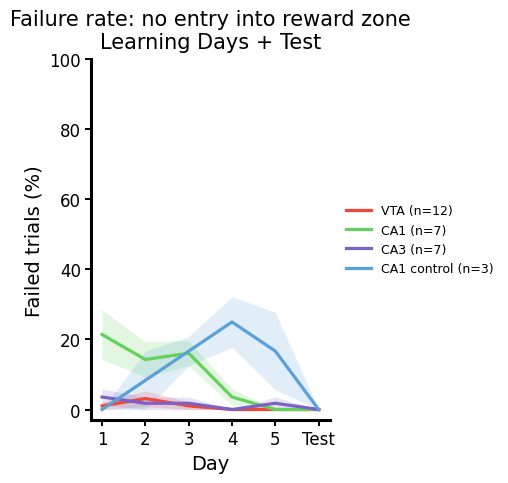

In [94]:
# ============================================================
# Compute and plot fail rate across L1-L5 + Test
#
# Success = at least one entrance into ANY trigger zone
# Fail    = no entrance into any trigger zone in that trial
#
# Produces:
#   metadata['entered_any_trigger'] = 1/0
#   metadata['fail_any_trigger']    = 1/0
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# OPTIONS
# ============================================================
#GROUPS = ['ChR2', 'eYFP_ChR2']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA1']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA3']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
GROUPS = ['ChR2','CA1', 'CA3', 'CA1_control']
# GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

EXCLUDE_ID = ['AS', 'AN']     # e.g. ['AS', 'AN']
EXCLUDE_SUBS = []     # e.g. [43]

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False

R_TRIGGER = 10 / 1.2

YMIN = -3             # makes 0 visible above bottom axis
YMAX = 100
Y_TICK_STEP = 20

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1) Compute success/fail for each trial
# ============================================================
metadata['entered_any_trigger'] = np.nan
metadata['fail_any_trigger'] = np.nan

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    position_ = add_dist_to_trigger(position.copy(), triggerLoc)

    entered = False

    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i + 1
        )

        if df_trigger_interaction is not None and len(df_trigger_interaction) > 0:
            entered = True
            break

    metadata.at[trial_id, 'entered_any_trigger'] = 1 if entered else 0
    metadata.at[trial_id, 'fail_any_trigger'] = 0 if entered else 1

# ============================================================
# 2) Filter metadata
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(GROUPS)) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['fail_any_trigger'].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 3) Assign plot_day: L1-L5 + first post-learning Test = day 6
# ============================================================
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1-5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ============================================================
# 4) Build animal x day fail-rate matrix
# ============================================================
def build_fail_rate_matrix(meta_group):
    """
    For each animal/day:
      fail rate = mean(fail_any_trigger) * 100

    Since fail_any_trigger is 1 for fail and 0 for success,
    the daily mean gives the proportion of failed trials.
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        fail_by_day = ms.groupby('plot_day')['fail_any_trigger'].mean() * 100.0

        vals = np.array(
            [fail_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem

# ============================================================
# 5) Build group data
# ============================================================
group_data = {}

print("Fail-rate animals included:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_fail_rate_matrix(meta_g)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

# ============================================================
# 6) Print day-wise fail rate
# ============================================================
print("\nGroup fail rate by day:")
for g in GROUPS:
    mat = group_data[g]['mat']

    if mat is None:
        continue

    print(f"\n{DISPLAY_NAME.get(g, g)} ({g})")
    for i, d in enumerate(plot_days):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            print(f"  Day {d}: no data")
            continue

        mean_fail = np.nanmean(vals)
        sem_fail = np.nanstd(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
        label = 'Test' if d == 6 else f'Day {d}'

        print(f"  {label}: mean fail rate = {mean_fail:.2f}%, SEM = {sem_fail:.2f}%, n = {len(vals)}")

# ============================================================
# 7) Plot
# ============================================================
fig, ax = plt.subplots(figsize=(6.2, 5.2))

for g in GROUPS:
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']

    if mat is None or len(subs) == 0:
        continue

    col = get_genotype_color(g)
    label = DISPLAY_NAME.get(g, g)

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=0.15,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_ = np.nanmean(mat, axis=0)
    sem_ = sem_by_day(mat)

    if SHOW_SEM_SHADING:
        ax.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.18,
            linewidth=0,
            zorder=2
        )

    ax.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        linewidth=2.3,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

    if SHOW_SEM_ERRORBARS:
        ax.errorbar(
            x_vals,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            elinewidth=1.2,
            capsize=3,
            alpha=0.9,
            zorder=4
        )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Failed trials (%)', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.set_yticks(np.arange(0, YMAX + 1, Y_TICK_STEP))
ax.tick_params(axis='y', labelsize=12)

ax.set_ylim(YMIN, YMAX)

ax.set_title(
    'Failure rate: no entry into reward zone\nLearning Days + Test',
    fontsize=15,
    pad=8
)

ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

ax.legend(
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()

In [76]:
print(metadata[['L_actual', 'L_shortest', 'CIPL']].corr())

# Check whether L_shortest changes across learning days
tmp = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['L_shortest'].notna())
].copy()

tmp['plot_day'] = np.nan
mask_L = tmp['trial_type'] == 'L'
tmp.loc[mask_L, 'plot_day'] = tmp.loc[mask_L, 'trial_type_day']

for sub in tmp['sub'].unique():
    ms = tmp[tmp['sub'] == sub]
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = tmp.index[
        (tmp['sub'] == sub) &
        (tmp['trial_type'] == 'T') &
        (tmp['ses'] == first_T_ses)
    ]
    tmp.loc[idx, 'plot_day'] = 6

tmp = tmp[tmp['plot_day'].isin([1,2,3,4,5,6])].copy()

summary = (
    tmp.groupby(['genotype', 'plot_day'])['L_shortest']
       .agg(['mean', 'std', 'count'])
       .reset_index()
)

print(summary)

            L_actual  L_shortest      CIPL
L_actual    1.000000    0.212780  0.994167
L_shortest  0.212780    1.000000  0.106154
CIPL        0.994167    0.106154  1.000000
     genotype  plot_day       mean        std  count
0       ArchT       1.0  37.365402  20.253192     48
1       ArchT       2.0  31.484045  16.937097     47
2       ArchT       3.0  36.453064  18.080572     48
3       ArchT       4.0  33.701927  17.213137     48
4       ArchT       5.0  31.690167  17.336974     48
..        ...       ...        ...        ...    ...
73  eYFP_ChR2       2.0  35.866066  21.191010     40
74  eYFP_ChR2       3.0  33.294695  18.284776     40
75  eYFP_ChR2       4.0  30.146381  18.373580     39
76  eYFP_ChR2       5.0  33.093331  18.004688     40
77  eYFP_ChR2       6.0  35.345171  11.108632      5

[78 rows x 5 columns]



=== dist_to_trigger ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


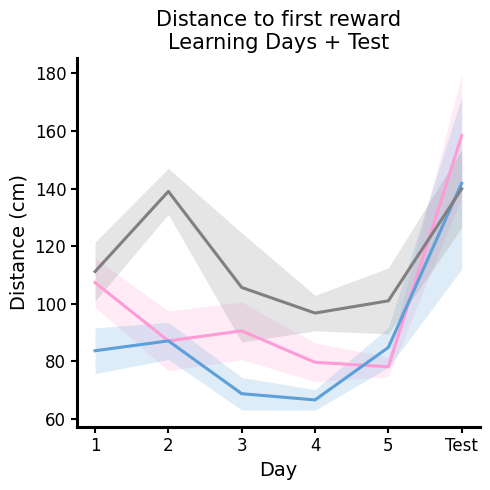


=== CIPL ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


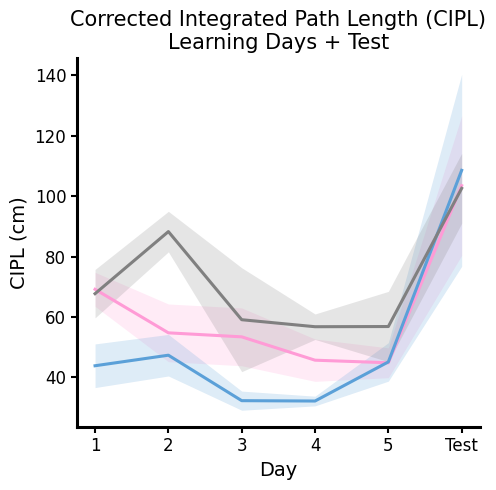


=== path_eff ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


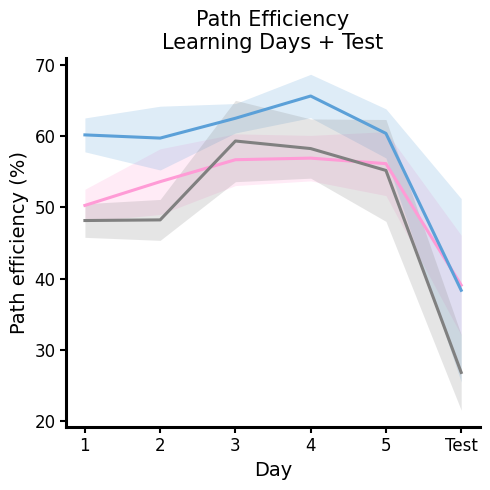

In [11]:
# Distance / CIPL / Path efficiency
# Plot ArchT vs eYFP_ArchT (+/- WT)
# Metrics: dist_to_trigger, CIPL, path_eff

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# OPTIONS for plotting
# ---------------------------------------------------------------------
INCLUDE_WT    = True    # True → include WT, False → only ArchT & eYFP_ArchT
ADD_STAY_TAG  = False   # True → add "(≥2 s stay)" into all titles

# ---------------------------------------------------------------------
# 1. Base filter: usable, not short, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST after last L session → day 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # L1–L5 + Test(6)

# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    """
    meta_group: subset of meta_LT for one genotype
    value_col:  name of column to average (e.g. 'dist_to_trigger', 'CIPL', 'path_eff')
    """
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete days 1–6 for that metric for this animal
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3. Plot helper (ArchT vs eYFP_ArchT (+/- WT))
# ---------------------------------------------------------------------
def plot_metric_for_all_genotypes(meta_LT, value_col, ylabel, title,
                                  include_wt=True):  # NEW ARG
    """
    include_wt = False → only plot ArchT & eYFP_ArchT
    """
    # split by genotype
    meta_ArchT = meta_LT[meta_LT['genotype'] == 'ArchT']
    meta_eYFP  = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']
    meta_WT    = meta_LT[meta_LT['genotype'] == 'WT']

    mat_ArchT, subs_ArchT = build_genotype_matrix(meta_ArchT, value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_WT,    subs_WT    = build_genotype_matrix(meta_WT,    value_col)

    print(f"\n=== {value_col} ===")
    print("ArchT animals plotted:", len(subs_ArchT))
    print("eYFP_ArchT animals plotted:", len(subs_eYFP))
    print("WT animals plotted:", len(subs_WT))

    plt.figure(figsize=(5,5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)   # no WT fallback requested

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        # shaded SEM
        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        # mean curve
        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    # always plot ArchT + eYFP_ArchT
    plot_group(mat_ArchT, subs_ArchT, 'ArchT',      'ArchT')
    plot_group(mat_eYFP,  subs_eYFP,  'eYFP_ArchT', 'eYFP_ArchT')

    # optionally plot WT
    if include_wt:
        plot_group(mat_WT, subs_WT, 'WT', 'WT')

    # axes, style
    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

#    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4. Call for each metric
# ---------------------------------------------------------------------
stay_tag = " (≥2 s stay)" if ADD_STAY_TAG else ""

# a) Distance (stored as dist_to_trigger)
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='dist_to_trigger',
    ylabel='Distance (cm)',
    title=f'Distance to first reward{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

# b) CIPL = L_actual - L_shortest
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='CIPL',
    ylabel='CIPL (cm)',
    title=f'Corrected Integrated Path Length (CIPL){stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

# c) Path efficiency = L_shortest / L_actual * 100
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='path_eff',
    ylabel='Path efficiency (%)',
    title=f'Path Efficiency{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

Test day CIPL per animal:
  ArchT:      n = 6,  animals = [28 29 30 31 32 33]
  eYFP_ArchT: n = 6,   animals = [34 35 36 37 38 39]
  WT:         n = 4,     animals = [24 25 26 27]
ArchT vs eYFP_ArchT: raw p = 0.937
ArchT vs WT: raw p = 0.762
eYFP_ArchT vs WT: raw p = 0.914

FDR-corrected p-values (BH):
  ArchT vs eYFP_ArchT: p_FDR = 0.937
  ArchT vs WT: p_FDR = 0.937
  eYFP_ArchT vs WT: p_FDR = 0.937


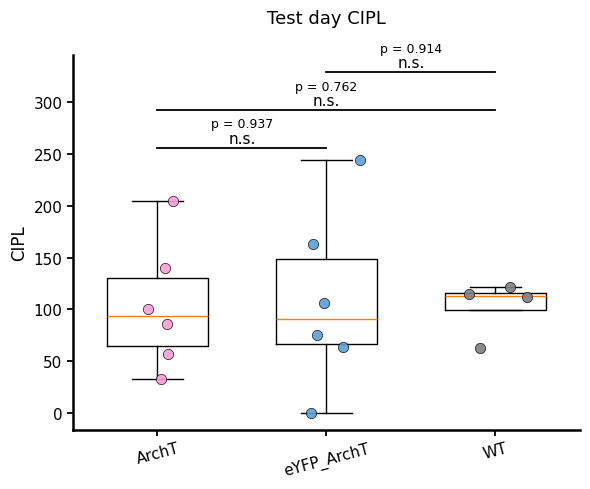

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Try FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR skipped (raw p-values used).")

# ============================================================
# OPTIONS (ArchT / eYFP_ArchT / optional WT)
# ============================================================
INCLUDE_WT   = True    # True → include WT, False → only ArchT & eYFP_ArchT
ADD_2S_TAG   = False   # True → add "(≥2 s stay)" in title

# Which metric to compare (boxplot on TEST day per animal)
METRIC_COL   = 'CIPL'  # or 'dist_to_trigger' or 'path_eff'

# ============================================================
# 1) Build meta_LT with plot_day (L1–5, Test=6)
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[METRIC_COL].notna())
].copy()

meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# Keep only test day
meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()


# ============================================================
# 2) Helper: extract per-animal values on test day
# ============================================================
def get_group_vals(meta_df, genotype, value_col):
    m = meta_df[meta_df['genotype'] == genotype]
    if m.empty:
        return np.array([]), np.array([])
    per_sub = (
        m.groupby('sub')[value_col]
         .mean()
         .astype(float)
    )
    return per_sub.values, per_sub.index.values  # vals, animal IDs


# Base two groups
vals_ArchT, subs_ArchT = get_group_vals(meta_test, 'ArchT',       METRIC_COL)
vals_eYFP,  subs_eYFP  = get_group_vals(meta_test, 'eYFP_ArchT',  METRIC_COL)

print(f"Test day {METRIC_COL} per animal:")
print(f"  ArchT:      n = {len(vals_ArchT)},  animals = {subs_ArchT}")
print(f"  eYFP_ArchT: n = {len(vals_eYFP)},   animals = {subs_eYFP}")

# Optional WT
if INCLUDE_WT:
    vals_WT, subs_WT = get_group_vals(meta_test, 'WT', METRIC_COL)
    print(f"  WT:         n = {len(vals_WT)},     animals = {subs_WT}")


# ============================================================
# 3) Assemble data & group labels depending on options
# ============================================================
if INCLUDE_WT:
    data   = [vals_ArchT, vals_eYFP, vals_WT]
    groups = ["ArchT", "eYFP_ArchT", "WT"]
else:
    data   = [vals_ArchT, vals_eYFP]
    groups = ["ArchT", "eYFP_ArchT"]

positions = np.arange(len(groups))


# ============================================================
# 4) Boxplot + jitter
# ============================================================
def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

fig, ax = plt.subplots(figsize=(6, 5))

# plain boxes (no fliers)
ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=False,
    showfliers=False
)

# jittered points
for i, vals in enumerate(data):
    if len(vals) == 0:
        continue
    x = np.random.normal(positions[i], 0.14, size=len(vals))
    col = get_genotype_color(groups[i])   # expects 'ArchT', 'eYFP_ArchT', 'WT'
    ax.scatter(
        x, vals,
        s=55,
        color=col,
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )


# ============================================================
# 5) Mann–Whitney + FDR (BH) – FDR printed, RAW p on figure
# ============================================================
comparisons = []
comparisons.append(("ArchT vs eYFP_ArchT", 0, 1, vals_ArchT, vals_eYFP))

if INCLUDE_WT:
    comparisons.append(("ArchT vs WT",        0, 2, vals_ArchT, vals_WT))
    comparisons.append(("eYFP_ArchT vs WT",   1, 2, vals_eYFP,  vals_WT))

# raw p-values
p_raw = []
for name, _, _, v1, v2 in comparisons:
    p = mwu(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR for reporting only
if HAS_SM:
    mask = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask.any():
        _, p_corr, _, _ = multipletests(p_raw[mask], alpha=0.05, method='fdr_bh')
        p_adj[mask] = p_corr
    print("\nFDR-corrected p-values (BH):")
    for (name, *_), pF in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {pF:.3g}")
else:
    print("\nUsing raw p-values only (no FDR)\n")

# ---- bars / stars / p USING RAW p-values ----
all_vals = np.concatenate([v for v in data if len(v) > 0]) if any(len(v) > 0 for v in data) else np.array([np.nan])
ymax   = np.nanmax(all_vals)
y_base = ymax * 1.05
y_step = 0.15 * ymax

for (name, i, j, _, _), p_r in zip(comparisons, p_raw):
    if np.isnan(p_r) or not np.isfinite(ymax):
        continue

    y = y_base
    y_base += y_step

    # straight horizontal bar (no dips)
    ax.plot(
        [positions[i], positions[j]],
        [y, y],
        color='k',
        lw=1.3
    )

    # stars
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.02 * ymax,
        p_to_stars(p_r),
        ha='center',
        fontsize=11
    )

    # numeric raw p-value
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.08 * ymax,
        f"p = {p_r:.3g}",
        ha='center',
        fontsize=9
    )


# ============================================================
# 6) Cosmetics + title with optional "(≥2 s stay)"
# ============================================================
ax.set_xticks(positions)
ax.set_xticklabels(groups, fontsize=11, rotation=15)
ax.set_ylabel(f'{METRIC_COL}', fontsize=12)

stay_tag = " (≥2 s stay)" if ADD_2S_TAG else ""
ax.set_title(f"Test day {METRIC_COL}{stay_tag}\n", fontsize=13, pad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', width=1.3, length=4)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

  genotype  total_trial_n   mean_dist     sd_dist   n
0     ChR2              1  157.060611  129.523072  12
1     ChR2              2  278.565502  219.285901  12
2     ChR2              3  142.712539  131.217874  12
3     ChR2              4  197.196475  126.646089  12
4     ChR2              5  235.279692  229.207652  12


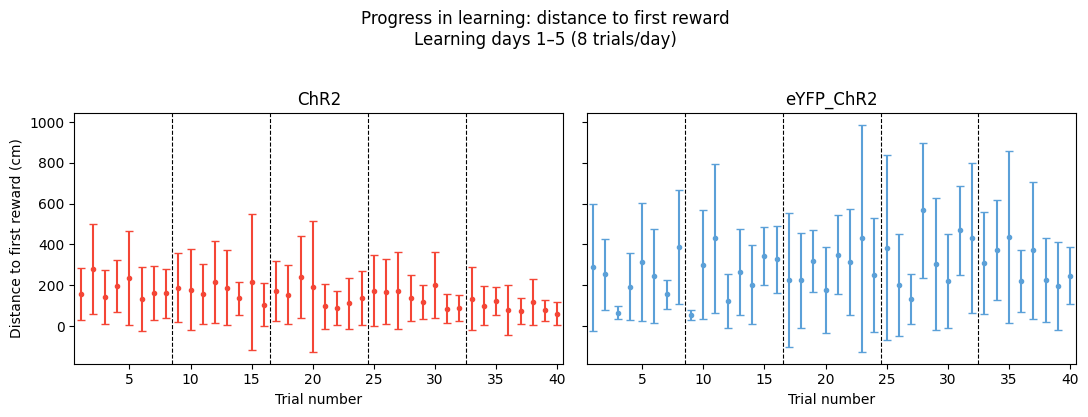

In [10]:
# progress of learning

# ------------------------------------------------------------
# 1) Filter: usable, not short, ChR2/eYFP, LEARNING (L) days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].between(1, 5)) &
    (metadata['dist_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Ensure we have trial_in_day = 1..8
# ------------------------------------------------------------
trials_per_day = 8

candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    # fall back: order within session for each animal
    meta_L = meta_L.sort_values(['sub', 'ses', 'trial_type_day']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, trials_per_day)].copy()

# ------------------------------------------------------------
# 3) Create global trial index = "total_trial_n" (1..40 for 5 days)
# ------------------------------------------------------------
meta_L['total_trial_n'] = (
    (meta_L['trial_type_day'] - 1) * trials_per_day + meta_L['trial_in_day']
).astype(int)

# ------------------------------------------------------------
# 4) Group: mean & SD distance per genotype × total_trial_n
# ------------------------------------------------------------
summary = (
    meta_L
    .groupby(['genotype', 'total_trial_n'])['dist_to_trigger']
    .agg(mean_dist='mean', sd_dist='std', n='size')
    .reset_index()
)

print(summary.head())

# ------------------------------------------------------------
# 5) Plot: error bars (mean ± SD) per trial, faceted by group
# ------------------------------------------------------------
groups = ['ChR2', 'eYFP_ChR2']
colors = {g: get_genotype_color(g) for g in groups}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, g in zip(axes, groups):
    df_g = summary[summary['genotype'] == g].sort_values('total_trial_n')

    x = df_g['total_trial_n'].values
    y = df_g['mean_dist'].values
    sd = df_g['sd_dist'].values

    # vertical error bars only (like your R code)
    ax.errorbar(
        x, y,
        yerr=sd,
        fmt='none',
        ecolor=colors[g],
        elinewidth=1.5,
        capsize=3
    )

    # optional: mean points
    ax.plot(x, y, marker='o', linestyle='none', color=colors[g], markersize=3)

    # vertical dashed lines between learning days (every 8 trials)
    for boundary in range(trials_per_day, trials_per_day * 5, trials_per_day):
        ax.axvline(boundary + 0.5, color='k', linestyle='--', linewidth=0.8)

    ax.set_title(g)
    ax.set_xlabel('Trial number')
    ax.set_xlim(0.5, trials_per_day * 5 + 0.5)

axes[0].set_ylabel('Distance to first reward (cm)')

plt.suptitle('Progress in learning: distance to first reward\nLearning days 1–5 (8 trials/day)', y=1.03, fontsize=12)

plt.tight_layout()
plt.show()

### GDI. plot distance to first reward across days 1–5, plus test day if available


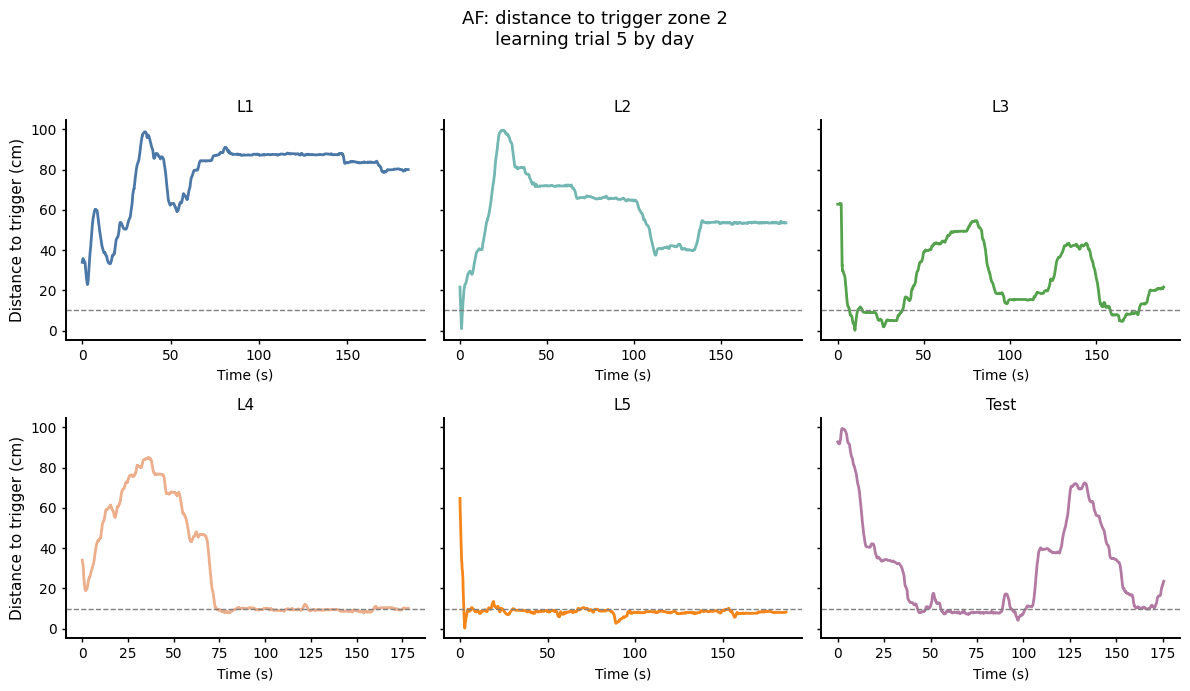

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# OPTIONS
# ============================================================
ANIMAL_ID              = 'AF'              # e.g. 'AB'
TRIGGER_TO_PLOT        = 2                 # 1 or 2
PLOT_MODE              = 'single_trial'    # 'single_trial' or 'mean_all_trials'
LEARNING_TRIAL_TO_PLOT = 5                 # which learning trial to plot (1..8)
INCLUDE_TEST_DAY       = True              # True -> include first T session after learning
N_INTERP_POINTS        = 400               # only used for mean_all_trials. When you use the mean option, the distance values are interpolated between time points for each trial.

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# 1) Filter to one animal, usable=1, L/T only
# ------------------------------------------------------------
mt = metadata[
    (metadata['usable'] == 1) &
    (metadata['id'] == ANIMAL_ID) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

if len(mt) == 0:
    raise ValueError(f'No usable L/T trials found for animal {ANIMAL_ID}')

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
mt['plot_day'] = np.nan

mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1..5
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

if INCLUDE_TEST_DAY:
    L_ses = mt.loc[mt['trial_type'] == 'L', 'ses']
    if len(L_ses) > 0:
        last_L_ses = L_ses.max()
        T_after = mt[(mt['trial_type'] == 'T') & (mt['ses'] > last_L_ses)]
        if len(T_after) > 0:
            first_T_ses = T_after['ses'].min()
            idx = mt.index[
                (mt['trial_type'] == 'T') &
                (mt['ses'] == first_T_ses)
            ]
            mt.loc[idx, 'plot_day'] = 6

plot_days = [1, 2, 3, 4, 5] + ([6] if INCLUDE_TEST_DAY else [])
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Ensure trial_in_day exists
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    sort_cols = [c for c in ['ses', 'trial_type_day', 'trial_id'] if c in mt.columns]
    if len(sort_cols) == 0:
        sort_cols = ['ses']
    mt = mt.sort_values(sort_cols).copy()
    mt['trial_in_day'] = mt.groupby('ses').cumcount() + 1

mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 4) Helper: load one trial trace
# ------------------------------------------------------------
def load_distance_trace(meta_row, trigger_to_plot=1):
    dl = DataLoader(meta_row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        return None, None

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) < trigger_to_plot:
        return None, None

    pos_ = add_dist_to_trigger(position.copy(), triggerLoc)

    dist_col = f'dist_to_trigger_{trigger_to_plot}'
    if dist_col not in pos_.columns:
        return None, None

    # time in seconds from trial start
    t = pos_['t'].values.astype(float)
    t = (t - t[0]) / 1000.0

    # convert to real cm
    d = pos_[dist_col].values.astype(float) * 1.2

    ok = np.isfinite(t) & np.isfinite(d)
    if ok.sum() < 2:
        return None, None

    return t[ok], d[ok]

# ------------------------------------------------------------
# 5) Helper: average traces on common grid
# ------------------------------------------------------------
def average_traces(trace_list, n_points=400):
    trace_list = [(t, d) for (t, d) in trace_list if t is not None and d is not None and len(t) >= 2]
    if len(trace_list) == 0:
        return None, None, None

    max_t = np.nanmax([t[-1] for t, d in trace_list])
    common_t = np.linspace(0, max_t, n_points)

    interp_mat = []
    for t, d in trace_list:
        di = np.interp(common_t, t, d)
        di[common_t > t[-1]] = np.nan
        interp_mat.append(di)

    interp_mat = np.vstack(interp_mat)
    mean_d = np.nanmean(interp_mat, axis=0)
    n_per_t = np.sum(~np.isnan(interp_mat), axis=0)
    sem_d = np.nanstd(interp_mat, axis=0) / np.sqrt(np.maximum(n_per_t, 1))

    return common_t, mean_d, sem_d

# ------------------------------------------------------------
# 6) Make 6 little figures (subplots)
# ------------------------------------------------------------
day_labels = {1:'L1', 2:'L2', 3:'L3', 4:'L4', 5:'L5', 6:'Test'}
day_colors = {
    1:'#4C78A8',
    2:'#72B7B2',
    3:'#54A24B',
    4:'#ECAE8B',
    5:'#F58518',
    6:'#B279A2'
}

n_days = len(plot_days)
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, day in zip(axes, plot_days):
    md = mt[mt['plot_day'] == day].copy()
    md = md.sort_values('trial_in_day')

    if len(md) == 0:
        ax.set_title(day_labels[day])
        ax.axis('off')
        continue

    # ---- choose which trial(s) to use ----
    if PLOT_MODE == 'single_trial':
        if day <= 5:
            # learning days: use chosen trial number
            md_use = md[md['trial_in_day'] == LEARNING_TRIAL_TO_PLOT].copy()
        else:
            # test day: still use first/only trial
            md_use = md.iloc[[0]].copy()

    elif PLOT_MODE == 'mean_all_trials':
        md_use = md.copy()

    else:
        raise ValueError("PLOT_MODE must be 'single_trial' or 'mean_all_trials'")

    traces = []
    for _, row in md_use.iterrows():
        t, d = load_distance_trace(row, trigger_to_plot=TRIGGER_TO_PLOT)
        if t is not None:
            traces.append((t, d))

    if len(traces) == 0:
        ax.set_title(day_labels[day])
        ax.axis('off')
        continue

    if PLOT_MODE == 'single_trial':
        t, d = traces[0]
        ax.plot(
            t, d,
            color=day_colors[day],
            linewidth=2.0
        )
    else:
        common_t, mean_d, sem_d = average_traces(traces, n_points=N_INTERP_POINTS)
        ax.fill_between(
            common_t,
            mean_d - sem_d,
            mean_d + sem_d,
            color=day_colors[day],
            alpha=0.18,
            linewidth=0
        )
        ax.plot(
            common_t, mean_d,
            color=day_colors[day],
            linewidth=2.2
        )

    # real trigger boundary
    ax.axhline(10, color='0.5', linestyle='--', linewidth=1.0)

    ax.set_title(day_labels[day], fontsize=11)
    ax.set_xlabel('Time (s)', fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

# hide unused panels if fewer than 6
for j in range(len(plot_days), len(axes)):
    axes[j].axis('off')

axes[0].set_ylabel('Distance to trigger (cm)', fontsize=11)
axes[3].set_ylabel('Distance to trigger (cm)', fontsize=11)

if PLOT_MODE == 'single_trial':
    mode_text = f'learning trial {LEARNING_TRIAL_TO_PLOT}'
else:
    mode_text = 'mean of all trials'

fig.suptitle(
    f'{ANIMAL_ID}: distance to trigger zone {TRIGGER_TO_PLOT}\n{mode_text} by day',
    fontsize=13,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [337]:
# ============================================================
# 1) Compute GDI and store into metadata
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# OPTIONS
# ============================================================
TRIGGER_TO_USE = 2

BOARD_SCALE_TO_REAL = 1.2

REWARD_RADIUS_REAL_CM = 10.0
REWARD_RADIUS_ANALYSIS = REWARD_RADIUS_REAL_CM / BOARD_SCALE_TO_REAL

SPEED_THRESH_REAL = 1.0
SPEED_THRESH_ANALYSIS = SPEED_THRESH_REAL / BOARD_SCALE_TO_REAL

MIN_APPROACH_BOUT_S = 0.0

REQUIRE_MIN_REWARD_STAY = False
MIN_REWARD_STAY_MS = 2000

SMOOTH_WIN_S = 0.25

USE_NEGATIVE_SLOPE_START = True
REQUIRE_DIRECT_NEGATIVE_TO_ENTRY = True
# ✅ if REQUIRE_DIRECT_NEGATIVE_TO_ENTRY = True, ONLY duration-based tolerance for positive slope runs, no distance-based tolerance
MAX_POSITIVE_SLOPE_GAP_S = 0.15   # ← key parameter

# output columns
GDI_COL = f'GDI_trigger{TRIGGER_TO_USE}'
APPROACH_TIME_COL = f'approach_time_trigger{TRIGGER_TO_USE}'
ACTIVE_OUTSIDE_TIME_COL = f'active_outside_time_trigger{TRIGGER_TO_USE}'
N_BOUTS_COL = f'n_approach_bouts_trigger{TRIGGER_TO_USE}'

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata[GDI_COL] = np.nan
metadata[APPROACH_TIME_COL] = np.nan
metadata[ACTIVE_OUTSIDE_TIME_COL] = np.nan
metadata[N_BOUTS_COL] = np.nan

# ============================================================
# Helpers
# ============================================================
def moving_average(x, win_pts):
    if win_pts <= 1:
        return x.copy()
    kernel = np.ones(win_pts) / win_pts
    return np.convolve(x, kernel, mode='same')

def contiguous_segments(mask):
    diff = np.diff(np.r_[False, mask, False].astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return list(zip(starts, ends))

def load_trial_distance_and_speed(meta_row, trigger_to_use):
    dl = DataLoader(meta_row)

    position = dl.get_data('position')
    triggerLoc = dl.get_data('triggerLoc')

    if position is None or triggerLoc is None:
        return None

    pos = add_speed(position.copy())
    pos = add_dist_to_trigger(pos, triggerLoc)

    dist_col = f'dist_to_trigger_{trigger_to_use}'
    if dist_col not in pos.columns:
        return None

    t = (pos['t'].values - pos['t'].values[0]) / 1000.0
    d = pos[dist_col].values.astype(float)
    speed = pos['speed'].values.astype(float)

    ok = np.isfinite(t) & np.isfinite(d) & np.isfinite(speed)
    if ok.sum() < 2:
        return None

    return t[ok], d[ok], speed[ok]

# ============================================================
# CORE FUNCTION
# ============================================================
def compute_gdi_one_trial(
    t_s,
    d,
    speed,
    reward_radius,
    speed_thresh,
    min_approach_bout_s,
    require_min_reward_stay,
    min_reward_stay_s,
    use_negative_slope_start,
    smooth_win_s,
    require_direct_negative_to_entry,
    max_positive_gap_s,
):
    if len(t_s) < 2:
        return np.nan, np.nan, np.nan, 0

    dt = np.nanmedian(np.diff(t_s))
    if dt <= 0:
        return np.nan, np.nan, np.nan, 0

    outside = d > reward_radius
    active = speed > speed_thresh

    active_outside = outside & active
    active_outside_time = np.sum(active_outside) * dt

    if active_outside_time <= 0:
        return np.nan, 0, 0, 0

    inside = d <= reward_radius
    visits = contiguous_segments(inside)

    # smooth + slope
    win_pts = max(1, int(round(smooth_win_s / dt)))
    d_smooth = moving_average(d, win_pts)
    slope = np.gradient(d_smooth, t_s)

    min_bout_pts = max(1, int(round(min_approach_bout_s / dt)))
    min_stay_pts = max(1, int(round(min_reward_stay_s / dt)))
    max_gap_pts = int(round(max_positive_gap_s / dt))

    approach_mask = np.zeros(len(t_s), bool)
    n_bouts = 0

    for s_in, e_in in visits:

        if require_min_reward_stay and (e_in - s_in + 1 < min_stay_pts):
            continue

        j = s_in - 1
        if j < 0 or not outside[j]:
            continue

        e0 = j
        while j >= 0 and outside[j] and active[j]:
            j -= 1
        s0 = j + 1

        if s0 > e0:
            continue

        # define start
        if use_negative_slope_start:
            neg = slope[s0:e0+1] < 0
            if not np.any(neg):
                continue
            s_bout = s0 + np.where(neg)[0][0]
        else:
            s_bout = s0

        e_bout = e0

        if require_direct_negative_to_entry:
            bad = slope[s_bout:e_bout+1] > 0
            if np.any(bad):
                bad_runs = contiguous_segments(bad)
                if any((e - s + 1) > max_gap_pts for s, e in bad_runs):
                    continue

        if (e_bout - s_bout + 1) < min_bout_pts:
            continue

        approach_mask[s_bout:e_bout+1] = True
        n_bouts += 1

    approach_time = np.sum(approach_mask) * dt
    gdi = approach_time / active_outside_time if active_outside_time > 0 else np.nan

    return gdi, approach_time, active_outside_time, n_bouts

# ============================================================
# MAIN LOOP
# ============================================================
for i in tqdm(range(len(metadata))):

    out = load_trial_distance_and_speed(metadata.iloc[i], TRIGGER_TO_USE)
    if out is None:
        continue

    t, d, speed = out

    gdi, at, tot, nb = compute_gdi_one_trial(
        t, d, speed,
        REWARD_RADIUS_ANALYSIS,
        SPEED_THRESH_ANALYSIS,
        MIN_APPROACH_BOUT_S,
        REQUIRE_MIN_REWARD_STAY,
        MIN_REWARD_STAY_MS / 1000.0,
        USE_NEGATIVE_SLOPE_START,
        SMOOTH_WIN_S,
        REQUIRE_DIRECT_NEGATIVE_TO_ENTRY,
        MAX_POSITIVE_SLOPE_GAP_S,
    )

    metadata.at[i, GDI_COL] = gdi
    metadata.at[i, APPROACH_TIME_COL] = at
    metadata.at[i, ACTIVE_OUTSIDE_TIME_COL] = tot
    metadata.at[i, N_BOUTS_COL] = nb

metadata[[GDI_COL, APPROACH_TIME_COL, ACTIVE_OUTSIDE_TIME_COL, N_BOUTS_COL]].head()

 11%|█         | 710/6620 [00:08<01:06, 88.47it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1177/6620 [00:12<00:57, 95.48it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 40%|███▉      | 2620/6620 [00:24<00:23, 169.04it/s]

...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6489/6620 [00:56<00:01, 111.38it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6620/6620 [00:57<00:00, 115.40it/s]


,GDI_trigger2,approach_time_trigger2,active_outside_time_trigger2,n_approach_bouts_trigger2
0,0.010411,2.324,223.216,2.0
1,0.017723,2.667,150.486,3.0
2,0.026597,3.179,119.527,1.0
3,0.014040,2.550,181.625,1.0
4,0.014552,1.926,132.354,2.0



Groups used for plotting: ['short_1', 'short_2']
Original genotypes loaded: ['ChR2_short']
Custom IDs loaded: ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']

Custom groups:
  short_1: ['AI', 'AJ', 'AL'], colour = get_genotype_color('short_1')
  short_2: ['V1', 'V2', 'V3', 'V4', 'V5'], colour = get_genotype_color('short_2')

Animals plotted:
  Short 1 (short_1): n = 3, ids = ['AI (Short 1)', 'AJ (Short 1)', 'AL (Short 1)']
  Short 2 (short_2): n = 5, ids = ['V1 (Short 2)', 'V2 (Short 2)', 'V3 (Short 2)', 'V4 (Short 2)', 'V5 (Short 2)']

Rows after filtering:
    sub  id genotype_original genotype trial_type  trial_type_day  ses  \
0    13  AI        ChR2_short  short_1          L               1    4   
1    13  AI        ChR2_short  short_1          L               2    5   
2    13  AI        ChR2_short  short_1          L               3    6   
3    13  AI        ChR2_short  short_1          L               4    7   
4    13  AI        ChR2_short  short_1          L              

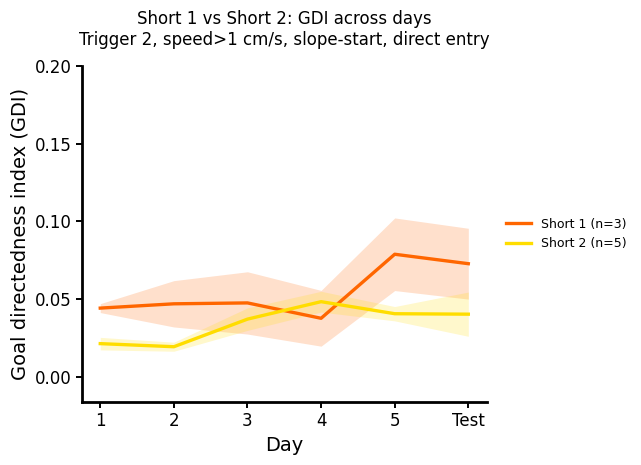


CHECK: exact values from line-plot matrix

Short 1 (short_1)
  AI (Short 1): L1-L5 mean = 0.0755, Test = 0.1165, full row = [0.0471 0.0724 0.0816 0.0674 0.109  0.1165]
  AJ (Short 1): L1-L5 mean = 0.0238, Test = 0.0401, full row = [0.0472 0.0209 0.0124 0.0056 0.033  0.0401]
  AL (Short 1): L1-L5 mean = 0.0541, Test = 0.0619, full row = [0.0386 0.0479 0.0489 0.0403 0.0946 0.0619]

Short 2 (short_2)
  V1 (Short 2): L1-L5 mean = 0.0297, Test = 0.0821, full row = [0.0211 0.0217 0.0201 0.048  0.0374 0.0821]
  V2 (Short 2): L1-L5 mean = 0.0479, Test = 0.0397, full row = [0.0289 0.028  0.0562 0.0694 0.0571 0.0397]
  V3 (Short 2): L1-L5 mean = 0.0305, Test = 0.0208, full row = [0.0238 0.021  0.049  0.0286 0.0303 0.0208]
  V4 (Short 2): L1-L5 mean = 0.0292, Test = 0.0007, full row = [0.0273 0.0107 0.0213 0.043  0.0435 0.0007]
  V5 (Short 2): L1-L5 mean = 0.0301, Test = 0.0588, full row = [0.0063 0.0161 0.0395 0.0532 0.0353 0.0588]

GDI boxplot from line-plot matrix: Learning days 1-5 average
A

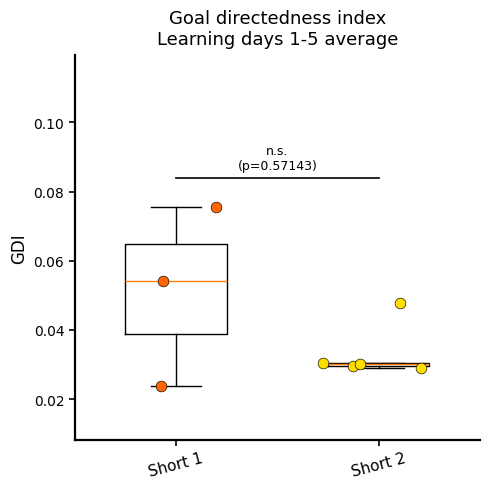


GDI boxplot from line-plot matrix: Test day
Animals included:
  Short 1 (short_1): n = 3, ids = ['AI (Short 1)', 'AJ (Short 1)', 'AL (Short 1)']
  Short 2 (short_2): n = 5, ids = ['V1 (Short 2)', 'V2 (Short 2)', 'V3 (Short 2)', 'V4 (Short 2)', 'V5 (Short 2)']

Per-animal values:
     group  sub            id     value
0  short_1   13  AI (Short 1)  0.116521
1  short_1   14  AJ (Short 1)  0.040072
2  short_1   15  AL (Short 1)  0.061885
3  short_2   82  V1 (Short 2)  0.082069
4  short_2   83  V2 (Short 2)  0.039712
5  short_2   84  V3 (Short 2)  0.020761
6  short_2   85  V4 (Short 2)  0.000692
7  short_2   86  V5 (Short 2)  0.058824

Mann–Whitney U tests:
  Short 1 vs Short 2: n=3 vs 5, mean=0.073 vs 0.040, median=0.062 vs 0.040, U=12.0, rank-biserial=0.600, p=0.25000


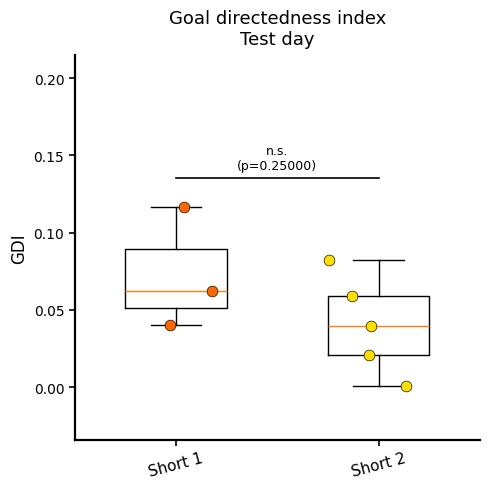

In [338]:
# ============================================================
# Plot GDI across L1-L5 + Test + boxplots from same matrices
#
# Adds pooled group:
#   'Control' = eYFP_ChR2 + NAc_control + CA1_control
#
# Adds custom ID-based groups:
#   short_1 = AI, AJ, AL
#   short_2 = V1, V2, V3, V4, V5
#
# Produces:
#   1) Line plot across L1-L5 + Test
#   2) Boxplot: learning days 1-5 average
#   3) Boxplot: test day
#
# Boxplots are made from the SAME animal x day matrix
# used for the line plot.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
# GROUPS = ['ChR2', 'ChR2_short', 'eYFP_ChR2']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA3']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['eYFP_ChR2', 'CA1_control', 'NAc_control']
# GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']
# GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']
GROUPS = ['short_1', 'short_2']

# ------------------------------------------------------------
# Custom ID-based groups
# ------------------------------------------------------------
CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

# Usually these animals are ChR2_short.
# If you want to load only by ID regardless of genotype, set values to None.
CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

# These original genotypes will be pooled into genotype == 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
}

EXCLUDE_ID = ['AS', 'AN']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False

# Line plot options
SHOW_ANIMAL_IDS_DAY1 = False
DAY1_LABEL_X_OFFSET = 0.00
DAY1_LABEL_Y_OFFSET = 0.00
DAY1_LABEL_FONTSIZE = 8

PLOT_INDIVIDUAL = False
PLOT_GROUP_MEAN = True
SHOW_SEM_SHADING = True
PLOT_SEM_ERRORBAR = False

# Line plot y-axis options
YMIN = None
YMAX = 0.2
Y_BOTTOM_PAD_FRAC = 0.08
Y_TICK_STEP = 0.05

# Boxplot options
SHOW_ANIMAL_IDS = False
COMPARISONS = 'all'
# COMPARISONS = [('short_1', 'short_2')]

JITTER = 0.12
DOT_SIZE = 60

DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

P_DECIMALS = 5

BOX_YMIN = None     # e.g. 0
BOX_YMAX = None     # e.g. 0.2
BOX_Y_PAD_FRAC = 0.30

# p-value line spacing for boxplots
P_LINE_START_FRAC = 0.16
P_LINE_STEP_FRAC = 0.34
P_TEXT_OFFSET_FRAC = 0.035
P_TOP_PAD_FRAC = 0.35

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1


# ============================================================
# Helper: custom groups
# ============================================================

def is_custom_group(g):
    return g in CUSTOM_GROUP_ID_MAP


def get_plot_color(g):
    """
    Uses the same colour method as the rest of your plotting code.

    Make sure get_genotype_color() contains colours for:
      'short_1'
      'short_2'
    """
    return get_genotype_color(g)


def add_analysis_group(meta_df):
    """
    Adds analysis_group.

    Default:
      analysis_group = genotype

    Custom ID groups:
      animals with id in CUSTOM_GROUP_ID_MAP are assigned to
      short_1, short_2, etc.
    """
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in CUSTOM_GROUP_ID_MAP.items():
        ids_str = [str(x) for x in ids]
        meta_df.loc[id_as_str.isin(ids_str), 'analysis_group'] = group_name

    return meta_df


# ============================================================
# General helpers
# ============================================================

def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals,
    and custom group visible for short_1 / short_2.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])
        if analysis_group in CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def build_genotype_matrix(meta_group, value_col):
    rows = []
    subs = []
    ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)
        ids.append(get_animal_label(ms, sub))

    if len(rows) == 0:
        return None, [], []

    return np.vstack(rows), subs, ids


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.4)


def style_boxplot(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.6)
    ax.spines['left'].set_linewidth(1.6)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def apply_y_axis(ax, ymax_candidates):
    if YMAX is not None:
        ymax = YMAX
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    if Y_TICK_STEP is not None:
        yticks = np.arange(0, ymax + Y_TICK_STEP, Y_TICK_STEP)
        ax.set_yticks(yticks)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs
    return comparisons


# ============================================================
# 1) Filter metadata
# ============================================================

# If GROUPS contains 'Control', load the original component genotypes.
# If GROUPS contains custom groups, load the relevant IDs and source genotype.
groups_to_load = []
custom_ids_to_load = []

for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

    elif g in CUSTOM_GROUP_ID_MAP:
        custom_ids_to_load.extend(CUSTOM_GROUP_ID_MAP[g])

        genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(g, None)
        if genotype_source is not None:
            groups_to_load.append(genotype_source)

    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))
custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

base_mask = (
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[GDI_COL].notna()) &
    (np.isfinite(metadata[GDI_COL]))
)

if len(groups_to_load) > 0:
    genotype_mask = metadata['genotype'].isin(groups_to_load)
else:
    genotype_mask = False

if len(custom_ids_to_load) > 0 and 'id' in metadata.columns:
    custom_id_mask = metadata['id'].astype(str).isin(custom_ids_to_load)
else:
    custom_id_mask = False

meta_LT = metadata[
    base_mask &
    (genotype_mask | custom_id_mask)
].copy()

# Store original genotype before pooling/custom reassignment
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool NAc_control + CA1_control + eYFP_ChR2 into one displayed/statistical group: Control
if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

# Add custom analysis group
meta_LT = add_analysis_group(meta_LT)

# Use analysis_group as active plotting/statistical group
meta_LT['genotype'] = meta_LT['analysis_group']

# Keep only requested displayed groups
meta_LT = meta_LT[meta_LT['genotype'].isin(GROUPS)].copy()

# Do not accidentally exclude custom animals if their IDs are in EXCLUDE_ID
exclude_ids_effective = [
    x for x in EXCLUDE_ID
    if str(x) not in custom_ids_to_load
]

if len(exclude_ids_effective) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()


# ============================================================
# 2) Assign plot_day: L1-L5 + first post-learning T = Test day 6
# ============================================================

meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()


# ============================================================
# 3) Build matrices
# ============================================================

group_data = {}

print("\nGroups used for plotting:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
print("Custom IDs loaded:", custom_ids_to_load)

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nCustom groups:")
for g, ids in CUSTOM_GROUP_ID_MAP.items():
    if g in GROUPS:
        print(f"  {g}: {ids}, colour = get_genotype_color('{g}')")

print("\nAnimals plotted:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, GDI_COL)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

print("\nRows after filtering:")
cols_to_print = ['sub']

if 'id' in meta_LT.columns:
    cols_to_print.append('id')

if 'genotype_original' in meta_LT.columns:
    cols_to_print.append('genotype_original')

cols_to_print += ['genotype', 'trial_type', 'trial_type_day', 'ses', 'plot_day']

print(
    meta_LT[cols_to_print]
    .drop_duplicates()
    .sort_values(cols_to_print)
    .reset_index(drop=True)
)


# ============================================================
# 4) Line plot
# ============================================================

def plot_group(ax, mat, subs, ids, genotype_key, label):
    if mat is None or len(subs) == 0:
        return None

    base_col = get_plot_color(genotype_key)

    # individual animals
    if PLOT_INDIVIDUAL:
        for i, row in enumerate(mat):
            ax.plot(
                x_vals,
                row,
                '-',
                color=base_col,
                alpha=0.15,
                linewidth=1.0,
                zorder=1
            )

            if SHOW_ANIMAL_IDS_DAY1:
                ax.text(
                    x_vals[0] + DAY1_LABEL_X_OFFSET,
                    row[0] + DAY1_LABEL_Y_OFFSET,
                    ids[i],
                    fontsize=DAY1_LABEL_FONTSIZE,
                    alpha=0.8,
                    ha='right',
                    va='center',
                    color=base_col
                )

    # group mean ± SEM
    if PLOT_GROUP_MEAN:
        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=base_col,
                alpha=0.20,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=base_col,
            linewidth=2.4,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if PLOT_SEM_ERRORBAR:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=base_col,
                elinewidth=1.3,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        return np.nanmax(mean_ + sem_)

    return None


fig, ax = plt.subplots(figsize=(8, 5))

ymax_candidates = []

for g in GROUPS:
    ymax_g = plot_group(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        group_data[g]['ids'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

    if ymax_g is not None and np.isfinite(ymax_g):
        ymax_candidates.append(ymax_g)

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Goal directedness index (GDI)', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax)

title_suffix = f'Trigger {TRIGGER_TO_USE}, speed>{SPEED_THRESH_REAL:g} cm/s'

if REQUIRE_MIN_REWARD_STAY:
    title_suffix += ', reward stay ≥2 s'

if USE_NEGATIVE_SLOPE_START:
    title_suffix += ', slope-start'

if REQUIRE_DIRECT_NEGATIVE_TO_ENTRY:
    title_suffix += ', direct entry'

group_title = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])

ax.set_title(
    f'{group_title}: GDI across days\n{title_suffix}',
    fontsize=12,
    pad=15
)

apply_y_axis(ax, ymax_candidates)

handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend(
        frameon=False,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


# ============================================================
# 5) Boxplots from SAME matrices used in line plot
# ============================================================

print("\nCHECK: exact values from line-plot matrix")
for g in GROUPS:
    mat = group_data[g]['mat']
    ids = group_data[g]['ids']

    if mat is None:
        print(f"{DISPLAY_NAME.get(g, g)} ({g}): mat is None")
        continue

    print(f"\n{DISPLAY_NAME.get(g, g)} ({g})")
    for animal_id, row in zip(ids, mat):
        learning_mean = np.nanmean(row[0:5])
        test_value = row[5]
        print(
            f"  {animal_id}: "
            f"L1-L5 mean = {learning_mean:.4f}, "
            f"Test = {test_value:.4f}, "
            f"full row = {np.round(row, 4)}"
        )


def values_from_lineplot_matrix(g, mode):
    """
    Uses the exact same matrix from the line plot.

    mode:
      'learning_mean' -> mean of days 1-5 = mat[:, 0:5]
      'test'          -> test day = mat[:, 5]
    """
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']
    ids = group_data[g]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            value = np.nanmean(row[0:5])
        elif mode == 'test':
            value = row[5]
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value': float(value)
        })

    return pd.DataFrame(rows)


def plot_gdi_boxplot_from_matrix(mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for g in GROUPS:
        df_g = values_from_lineplot_matrix(g, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value'].values.astype(float))

    print("\n============================================================")
    print(f"GDI boxplot from line-plot matrix: {title_suffix}")
    print("Animals included:")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    print("\nPer-animal values:")
    meta_animal = pd.concat(
        [
            group_dfs[g].assign(group=g)
            for g in GROUPS
            if len(group_dfs[g]) > 0
        ],
        ignore_index=True
    ) if any(len(group_dfs[g]) > 0 for g in GROUPS) else pd.DataFrame()

    if len(meta_animal) > 0:
        print(meta_animal[['group', 'sub', 'id', 'value']])
    else:
        print("No data.")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(5, 1.35 * len(GROUPS)), 5))

    ax.boxplot(
        vals_groups,
        positions=np.arange(len(GROUPS)),
        widths=0.50,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = vals_groups[i]

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(g),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_dfs[g]['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Stats
    # --------------------------------------------------------
    comparisons_to_run = get_comparisons(GROUPS, COMPARISONS)
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in comparisons_to_run:
        vals1 = group_dfs[g1]['value'].values.astype(float)
        vals2 = group_dfs[g2]['value'].values.astype(float)

        if len(vals1) > 0 and len(vals2) > 0:
            stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
        else:
            stat, p = np.nan, np.nan

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.3f} vs {np.nanmean(vals2):.3f}, "
                f"median={np.nanmedian(vals1):.3f} vs {np.nanmedian(vals2):.3f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )

            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

        else:
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"p = NaN"
            )

    # --------------------------------------------------------
    # Significance bars
    # --------------------------------------------------------
    nonempty_vals = [v for v in vals_groups if len(v) > 0]

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        ymax_data = np.nanmax(all_vals)
        ymin_data = np.nanmin(all_vals)

        yrng = ymax_data - ymin_data
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax_data), 0.1)

        current_y = ymax_data + P_LINE_START_FRAC * yrng
        y_step = P_LINE_STEP_FRAC * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2.0

            ax.plot(
                [x1, x2],
                [current_y, current_y],
                color='black',
                linewidth=1.2
            )

            ax.text(
                x_mid,
                current_y + P_TEXT_OFFSET_FRAC * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        if BOX_YMIN is None:
            ymin = ymin_data - BOX_Y_PAD_FRAC * yrng
        else:
            ymin = BOX_YMIN

        if BOX_YMAX is None:
            ymax = current_y + P_TOP_PAD_FRAC * yrng
        else:
            ymax = BOX_YMAX

        ax.set_ylim(ymin, ymax)

    # --------------------------------------------------------
    # Style
    # --------------------------------------------------------
    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel('GDI', fontsize=12)

    ax.set_title(
        f'Goal directedness index\n{title_suffix}',
        fontsize=13,
        pad=8
    )

    style_boxplot(ax)

    plt.tight_layout()
    plt.show()


# ============================================================
# 6) Produce boxplots
# ============================================================

plot_gdi_boxplot_from_matrix(
    mode='learning_mean',
    title_suffix='Learning days 1-5 average'
)

plot_gdi_boxplot_from_matrix(
    mode='test',
    title_suffix='Test day'
)

Day 1 vs Day 5: n = 12 animals
Day 1 vs Test: n = 12 animals
Wilcoxon Day1 vs Day5: p = 0.000488
Wilcoxon Day1 vs Test: p = 0.0269


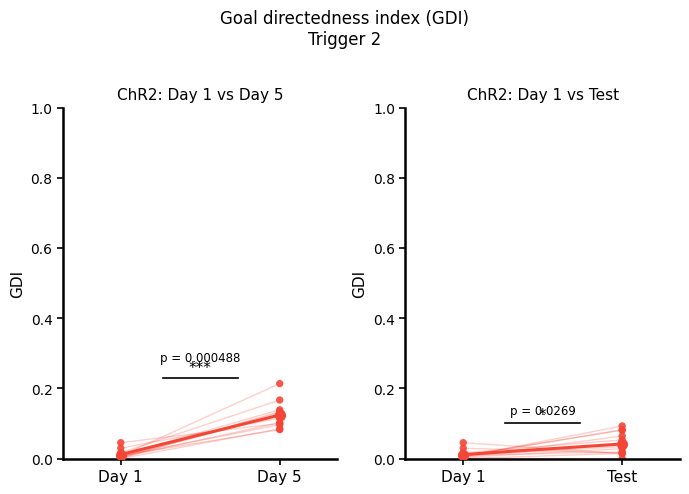

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ============================================================
# Plot 2: paired GDI comparisons
# ============================================================

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[GDI_COL].notna())
].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[(~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# Per-subject day mean GDI
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    md = meta_g[meta_g['plot_day'] == day].copy()
    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'mean_val'])

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        rows.append({
            'sub': sub,
            'mean_val': np.nanmean(ms[value_col].values.astype(float))
        })
    return pd.DataFrame(rows)

d1 = per_subject_day_mean(meta_LT, 1, GDI_COL).rename(columns={'mean_val': 'day1'})
d5 = per_subject_day_mean(meta_LT, 5, GDI_COL).rename(columns={'mean_val': 'day5'})
dt = per_subject_day_mean(meta_LT, 6, GDI_COL).rename(columns={'mean_val': 'test'})

pair_15 = d1.merge(d5, on='sub', how='inner').dropna().sort_values('sub').reset_index(drop=True)
pair_1t = d1.merge(dt, on='sub', how='inner').dropna().sort_values('sub').reset_index(drop=True)

print(f"Day 1 vs Day 5: n = {len(pair_15)} animals")
print(f"Day 1 vs Test: n = {len(pair_1t)} animals")

# ------------------------------------------------------------
# Stats
# ------------------------------------------------------------
def run_wilcoxon(a, b):
    if len(a) == 0:
        return np.nan, np.nan
    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, np.nan
    return stat, p

stat_15, p_15 = run_wilcoxon(pair_15['day1'].values.astype(float), pair_15['day5'].values.astype(float))
stat_1t, p_1t = run_wilcoxon(pair_1t['day1'].values.astype(float), pair_1t['test'].values.astype(float))

print(f"Wilcoxon Day1 vs Day5: p = {p_15:.3g}" if np.isfinite(p_15) else "Wilcoxon Day1 vs Day5: p = NaN")
print(f"Wilcoxon Day1 vs Test: p = {p_1t:.3g}" if np.isfinite(p_1t) else "Wilcoxon Day1 vs Test: p = NaN")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)

def draw_paired_panel(ax, df_pair, col1, col2, label1, label2, pval, title):
    x1, x2 = 0.00, 0.55

    y1 = df_pair[col1].values.astype(float)
    y2 = df_pair[col2].values.astype(float)

    # individual animals
    for _, row in df_pair.iterrows():
        ax.plot(
            [x1, x2],
            [row[col1], row[col2]],
            color=get_genotype_color('ChR2'),
            linewidth=1.0,
            alpha=0.25,
            zorder=1
        )
        ax.scatter(
            [x1, x2],
            [row[col1], row[col2]],
            s=28,
            color=get_genotype_color('ChR2'),
            edgecolor='none',
            alpha=0.9,
            zorder=2
        )

    # mean ± SEM
    def mean_sem(x):
        x = np.asarray(x, float)
        if len(x) == 0:
            return np.nan, np.nan
        if len(x) == 1:
            return x[0], 0.0
        return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))

    m1, s1 = mean_sem(y1)
    m2, s2 = mean_sem(y2)

    ax.plot([x1, x2], [m1, m2], '-', color=get_genotype_color('ChR2'), linewidth=2.2, zorder=3)
    ax.errorbar(x1, m1, yerr=s1, fmt='o', color=get_genotype_color('ChR2'), markersize=7, capsize=3, linewidth=1.4, zorder=4)
    ax.errorbar(x2, m2, yerr=s2, fmt='o', color=get_genotype_color('ChR2'), markersize=7, capsize=3, linewidth=1.4, zorder=4)

    ymax = np.nanmax(np.r_[y1, y2]) if len(df_pair) > 0 else 1
    yline = ymax + 0.08 * max(ymax, 0.1)
    ystar = ymax + 0.11 * max(ymax, 0.1)
    yp = ymax + 0.25 * max(ymax, 0.1)

    xmid = (x1 + x2) / 2
    half_len = 0.13
    ax.plot([xmid - half_len, xmid + half_len], [yline, yline], color='k', lw=1.2, zorder=5)
    ax.text(xmid, ystar, p_to_stars(pval), ha='center', va='bottom', fontsize=11, zorder=6)
    ax.text(xmid, yp, f'p = {pval:.3g}' if np.isfinite(pval) else 'p = NaN',
            ha='center', va='bottom', fontsize=8.5, zorder=6)

    ax.set_xticks([x1, x2])
    ax.set_xticklabels([label1, label2], fontsize=11)
    ax.set_ylabel('GDI', fontsize=11)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlim(-0.20, 0.75)
    ax.set_ylim(0, max(1.0, yp + 0.05))
    style_nature(ax)

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7.0, 4.8), sharey=False)

draw_paired_panel(
    axes[0],
    pair_15,
    'day1', 'day5',
    'Day 1', 'Day 5',
    p_15,
    'ChR2: Day 1 vs Day 5'
)

draw_paired_panel(
    axes[1],
    pair_1t,
    'day1', 'test',
    'Day 1', 'Test',
    p_1t,
    'ChR2: Day 1 vs Test'
)

fig.suptitle(
    f'Goal directedness index (GDI)\nTrigger {TRIGGER_TO_USE}',
    fontsize=12,
    y=1.02
)
plt.tight_layout()
plt.show()

In [51]:
# Compute toward fraction and store into metadata
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# OPTIONS
# ============================================================
TRIGGER_TO_USE = 2

BOARD_SCALE_TO_REAL = 1.2

# thresholds in analysis-space
REWARD_RADIUS_REAL_CM = 10.0
REWARD_RADIUS_ANALYSIS = REWARD_RADIUS_REAL_CM / BOARD_SCALE_TO_REAL

SPEED_THRESH_REAL = 1.0
SPEED_THRESH_ANALYSIS = SPEED_THRESH_REAL / BOARD_SCALE_TO_REAL

# If True:
#   only count active outside-zone periods that directly lead into reward entry
# If False:
#   count all active outside-zone time in the whole trial
REQUIRE_REWARD_ENTRY_FOR_FRACTION = False

# If reward-entry restriction is on, optionally require >= 2 s stay in reward zone
REQUIRE_MIN_REWARD_STAY = False
MIN_REWARD_STAY_MS = 2000

# smooth distance before computing slope sign
SMOOTH_WIN_S = 0.25

# ignore tiny near-zero slopes
SLOPE_EPS_ANALYSIS = 1e-12

# output columns
TOWARD_TIME_COL = f'toward_time_trigger{TRIGGER_TO_USE}'
AWAY_TIME_COL = f'away_time_trigger{TRIGGER_TO_USE}'
TOWARD_FRACTION_COL = f'toward_fraction_trigger{TRIGGER_TO_USE}'
N_ENTRY_PERIODS_COL = f'n_entry_periods_trigger{TRIGGER_TO_USE}'

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata[TOWARD_TIME_COL] = np.nan
metadata[AWAY_TIME_COL] = np.nan
metadata[TOWARD_FRACTION_COL] = np.nan
metadata[N_ENTRY_PERIODS_COL] = np.nan

# ============================================================
# Helpers
# ============================================================
def moving_average(x, win_pts):
    x = np.asarray(x, float)
    if win_pts <= 1:
        return x.copy()
    kernel = np.ones(win_pts, dtype=float) / win_pts
    return np.convolve(x, kernel, mode='same')

def contiguous_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) == 0:
        return []
    diff = np.diff(np.r_[False, mask, False].astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return list(zip(starts, ends))

def load_trial_distance_and_speed(meta_row, trigger_to_use):
    dl = DataLoader(meta_row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        return None

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) < trigger_to_use:
        return None

    pos = add_speed(position.copy())
    pos = add_dist_to_trigger(pos, triggerLoc)

    dist_col = f'dist_to_trigger_{trigger_to_use}'
    if dist_col not in pos.columns or 'speed' not in pos.columns:
        return None

    t_ms = pos['t'].values.astype(float)
    t_s = (t_ms - t_ms[0]) / 1000.0

    # keep analysis-space units internally
    d_analysis = pos[dist_col].values.astype(float)
    speed_analysis = pos['speed'].values.astype(float)

    ok = np.isfinite(t_s) & np.isfinite(d_analysis) & np.isfinite(speed_analysis)
    if ok.sum() < 2:
        return None

    return t_s[ok], d_analysis[ok], speed_analysis[ok]

def compute_toward_fraction_one_trial(
    t_s,
    d_analysis,
    speed_analysis,
    reward_radius_analysis,
    speed_thresh_analysis,
    require_reward_entry_for_fraction=True,
    require_min_reward_stay=False,
    min_reward_stay_s=2.0,
    smooth_win_s=0.25,
    slope_eps_analysis=1e-12,
):
    """
    Toward fraction =
        toward_time / (toward_time + away_time)

    where:
      toward_time = active + outside-zone + negative slope
      away_time   = active + outside-zone + positive slope

    If require_reward_entry_for_fraction=True:
      only count active outside-zone periods that directly precede reward entry.
    Otherwise:
      count all active outside-zone time in the whole trial.
    """

    t_s = np.asarray(t_s, float)
    d_analysis = np.asarray(d_analysis, float)
    speed_analysis = np.asarray(speed_analysis, float)

    if len(t_s) < 2:
        return np.nan, np.nan, np.nan, 0

    dt = np.nanmedian(np.diff(t_s))
    if not np.isfinite(dt) or dt <= 0:
        return np.nan, np.nan, np.nan, 0

    outside_zone = d_analysis > reward_radius_analysis
    inside_zone = d_analysis <= reward_radius_analysis
    active = speed_analysis > speed_thresh_analysis

    smooth_win_pts = max(1, int(round(smooth_win_s / dt)))
    d_smooth = moving_average(d_analysis, smooth_win_pts)
    dd_dt = np.gradient(d_smooth, t_s)

    toward_mask = np.zeros(len(t_s), dtype=bool)
    away_mask = np.zeros(len(t_s), dtype=bool)
    n_entry_periods = 0

    if require_reward_entry_for_fraction:
        visit_segments = contiguous_segments(inside_zone)
        min_reward_stay_pts = max(1, int(round(min_reward_stay_s / dt)))

        for s_in, e_in in visit_segments:
            if require_min_reward_stay and ((e_in - s_in + 1) < min_reward_stay_pts):
                continue

            j = s_in - 1
            if j < 0:
                continue

            # must immediately come from outside reward zone
            if not outside_zone[j]:
                continue

            # walk backward through active + outside-zone time
            e0 = j
            while j >= 0 and outside_zone[j] and active[j]:
                j -= 1
            s0 = j + 1

            if s0 > e0:
                continue

            slope_seg = dd_dt[s0:e0 + 1]

            toward_local = slope_seg < -slope_eps_analysis
            away_local = slope_seg > slope_eps_analysis

            toward_mask[s0:e0 + 1] |= toward_local
            away_mask[s0:e0 + 1] |= away_local
            n_entry_periods += 1

    else:
        valid_mask = outside_zone & active
        toward_mask = valid_mask & (dd_dt < -slope_eps_analysis)
        away_mask = valid_mask & (dd_dt > slope_eps_analysis)
        n_entry_periods = np.nan

    toward_time_s = np.sum(toward_mask) * dt
    away_time_s = np.sum(away_mask) * dt

    denom = toward_time_s + away_time_s
    toward_fraction = np.nan if denom <= 0 else toward_time_s / denom

    return toward_time_s, away_time_s, toward_fraction, n_entry_periods

# ============================================================
# Main loop
# ============================================================
for trial_id in tqdm(range(len(metadata))):
    out = load_trial_distance_and_speed(metadata.iloc[trial_id], TRIGGER_TO_USE)
    if out is None:
        continue

    t_s, d_analysis, speed_analysis = out

    toward_time_s, away_time_s, toward_fraction, n_entry_periods = compute_toward_fraction_one_trial(
        t_s=t_s,
        d_analysis=d_analysis,
        speed_analysis=speed_analysis,
        reward_radius_analysis=REWARD_RADIUS_ANALYSIS,
        speed_thresh_analysis=SPEED_THRESH_ANALYSIS,
        require_reward_entry_for_fraction=REQUIRE_REWARD_ENTRY_FOR_FRACTION,
        require_min_reward_stay=REQUIRE_MIN_REWARD_STAY,
        min_reward_stay_s=MIN_REWARD_STAY_MS / 1000.0,
        smooth_win_s=SMOOTH_WIN_S,
        slope_eps_analysis=SLOPE_EPS_ANALYSIS,
    )

    metadata.at[trial_id, TOWARD_TIME_COL] = toward_time_s
    metadata.at[trial_id, AWAY_TIME_COL] = away_time_s
    metadata.at[trial_id, TOWARD_FRACTION_COL] = toward_fraction
    metadata.at[trial_id, N_ENTRY_PERIODS_COL] = n_entry_periods

metadata[[
    'sub', 'ses', 'trial_type', 'trial_type_day',
    TOWARD_TIME_COL, AWAY_TIME_COL, TOWARD_FRACTION_COL, N_ENTRY_PERIODS_COL
]].head()

 15%|█▌        | 708/4609 [00:07<00:35, 109.20it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1178/4609 [00:11<00:35, 97.87it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2608/4609 [00:23<00:11, 169.29it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:40<00:00, 114.78it/s]


,sub,ses,trial_type,trial_type_day,toward_time_trigger2,away_time_trigger2,toward_fraction_trigger2,n_entry_periods_trigger2
0,1,1,H,1,107.436,115.752,0.481370,NaN
1,1,1,H,1,72.828,77.658,0.483952,NaN
2,1,1,H,1,55.471,63.954,0.464484,NaN
3,1,1,H,1,86.050,95.550,0.473844,NaN
4,1,1,H,1,62.928,69.372,0.475646,NaN


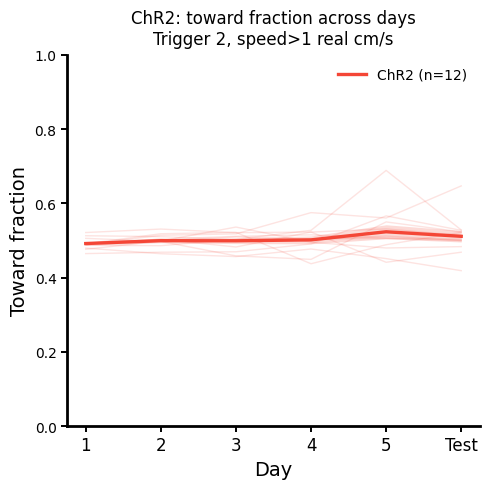

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot toward fraction across L1-L5 + Test for ChR2
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
SHOW_ANIMAL_IDS_DAY1 = False
DAY1_LABEL_X_OFFSET = 0.0
DAY1_LABEL_Y_OFFSET = 0.0
DAY1_LABEL_FONTSIZE = 8

VALUE_COL = TOWARD_FRACTION_COL

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[(~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# Build subject x day matrix
# ------------------------------------------------------------
rows = []
subs = []

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]
    mean_by_day = ms.groupby('plot_day')[VALUE_COL].mean()
    vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

    if np.any(np.isnan(vals)):
        continue

    rows.append(vals)
    subs.append(sub)

if len(rows) == 0:
    print("No animals with complete L1-L5 + Test toward fraction.")
else:
    mat = np.vstack(rows)

    mean_ = np.nanmean(mat, axis=0)
    sem_ = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(mat.shape[0]) if mat.shape[0] > 1 else np.zeros(mat.shape[1])

    x_vals = plot_days - 1

    fig, ax = plt.subplots(figsize=(5, 5))

    # individual animals in background
    for i, row in enumerate(mat):
        ax.plot(
            x_vals, row,
            '-',
            color=get_genotype_color('ChR2'),
            alpha=0.15,
            linewidth=1.0,
            zorder=1
        )

        if SHOW_ANIMAL_IDS_DAY1:
            ax.text(
                x_vals[0] + DAY1_LABEL_X_OFFSET,
                row[0] + DAY1_LABEL_Y_OFFSET,
                str(subs[i]),
                fontsize=DAY1_LABEL_FONTSIZE,
                alpha=0.8,
                ha='right',
                va='center'
            )

    # group mean ± SEM
    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=get_genotype_color('ChR2'),
        alpha=0.20,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals, mean_,
        '-',
        color=get_genotype_color('ChR2'),
        linewidth=2.4,
        label=f'ChR2 (n={len(subs)})',
        zorder=3
    )

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Toward fraction', fontsize=14)
    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.set_ylim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.4)

    title_suffix = f'Trigger {TRIGGER_TO_USE}, speed>{SPEED_THRESH_REAL:g} real cm/s'
    if REQUIRE_REWARD_ENTRY_FOR_FRACTION:
        title_suffix += ', entry-linked'
    if REQUIRE_MIN_REWARD_STAY:
        title_suffix += ', reward stay ≥2 s'

    ax.set_title(f'ChR2: toward fraction across days\n{title_suffix}', fontsize=12, pad=8)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

In [17]:

# ============================================================
# Compute mean speed per trial:
#   1) mean_speed          = mean over all timepoints
#   2) mean_speed_moving   = mean after removing "still" samples
# Store both into metadata.
# ============================================================

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata['mean_speed'] = np.nan          # cm/s, includes still time
metadata['mean_speed_moving'] = np.nan   # cm/s, excludes still time

# --- SETTINGS ---
# Define "still" as speed <= STILL_THRESH (cm/s)
STILL_THRESH = 0.0   # keep 0.0 if still samples are exactly 0; set e.g. 0.5 if you want a small threshold
# ----------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)

    if 'speed' not in pos.columns:
        continue

    speeds = pos['speed'].values.astype(float)

    # finite only
    speeds = speeds[np.isfinite(speeds)]
    if len(speeds) == 0:
        continue

    # 1) mean speed including still time
    metadata.at[trial_id, 'mean_speed'] = float(np.nanmean(speeds))

    # 2) mean speed excluding still time (moving only)
    moving = speeds[speeds > STILL_THRESH]
    if len(moving) > 0:
        metadata.at[trial_id, 'mean_speed_moving'] = float(np.nanmean(moving))
    else:
        metadata.at[trial_id, 'mean_speed_moving'] = np.nan

metadata[['sub','ses','trial_type','trial_type_day','mean_speed','mean_speed_moving']].head()

 16%|█▌        | 725/4609 [00:04<00:24, 157.89it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1198/4609 [00:07<00:20, 164.54it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2619/4609 [00:15<00:06, 286.27it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:24<00:00, 185.46it/s]


,sub,ses,trial_type,trial_type_day,mean_speed,mean_speed_moving
0,1,1,H,1,13.183545,14.252018
1,1,1,H,1,9.790948,10.727092
2,1,1,H,1,9.168459,11.081422
3,1,1,H,1,9.678405,11.026503
4,1,1,H,1,10.652230,11.998895


ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


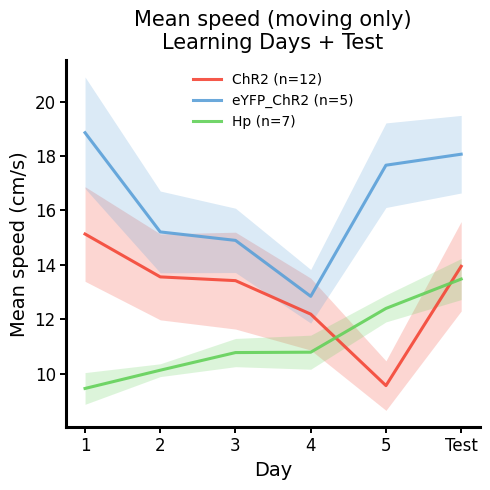

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# OPTION: choose which speed metric to plot
#   'mean_speed'         -> includes still time
#   'mean_speed_moving'  -> excludes still time
# ============================================================
SPEED_COL = 'mean_speed_moving'          # <-- change to 'mean_speed_moving' to plot moving-only

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, three genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create plot_day: learning = 1–5, test = 6 (assigned per animal)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix (SPEED_COL), require complete days
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, require_complete=True):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[SPEED_COL].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2'].copy()
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp'].copy()

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2, require_complete=True)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP, require_complete=True)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp,   require_complete=True)

print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
print("Hp animals plotted:", len(subs_Hp))

# ------------------------------------------------------------
# 3) Plot (mean ± shaded SEM only)
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, color, label, alpha_fill=0.22, alpha_line=0.9):
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    plt.plot(
        x_vals,
        mean_,
        '-',
        color=color,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

plot_group_shaded(mat_ChR2, subs_ChR2,
                  color=get_genotype_color('ChR2'),
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  color=get_genotype_color('eYFP_ChR2'),
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  color=get_genotype_color('Hp'),
                  label='Hp')

# ------------------------------------------------------------
# axis + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean speed (cm/s)', fontsize=14)

plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)

title_metric = "Mean speed" if SPEED_COL == "mean_speed" else "Mean speed (moving only)"
plt.title(f'{title_metric}\nLearning Days + Test', fontsize=15, pad=8)

plt.tight_layout()
plt.show()

[Per-trial paired] n=1280 trials | Wilcoxon p=7.37e-211
  mean(mean_speed)        = 10.933 cm/s
  mean(mean_speed_moving) = 12.748 cm/s
  mean(diff moving-all)   = 1.815 cm/s

[Per-animal paired] n=12 animals | Wilcoxon p=0.000488
  mean(mean_speed)        = 11.524 cm/s
  mean(mean_speed_moving) = 13.291 cm/s
  mean(diff moving-all)   = 1.766 cm/s


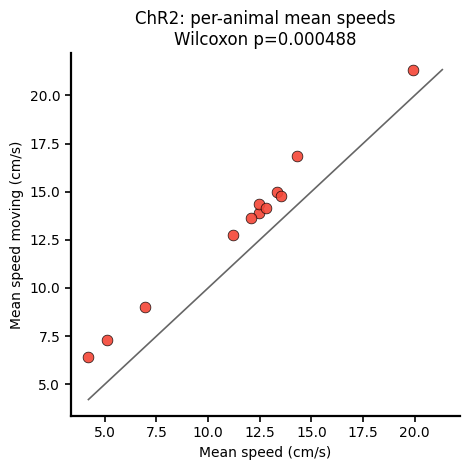

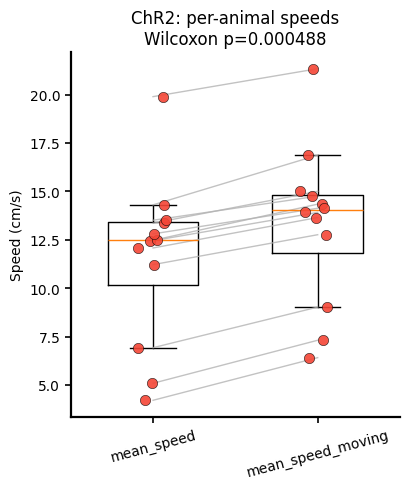

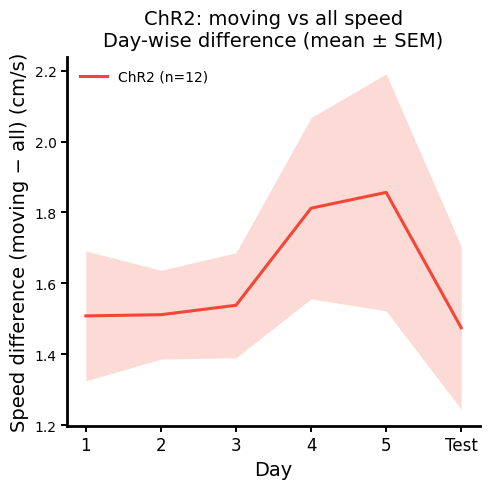

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ============================================================
# Compare mean_speed vs mean_speed_moving for ChR2
#  - does two paired comparisons:
#      (A) per-trial (paired by trial row)
#      (B) per-animal (paired by sub mean across trials)
#  - makes 2 plots:
#      (1) paired scatter (mean_speed vs mean_speed_moving)
#      (2) paired boxplot + connecting lines
#  - PLUS (NEW):
#      (3) day-wise difference across L1–L5 + Test (day 6)
# ============================================================

COL_ALL    = 'mean_speed'
COL_MOVING = 'mean_speed_moving'

# -----------------------------
# 1) Filter ChR2 trials with both metrics present
# -----------------------------
m = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata[COL_ALL].notna()) &
    (metadata[COL_MOVING].notna())
].copy()

# ===== (A) per-trial paired test =====
a_trial = m[COL_ALL].astype(float).values
b_trial = m[COL_MOVING].astype(float).values

stat_t, p_t = wilcoxon(b_trial, a_trial, alternative='two-sided')
print(f"[Per-trial paired] n={len(a_trial)} trials | Wilcoxon p={p_t:.3g}")
print(f"  mean(mean_speed)        = {np.nanmean(a_trial):.3f} cm/s")
print(f"  mean(mean_speed_moving) = {np.nanmean(b_trial):.3f} cm/s")
print(f"  mean(diff moving-all)   = {np.nanmean(b_trial - a_trial):.3f} cm/s")

# ===== (B) per-animal paired test =====
per_sub = (
    m.groupby('sub')[[COL_ALL, COL_MOVING]]
     .mean()
     .dropna()
)

a_sub = per_sub[COL_ALL].astype(float).values
b_sub = per_sub[COL_MOVING].astype(float).values

if len(per_sub) >= 2:
    stat_s, p_s = wilcoxon(b_sub, a_sub, alternative='two-sided')
    print(f"\n[Per-animal paired] n={len(a_sub)} animals | Wilcoxon p={p_s:.3g}")
    print(f"  mean(mean_speed)        = {np.nanmean(a_sub):.3f} cm/s")
    print(f"  mean(mean_speed_moving) = {np.nanmean(b_sub):.3f} cm/s")
    print(f"  mean(diff moving-all)   = {np.nanmean(b_sub - a_sub):.3f} cm/s")
else:
    print("\n[Per-animal paired] Not enough animals with both metrics to run Wilcoxon.")

# -----------------------------
# 2) Plot 1: scatter (per-animal means)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.scatter(a_sub, b_sub, s=60, color=get_genotype_color('ChR2'), edgecolor='k', linewidth=0.5, alpha=0.9)

# identity line
lo = np.nanmin(np.concatenate([a_sub, b_sub]))
hi = np.nanmax(np.concatenate([a_sub, b_sub]))
ax.plot([lo, hi], [lo, hi], '-', color='k', lw=1.2, alpha=0.6)

ax.set_xlabel('Mean speed (cm/s)')
ax.set_ylabel('Mean speed moving (cm/s)')
ax.set_title(f'ChR2: per-animal mean speeds\nWilcoxon p={p_s:.3g}' if len(per_sub) >= 2 else 'ChR2: per-animal mean speeds')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.6)
ax.spines['left'].set_linewidth(1.6)
ax.tick_params(direction='out', length=4, width=1.2)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Plot 2: paired boxplot (per-animal means) + lines
# -----------------------------
fig, ax = plt.subplots(figsize=(4.2, 5))

data = [a_sub, b_sub]
positions = [0, 1]
labels = ['mean_speed', 'mean_speed_moving']

ax.boxplot(data, positions=positions, widths=0.55, patch_artist=False, showfliers=False)

# paired lines + points
for i in range(len(a_sub)):
    ax.plot(positions, [a_sub[i], b_sub[i]], '-', color='0.7', lw=1.0, alpha=0.8, zorder=2)
ax.scatter(np.random.normal(0, 0.06, size=len(a_sub)), a_sub, s=55, color=get_genotype_color('ChR2'),
           edgecolor='k', linewidth=0.4, alpha=0.9, zorder=3)
ax.scatter(np.random.normal(1, 0.06, size=len(b_sub)), b_sub, s=55, color=get_genotype_color('ChR2'),
           edgecolor='k', linewidth=0.4, alpha=0.9, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Speed (cm/s)')
ax.set_title(f'ChR2: per-animal speeds\nWilcoxon p={p_s:.3g}' if len(per_sub) >= 2 else 'ChR2: per-animal speeds')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.6)
ax.spines['left'].set_linewidth(1.6)
ax.tick_params(direction='out', length=4, width=1.2)
plt.tight_layout()
plt.show()

# ============================================================
# (NEW) 4) Plot 3: day-wise difference (moving - all) across L1–L5 + Test
#   - builds plot_day like your other scripts:
#       L: trial_type_day (1..5)
#       T: first post-learning test session = day 6 (per animal)
#   - per animal: mean over trials within each day
#   - plots group mean ± SEM of the DIFFERENCE per day
# ============================================================

m_day = m[
    (m['trial_type'].isin(['L', 'T'])) &
    (m['trial_type_day'].notna())
].copy()

m_day['plot_day'] = np.nan
mask_L = (m_day['trial_type'] == 'L')
m_day.loc[mask_L, 'plot_day'] = m_day.loc[mask_L, 'trial_type_day']

for sub in m_day['sub'].unique():
    ms = m_day[m_day['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue
    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = m_day.index[
        (m_day['sub'] == sub) &
        (m_day['trial_type'] == 'T') &
        (m_day['ses'] == first_T_ses)
    ]
    m_day.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
m_day = m_day[m_day['plot_day'].isin(plot_days)].copy()

# per-trial diff
m_day['diff_moving_minus_all'] = m_day[COL_MOVING].astype(float) - m_day[COL_ALL].astype(float)

# build subject x day matrix of diffs (require complete 6 days)
rows = []
subs = []
for sub in m_day['sub'].unique():
    ms = m_day[m_day['sub'] == sub]
    mean_by_day = ms.groupby('plot_day')['diff_moving_minus_all'].mean()
    vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)
    if np.any(np.isnan(vals)):
        continue
    rows.append(vals)
    subs.append(sub)

if len(rows) == 0:
    print("\n[Day-wise plot] No animals with complete L1–L5 + Test for both speed metrics.")
else:
    mat = np.vstack(rows)
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    x_vals = plot_days - 1  # 0..5

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=get_genotype_color('ChR2'),
        alpha=0.20,
        linewidth=0
    )
    ax.plot(
        x_vals, mean_,
        '-',
        color=get_genotype_color('ChR2'),
        linewidth=2.2,
        label=f'ChR2 (n={len(subs)})'
    )

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Speed difference (moving − all) (cm/s)', fontsize=14)
    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1','2','3','4','5','Test'], fontsize=12)
    ax.tick_params(direction='out', length=4, width=1.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)

    ax.set_title('ChR2: moving vs all speed\nDay-wise difference (mean ± SEM)', fontsize=14, pad=8)

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

Animals included (learning trials only):
  ChR2: 12
  eYFP: 5


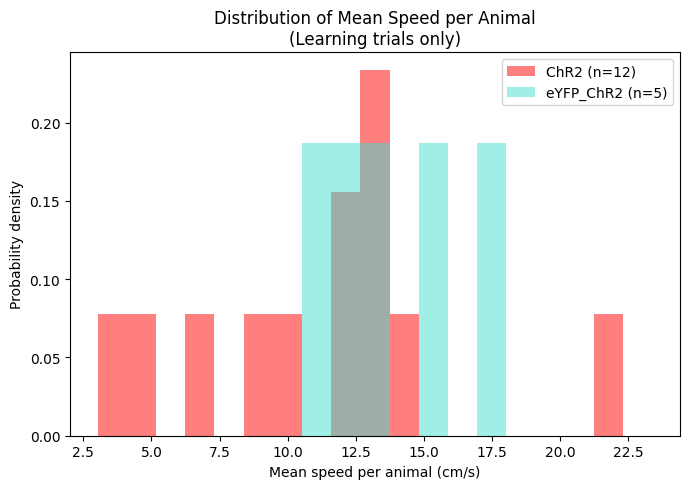

In [21]:
# Distribution of Mean Speed per Animal
# 1) Restrict to LEARNING trials only
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['mean_speed'].notna())
].copy()

# ------------------------------------------------------------
# 2) Per-animal mean speed (average across learning trials)
# ------------------------------------------------------------
meta_animal = (
    meta_L
    .groupby(['genotype', 'sub'])['mean_speed']
    .mean()
    .reset_index()
)

speeds_ChR2 = meta_animal.loc[
    meta_animal['genotype'] == 'ChR2', 'mean_speed'
].values

speeds_eYFP = meta_animal.loc[
    meta_animal['genotype'] == 'eYFP_ChR2', 'mean_speed'
].values

print("Animals included (learning trials only):")
print("  ChR2:", len(speeds_ChR2))
print("  eYFP:", len(speeds_eYFP))

# ------------------------------------------------------------
# 3) Plot histogram
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

bins = np.linspace(
    np.nanmin(meta_animal['mean_speed']),
    np.nanmax(meta_animal['mean_speed']),
    20
)

plt.hist(
    speeds_ChR2,
    bins=bins,
    color='red',
    alpha=0.5,
    density=True,
    label=f'ChR2 (n={len(speeds_ChR2)})'
)

plt.hist(
    speeds_eYFP,
    bins=bins,
    color='turquoise',
    alpha=0.5,
    density=True,
    label=f'eYFP_ChR2 (n={len(speeds_eYFP)})'
)

plt.xlabel('Mean speed per animal (cm/s)')
plt.ylabel('Probability density')
plt.title('Distribution of Mean Speed per Animal\n(Learning trials only)')
plt.legend()
plt.tight_layout()
plt.show()

Speed samples per day:
  Day 1: 456899
  Day 2: 443936
  Day 3: 466650
  Day 4: 437309
  Day 5: 423805
  Day 6: 56880


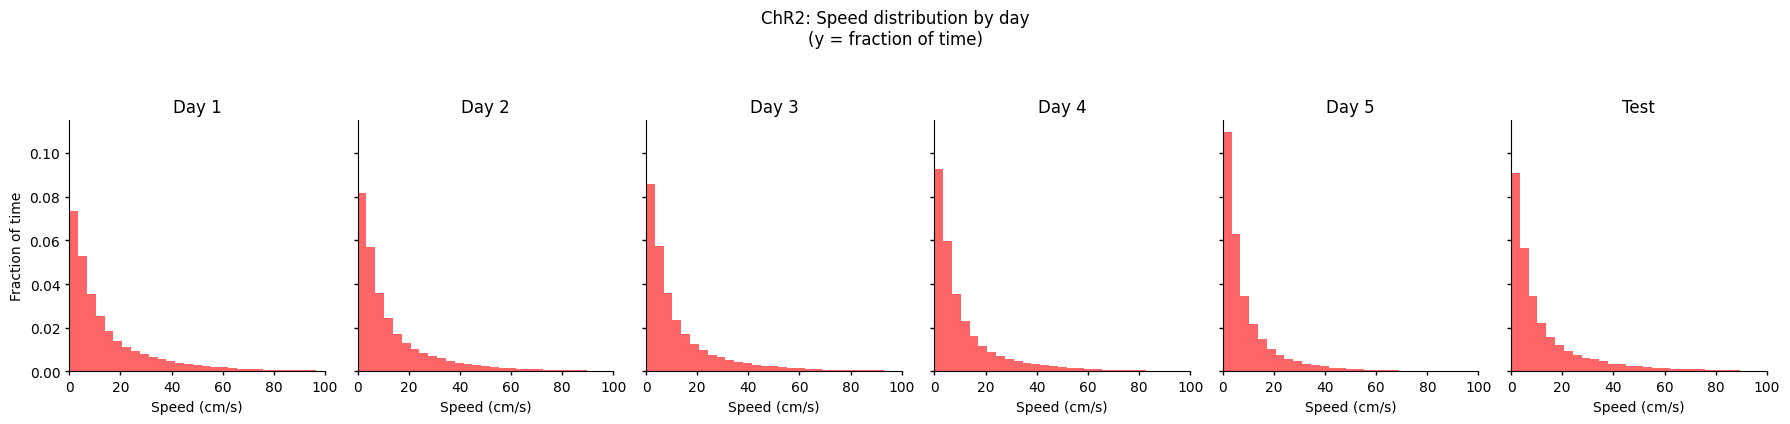

In [ ]:
# =============================================================
# Speed distribution by day (ChR2: L1–L5 + Test)
# =============================================================

days = [1, 2, 3, 4, 5, 6]  # now includes test as day 6

# ------------------------------------------------------------
# 1) Filter usable trials for ChR2 (L + T)
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L','T']))
].copy()

# assign learning trial days 1–5
meta_LT.loc[meta_LT['trial_type']=='L', 'plot_day'] = meta_LT['trial_type_day']

# ------------------------------------------------------------
# 2) Assign FIRST TEST session after learning → plot_day = 6
# ------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub']==sub]

    L_ses = ms.loc[ms['trial_type']=='L', 'ses']
    if len(L_ses)==0:
        continue
    last_L = L_ses.max()

    T_after = ms[(ms['trial_type']=='T') & (ms['ses'] > last_L)]
    if len(T_after)==0:
        continue

    first_T = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub']==sub) &
        (meta_LT['trial_type']=='T') &
        (meta_LT['ses']==first_T)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# keep only days 1–6
meta_LT = meta_LT[meta_LT['plot_day'].isin(days)]

# ------------------------------------------------------------
# 3) Collect SPEED samples per plot_day
# ------------------------------------------------------------
speed_by_day = {d: [] for d in days}

for idx, row in meta_LT.iterrows():
    dl = DataLoader(row)
    pos = dl.get_data('position')
    if pos is None or len(pos)<2:
        continue

    pos = add_speed(pos)
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]
    speeds = speeds[speeds>0]

    if len(speeds)==0:
        continue
    
    speed_by_day[int(row['plot_day'])].append(speeds)

# concatenate
for d in days:
    speed_by_day[d] = np.concatenate(speed_by_day[d]) if len(speed_by_day[d])>0 else np.array([])

print("Speed samples per day:")
for d in days:
    print(f"  Day {d}: {len(speed_by_day[d])}")

# ------------------------------------------------------------
# 4) Plot histograms (fraction of time)
# ------------------------------------------------------------

col = get_genotype_color('ChR2')
bins = np.linspace(0, 100, 30)

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=True)

labels = {1:'Day 1', 2:'Day 2', 3:'Day 3', 4:'Day 4', 5:'Day 5', 6:'Test'}

for ax, d in zip(axes, days):
    speeds = speed_by_day[d]
    
    ax.hist(
        speeds,
        bins=bins,
        density=True,
        color=col,
        alpha=0.8,
        edgecolor='none'
    )
    
    ax.set_xlim(0,100)
    ax.set_title(labels[d])
    ax.set_xlabel('Speed (cm/s)')
    if d == 1:
        ax.set_ylabel('Fraction of time')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)

fig.suptitle('ChR2: Speed distribution by day\n(y = fraction of time)',
             y=1.05, fontsize=12)

plt.tight_layout()
plt.show()

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.
ChR2 animals plotted: 12


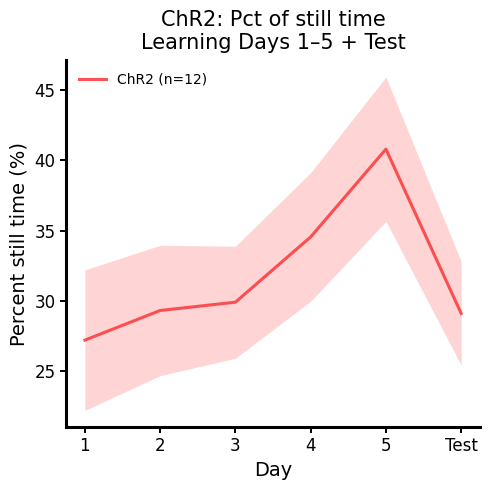

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Compute % still time per trial (using speed threshold)
# ============================================================

STILL_THRESH = 2.0  # cm/s, change if you like

# add column if not present
if 'pct_still' not in metadata.columns:
    metadata['pct_still'] = np.nan

for trial_id in range(len(metadata)):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)  # must create pos['speed']
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        continue

    pct_still = 100.0 * np.mean(speeds < STILL_THRESH)
    metadata.at[trial_id, 'pct_still'] = pct_still

# ============================================================
# 2) Build L1–5 + Test (day 6) for ChR2 only
# ============================================================

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_still'].notna())
].copy()

# init plot_day
meta_LT['plot_day'] = np.nan

# L trials: trial_type_day 1–5
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# assign first T session after last L as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1–5 + Test
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)]

# ============================================================
# 3) Subject × day matrix: % still time
# ============================================================

def build_matrix_pct_still(meta_g, require_complete=True):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_still'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs

mat_ChR2, subs_ChR2 = build_matrix_pct_still(meta_LT, require_complete=True)
print("ChR2 animals plotted:", len(subs_ChR2))

# ============================================================
# 4) Plot mean ± shaded SEM (ChR2 only)
# ============================================================

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 (for label convenience)

col = get_genotype_color('ChR2')

if mat_ChR2 is not None and len(subs_ChR2) > 0:
    mean_ = np.nanmean(mat_ChR2, axis=0)
    sem_  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])

    # shaded SEM
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=0.22,
        linewidth=0
    )

    # mean line (no markers if you don’t want dots)
    plt.plot(
        x_vals, mean_,
        '-',                # use '-' to avoid dots; '-o' if you want dots
        color=col,
        alpha=0.9,
        linewidth=2.2,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# axes + style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent still time (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('ChR2: Pct of still time\nLearning Days 1–5 + Test', fontsize=15, pad=8)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [23]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# (optionally require ≥2000 ms stay)
# ------------------------------------------------------------

metadata['mean_speed_to_trigger'] = np.nan

R_TRIGGER = (10 / 1.2)

# ----------------------------
# TOGGLE THIS
# ----------------------------
USE_MIN_DURATION = False      # set False to ignore duration
MIN_DURATION_MS = 2000       # ms
# ----------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    # add speed + distance info
    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect all trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # never entered any reward zone
    if len(dfs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    # ----------------------------
    # OPTIONAL: require ≥2000 ms stay
    # ----------------------------
    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        # never satisfied criterion → use full trial
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue
    # ----------------------------

    # first qualifying entry time
    t_enter_first = df_all.iloc[0]['t_enter']

    # speed up to that time
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = 0.0
        continue

    metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(
        pos_['speed'].iloc[idxs]
    )

 15%|█▌        | 714/4609 [00:06<00:32, 119.20it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1183/4609 [00:10<00:27, 123.30it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2610/4609 [00:21<00:13, 145.65it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:36<00:00, 126.20it/s]


In [34]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# ALSO compute mean speed while MOVING (remove still-time samples)
#
# Special rule for trials that never reach ANY reward zone:
#   - Find mean time-to-first-reward for ChR2 animals on THAT plot_day
#   - Use that time window to compute speeds for the non-reach trial
#   - If no ChR2 reaches exist for that day → fallback to full trial
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from tqdm import tqdm

# ----------------------------
# SETTINGS / TOGGLES
# ----------------------------
R_TRIGGER = (10 / 1.2)

USE_MIN_DURATION = False     # set False to ignore duration
MIN_DURATION_MS = 2000       # ms

# define "moving" (remove still time)
MOVING_EPS = 1e-6            # speed > MOVING_EPS counts as moving

# columns to write
COL_MEAN_ALL   = 'mean_speed_to_trigger'
COL_MEAN_MOVE  = 'mean_speed_moving_to_trigger'

metadata[COL_MEAN_ALL]  = np.nan
metadata[COL_MEAN_MOVE] = np.nan

# ------------------------------------------------------------
# 0) Make plot_day for all L/T trials (L1–5, Test=6)
#     (same idea as your other scripts)
# ------------------------------------------------------------
metadata['plot_day'] = np.nan

mask_LT = metadata['trial_type'].isin(['L', 'T'])
mask_L  = (metadata['trial_type'] == 'L') & mask_LT
metadata.loc[mask_L, 'plot_day'] = metadata.loc[mask_L, 'trial_type_day']

for sub in metadata.loc[mask_LT, 'sub'].unique():
    ms = metadata[(metadata['sub'] == sub) & mask_LT]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = metadata.index[
        (metadata['sub'] == sub) &
        (metadata['trial_type'] == 'T') &
        (metadata['ses'] == first_T_ses)
    ]
    metadata.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 1) PASS 1: For ChR2 only, collect time-to-first-reward per plot_day
# ------------------------------------------------------------
chR2_time_by_day = {d: [] for d in plot_days}

for trial_id in tqdm(range(len(metadata)), desc="Pass 1: ChR2 reach times"):
    row = metadata.iloc[trial_id]
    if row.get('genotype', None) != 'ChR2':
        continue
    d = row.get('plot_day', np.nan)
    if not np.isfinite(d):
        continue
    d = int(d)
    if d not in chR2_time_by_day:
        continue

    dl = DataLoader(row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    if len(dfs) == 0:
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        continue

    t_enter_first = float(df_all.iloc[0]['t_enter'])
    if np.isfinite(t_enter_first):
        chR2_time_by_day[d].append(t_enter_first)

# day-wise mean time-to-first-reward (ChR2)
chR2_mean_t_by_day = {}
print("\nChR2 mean time-to-first-reward per day (for fallback window):")
for d in plot_days:
    arr = np.array(chR2_time_by_day[d], dtype=float)
    m = np.nanmean(arr) if len(arr) else np.nan
    chR2_mean_t_by_day[int(d)] = m
    if np.isfinite(m):
        print(f"  Day {int(d)}: mean t_enter_first = {m:.1f} (n={len(arr)})")
    else:
        print(f"  Day {int(d)}: no ChR2 reaches (n=0)")

# ------------------------------------------------------------
# 2) PASS 2: Compute mean speeds using:
#     - actual t_enter_first if reached
#     - else fallback t_cut = ChR2 mean time for that plot_day
#     - else full trial
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata)), desc="Pass 2: compute speeds"):
    row = metadata.iloc[trial_id]

    # only L/T days make sense for plot_day logic; if missing, we still can do full-trial
    plot_day = row.get('plot_day', np.nan)
    plot_day_int = int(plot_day) if np.isfinite(plot_day) else None

    dl = DataLoader(row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # decide cutoff time t_cut (same units as pos_['t'] and df_trig['t_enter'])
    t_cut = None

    if len(dfs) > 0:
        df_all = (
            pd.concat(dfs, ignore_index=True)
            .sort_values('t_enter')
            .reset_index(drop=True)
        )
        if USE_MIN_DURATION:
            df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

        if len(df_all) > 0:
            # reached (under criterion)
            t_cut = float(df_all.iloc[0]['t_enter'])

    # if never reached: fallback to ChR2 mean time for that day
    if (t_cut is None) or (not np.isfinite(t_cut)):
        if plot_day_int is not None:
            t_fallback = chR2_mean_t_by_day.get(plot_day_int, np.nan)
            if np.isfinite(t_fallback):
                t_cut = float(t_fallback)

    # if still no cutoff: use full trial
    if (t_cut is None) or (not np.isfinite(t_cut)):
        t_cut = float(pos_['t'].max())

    # select samples up to cutoff
    idxs = np.where(pos_['t'].values <= t_cut)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, COL_MEAN_ALL]  = 0.0
        metadata.at[trial_id, COL_MEAN_MOVE] = np.nan
        continue

    speeds = pos_['speed'].iloc[idxs].values
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        metadata.at[trial_id, COL_MEAN_ALL]  = np.nan
        metadata.at[trial_id, COL_MEAN_MOVE] = np.nan
        continue

    # mean speed (includes still time)
    metadata.at[trial_id, COL_MEAN_ALL] = float(np.nanmean(speeds))

    # mean speed while moving (remove still time)
    speeds_move = speeds[speeds > MOVING_EPS]
    metadata.at[trial_id, COL_MEAN_MOVE] = float(np.nanmean(speeds_move)) if len(speeds_move) else np.nan

# quick check
metadata[['sub','ses','trial_type','trial_type_day','plot_day', COL_MEAN_ALL, COL_MEAN_MOVE]].head()

Pass 1: ChR2 reach times: 100%|██████████| 4609/4609 [00:04<00:00, 1019.39it/s]



ChR2 mean time-to-first-reward per day (for fallback window):
  Day 1: mean t_enter_first = 29707.4 (n=95)
  Day 2: mean t_enter_first = 27660.2 (n=93)
  Day 3: mean t_enter_first = 23398.1 (n=95)
  Day 4: mean t_enter_first = 22135.5 (n=96)
  Day 5: mean t_enter_first = 12404.1 (n=96)
  Day 6: mean t_enter_first = 12089.9 (n=12)


Pass 2: compute speeds:  15%|█▌        | 706/4609 [00:06<00:34, 113.40it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


Pass 2: compute speeds:  26%|██▌       | 1179/4609 [00:11<00:29, 118.21it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


Pass 2: compute speeds:  56%|█████▋    | 2603/4609 [00:22<00:11, 175.27it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


Pass 2: compute speeds: 100%|██████████| 4609/4609 [00:37<00:00, 124.43it/s]


,sub,ses,trial_type,trial_type_day,plot_day,mean_speed_to_trigger,mean_speed_moving_to_trigger
0,1,1,H,1,NaN,10.184602,10.271650
1,1,1,H,1,NaN,10.212567,10.331515
2,1,1,H,1,NaN,8.230093,8.504429
3,1,1,H,1,NaN,6.549703,6.775555
4,1,1,H,1,NaN,16.507261,18.249035



=== mean_speed_to_trigger ===
ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


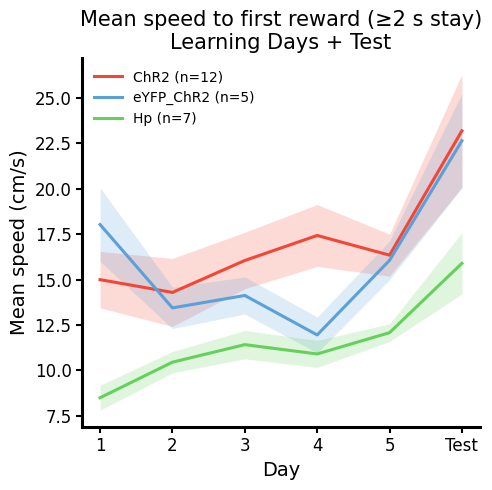

In [ ]:


# ============================================================
# Plot mean speed up to FIRST reward arrival (or fallback window)
# Groups: ChR2 vs eYFP_ChR2, optional + (ChR2_short OR Hp)
# Option: plot moving-only or overall mean speed
# Requires you already computed and stored in metadata:
#   - mean_speed_to_trigger
#   - mean_speed_moving_to_trigger
# ============================================================

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
PLOT_MOVING_ONLY = False   # False -> mean_speed_to_trigger ; True -> mean_speed_moving_to_trigger
INCLUDE_THIRD    = True   # True -> add third group
USE_SHORT        = False    # True -> third=ChR2_short ; False -> third=Hp
ADD_STAY_TAG     = False   # True -> append "(≥2 s stay)" in titles

# choose which column to plot
SPEED_COL = 'mean_speed_moving_to_trigger' if PLOT_MOVING_ONLY else 'mean_speed_to_trigger'

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp', 'ChR2_short'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (same behaviour as your other scripts)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3) Plot helper (keeps same style as your previous distance/CIPL plots)
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col, ylabel, title,
                           include_third=False, use_short=True):
    meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
    meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

    if use_short:
        third_key, third_label = 'ChR2_short', 'ChR2_short'
    else:
        third_key, third_label = 'Hp', 'Hp'
    meta_third = meta_LT[meta_LT['genotype'] == third_key]

    mat_ChR2,  subs_ChR2  = build_genotype_matrix(meta_ChR2,  value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_third, subs_third = build_genotype_matrix(meta_third, value_col)

    print(f"\n=== {value_col} ===")
    print("ChR2 animals plotted:", len(subs_ChR2))
    print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
    if include_third:
        print(f"{third_key} animals plotted:", len(subs_third))

    plt.figure(figsize=(5, 5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    plot_group(mat_ChR2, subs_ChR2, 'ChR2', 'ChR2')
    plot_group(mat_eYFP, subs_eYFP, 'eYFP_ChR2', 'eYFP_ChR2')
    if include_third:
        plot_group(mat_third, subs_third, third_key, third_label)

    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4) Call plot
# ---------------------------------------------------------------------
stay_tag = " (≥2 s stay)" if ADD_STAY_TAG else ""
moving_tag = " (moving only)" if PLOT_MOVING_ONLY else ""

plot_metric_for_groups(
    meta_LT,
    value_col=SPEED_COL,
    ylabel='Mean speed (cm/s)',
    title=f'Mean speed to first reward{moving_tag}{stay_tag}\nLearning Days + Test',
    include_third=INCLUDE_THIRD,
    use_short=USE_SHORT
)


=== mean_speed_to_trigger ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


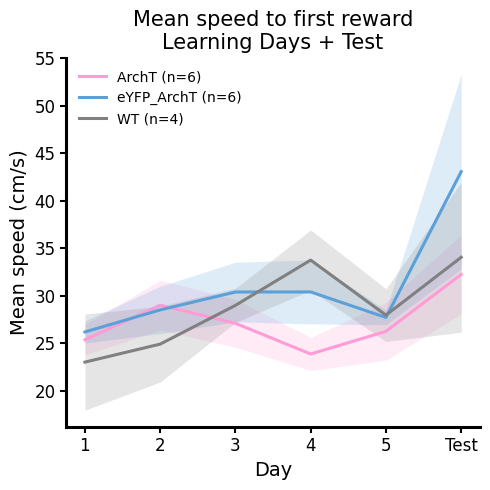

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot mean speed up to FIRST reward arrival (or fallback window)
# Groups: ArchT vs eYFP_ArchT, optional + WT
# Option: plot moving-only or overall mean speed
# Requires you already computed and stored in metadata:
#   - mean_speed_to_trigger
#   - mean_speed_moving_to_trigger
# ============================================================

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
PLOT_MOVING_ONLY = False   # False -> mean_speed_to_trigger ; True -> mean_speed_moving_to_trigger
INCLUDE_WT       = True    # True -> add WT, False -> only ArchT & eYFP_ArchT
ADD_STAY_TAG     = False    # True -> append "(≥2 s stay)" in titles

# choose which column to plot
SPEED_COL = 'mean_speed_moving_to_trigger' if PLOT_MOVING_ONLY else 'mean_speed_to_trigger'

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (same behaviour as your other scripts)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3) Plot helper (keeps same style as your previous distance/CIPL plots)
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col, ylabel, title,
                           include_wt=False):
    meta_ArchT = meta_LT[meta_LT['genotype'] == 'ArchT']
    meta_eYFP  = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']
    meta_WT    = meta_LT[meta_LT['genotype'] == 'WT']

    mat_ArchT, subs_ArchT = build_genotype_matrix(meta_ArchT, value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_WT,    subs_WT    = build_genotype_matrix(meta_WT,    value_col)

    print(f"\n=== {value_col} ===")
    print("ArchT animals plotted:", len(subs_ArchT))
    print("eYFP_ArchT animals plotted:", len(subs_eYFP))
    if include_wt:
        print("WT animals plotted:", len(subs_WT))

    plt.figure(figsize=(5, 5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    plot_group(mat_ArchT, subs_ArchT, 'ArchT', 'ArchT')
    plot_group(mat_eYFP,  subs_eYFP,  'eYFP_ArchT', 'eYFP_ArchT')
    if include_wt:
        plot_group(mat_WT, subs_WT, 'WT', 'WT')

    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4) Call plot
# ---------------------------------------------------------------------
stay_tag   = " (≥2 s stay)" if ADD_STAY_TAG else ""
moving_tag = " (moving only)" if PLOT_MOVING_ONLY else ""

plot_metric_for_groups(
    meta_LT,
    value_col=SPEED_COL,
    ylabel='Mean speed (cm/s)',
    title=f'Mean speed to first reward{moving_tag}{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

Animals plotted:
  ChR2: 10
  eYFP: 5


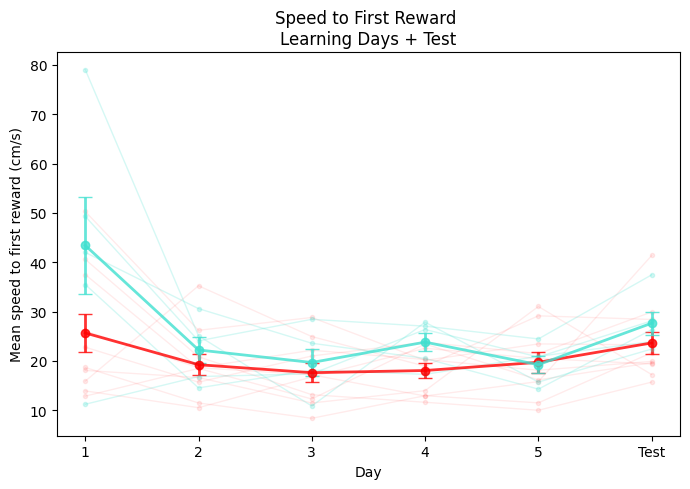

In [100]:
# Speed to first reward zone entry
# Plot ChR2 vs eYFP_ChR2 vs Hp

# ------------------------------------------------------------
# 1) Filter metadata 
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
   # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
        ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['mean_speed_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Assign plot_day (L = 1–5, first T after learning = 6)
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan
meta_LT.loc[meta_LT['trial_type'] == 'L', 'plot_day'] = meta_LT['trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 3) Subject × day matrix
# ------------------------------------------------------------
def build_matrix(meta_g):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]
        mean_by_day = ms.groupby('plot_day')['mean_speed_to_trigger'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs


#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
#meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_matrix(meta_eYFP)
#mat_Hp,   subs_Hp   = build_matrix(meta_Hp)

print("Animals plotted:")
print("  ChR2:", len(subs_ChR2))
print("  eYFP:", len(subs_eYFP))
#print("  Hp  :", len(subs_Hp))

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------

SHOW_INDIVIDUALS = True   # <<< TOGGLE THIS (True / False)

plt.figure(figsize=(7, 5))
x = plot_days - 1

def plot_group(mat, color, label, alpha_mean=0.7, alpha_ind=0.15):
    if mat is None or mat.shape[0] == 0:
        return

    # ----------------------------
    # individual animals (optional)
    # ----------------------------
    if SHOW_INDIVIDUALS:
        for row in mat:
            plt.plot(
                x, row, '-o',
                color=color,
                alpha=alpha_ind,
                linewidth=1,
                markersize=3,
                label='_nolegend_'
            )

    # ----------------------------
    # mean ± SEM
    # ----------------------------
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        alpha=alpha_mean,
        linewidth=2,
        capsize=5,
        label=f'{label} (n={mat.shape[0]})'
    )


plot_group(mat_ChR2, 'red',        'ChR2',       alpha_mean=0.8, alpha_ind=0.08)
plot_group(mat_eYFP, 'turquoise',  'eYFP_ChR2',  alpha_mean=0.8, alpha_ind=0.22)
#plot_group(mat_Hp,   '#2ca02c',    'Hp',         alpha_mean=0.8)

plt.xlabel('Day')
plt.ylabel('Mean speed to first reward (cm/s)')
plt.title('Speed to First Reward \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'])
#plt.legend(frameon=False)
plt.tight_layout()
plt.show()
